<a href="https://colab.research.google.com/github/samer-glitch/TADP-sec/blob/main/TADP-Sec_v11.7_Canonical_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import shutil
import os

uploaded = files.upload()

for filename in uploaded.keys():
    if filename.endswith(".csv"):
        shutil.move(filename, "/content/creditcard.csv")
        print(f"Uploaded and saved as: /content/creditcard.csv")

print(os.path.exists("/content/creditcard.csv"))

Saving creditcard.csv to creditcard.csv
Uploaded and saved as: /content/creditcard.csv
True


✓ Configured for Q1 journal: ALL plots at 600 DPI
✓ Notebook display configured

TADP-SEC EXPERIMENT
Trustworthy AI Data Preparation with Governance-to-Runtime Security in Federated Learning
Suite design: B0–T4 core (5 seeds × 20 rounds) + T4 dropout robustness (5 seeds × 5 rounds)
ARQ policy: fixed HPS thresholds with a global critical-dimension floor and normalized critical-profile review
Governance evaluation: LEV data quality is measured from local partitions; non-technical governance/CIA-BI use explicit controlled archetype manifests
Audit layer: central governance/runtime ledger + client-specific ledgers + crypto ledger; hash-chained CSV, signed checkpoints, final root-of-roots seal
T4 SAMK reference profile: BFV N=64, Paillier prime bits=320 (functional/reproducibility parameters; no production bit-security claim)
✓ Fresh-run output reset: /content/tadp_sec_results_v11_7
  • Previous signed ledgers/results in this dedicated run folder were removed.
✓ Running T2 numerical + T4/SA

✓ Rendered all four HTML report tables directly in notebook output.

  Generating unified B0–T4 publication figure...
✓ Saved unified figure at 600 DPI: ./tadp_sec_results_v11_7/figs/learning_curves_600dpi.png
✓ Saved unified figure as vector PDF: ./tadp_sec_results_v11_7/figs/learning_curves_vector.pdf


### Unified B0–T4 operational comparison

### Threat-coverage matrix

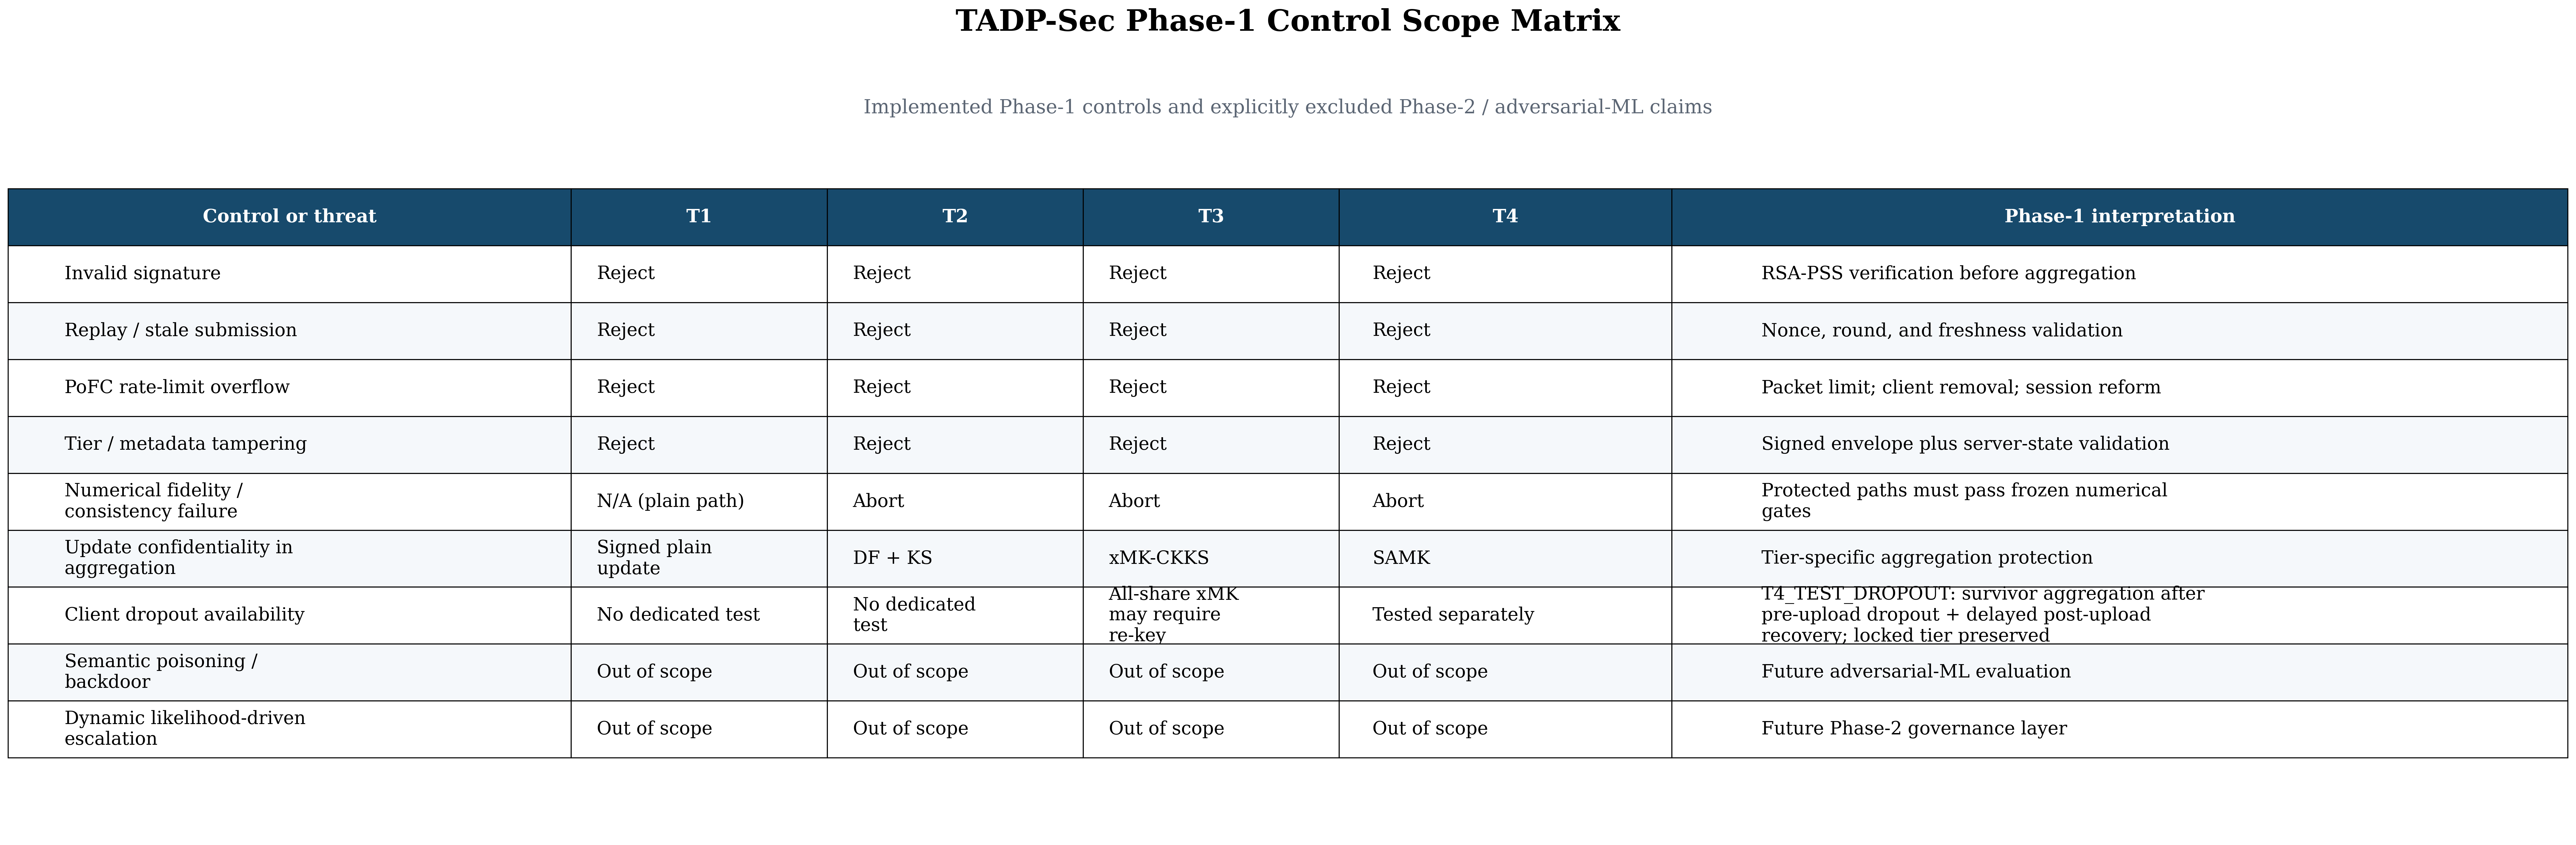

✓ Rendered 2 saved publication figure(s) directly in notebook output.

EXPERIMENT COMPLETE
• Unified HTML report: ./tadp_sec_results_v11_7/stats/TADP_Sec_Publication_Report.html
• Operational CSV: ./tadp_sec_results_v11_7/stats/publication_operational_comparison_b0_t4.csv
• Attack-only enforcement CSV: ./tadp_sec_results_v11_7/stats/publication_protocol_enforcement_attack_only.csv
• SAMK dropout robustness CSV: ./tadp_sec_results_v11_7/stats/publication_samk_dropout_robustness.csv
• Fidelity diagnostics CSV: ./tadp_sec_results_v11_7/stats/publication_aggregate_fidelity_diagnostics.csv
• Planned AP-contrast non-inferiority CSV: ./tadp_sec_results_v11_7/stats/noninferiority_ap_planned_contrasts.csv
• Metric-equivalence diagnostic summary: ./tadp_sec_results_v11_7/stats/metric_equivalence_diagnostics_summary.csv
• Metric-equivalence per-seed diagnostics: ./tadp_sec_results_v11_7/stats/metric_equivalence_diagnostics_per_seed.csv
• Threat coverage figure: completed
• Learning-curves figure:

In [6]:
# ============================================================
# TADP-SEC: TRUSTWORTHY AI DATA PREPARATION WITH
# GOVERNANCE-TO-RUNTIME SECURITY FOR FEDERATED LEARNING
#
# Version: TADP-SEC v11.7
# ============================================================
#
# This source implements the TADP-Sec framework evaluated in the
# accompanying paper.
#
# TADP performs evidence-based contributor admission before federated
# training. The server validates the available evidence, derives the six
# policy-defined governance-dimension scores, computes the overall HPS
# and normalized critical-dimension HPS, and applies a non-compensatory
# minimum requirement to the critical dimensions.
#
# Admission follows a fixed and versioned policy rather than cohort-ranked
# selection. Direct acceptance requires both a strong overall governance
# profile and a strong critical profile. Contributions in the intermediate
# admission band are evaluated by a deterministic automated review rule;
# inadequate critical dimensions are routed to remediation.
#
# TADP-Sec begins only after the admitted cohort has been finalized.
# Validated confidentiality, integrity, and availability requirements are
# combined with Business Impact to determine each admitted client's minimum
# protection requirement. The session uses one common protection profile,
# equal to the strictest admitted requirement, selected before federated
# round 1 and kept fixed for the lifetime of that session.
#
# The implementation includes:
#   - the canonical ULB credit-card-fraud experimental pipeline;
#   - evidence-based TADP admission and critical-dimension safeguards;
#   - T1 authenticated governed federated learning;
#   - T2 modified Domingo-Ferrer transformation with matrix key switching;
#   - T3 xMK-CKKS multi-key protected aggregation;
#   - T4 role-separated SAMK BFV/Paillier reference aggregation;
#   - protocol binding, freshness, replay and participation controls; and
#   - tamper-evident governance and runtime audit ledgers.
#
# T2--T4 are research/reference implementations used to evaluate
# functionality, numerical fidelity, runtime, and generated protocol
# payload. They are not presented as production cryptographic deployments.
# In particular, the T4 parameters are functional/reproducibility
# parameters rather than a production bit-security configuration.
# ============================================================

# ============================================================
# SETUP FOR GOOGLE COLAB / JUPYTER NOTEBOOK
# ============================================================
# Enable inline plotting for notebooks
import matplotlib
# matplotlib.use('inline')

# Check if we're in a notebook environment
def setup_notebook_display():
    """Setup for notebook display"""
    try:
        from IPython import get_ipython
        import matplotlib
        import matplotlib.pyplot as plt

        # Set backend for inline display
        # Set backend for inline display
        matplotlib.use('module://matplotlib_inline.backend_inline')

        # Configure matplotlib for inline display
        get_ipython().run_line_magic('matplotlib', 'inline')

        # Set EXCLUSIVELY 600 DPI for both display and saving (Q1 journal requirement)
        plt.rcParams['figure.dpi'] = 600      # Display DPI
        plt.rcParams['savefig.dpi'] = 600     # Saving DPI (CRITICAL)
        plt.rcParams['savefig.format'] = 'png' # Lossless format
        plt.rcParams['savefig.bbox'] = 'tight' # Tight bounding box
        plt.rcParams['savefig.pad_inches'] = 0.1 # Minimal padding
        plt.rcParams['figure.figsize'] = (12, 8)

        print("✓ Configured for Q1 journal: ALL plots at 600 DPI")
        return True
    except:
        print("Not in notebook environment, using default settings")
        return False

# Call this at the beginning
setup_notebook_display()

import os
import sys
import time
import json
import math
import base64
import hashlib
import random
import csv
import secrets
import struct
from dataclasses import dataclass, asdict, field
from typing import Dict, List, Tuple, Any, Optional, Union, Set
from datetime import datetime, timezone
from collections import defaultdict, Counter
from pathlib import Path
import hmac
import platform
import re
import shutil
import subprocess
import threading
from types import SimpleNamespace

import numpy as np

from functools import lru_cache

# ============================================================
# EXPERIMENT VERSION, PROTOCOL BINDING, AND AUDIT CONFIGURATION
# ============================================================
#
# The controls in this section provide protocol binding, integrity checks,
# freshness/replay protection, participation enforcement, and tamper-evident
# audit evidence for the experimental workflow.
#
# They support the security properties evaluated in the paper but should
# not be interpreted as converting this research implementation into a
# production-ready cryptographic system.
# ============================================================

EXPERIMENT_VERSION = "TADP-SEC v11.7"

# TADP-SEC v11.7 uses the fixed, evidence-based admission policy reported
# in the paper while retaining the canonical experimental dataset pipeline,
# governance evidence rubric, financial-fraud policy weights, federated
# learning configuration, T2/T3/T4 protection mechanisms, security-tier
# mapping, and audit-ledger design.
#
# Contributor admission is based on:
#   (1) server-validated, evidence-supported governance-dimension scores;
#   (2) fixed thresholds on the 0--5 HPS scale;
#   (3) a non-compensatory minimum requirement on critical dimensions; and
#   (4) a normalized critical-dimension HPS used together with the overall
#       HPS to distinguish direct acceptance, automated-review acceptance,
#       remediation, and rejection.
#
# The 20-client controlled governance and CIA/Business-Impact archetypes
# are retained as a fixed experimental fixture. They provide reproducible
# organizational conditions that are absent from the public ULB dataset.
# Data Quality is measured independently from the actual local client
# partitions.
#
# The fixture composition is not an admission quota and is not used to
# determine the v11.7 thresholds. Admission outcomes are produced solely
# by the frozen policy applied to the validated client evidence.

SOURCE_CODE_BASIS_FILE = "TADP_Sec_v11_6_ledger_hardened_trustworthy_data_preparation_SAMK_reference.py"
SOURCE_CODE_BASIS_SHA256 = "38b89c7089129a74b3354506978dc88751973007f992f483d536741159d5ebda"
PROTOCOL_VERSION = "TADP-SEC/11.7"

# Metric-equivalence diagnostics are reporting-only. They do not alter training,
# aggregation, governance admission, cryptographic gates, or model selection.
METRIC_EQUIVALENCE_DIAGNOSTIC_VERSION = "1.0"
METRIC_EQUIVALENCE_REFERENCE_MAP = {
    "B1_xMK_CKKS": "B0_Plain_FL",
    "T1_Plain_TADP": "A1_TADP_admission_only",
    "T2_DF_KS_TADP": "T1_Plain_TADP",
    "T3_XMK_CKKS_TADP": "T1_Plain_TADP",
    "T4_SAMK_TADP": "T1_Plain_TADP",
}
METRIC_EQUIVALENCE_SNAPSHOT_SCENARIOS = {
    "B0_Plain_FL",
    "A1_TADP_admission_only",
    "T1_Plain_TADP",
}
HASH_ALGORITHM = "SHA-256"
HASH_DOMAIN_PREFIX = b"TADP-SEC/v11.7|"
RSA_SIGNATURE_KEY_BITS = 3072
PROTOCOL_NONCE_BYTES = 32
LEDGER_CHECKPOINT_INTERVAL = 64
CRYPTO_TEST_MODE = False  # True only for deterministic unit tests; never enable for security claims.

# ============================================================
# RESEARCH-REPORTING AND ASSURANCE LABELS
# ============================================================
#
# These labels are written to the generated CSV/JSON artifacts to preserve
# the scope of the reported experimental evidence and to prevent downstream
# tables or figures from overstating the assurance provided by the research
# implementation.
#
# The cryptographic mechanisms are implemented as custom Python
# research/reference prototypes. Their evaluation supports functional,
# numerical-fidelity, runtime, and generated-payload analysis; it does not
# constitute certification of a production cryptographic backend.
#
# Energy values are reportable only when obtained from direct hardware
# counters or direct power integration. No proxy or model-based estimate is
# promoted as a measured energy result.

CRYPTO_BACKEND_LABEL = "custom_reference_python_prototype"
ENERGY_ESTIMATION_METHOD = "direct_hardware_counters_or_direct_gpu_power_integration_only"

CANONICAL_CREDITCARD_EXPECTED_ROWS = 284_807
CANONICAL_CREDITCARD_EXPECTED_FRAUDS = 492
DATASET_PATH_ENVIRONMENT_VARIABLE = "TADP_SEC_DATASET_PATH"
REQUIRE_CANONICAL_FULL_DATASET = os.environ.get(
    "TADP_SEC_REQUIRE_CANONICAL_FULL_DATASET", "0"
).strip().lower() in {"1", "true", "yes", "on"}
DATASET_ACCEPTANCE_POLICY = (
    "size_agnostic__required_creditcard_schema__finite_numeric_features__"
    "binary_class_labels__two_stage_stratified_split_feasibility"
)
DATASET_PROVENANCE_STATUS = "runtime_classified_from_observed_csv"
DATASET_SUBSET_SELECTION_STATUS = "runtime_classified__no_in_script_row_subsampling"
DATASET_SUBSET_DECLARATION = (
    "The supplied CSV is used in full. Canonical ULB/Kaggle compatibility is "
    "detected and recorded from observed rows, fraud-label count, and schema; "
    "non-canonical compatible inputs are explicitly labelled in the manifest."
)
DATASET_SUBSET_SELECTION_SEED = None
REQUIRED_CREDITCARD_FEATURE_COLUMNS = tuple([f"V{i}" for i in range(1, 29)] + ["Amount"])
REQUIRED_CREDITCARD_COLUMNS = tuple(["Class", *REQUIRED_CREDITCARD_FEATURE_COLUMNS])
OPTIONAL_CREDITCARD_COLUMNS = ("Time",)
MIN_CLASS_SAMPLES_FOR_TWO_STRATIFIED_SPLITS = 5
DATASET_SPLIT_PROTOCOL = (
    "stratified_20pct_test__stratified_20pct_validation_from_remaining_train__"
    "class_conditional_Dirichlet_client_partition"
)
VALIDATION_FRACTION_OF_PRETEST_TRAIN = 0.20
CLIENT_FEATURE_AUGMENTATION_STD = 0.0  # No synthetic feature perturbation in the main comparative study.


# ============================================================
# GOVERNANCE EVIDENCE, ADMISSION, SESSION POLICY, AND LIFECYCLE
# ============================================================
#
# This section implements the governance-to-runtime workflow evaluated
# in the accompanying TADP-Sec paper.
#
# Governance and admission:
#
#   (1) Clients do not submit authoritative HPS values, admission decisions,
#       or runtime protection tiers.
#
#   (2) A Local Evidence Validator (LEV) evaluates raw-data-dependent
#       technical properties locally and binds the resulting evidence to the
#       governed dataset version/commitment.
#
#   (3) For nontechnical governance dimensions, the data owner or steward
#       provides structured evidence-supported conditions. Documentary,
#       organizational, regulatory, and contextual claims are treated as
#       evidence inputs rather than authoritative numerical scores.
#
#   (4) The cloud-side Evidence Verification Engine (EVE) evaluates the
#       available evidence, maps validated conditions through the frozen
#       governance rubric, and computes the authoritative server-side
#       dimension scores, overall HPS, normalized critical HPS (HPS_C), and
#       minimum critical-dimension score. Unsupported claims do not receive
#       positive evidentiary credit.
#
#   (5) Admission is determined by a fixed, versioned policy. Depending on
#       HPS, HPS_C, and the critical-dimension floor, a contribution is routed
#       to direct acceptance, deterministic automated-review acceptance,
#       remediation, or rejection. The review path does not permit free-form
#       reassignment of the numerical governance scores.
#
#   (6) Critical governance dimensions are protected by a non-compensatory
#       minimum requirement together with the normalized critical HPS. This
#       prevents strong scores in other dimensions from masking an inadequate
#       critical dimension.
#
# Governance-to-security handoff:
#
#   (7) Only admitted contributions proceed to TADP-Sec runtime protection.
#       For each admitted client, the validated confidentiality, integrity,
#       and availability requirements are reduced to the CIA high-water level
#       and combined with Business Impact (BI) through the frozen policy
#       matrix to determine that client's minimum protection requirement.
#
#   (8) The admitted cohort is closed before federated round 1. One common
#       session profile is selected as the strictest protection requirement
#       among the admitted clients. The selected profile remains fixed for the
#       lifetime of that session and is never downgraded or dynamically
#       changed during its federated rounds.
#
#   (9) A new client, a materially changed dataset commitment, or a materially
#       changed governance/security policy requires reassessment and formation
#       of a new session rather than modification of the active session.
#
# Experimental benchmark mode:
#
#   T1--T4 profile-benchmark runs are executed separately over the same fixed
#   admitted cohort to compare utility, numerical fidelity, runtime, and
#   generated protocol payload across the implemented protection mechanisms.
#   These benchmark runs are experimental comparisons and do not represent
#   simultaneous or dynamically selected profiles within one deployment
#   session. In the reported canonical experiment, the admitted cohort's
#   strictest requirement is T4; T1--T3 are therefore benchmark-only profiles
#   for that cohort.
#
# Experimental evidence note:
#
#   The public ULB credit-card-fraud dataset does not contain organizational
#   governance metadata. In the reported experiment, Data Quality is measured
#   from the actual local client partitions, while the remaining nontechnical
#   governance dimensions and CIA/BI conditions are instantiated through the
#   frozen controlled experimental archetypes documented with the study.
# ============================================================
GOVERNANCE_POLICY_ID = "TADP-GOVERNANCE-POLICY"
GOVERNANCE_POLICY_VERSION = "2.2-phase1-fixed-threshold-dual-critical-profile"
GOVERNANCE_EVIDENCE_MANIFEST_VERSION = "2.1"
GOVERNANCE_DATA_MANIFEST_VERSION = "2.0"
GOVERNANCE_RUBRIC_VERSION = "TADP-HPS-RUBRIC/2.0"
LOCAL_EVIDENCE_VALIDATOR_VERSION = "TADP-LEV/1.0"
GOVERNANCE_EVIDENCE_MODE = "controlled_experimental_archetype_fixture"
GOVERNANCE_EVIDENCE_MANIFEST_PATH = os.environ.get(
    "TADP_SEC_GOVERNANCE_EVIDENCE_MANIFEST", ""
).strip()
GOVERNANCE_REVIEW_REGISTRY_PATH = os.environ.get(
    "TADP_SEC_GOVERNANCE_REVIEW_REGISTRY", ""
).strip()
GOVERNANCE_MANIFEST_REQUIRED = False

# ============================================================
# TADP v11.7 — FROZEN GOVERNANCE ADMISSION POLICY
# ============================================================
#
# TADP admission is governed by a domain/application-specific, versioned
# policy. The configuration below is the frozen financial-fraud experimental
# profile evaluated in the accompanying paper.
#
# The weights, thresholds, and critical-dimension set are policy parameters;
# they are not claimed to be universal or empirically optimal across domains.
# Alternative applications may define and version their own governance
# profiles without changing the underlying TADP admission mechanism.
#
# The current policy was frozen before the canonical full-dataset experiment
# and is not adapted to obtain a target number or percentage of admitted
# clients.
# ============================================================

TADP_POLICY_PROFILE_ID = "financial_fraud_experimental_profile_v1"


# ------------------------------------------------------------
# Overall HPS thresholds
# ------------------------------------------------------------
#
# Governance dimensions use the common evidence rubric:
#
#   0 = NO_EVIDENCE
#   1 = VERY_WEAK
#   2 = LIMITED
#   3 = ADEQUATE
#   4 = STRONG
#   5 = VERY_STRONG
#
# The same semantic anchors are used to define the overall HPS decision
# boundaries. HPS < 3.0 is outside the admissible range and is rejected.
# HPS >= 4.0 enters the direct-acceptance band, subject also to the
# critical-profile and individual critical-dimension requirements.

TADP_HPS_REJECT_THRESHOLD = 3.0
TADP_HPS_ACCEPT_THRESHOLD = 4.0


# ------------------------------------------------------------
# Critical-profile safeguards
# ------------------------------------------------------------
#
# The normalized critical HPS (HPS_C) provides an additional safeguard
# against compensation by stronger supporting dimensions.
#
# Direct acceptance requires the critical profile to reach the same STRONG
# semantic level as the overall direct-acceptance boundary.

TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD = (
    TADP_HPS_ACCEPT_THRESHOLD
)  # 4.0


# Contributions in the intermediate HPS band are evaluated by the
# deterministic automated-review rule. The corresponding critical-profile
# requirement is the semantic midpoint between the ADEQUATE lower boundary
# and STRONG direct-acceptance boundary:
#
#       T_C_review = (T_R + T_A) / 2
#
# This value is derived from the frozen policy structure and is not tuned to
# reproduce a predetermined admission rate.

TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD = (
    TADP_HPS_REJECT_THRESHOLD + TADP_HPS_ACCEPT_THRESHOLD
) / 2.0  # 3.5 for financial_fraud_experimental_profile_v1


# ------------------------------------------------------------
# Non-compensatory critical-dimension floor
# ------------------------------------------------------------
#
# Every admitted contribution must satisfy at least the ADEQUATE level on
# each domain-critical dimension. A strong overall HPS or HPS_C cannot
# compensate for an individual critical dimension below this floor.

TADP_CRITICAL_DIMENSION_MIN = 3.0


# ------------------------------------------------------------
# Governance-dimension roles
# ------------------------------------------------------------
#
# The critical/supporting classification is specific to the current
# financial-fraud governance profile.
#
# Critical dimensions contribute to HPS and HPS_C and are additionally
# subject to the individual non-compensatory minimum requirement.
#
# Supporting dimensions contribute to the overall HPS but are not subject
# to the individual critical-dimension floor.

TADP_CRITICAL_DIMENSIONS = (
    "source_reliability",
    "data_quality",
    "regulatory",
    "context",
)

TADP_SUPPORTING_DIMENSIONS = (
    "documentation",
    "timeliness",
)


ARQ_POLICY_ID = "TADP-ARQ/fixed-threshold-dual-critical-profile-v4"
ARQ_BOUNDARY_POLICY = "fixed_domain_policy_thresholds__not_cohort_ranked"
GOVERNANCE_REVIEW_MODE = "automated_normalized_critical_profile_review"
ADMISSION_POLICY_MODE = "fixed_threshold_hps_plus_dual_normalized_critical_profile_gate"
ARQ_REVIEW_POLICY_ID = "TADP-ARQ-REVIEW/normalized-critical-profile-midpoint-v3"
ADMISSION_POLICY_CLAIM_SCOPE = (
    "The server computes HPS from validated evidence under a versioned policy profile. "
    "HPS < T_R is auto-rejected. For any admitted client, every critical dimension must "
    "reach C_min. HPS >= T_A is directly auto-accepted only when the normalized critical "
    "HPS reaches T_C_direct (=T_A in this profile). Clients with T_R <= HPS < T_A enter "
    "an automated critical-profile review using the same already-validated dimension "
    "scores; they are admitted only when critical HPS reaches T_C_review=(T_R+T_A)/2. "
    "No cohort ranking, 20/60/20 quota, repeated evidence validation, or subjective "
    "routine adjudication is used by the admission rule."
)

# ============================================================
# CONTROLLED GOVERNANCE ARCHETYPE MANIFEST
# ============================================================
#
# The public ULB credit-card-fraud dataset contains transaction-level
# features and class labels but does not provide organization-level
# governance evidence such as provenance assurance, documentation maturity,
# regulatory records, or intended-use context.
#
# To evaluate the complete TADP governance workflow reproducibly, the
# nontechnical governance dimensions are therefore instantiated through a
# fixed set of controlled experimental archetypes. These archetypes represent
# policy-defined experimental conditions; they are not intended to model the
# prevalence of governance profiles in real organizations or to characterize
# any specific organization.
#
# Data Quality (DQ) is treated differently. It is measured technically from
# each client's actual local data partition by the Local Evidence Validator
# (LEV) and is not supplied by the controlled governance archetypes.
#
# Archetype assignments are fixed before the canonical experiment and are
# independent of client-identifier ordering. The manifest does not impose an
# admission quota: final admission outcomes are determined solely by the
# frozen TADP policy applied to the resulting validated evidence.
# ============================================================

CONTROLLED_GOVERNANCE_ARCHETYPE_POLICY = (
    "fixed_controlled_nontechnical_governance_archetypes__"
    "technical_data_quality_measured_from_local_partitions__"
    "admission_determined_by_frozen_tadp_policy"
)

CONTROLLED_GOVERNANCE_ARCHETYPES: Dict[str, Dict[str, str]] = {
    # High-maturity profiles: expected to route toward automatic acceptance.
    "G1_MATURE": {
        "source_reliability": "VERY_STRONG",
        "documentation": "STRONG",
        "timeliness": "STRONG",
        "regulatory": "VERY_STRONG",
        "context": "STRONG",
    },
    "G2_STRONG": {
        "source_reliability": "STRONG",
        "documentation": "STRONG",
        "timeliness": "STRONG",
        "regulatory": "STRONG",
        "context": "STRONG",
    },
    # Review-acceptable profile: all critical dimensions are ADEQUATE.
    "G3_ADEQUATE": {
        "source_reliability": "ADEQUATE",
        "documentation": "ADEQUATE",
        "timeliness": "ADEQUATE",
        "regulatory": "ADEQUATE",
        "context": "ADEQUATE",
    },
    # Review-remediation profile: critical dimensions are LIMITED, not catastrophic.
    "G4_REMEDIATION_NEEDED": {
        "source_reliability": "LIMITED",
        "documentation": "ADEQUATE",
        "timeliness": "ADEQUATE",
        "regulatory": "LIMITED",
        "context": "LIMITED",
    },
    # Weak profile: intended to exercise rejection / non-admission behavior.
    "G5_WEAK": {
        "source_reliability": "VERY_WEAK",
        "documentation": "LIMITED",
        "timeliness": "LIMITED",
        "regulatory": "VERY_WEAK",
        "context": "VERY_WEAK",
    },
}

# ============================================================
# FIXED 20-CLIENT GOVERNANCE ARCHETYPE MANIFEST
# ============================================================
#
# The canonical experiment uses a fixed 20-client governance manifest with
# controlled nontechnical archetype assignments. Client identifiers are
# deliberately decoupled from governance maturity so that identifier order
# does not encode, rank, or imply governance quality.
#
# The manifest contains:
#   - 3 G1_MATURE profiles;
#   - 3 G2_STRONG profiles;
#   - 6 G3_ADEQUATE profiles;
#   - 4 G4_REMEDIATION_NEEDED profiles; and
#   - 4 G5_WEAK profiles.
#
# These proportions define the controlled experimental fixture only. They do
# not constitute admission quotas and are not used to derive the TADP
# thresholds. Final admission outcomes are determined solely by the frozen
# governance policy applied to the validated evidence, including the measured
# Data Quality value for each client's actual local partition.
# ============================================================
CONTROLLED_GOVERNANCE_ARCHETYPE_BY_CLIENT: Dict[str, str] = {
    "client_000": "G1_MATURE",
    "client_001": "G3_ADEQUATE",
    "client_002": "G4_REMEDIATION_NEEDED",
    "client_003": "G2_STRONG",
    "client_004": "G5_WEAK",
    "client_005": "G3_ADEQUATE",
    "client_006": "G4_REMEDIATION_NEEDED",
    "client_007": "G1_MATURE",
    "client_008": "G3_ADEQUATE",
    "client_009": "G5_WEAK",
    "client_010": "G2_STRONG",
    "client_011": "G3_ADEQUATE",
    "client_012": "G4_REMEDIATION_NEEDED",
    "client_013": "G5_WEAK",
    "client_014": "G1_MATURE",
    "client_015": "G3_ADEQUATE",
    "client_016": "G5_WEAK",
    "client_017": "G2_STRONG",
    "client_018": "G4_REMEDIATION_NEEDED",
    "client_019": "G3_ADEQUATE",
}

# CIA/business-impact is a separate policy axis from HPS. These controlled risk
# archetypes are therefore assigned independently of governance maturity.
CONTROLLED_RISK_ARCHETYPES: Dict[str, Dict[str, Union[int, str]]] = {
    "R1_INTERNAL": {
        "confidentiality": 2, "integrity": 2, "availability": 2, "business_impact": 2,
    },
    "R2_CONFIDENTIAL": {
        "confidentiality": 3, "integrity": 2, "availability": 2, "business_impact": 2,
    },
    "R3_HIGH_IMPACT": {
        "confidentiality": 2, "integrity": 2, "availability": 3, "business_impact": 3,
    },
    "R4_RESTRICTED": {
        "confidentiality": 4, "integrity": 3, "availability": 3, "business_impact": 4,
    },
}

CONTROLLED_RISK_ARCHETYPE_BY_CLIENT: Dict[str, str] = {
    "client_000": "R4_RESTRICTED", "client_001": "R1_INTERNAL",
    "client_002": "R2_CONFIDENTIAL", "client_003": "R2_CONFIDENTIAL",
    "client_004": "R3_HIGH_IMPACT", "client_005": "R1_INTERNAL",
    "client_006": "R3_HIGH_IMPACT", "client_007": "R4_RESTRICTED",
    "client_008": "R3_HIGH_IMPACT", "client_009": "R1_INTERNAL",
    "client_010": "R2_CONFIDENTIAL", "client_011": "R4_RESTRICTED",
    "client_012": "R3_HIGH_IMPACT", "client_013": "R1_INTERNAL",
    "client_014": "R4_RESTRICTED", "client_015": "R2_CONFIDENTIAL",
    "client_016": "R3_HIGH_IMPACT", "client_017": "R2_CONFIDENTIAL",
    "client_018": "R4_RESTRICTED", "client_019": "R1_INTERNAL",
}

# Two execution modes are supported. "governance_adaptive" is retained only
# as a backward-compatible alias for "governance_selected"; it does not enable
# dynamic runtime-tier adaptation.
_RAW_EXECUTION_MODE = os.environ.get(
    "TADP_SEC_EXECUTION_MODE", "profile_benchmark"
).strip().lower()
_EXECUTION_MODE_ALIASES = {
    "tier_profile_benchmark": "profile_benchmark",
    "profile_benchmark": "profile_benchmark",
    "governance_selected": "governance_selected",
    "governance_adaptive": "governance_selected",  # deprecated compatibility alias
}
if _RAW_EXECUTION_MODE not in _EXECUTION_MODE_ALIASES:
    raise ValueError(
        f"Unsupported TADP_SEC_EXECUTION_MODE={_RAW_EXECUTION_MODE!r}; "
        f"expected one of {sorted(_EXECUTION_MODE_ALIASES)}."
    )
TADP_SEC_EXECUTION_MODE = _EXECUTION_MODE_ALIASES[_RAW_EXECUTION_MODE]
VALID_EXECUTION_MODES = {"profile_benchmark", "governance_selected"}

# Controlled impact fixture used only for reproducible experiments.
TADP_SEC_RISK_PROFILE_MODE = os.environ.get(
    "TADP_SEC_RISK_PROFILE_MODE", "heterogeneous_fixture"
).strip().lower()
VALID_RISK_PROFILE_MODES = {"heterogeneous_fixture", "uniform_fixture"}
if TADP_SEC_RISK_PROFILE_MODE not in VALID_RISK_PROFILE_MODES:
    raise ValueError(
        f"Unsupported TADP_SEC_RISK_PROFILE_MODE={TADP_SEC_RISK_PROFILE_MODE!r}; "
        f"expected one of {sorted(VALID_RISK_PROFILE_MODES)}."
    )
TADP_SEC_UNIFORM_CIA_LEVEL = int(os.environ.get("TADP_SEC_UNIFORM_CIA_LEVEL", "3"))
TADP_SEC_UNIFORM_BUSINESS_IMPACT = int(os.environ.get("TADP_SEC_UNIFORM_BUSINESS_IMPACT", "2"))
if not (1 <= TADP_SEC_UNIFORM_CIA_LEVEL <= 4):
    raise ValueError("TADP_SEC_UNIFORM_CIA_LEVEL must be an integer from 1 to 4.")
if not (1 <= TADP_SEC_UNIFORM_BUSINESS_IMPACT <= 4):
    raise ValueError("TADP_SEC_UNIFORM_BUSINESS_IMPACT must be an integer from 1 to 4.")

# HPS weights are frozen policy parameters in this TADP-Sec study. The current
# paper does not claim to re-estimate or prove these weights optimal.
GOVERNANCE_DIMENSION_WEIGHTS = {
    "source_reliability": 0.20,
    "data_quality": 0.25,
    "documentation": 0.15,
    "timeliness": 0.15,
    "regulatory": 0.15,
    "context": 0.10,
}
GOVERNANCE_DIMENSION_NAMES = tuple(GOVERNANCE_DIMENSION_WEIGHTS.keys())
GOVERNANCE_SCORE_MIN = 0.0
GOVERNANCE_SCORE_MAX = 5.0

# Data owners select rubric CONDITIONS, never numeric scores. The server owns
# this mapping and applies it only after the corresponding evidence is validated.
GOVERNANCE_RUBRIC_OPTION_SCORE = {
    "NO_EVIDENCE": 0.0,
    "VERY_WEAK": 1.0,
    "LIMITED": 2.0,
    "ADEQUATE": 3.0,
    "STRONG": 4.0,
    "VERY_STRONG": 5.0,
}
GOVERNANCE_OPTION_BY_SCORE = {
    0: "NO_EVIDENCE",
    1: "VERY_WEAK",
    2: "LIMITED",
    3: "ADEQUATE",
    4: "STRONG",
    5: "VERY_STRONG",
}

def compute_normalized_critical_hps(dimension_scores: Dict[str, Any]) -> float:
    """Return critical-only HPS normalized back to the common 0..5 rubric scale."""
    denominator = float(sum(
        GOVERNANCE_DIMENSION_WEIGHTS[name]
        for name in TADP_CRITICAL_DIMENSIONS
    ))
    if denominator <= 0.0:
        raise RuntimeError("Critical-dimension weight sum must be positive.")
    numerator = float(sum(
        GOVERNANCE_DIMENSION_WEIGHTS[name] * float(dimension_scores.get(name, 0.0))
        for name in TADP_CRITICAL_DIMENSIONS
    ))
    return numerator / denominator


def evaluate_tadp_admission_policy(
    hps: float,
    dimension_scores: Dict[str, Any],
) -> Dict[str, Any]:
  """Evaluate the frozen TADP v11.7 governance admission policy.

  The supplied dimension scores are authoritative server-side scores derived
  from previously validated technical and documentary evidence. This function
  does not revalidate evidence, rank clients against one another, or apply an
  admission quota. Given the validated scores and frozen policy parameters, the
  admission decision is deterministic.

  For the financial_fraud_experimental_profile_v1 policy:

    * HPS < T_R (=3.0):
        Reject.

    * Any contribution with
          critical_min < C_min (=3.0):
        Route to remediation, regardless of the aggregate HPS.

    * HPS >= T_A (=4.0):
        Directly accept only when
          HPS_C >= T_C_direct (=4.0)
        and every critical dimension satisfies C_min.

    * T_R <= HPS < T_A:
        Evaluate through the deterministic automated-review path and accept only
        when
          HPS_C >= T_C_review (=3.5)
        and every critical dimension satisfies C_min.

    * Remaining cases:
        Route to remediation.

  HPS_C is normalized by the total weight of the critical dimensions and
  therefore remains on the same 0--5 semantic scale as the overall HPS.

  The review path uses the same already validated dimension scores; it does not
  permit discretionary rescoring or subjective reassignment of HPS.
  """
    hps = float(hps)
    critical_scores = {
        name: float(dimension_scores.get(name, 0.0))
        for name in TADP_CRITICAL_DIMENSIONS
    }
    critical_min = min(critical_scores.values()) if critical_scores else 0.0
    critical_hps = compute_normalized_critical_hps(dimension_scores)

    common = {
        "critical_scores": critical_scores,
        "critical_hps": float(critical_hps),
        "critical_dimension_min": float(critical_min),
        "critical_profile_direct_threshold": float(
            TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD
        ),
        "critical_profile_review_threshold": float(
            TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD
        ),
        "critical_dimension_threshold": float(TADP_CRITICAL_DIMENSION_MIN),
    }

    # Region 1: overall profile is below ADEQUATE.
    if hps < TADP_HPS_REJECT_THRESHOLD - 1e-12:
        return {
            **common,
            "admitted": False,
            "hps_region": "AUTO_REJECT_REGION",
            "decision": "AUTO_REJECT",
            "outcome": "TADP_AUTO_REJECT_BELOW_LOWER_THRESHOLD",
            "reason_code": "OVERALL_HPS_BELOW_ADEQUATE",
            "reason": (
                f"Overall HPS={hps:.4f} is below T_R="
                f"{TADP_HPS_REJECT_THRESHOLD:.2f}."
            ),
            "automated_review_used": False,
            "critical_profile_threshold_applied": None,
            "critical_profile_threshold_name": "NOT_APPLICABLE_AUTO_REJECT",
        }

    # Global non-compensatory safeguard: no potentially admitted client may have
    # an individual critical dimension below ADEQUATE, regardless of aggregate HPS.
    if critical_min < TADP_CRITICAL_DIMENSION_MIN - 1e-12:
        failed = {
            name: score for name, score in critical_scores.items()
            if score < TADP_CRITICAL_DIMENSION_MIN - 1e-12
        }
        is_direct_region = hps >= TADP_HPS_ACCEPT_THRESHOLD - 1e-12
        applied_threshold = (
            TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD
            if is_direct_region
            else TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD
        )
        return {
            **common,
            "admitted": False,
            "hps_region": (
                "AUTO_ACCEPT_REGION" if is_direct_region else "AUTOMATED_REVIEW_REGION"
            ),
            "decision": "REMEDIATE",
            "outcome": "TADP_CRITICAL_DIMENSION_REMEDIATION",
            "reason_code": "CRITICAL_DIMENSION_BELOW_ADEQUATE",
            "reason": " | ".join(
                f"{name}={score:.4f} < C_min={TADP_CRITICAL_DIMENSION_MIN:.2f}"
                for name, score in sorted(failed.items())
            ),
            "automated_review_used": not is_direct_region,
            "critical_profile_threshold_applied": float(applied_threshold),
            "critical_profile_threshold_name": (
                "T_C_direct" if is_direct_region else "T_C_review"
            ),
        }

    # Region 2: overall profile is STRONG. Direct admission still requires a
    # STRONG normalized critical core; supporting dimensions cannot lift a
    # non-Strong critical core into direct admission.
    if hps >= TADP_HPS_ACCEPT_THRESHOLD - 1e-12:
        if critical_hps >= TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD - 1e-12:
            return {
                **common,
                "admitted": True,
                "hps_region": "AUTO_ACCEPT_REGION",
                "decision": "DIRECT_AUTO_ACCEPT",
                "outcome": "TADP_DIRECT_AUTO_ACCEPT",
                "reason_code": "OVERALL_AND_CRITICAL_PROFILE_STRONG",
                "reason": (
                    f"HPS={hps:.4f} >= T_A={TADP_HPS_ACCEPT_THRESHOLD:.2f}; "
                    f"HPS_C={critical_hps:.4f} >= T_C_direct="
                    f"{TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD:.2f}; "
                    f"critical_min={critical_min:.4f} >= C_min="
                    f"{TADP_CRITICAL_DIMENSION_MIN:.2f}."
                ),
                "automated_review_used": False,
                "critical_profile_threshold_applied": float(
                    TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD
                ),
                "critical_profile_threshold_name": "T_C_direct",
            }
        return {
            **common,
            "admitted": False,
            "hps_region": "AUTO_ACCEPT_REGION",
            "decision": "REMEDIATE",
            "outcome": "TADP_CRITICAL_PROFILE_REMEDIATION",
            "reason_code": "CRITICAL_PROFILE_BELOW_STRONG",
            "reason": (
                f"Overall HPS={hps:.4f} is STRONG, but HPS_C={critical_hps:.4f} "
                f"is below T_C_direct={TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD:.2f}; "
                "supporting dimensions must not lift a non-Strong critical core "
                "into direct admission."
            ),
            "automated_review_used": False,
            "critical_profile_threshold_applied": float(
                TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD
            ),
            "critical_profile_threshold_name": "T_C_direct",
        }

    # Region 3: intermediate overall HPS. Evidence has already been validated.
    # The automated review asks whether the normalized critical profile reaches
    # the policy-derived midpoint between ADEQUATE and STRONG.
    if critical_hps >= TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD - 1e-12:
        return {
            **common,
            "admitted": True,
            "hps_region": "AUTOMATED_REVIEW_REGION",
            "decision": "ACCEPT_AFTER_AUTOMATED_REVIEW",
            "outcome": "TADP_REVIEW_ACCEPT_CRITICAL_PROFILE_SUFFICIENT",
            "reason_code": "INTERMEDIATE_OVERALL_REVIEW_CRITICAL_PROFILE_SUFFICIENT",
            "reason": (
                f"T_R={TADP_HPS_REJECT_THRESHOLD:.2f} <= HPS={hps:.4f} < "
                f"T_A={TADP_HPS_ACCEPT_THRESHOLD:.2f}; "
                f"HPS_C={critical_hps:.4f} >= T_C_review="
                f"{TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD:.2f}; "
                f"critical_min={critical_min:.4f} >= C_min="
                f"{TADP_CRITICAL_DIMENSION_MIN:.2f}."
            ),
            "automated_review_used": True,
            "critical_profile_threshold_applied": float(
                TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD
            ),
            "critical_profile_threshold_name": "T_C_review",
        }

    return {
        **common,
        "admitted": False,
        "hps_region": "AUTOMATED_REVIEW_REGION",
        "decision": "REMEDIATE",
        "outcome": "TADP_REVIEW_REMEDIATE_CRITICAL_PROFILE_BELOW_REVIEW_THRESHOLD",
        "reason_code": "INTERMEDIATE_OVERALL_CRITICAL_PROFILE_BELOW_REVIEW_THRESHOLD",
        "reason": (
            f"T_R={TADP_HPS_REJECT_THRESHOLD:.2f} <= HPS={hps:.4f} < "
            f"T_A={TADP_HPS_ACCEPT_THRESHOLD:.2f}, but HPS_C={critical_hps:.4f} "
            f"< T_C_review={TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD:.2f}."
        ),
        "automated_review_used": True,
        "critical_profile_threshold_applied": float(
            TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD
        ),
        "critical_profile_threshold_name": "T_C_review",
    }


# Non-technical factors are evidence-backed structured selections.
# Data quality is scored from LEV measurements and is intentionally absent here.
GOVERNANCE_DOCUMENTARY_SUBFACTORS = {
    "source_reliability": (
        "source_assurance",
        "data_controller",
        "collection_objective",
    ),
    "documentation": (
        "data_dictionary",
        "version_history",
        "collection_protocol",
        "definition_updates",
    ),
    "timeliness": (
        "freshness_requirement",
        "refresh_schedule",
        "retention_policy",
    ),
    "regulatory": (
        "lawful_basis",
        "consent_ethics",
        "geographic_restrictions",
        "sensitivity_classification",
        "audit_status",
    ),
    "context": (
        "intended_use_compatibility",
        "population_domain_coverage",
        "known_limitations",
        "license_permissions",
        "redistribution_constraints",
    ),
}

# ============================================================
# STRUCTURAL EVIDENCE-INTEGRITY PREREQUISITES
# ============================================================
#
# The TADP v11.7 admission policy does not introduce a separate scored
# "mandatory-gate" layer for governance concepts already represented within
# the HPS dimensions. Requirements such as lawful basis, regulatory evidence,
# and intended-use compatibility are validated as part of their corresponding
# governance dimensions and contribute through the frozen scoring policy.
#
# Structural evidence-integrity requirements are treated differently. Valid
# cryptographic authentication, protocol/version compatibility, and binding
# between the submitted evidence and the governed dataset commitment are
# prerequisites for evaluating an admission decision. Failure of these
# structural checks prevents the affected evidence package from being treated
# as valid governance evidence; such failures are not compensated by a high
# HPS or HPS_C.

EVIDENCE_STATUS_VERIFIED = {
    "AUTOMATED_LOCAL_MEASUREMENT",
    "SERVER_VERIFIED",
    "HUMAN_REVIEWED",
    "INDEPENDENTLY_AUDITED",
}
EVIDENCE_STATUS_REVIEWABLE = EVIDENCE_STATUS_VERIFIED | {"REVIEW_REQUIRED"}

# CIA/business impact are policy categories, not HPS values.
IMPACT_LEVEL_MIN = 1
IMPACT_LEVEL_MAX = 4
IMPACT_LEVEL_NAMES = {
    1: "LOW",
    2: "MODERATE",
    3: "HIGH",
    4: "CRITICAL",
}
IMPACT_RUBRIC_OPTIONS = {
    "LOW": 1,
    "MODERATE": 2,
    "HIGH": 3,
    "CRITICAL": 4,
}

# Lifecycle controls.
ADMISSION_RECEIPT_TTL_SECONDS = 24 * 60 * 60
SESSION_SECURITY_DECISION_TTL_SECONDS = 60 * 60
GOVERNANCE_EVIDENCE_REVIEWER_ID = "controlled_experiment_evidence_integrity_review_fixture"
REVOKED_CLIENT_IDS: Set[str] = set()

BENCHMARK_DECLARED_TIER_BY_SCENARIO = {
    # A1 is deliberately absent: it is a TADP admission-only ablation and does
    # not create or execute a TADP-Sec session profile.
    "T1_Plain_TADP": 1,
    "T1_TEST_SIGNATURE_ATTACK": 1,
    "T2_DF_KS_TADP": 2,
    "T2_TEST_REPLAY_ATTACK": 2,
    "T3_XMK_CKKS_TADP": 3,
    "T3_TEST_POFC_ATTACK": 3,
    "T4_SAMK_TADP": 4,
    "T4_TEST_DROPOUT": 4,
}
BENCHMARK_PROFILE_ID_BY_SCENARIO = {
    name: f"declared_tier_profile_{tier}"
    for name, tier in BENCHMARK_DECLARED_TIER_BY_SCENARIO.items()
}

# Explicit implementation contract.
SCENARIO_RUNTIME_PROFILE = {
    "A1_TADP_admission_only": {
        "tier": None,
        "label": "TADP admission-only ablation",
        "mechanism": "TADP-admitted cohort with plain FedAvg and no TADP-Sec runtime controls",
    },
    "T1_Plain_TADP": {
        "tier": 1,
        "label": "T1 baseline governed profile",
        "mechanism": "TADP controls without encrypted aggregation",
    },
    "T1_TEST_SIGNATURE_ATTACK": {
        "tier": 1,
        "label": "T1 enforcement test",
        "mechanism": "T1 baseline with signature-forgery enforcement",
    },
    "T2_DF_KS_TADP": {
        "tier": 2,
        "label": "T2 modified Domingo-Ferrer + matrix key switching",
        "mechanism": "Modified Domingo-Ferrer protected aggregation plus matrix key switching",
    },
    "T2_TEST_REPLAY_ATTACK": {
        "tier": 2,
        "label": "T2 enforcement test",
        "mechanism": "T2 DF+KS with replay/freshness enforcement",
    },
    "T3_XMK_CKKS_TADP": {
        "tier": 3,
        "label": "T3 xMK-CKKS governed profile",
        "mechanism": "xMK-CKKS multi-key encrypted aggregation with all-participant collaborative decryption",
    },
    "T3_TEST_POFC_ATTACK": {
        "tier": 3,
        "label": "T3 enforcement test",
        "mechanism": "T3 xMK-CKKS with PoFC enforcement",
    },
    "T4_SAMK_TADP": {
        "tier": 4,
        "label": "T4 SAMK governed profile",
        "mechanism": "SAMK multi-key BFV aggregation with Paillier-protected helper points and independent client recovery",
    },
    "T4_TEST_DROPOUT": {
        "tier": 4,
        "label": "T4 SAMK availability/dropout robustness test",
        "mechanism": "SAMK survivor aggregation after pre-upload dropout plus delayed post-upload recipient recovery",
    },
}

GOVERNANCE_SESSION_RISK_PROFILES = {
    name: {
        "profile_id": BENCHMARK_PROFILE_ID_BY_SCENARIO[name],
        "declared_benchmark_tier": tier,
    }
    for name, tier in BENCHMARK_DECLARED_TIER_BY_SCENARIO.items()
}

# Simulated trust-boundary contract: raw data remain within the local-client
# processing path. In this single-process experiment, the LEV operates on each
# local partition before the resulting signed evidence bundle is passed to the
# cloud-side EVE. The EVE API receives the evidence bundle rather than X/y,
# preserving the intended client/server trust boundary in the implementation.
DATA_MANIFEST_VALIDATION_MODE = "local_LEV_generation__server_EVE_validation"
DATA_MANIFEST_REQUIRED_FIELDS = (
    "purpose",
    "protocol",
    "client_id",
    "validator_version",
    "dataset_version",
    "dataset_commitment",
    "technical_measurements",
    "schema",
    "statistics",
    "preprocessing_context_hash",
    "issued_at",
)
ACCEPTED_METADATA_VALIDATION_STATUSES = {
    "VALIDATED_EVIDENCE_BUNDLE",
}

def _utc_iso_from_epoch(epoch_seconds: float) -> str:
    return datetime.fromtimestamp(float(epoch_seconds), tz=timezone.utc).isoformat()

def _parse_utc_iso(value: str) -> datetime:
    parsed = datetime.fromisoformat(str(value))
    return parsed if parsed.tzinfo is not None else parsed.replace(tzinfo=timezone.utc)


# Reporting groups.
# Core scenarios B0–T4 are evaluated under the same five-seed,
# twenty-round comparative design.
MAIN_COMPARATIVE_SCENARIOS = {
    "B0_Plain_FL",
    "B1_xMK_CKKS",
    "A1_TADP_admission_only",
    "T1_Plain_TADP",
    "T2_DF_KS_TADP",
    "T3_XMK_CKKS_TADP",
    "T4_SAMK_TADP",
}

# Attack scenarios remain separate because participant removal intentionally
# changes the effective training population.
PROTOCOL_ENFORCEMENT_TEST_SCENARIOS = {
    "T1_TEST_SIGNATURE_ATTACK",
    "T2_TEST_REPLAY_ATTACK",
    "T3_TEST_POFC_ATTACK",
}

# SAMK dropout is an availability/robustness test, not an adversarial-enforcement
# scenario and not part of the normal-learning ranking or paired inference.
SAMK_ROBUSTNESS_TEST_SCENARIOS = {"T4_TEST_DROPOUT"}
NON_MAIN_TEST_SCENARIOS = PROTOCOL_ENFORCEMENT_TEST_SCENARIOS | SAMK_ROBUSTNESS_TEST_SCENARIOS

# No core scenario is feasibility-only in the final comparative experiment.
FEASIBILITY_SCENARIOS = set()
# One shared scaler is fit exclusively on the union of client-training records in this
# simulation, then applied to every client, validation split, and test split. This
# ensures model-coordinate consistency and avoids validation/test leakage. A production
# FL deployment would need a federated mean/variance-estimation protocol.
PREPROCESSING_POLICY = (
    "shared_standard_scaler_fit_on_client_training_union_simulation_only"
)

# Publication reporting is centralized in one HTML report. In notebooks, the same
# report tables and the saved publication figures are also rendered inline so Colab
# users can inspect every final artifact without opening a saved file. CSV, HTML,
# PNG, and vector-PDF outputs remain the durable artifacts.
REPORTING_POLICY = "unified_html_report_plus_inline_notebook_tables_and_figures_plus_machine_readable_csv_supplements"
TIER_POLICY_REPORTING_SCOPE = (
    "TADP first validates evidence and decides admission. Only admitted clients then map "
    "validated CIA/BI to C1–C4/T1–T4 under TADP-Sec. A real aggregation session uses the "
    "maximum admitted tier and locks it for the closed session. A1 is admission-only and "
    "does not execute TADP-Sec controls. Profile-benchmark rows execute named mechanisms "
    "for comparison and are never labelled as automatically selected."
)
REPORT_HTML_FILENAME = "TADP_Sec_Publication_Report.html"
REPORT_INDEX_FILENAME = "index.html"
CONSOLE_REPORTING_MODE = "compact"
RENDER_HTML_REPORT_TABLES_IN_NOTEBOOK = os.environ.get(
    "TADP_SEC_RENDER_HTML_TABLES_IN_NOTEBOOK", "1"
).strip().lower() not in {"0", "false", "no", "off"}
RENDER_PUBLICATION_FIGURES_IN_NOTEBOOK = os.environ.get(
    "TADP_SEC_RENDER_PUBLICATION_FIGURES_IN_NOTEBOOK", "1"
).strip().lower() not in {"0", "false", "no", "off"}

# ---------------------------------------------------------------------------
# RESOURCE REPORTING FOR GOOGLE COLAB FREE CPU EXECUTION
# ---------------------------------------------------------------------------
# Google Colab Free dynamically allocates hardware and does not offer a stable,
# user-controlled platform for reproducible absolute CPU, GPU, network, facility,
# or carbon energy measurement. Therefore this study reports only observed wall-
# clock runtime and generated protocol payload bytes. All absolute energy and CO2
# fields are intentionally unavailable (NaN), never inferred from J/bit, J/FLOP,
# runtime multipliers, or generic hardware constants.
RESOURCE_MEASUREMENT_POLICY = (
    "google_colab_free_runtime_and_payload_only__no_absolute_energy_or_carbon_claim"
)
RESOURCE_MEASUREMENT_SCOPE = (
    "sequential_single_runtime_wall_clock_and_generated_payload_bytes_only__"
    "not_client_device_network_datacenter_facility_or_carbon_measurement"
)
ENERGY_ESTIMATION_METHOD = "not_reported_on_dynamic_google_colab_free_cpu"
CARBON_ACCOUNTING_STATUS = (
    "not_reported__free_colab_hardware_location_grid_intensity_and_pue_are_undetermined"
)
ENABLE_DIRECT_RESOURCE_MEASUREMENT = False
ENABLE_RAPL_CPU_MEASUREMENT = False
ENABLE_NVML_GPU_MEASUREMENT = False
GPU_POWER_SAMPLE_INTERVAL_S = 0.25

RESOURCE_MEASUREMENT_REFERENCES = {
    "reporting_policy": (
        "Free-tier Colab is treated as a dynamic execution environment. The study "
        "reports measured wall-clock time and generated payload bytes only; no "
        "absolute energy, network energy, facility energy, or carbon estimate is made."
    ),
    "q1_reproducibility_requirement": (
        "To report absolute energy in a future controlled study, rerun on fixed, "
        "fully specified hardware with direct package/device or external wall-power "
        "measurement, repeated trials, baseline subtraction, and an explicit scope."
    ),
}

# ---------------------------------------------------------------------------
# AGGREGATE-FIDELITY DIAGNOSTICS
# ---------------------------------------------------------------------------
# Protected tiers must recover the same complete FedAvg update
# [weight deltas || bias delta] as the experiment-side plaintext oracle. The
# oracle is retained by the local experiment coordinator only and is never
# exposed to the aggregation-server API.
#
# The gate is deliberately fail-closed: no protected round may continue with a
# plaintext substitute or an unvalidated recovered update.
AGGREGATE_FIDELITY_POLICY = (
    "strict_experiment_side_plaintext_oracle_comparison__"
    "max_coordinate_and_rmse_numeric_acceptance_envelope__"
    "relative_l2_diagnostic_only__"
    "no_plaintext_fallback_after_protected_aggregation_failure"
)
ABORT_SCENARIO_ON_PROTECTED_AGGREGATE_FAILURE = True

# Why relative L2 is diagnostic rather than an acceptance gate:
# during FL convergence the true FedAvg update can become small, making
# ||recovered - expected|| / ||expected|| unstable even when every model
# coordinate is within a tight, bounded numeric error. The correctness gate
# therefore uses (i) maximum absolute coordinate error and (ii) per-coordinate
# RMSE. Raw relative L2 remains exported for transparent diagnosis.
AGGREGATE_FIDELITY_TOLERANCE_SCOPE = (
    "custom_reference_prototype_numeric_acceptance_envelope__"
    "max_abs_and_rmse_are_acceptance_gates__"
    "relative_l2_is_diagnostic_only__"
    "not_a_formal_he_security_or_precision_proof"
)

# Gate values apply to the complete FedAvg *update vector* after protected recovery.
#
# T2 uses finite-field fixed-point arithmetic and matrix key switching, which
# introduce small reconstruction error. The reported experiment applies the
# following frozen numerical acceptance envelope to the recovered FedAvg update:
#   - maximum coordinate error <= 2e-6;
#   - RMSE <= 5e-7.
#
# These values are implementation-level numerical fidelity gates rather than
# formal cryptographic precision or security guarantees.
#   - maximum coordinate error <= 2e-6;
#   - RMSE across the whole update <= 5e-7.
#
# These are prototype numerical acceptance envelopes, not formal encryption
# precision/security guarantees. The source runs a deterministic, data-
# independent T2 preflight before any FL data are loaded. The observed
# preflight diagnostics are saved for audit; a material error remains
# fail-closed and aborts the protected run without any plaintext fallback.
AGGREGATE_FIDELITY_RMSE_TOLERANCE = {
    "B1_xMK_CKKS": 5.0e-5,
    "T2_DF_KS_TADP": 5.0e-7,
    "T3_XMK_CKKS_TADP": 5.0e-5,
    "T4_SAMK_TADP": 1.0e-4,
}
AGGREGATE_FIDELITY_ABSOLUTE_TOLERANCE = {
    "B1_xMK_CKKS": 2.0e-4,
    "T2_DF_KS_TADP": 2.0e-6,
    "T3_XMK_CKKS_TADP": 2.0e-4,
    "T4_SAMK_TADP": 1.0e-4,
}
# A fixed preflight independent of the study dataset catches an accidental
# numerical-regression in the T2 finite-field path before the full experiment.
T2_NUMERICAL_PREFLIGHT_ENABLED = True
T2_NUMERICAL_PREFLIGHT_DIMENSION = 30  # 29 model weights + bias
T2_NUMERICAL_PREFLIGHT_CASE_SCALES = (1.0e-4, 1.0e-3, 1.0e-2)
T2_NUMERICAL_PREFLIGHT_CLIENT_WEIGHTS = (0.10, 0.20, 0.30, 0.40)
# This column is informational only. It creates an explicit report flag when
# the aggregate signal is small relative to the reconstruction error, but it
# never overrides a passing max-abs/RMSE gate.
AGGREGATE_FIDELITY_RELATIVE_DIAGNOSTIC_REFERENCE = {
    "B1_xMK_CKKS": 1.0e-3,
    "T2_DF_KS_TADP": 1.0e-5,
    "T3_XMK_CKKS_TADP": 1.0e-3,
    "T4_SAMK_TADP": 1.0e-3,
}

def _fidelity_base_scenario(scenario_name: str) -> str:
    return {
        "T1_TEST_SIGNATURE_ATTACK": "T1_Plain_TADP",
        "T2_TEST_REPLAY_ATTACK": "T2_DF_KS_TADP",
        "T3_TEST_POFC_ATTACK": "T3_XMK_CKKS_TADP",
    }.get(str(scenario_name), str(scenario_name))


def evaluate_aggregate_fidelity(
    *,
    scenario_name: str,
    expected_plain_aggregate: np.ndarray,
    recovered_aggregate: np.ndarray,
) -> Dict[str, Any]:
    """
    Compare a recovered aggregate with the local experiment-side FedAvg oracle.

    A required protected check PASSES only when:
      1. shapes and values are finite;
      2. max_i |recovered_i - expected_i| <= configured max-absolute tolerance;
      3. RMSE(recovered, expected) <= configured RMSE tolerance.

    Raw relative L2 is kept as a diagnostic measure, but not used as a hard
    gate because it is poorly conditioned when the expected update norm shrinks
    near convergence. This design remains fail-closed: any failed acceptance
    gate aborts the protected round and cannot trigger a plaintext fallback.
    """
    base_scenario = _fidelity_base_scenario(scenario_name)
    expected = np.asarray(expected_plain_aggregate, dtype=float).reshape(-1)
    recovered = np.asarray(recovered_aggregate, dtype=float).reshape(-1)
    required = base_scenario in AGGREGATE_FIDELITY_RMSE_TOLERANCE
    rmse_tol = float(AGGREGATE_FIDELITY_RMSE_TOLERANCE.get(base_scenario, 0.0))
    abs_tol = float(AGGREGATE_FIDELITY_ABSOLUTE_TOLERANCE.get(base_scenario, 0.0))
    relative_reference = float(
        AGGREGATE_FIDELITY_RELATIVE_DIAGNOSTIC_REFERENCE.get(base_scenario, float("nan"))
    )

    def _result(
        *,
        status: str,
        relative_error: float,
        max_abs_error: float,
        rmse: float,
        expected_norm: float,
        recovered_norm: float,
        finite: bool,
        max_abs_pass: bool,
        rmse_pass: bool,
        relative_diagnostic_pass: bool,
    ) -> Dict[str, Any]:
        return {
            "aggregate_fidelity_policy": AGGREGATE_FIDELITY_POLICY,
            "aggregate_fidelity_tolerance_scope": AGGREGATE_FIDELITY_TOLERANCE_SCOPE,
            "aggregate_fidelity_checked": True,
            "aggregate_fidelity_required": required,
            "aggregate_fidelity_status": status,
            "aggregate_relative_error": relative_error,
            "aggregate_max_abs_error": max_abs_error,
            "aggregate_rmse": rmse,
            "aggregate_expected_norm": expected_norm,
            "aggregate_recovered_norm": recovered_norm,
            # Retained for backward-compatible output schema; informational only.
            "aggregate_fidelity_relative_tolerance": relative_reference if required else float("nan"),
            "aggregate_fidelity_absolute_tolerance": abs_tol if required else float("nan"),
            "aggregate_fidelity_rmse_tolerance": rmse_tol if required else float("nan"),
            "aggregate_fidelity_relative_pass": relative_diagnostic_pass,
            "aggregate_fidelity_absolute_pass": max_abs_pass,
            "aggregate_fidelity_rmse_pass": rmse_pass,
            "aggregate_fidelity_relative_is_diagnostic_only": True,
            "aggregate_fidelity_acceptance_rule": "finite_and_max_abs_and_rmse",
        }

    if expected.shape != recovered.shape:
        return _result(
            status="FAILED_SHAPE_MISMATCH",
            relative_error=float("inf"),
            max_abs_error=float("inf"),
            rmse=float("inf"),
            expected_norm=float(np.linalg.norm(expected)),
            recovered_norm=float(np.linalg.norm(recovered)),
            finite=False,
            max_abs_pass=False,
            rmse_pass=False,
            relative_diagnostic_pass=False,
        )

    difference = recovered - expected
    expected_norm = float(np.linalg.norm(expected))
    recovered_norm = float(np.linalg.norm(recovered))
    error_norm = float(np.linalg.norm(difference))
    relative_error = float(error_norm / (expected_norm + 1e-12))
    max_abs_error = float(np.max(np.abs(difference))) if difference.size else 0.0
    rmse = float(np.sqrt(np.mean(np.square(difference)))) if difference.size else 0.0
    finite = bool(
        np.isfinite(relative_error)
        and np.isfinite(max_abs_error)
        and np.isfinite(rmse)
        and np.all(np.isfinite(recovered))
    )
    max_abs_pass = bool((not required) or max_abs_error <= abs_tol)
    rmse_pass = bool((not required) or rmse <= rmse_tol)
    relative_diagnostic_pass = bool(
        (not required)
        or (not math.isfinite(relative_reference))
        or relative_error <= relative_reference
    )
    passed = bool(finite and max_abs_pass and rmse_pass)

    if not finite:
        status = "FAILED_NONFINITE_RECOVERED_AGGREGATE"
    elif required and not max_abs_pass and not rmse_pass:
        status = "FAILED_MAX_ABSOLUTE_AND_RMSE_ERROR_BUDGET"
    elif required and not max_abs_pass:
        status = "FAILED_MAX_ABSOLUTE_ERROR_BUDGET"
    elif required and not rmse_pass:
        status = "FAILED_RMSE_ERROR_BUDGET"
    elif required and not relative_diagnostic_pass:
        status = "PASSED_GATE__RELATIVE_L2_DIAGNOSTIC_ABOVE_REFERENCE"
    elif required:
        status = "PASSED_PROTECTED_MAX_ABS_RMSE_ENVELOPE"
    else:
        status = "PASSED_PLAIN_CONTROL_CHECK"

    return _result(
        status=status,
        relative_error=relative_error,
        max_abs_error=max_abs_error,
        rmse=rmse,
        expected_norm=expected_norm,
        recovered_norm=recovered_norm,
        finite=finite,
        max_abs_pass=max_abs_pass,
        rmse_pass=rmse_pass,
        relative_diagnostic_pass=relative_diagnostic_pass,
    )



def evaluate_t4_samk_recipient_fidelity(
    *,
    expected_plain_aggregate: np.ndarray,
    recipient_aggregates: Dict[str, np.ndarray],
) -> Dict[str, Any]:
    """Fail closed unless every authorized SAMK uploader recovers the aggregate.

    SAMK returns one protected aggregate package and a recipient-specific Paillier
    final helper point to each successful uploader. Every authorized recipient
    must satisfy the same finite-value,
    maximum-absolute-error, and RMSE acceptance gate. The returned aggregate
    diagnostics represent the worst recipient, while a compact per-recipient
    audit is stored in the raw result row.
    """
    if not recipient_aggregates:
        empty = evaluate_aggregate_fidelity(
            scenario_name="T4_SAMK_TADP",
            expected_plain_aggregate=np.asarray(expected_plain_aggregate, dtype=float),
            recovered_aggregate=np.asarray([], dtype=float),
        )
        empty.update({
            "aggregate_fidelity_status": "FAILED_T4_SAMK_NO_RECIPIENT_RECOVERY",
            "t4_recipient_validation_policy": "all_SAMK_uploaders_must_recover_and_pass_max_abs_and_rmse_gate",
            "t4_recipient_count": 0,
            "t4_recipients_validated": 0,
            "t4_recipient_fidelity_failures": 1,
            "t4_all_recipients_passed": False,
            "t4_worst_recipient_id": "",
            "t4_recipient_diagnostics_json": "{}",
        })
        return empty

    per_recipient: Dict[str, Dict[str, Any]] = {}
    for recipient_id in sorted(recipient_aggregates):
        diagnostic = evaluate_aggregate_fidelity(
            scenario_name="T4_SAMK_TADP",
            expected_plain_aggregate=expected_plain_aggregate,
            recovered_aggregate=recipient_aggregates[recipient_id],
        )
        per_recipient[str(recipient_id)] = diagnostic

    def _rank(item: Tuple[str, Dict[str, Any]]) -> Tuple[int, float, float, float, str]:
        recipient_id, diagnostic = item
        status = str(diagnostic.get("aggregate_fidelity_status", ""))
        failed = 0 if status.startswith("PASSED") else 1
        abs_tol = max(float(diagnostic.get("aggregate_fidelity_absolute_tolerance", 0.0)), 1e-30)
        rmse_tol = max(float(diagnostic.get("aggregate_fidelity_rmse_tolerance", 0.0)), 1e-30)
        max_abs = float(diagnostic.get("aggregate_max_abs_error", float("inf")))
        rmse = float(diagnostic.get("aggregate_rmse", float("inf")))
        rel = float(diagnostic.get("aggregate_relative_error", float("inf")))
        return (
            failed,
            max_abs / abs_tol if math.isfinite(max_abs) else float("inf"),
            rmse / rmse_tol if math.isfinite(rmse) else float("inf"),
            rel if math.isfinite(rel) else float("inf"),
            str(recipient_id),
        )

    worst_recipient_id, worst = max(per_recipient.items(), key=_rank)
    failed_recipients = [
        recipient_id for recipient_id, diagnostic in per_recipient.items()
        if not str(diagnostic.get("aggregate_fidelity_status", "")).startswith("PASSED")
    ]
    all_passed = len(failed_recipients) == 0

    compact_audit = {
        recipient_id: {
            "status": str(diagnostic.get("aggregate_fidelity_status", "NOT_RECORDED")),
            "relative_error": float(diagnostic.get("aggregate_relative_error", float("nan"))),
            "max_abs_error": float(diagnostic.get("aggregate_max_abs_error", float("nan"))),
            "rmse": float(diagnostic.get("aggregate_rmse", float("nan"))),
        }
        for recipient_id, diagnostic in per_recipient.items()
    }

    summary = dict(worst)
    summary.update({
        "aggregate_fidelity_status": (
            "PASSED_ALL_T4_SAMK_RECIPIENTS_MAX_ABS_RMSE_ENVELOPE"
            if all_passed else
            f"FAILED_T4_RECIPIENT_FIDELITY_GATE__{len(failed_recipients)}_OF_{len(per_recipient)}"
        ),
        "t4_recipient_validation_policy": "all_SAMK_uploaders_must_recover_and_pass_max_abs_and_rmse_gate",
        "t4_recipient_count": int(len(per_recipient)),
        "t4_recipients_validated": int(len(per_recipient)),
        "t4_recipient_fidelity_failures": int(len(failed_recipients)),
        "t4_all_recipients_passed": bool(all_passed),
        "t4_worst_recipient_id": str(worst_recipient_id),
        "t4_recipient_diagnostics_json": json.dumps(compact_audit, sort_keys=True, allow_nan=True),
    })
    return summary


def run_t2_numerical_fidelity_preflight() -> Dict[str, Any]:
    """
    Deterministic, data-independent numerical preflight for the T2 DF+KS path.

    The preflight uses fixed synthetic updates only; it neither loads the study
    dataset nor changes any experiment seed. Its purpose is to catch an
    implementation regression before the full multi-seed FL run begins.
    """
    if not T2_NUMERICAL_PREFLIGHT_ENABLED:
        return {
            "enabled": False,
            "status": "NOT_RUN_DISABLED",
            "reason": "T2 numerical preflight disabled by configuration.",
        }

    weights = np.asarray(T2_NUMERICAL_PREFLIGHT_CLIENT_WEIGHTS, dtype=float)
    if weights.ndim != 1 or weights.size == 0 or not np.isclose(float(weights.sum()), 1.0):
        raise RuntimeError("T2 preflight client weights must be non-empty and sum to one.")

    rng = np.random.default_rng(20261003)
    checks: List[Dict[str, Any]] = []

    for case_index, scale in enumerate(T2_NUMERICAL_PREFLIGHT_CASE_SCALES, start=1):
        crypto = CryptoSim()
        updates: List[np.ndarray] = []
        ciphertexts: List[Ciphertext] = []

        for client_index, weight in enumerate(weights):
            # Fixed synthetic values spanning positive/negative coordinates.
            base = rng.normal(0.0, float(scale), T2_NUMERICAL_PREFLIGHT_DIMENSION)
            structured = (
                np.linspace(-float(scale), float(scale), T2_NUMERICAL_PREFLIGHT_DIMENSION)
                * (0.15 + 0.05 * client_index)
            )
            update = np.asarray(base + structured, dtype=float)
            updates.append(float(weight) * update)
            ciphertexts.append(
                crypto.encrypt_df_weighted_update(
                    update_vec=update,
                    weight_scalar=float(weight),
                    client_id=f"t2_preflight_client_{client_index}",
                )
            )

        recovered = crypto.decrypt_df_aggregate(
            crypto.aggregate_df_ciphertexts(ciphertexts)
        )
        expected = np.sum(updates, axis=0)
        diagnostic = evaluate_aggregate_fidelity(
            scenario_name="T2_DF_KS_TADP",
            expected_plain_aggregate=expected,
            recovered_aggregate=recovered,
        )
        diagnostic.update({
            "case_index": int(case_index),
            "case_scale": float(scale),
            "dimension": int(T2_NUMERICAL_PREFLIGHT_DIMENSION),
            "n_clients": int(weights.size),
        })
        checks.append(diagnostic)

        if not str(diagnostic["aggregate_fidelity_status"]).startswith("PASSED"):
            raise AssertionError(
                "T2 DF+KS deterministic numerical preflight failed: "
                f"case={case_index}, scale={scale:.1e}, "
                f"status={diagnostic['aggregate_fidelity_status']}, "
                f"max_abs={diagnostic['aggregate_max_abs_error']:.6e}, "
                f"rmse={diagnostic['aggregate_rmse']:.6e}."
            )

    return {
        "enabled": True,
        "status": "PASSED",
        "policy": AGGREGATE_FIDELITY_POLICY,
        "tolerance_scope": AGGREGATE_FIDELITY_TOLERANCE_SCOPE,
        "scenario": "T2_DF_KS_TADP",
        "checks": checks,
        "max_absolute_error": max(
            float(item["aggregate_max_abs_error"]) for item in checks
        ),
        "max_rmse": max(float(item["aggregate_rmse"]) for item in checks),
        "tolerance_max_absolute": float(
            AGGREGATE_FIDELITY_ABSOLUTE_TOLERANCE["T2_DF_KS_TADP"]
        ),
        "tolerance_rmse": float(
            AGGREGATE_FIDELITY_RMSE_TOLERANCE["T2_DF_KS_TADP"]
        ),
    }

def _safe_read_int(path: Path) -> Optional[int]:
    try:
        return int(path.read_text(encoding="utf-8").strip())
    except Exception:
        return None


def _safe_read_text(path: Path, fallback: str = "") -> str:
    try:
        return path.read_text(encoding="utf-8").strip()
    except Exception:
        return fallback


def _finite_or_nan(value: Any) -> float:
    try:
        value = float(value)
    except Exception:
        return float("nan")
    return value if math.isfinite(value) else float("nan")


def _format_optional_energy_uj(value: Any, divisor: float = 1_000.0) -> str:
    value = _finite_or_nan(value)
    return "N/A" if not math.isfinite(value) else f"{value / divisor:.3f}"


def _is_google_colab_runtime() -> bool:
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return Path("/content").exists()


def _discover_rapl_package_domains() -> List[Dict[str, Any]]:
    """Find top-level Intel RAPL package zones without double-counting subzones."""
    base = Path("/sys/class/powercap")
    if not base.exists():
        return []

    domains: List[Dict[str, Any]] = []
    for zone in sorted(base.glob("intel-rapl:*")):
        if not zone.is_dir() or not re.fullmatch(r"intel-rapl:\d+", zone.name):
            continue
        energy_path = zone / "energy_uj"
        max_path = zone / "max_energy_range_uj"
        if not energy_path.exists() or not max_path.exists():
            continue
        if _safe_read_int(energy_path) is None or _safe_read_int(max_path) is None:
            continue
        domains.append({
            "zone": zone.name,
            "name": _safe_read_text(zone / "name", zone.name),
            "energy_path": str(energy_path),
            "max_energy_path": str(max_path),
        })
    return domains


def _read_rapl_energy_uj(domains: List[Dict[str, Any]]) -> Dict[str, int]:
    readings: Dict[str, int] = {}
    for domain in domains:
        energy = _safe_read_int(Path(domain["energy_path"]))
        if energy is not None:
            readings[domain["zone"]] = energy
    return readings


def _rapl_delta_uj(
    start: Dict[str, int],
    end: Dict[str, int],
    domains: List[Dict[str, Any]],
) -> float:
    total = 0.0
    valid = False
    domain_map = {d["zone"]: d for d in domains}
    for zone, start_value in start.items():
        if zone not in end or zone not in domain_map:
            continue
        end_value = end[zone]
        max_range = _safe_read_int(Path(domain_map[zone]["max_energy_path"]))
        if max_range is None or max_range <= 0:
            continue
        if end_value >= start_value:
            delta = end_value - start_value
        else:
            delta = (max_range - start_value) + end_value
        total += float(delta)
        valid = True
    return total / 1e6 if valid else float("nan")


class DirectResourceMeter:
    """
    Direct local CPU/GPU energy meter for a sequential FL round.

    It intentionally does not estimate communication energy, FLOP energy,
    crypto-operation energy, facility energy, or carbon emissions. On free
    Google Colab, CPU RAPL often is hidden; GPU NVML availability also depends
    on the temporary accelerator. Missing counters produce unavailable values.
    """

    _nvml_module: Any = None
    _nvml_initialized: bool = False
    _nvml_attempted: bool = False

    def __init__(self, label: str):
        self.label = str(label)
        self.started = False
        self.start_monotonic: Optional[float] = None
        self.stop_monotonic: Optional[float] = None
        self.rapl_domains: List[Dict[str, Any]] = []
        self.rapl_start: Dict[str, int] = {}
        self.nvml: Any = None
        self.nvml_handles: List[Any] = []
        self.gpu_names: List[str] = []
        self.gpu_counter_start_mj: Optional[List[int]] = None
        self.gpu_counter_supported = False
        self.gpu_backend = "unavailable"
        self.gpu_power_samples: List[Tuple[float, List[float]]] = []
        self.gpu_sampler_thread: Optional[threading.Thread] = None
        self.gpu_stop_event = threading.Event()
        self.notes: List[str] = []

    @classmethod
    def _load_nvml(cls) -> Any:
        if cls._nvml_attempted:
            return cls._nvml_module
        cls._nvml_attempted = True
        try:
            import pynvml  # type: ignore
            pynvml.nvmlInit()
            cls._nvml_module = pynvml
            cls._nvml_initialized = True
        except Exception:
            cls._nvml_module = None
            cls._nvml_initialized = False
        return cls._nvml_module

    @staticmethod
    def _decode_nvml_name(value: Any) -> str:
        return value.decode("utf-8", errors="replace") if isinstance(value, bytes) else str(value)

    def _init_gpu_backend(self) -> None:
        if not ENABLE_NVML_GPU_MEASUREMENT:
            return
        self.nvml = self._load_nvml()
        if self.nvml is not None:
            try:
                count = int(self.nvml.nvmlDeviceGetCount())
                for index in range(count):
                    handle = self.nvml.nvmlDeviceGetHandleByIndex(index)
                    self.nvml_handles.append(handle)
                    self.gpu_names.append(self._decode_nvml_name(self.nvml.nvmlDeviceGetName(handle)))
                if self.nvml_handles:
                    self.gpu_backend = "nvml"
                    return
            except Exception as exc:
                self.notes.append(f"NVML enumeration unavailable: {type(exc).__name__}")
                self.nvml_handles = []

        if shutil.which("nvidia-smi"):
            self.gpu_backend = "nvidia_smi"
            try:
                result = subprocess.run(
                    ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                    capture_output=True,
                    text=True,
                    timeout=10,
                    check=False,
                )
                self.gpu_names = [line.strip() for line in result.stdout.splitlines() if line.strip()]
            except Exception as exc:
                self.notes.append(f"nvidia-smi enumeration unavailable: {type(exc).__name__}")
        else:
            self.gpu_backend = "unavailable"

    def _read_nvml_total_energy_mj(self) -> Optional[List[int]]:
        if self.nvml is None or not self.nvml_handles:
            return None
        values: List[int] = []
        try:
            for handle in self.nvml_handles:
                values.append(int(self.nvml.nvmlDeviceGetTotalEnergyConsumption(handle)))
            return values
        except Exception:
            return None

    def _read_gpu_power_watts(self) -> Optional[List[float]]:
        if self.gpu_backend == "nvml" and self.nvml is not None and self.nvml_handles:
            try:
                return [float(self.nvml.nvmlDeviceGetPowerUsage(handle)) / 1000.0 for handle in self.nvml_handles]
            except Exception:
                return None

        if self.gpu_backend == "nvidia_smi":
            try:
                result = subprocess.run(
                    ["nvidia-smi", "--query-gpu=power.draw", "--format=csv,noheader,nounits"],
                    capture_output=True,
                    text=True,
                    timeout=10,
                    check=False,
                )
                values: List[float] = []
                for line in result.stdout.splitlines():
                    text = line.strip().replace(" W", "")
                    if not text or text.upper() in {"N/A", "NOT SUPPORTED"}:
                        return None
                    values.append(float(text))
                return values or None
            except Exception:
                return None
        return None

    def _sample_gpu_power(self) -> None:
        watts = self._read_gpu_power_watts()
        if watts is not None:
            self.gpu_power_samples.append((time.perf_counter(), watts))

    def _gpu_sampling_loop(self) -> None:
        while not self.gpu_stop_event.wait(GPU_POWER_SAMPLE_INTERVAL_S):
            self._sample_gpu_power()

    def _start_gpu_measurement(self) -> None:
        self._init_gpu_backend()
        if self.gpu_backend == "unavailable":
            return

        self.gpu_counter_start_mj = self._read_nvml_total_energy_mj()
        self.gpu_counter_supported = self.gpu_counter_start_mj is not None
        if self.gpu_counter_supported:
            self.gpu_backend = "nvml_total_energy_counter"
            return

        # NVML instantaneous-power values are in mW. If no cumulative counter
        # exists, integrate direct power observations using the trapezoidal rule.
        self._sample_gpu_power()
        if self.gpu_power_samples:
            self.gpu_backend = (
                "nvml_power_integration" if self.nvml is not None else "nvidia_smi_power_integration"
            )
            self.gpu_sampler_thread = threading.Thread(
                target=self._gpu_sampling_loop,
                name=f"gpu-power-meter:{self.label}",
                daemon=True,
            )
            self.gpu_sampler_thread.start()
        else:
            self.gpu_backend = "gpu_power_unavailable"

    def _stop_gpu_measurement(self) -> float:
        if self.gpu_counter_supported and self.gpu_counter_start_mj is not None:
            end_values = self._read_nvml_total_energy_mj()
            if end_values is not None and len(end_values) == len(self.gpu_counter_start_mj):
                delta_mj = 0
                for start_value, end_value in zip(self.gpu_counter_start_mj, end_values):
                    if end_value >= start_value:
                        delta_mj += end_value - start_value
                    else:
                        self.notes.append("NVML total-energy counter decreased; GPU energy marked unavailable.")
                        return float("nan")
                return float(delta_mj) / 1000.0
            return float("nan")

        if self.gpu_sampler_thread is not None:
            self.gpu_stop_event.set()
            self.gpu_sampler_thread.join(timeout=max(2.0, 4.0 * GPU_POWER_SAMPLE_INTERVAL_S))
        self._sample_gpu_power()
        if len(self.gpu_power_samples) < 2:
            return float("nan")

        energy_joules = 0.0
        samples = sorted(self.gpu_power_samples, key=lambda item: item[0])
        for (t0, p0), (t1, p1) in zip(samples[:-1], samples[1:]):
            dt = max(0.0, float(t1 - t0))
            if len(p0) != len(p1):
                continue
            energy_joules += dt * sum((float(a) + float(b)) / 2.0 for a, b in zip(p0, p1))
        return energy_joules if energy_joules > 0.0 else float("nan")

    def start(self) -> None:
        self.start_monotonic = time.perf_counter()
        self.started = True
        if not ENABLE_DIRECT_RESOURCE_MEASUREMENT:
            return
        if ENABLE_RAPL_CPU_MEASUREMENT:
            self.rapl_domains = _discover_rapl_package_domains()
            self.rapl_start = _read_rapl_energy_uj(self.rapl_domains)
        self._start_gpu_measurement()

    def stop(self) -> Dict[str, Any]:
        if not self.started:
            raise RuntimeError("DirectResourceMeter.stop() called before start().")
        self.stop_monotonic = time.perf_counter()
        wall_time_s = float(self.stop_monotonic - (self.start_monotonic or self.stop_monotonic))

        if not ENABLE_DIRECT_RESOURCE_MEASUREMENT:
            return {
                "resource_measurement_policy": RESOURCE_MEASUREMENT_POLICY,
                "resource_measurement_scope": RESOURCE_MEASUREMENT_SCOPE,
                "resource_measurement_status": "not_reported_on_dynamic_google_colab_free_runtime",
                "energy_estimation_method": ENERGY_ESTIMATION_METHOD,
                "energy_measurement_method": "not_reported",
                "energy_is_hardware_measured": False,
                "energy_total_joules": float("nan"),
                "energy_total_uj": float("nan"),
                "cpu_package_energy_joules": float("nan"),
                "cpu_package_energy_uj": float("nan"),
                "gpu_energy_joules": float("nan"),
                "gpu_energy_uj": float("nan"),
                "gpu_energy_measurement_method": "not_reported",
                "gpu_power_sample_count": 0,
                "gpu_power_sample_interval_s": float(GPU_POWER_SAMPLE_INTERVAL_S),
                "gpu_devices_visible": "not_probed",
                "cpu_rapl_domain_count": 0,
                "protocol_payload_energy_joules": float("nan"),
                "protocol_payload_energy_status": "not_reported__no_valid_colab_network_or_device_energy_scope",
                "co2_emissions_kg": float("nan"),
                "carbon_accounting_status": CARBON_ACCOUNTING_STATUS,
                "measurement_wall_time_s": wall_time_s,
                "measurement_notes": "Absolute energy and carbon are intentionally not reported on Google Colab Free.",
            }

        cpu_energy_j = float("nan")
        if self.rapl_domains and self.rapl_start:
            rapl_end = _read_rapl_energy_uj(self.rapl_domains)
            cpu_energy_j = _rapl_delta_uj(self.rapl_start, rapl_end, self.rapl_domains)

        gpu_energy_j = self._stop_gpu_measurement()
        measured_components = []
        if math.isfinite(cpu_energy_j):
            measured_components.append("cpu_rapl_package_counter")
        if math.isfinite(gpu_energy_j):
            measured_components.append(self.gpu_backend)

        total_energy_j = (
            sum(value for value in (cpu_energy_j, gpu_energy_j) if math.isfinite(value))
            if measured_components else float("nan")
        )
        method = "+".join(measured_components) if measured_components else "unavailable_in_runtime"
        status = (
            "direct_hardware_measurement_available"
            if measured_components else "unavailable_no_visible_direct_energy_counter_or_power_sensor"
        )

        return {
            "resource_measurement_policy": RESOURCE_MEASUREMENT_POLICY,
            "resource_measurement_scope": RESOURCE_MEASUREMENT_SCOPE,
            "resource_measurement_status": status,
            "energy_estimation_method": ENERGY_ESTIMATION_METHOD,
            "energy_measurement_method": method,
            "energy_is_hardware_measured": bool(measured_components),
            "energy_total_joules": total_energy_j,
            "energy_total_uj": total_energy_j * 1e6 if math.isfinite(total_energy_j) else float("nan"),
            "cpu_package_energy_joules": cpu_energy_j,
            "cpu_package_energy_uj": cpu_energy_j * 1e6 if math.isfinite(cpu_energy_j) else float("nan"),
            "gpu_energy_joules": gpu_energy_j,
            "gpu_energy_uj": gpu_energy_j * 1e6 if math.isfinite(gpu_energy_j) else float("nan"),
            "gpu_energy_measurement_method": self.gpu_backend,
            "gpu_power_sample_count": int(len(self.gpu_power_samples)),
            "gpu_power_sample_interval_s": float(GPU_POWER_SAMPLE_INTERVAL_S),
            "gpu_devices_visible": " | ".join(self.gpu_names) if self.gpu_names else "none",
            "cpu_rapl_domain_count": int(len(self.rapl_domains)),
            "protocol_payload_energy_joules": float("nan"),
            "protocol_payload_energy_status": "not_measured__sequential_simulation_has_no_controlled_network_transfer",
            "co2_emissions_kg": float("nan"),
            "carbon_accounting_status": CARBON_ACCOUNTING_STATUS,
            "measurement_wall_time_s": wall_time_s,
            "measurement_notes": " | ".join(self.notes) if self.notes else "",
        }

    @classmethod
    def capability_report(cls) -> Dict[str, Any]:
        rapl_domains = _discover_rapl_package_domains() if ENABLE_RAPL_CPU_MEASUREMENT else []
        probe = cls(label="capability_probe")
        probe._init_gpu_backend()
        counter_values = probe._read_nvml_total_energy_mj()
        power_values = probe._read_gpu_power_watts()
        return {
            "resource_measurement_policy": RESOURCE_MEASUREMENT_POLICY,
            "resource_measurement_scope": RESOURCE_MEASUREMENT_SCOPE,
            "is_google_colab_runtime": _is_google_colab_runtime(),
            "platform": platform.platform(),
            "python_version": sys.version,
            "cpu_count_visible": os.cpu_count(),
            "rapl_package_domains": rapl_domains,
            "rapl_available": bool(rapl_domains),
            "gpu_backend_detected": probe.gpu_backend,
            "gpu_devices_visible": probe.gpu_names,
            "nvml_total_energy_counter_available": counter_values is not None,
            "direct_gpu_power_sensor_available": power_values is not None,
            "gpu_power_sample_interval_s": float(GPU_POWER_SAMPLE_INTERVAL_S),
            "carbon_accounting_status": CARBON_ACCOUNTING_STATUS,
            "references": RESOURCE_MEASUREMENT_REFERENCES,
        }


def _canonical_json_bytes(value: Any) -> bytes:
    """Deterministic JSON encoding for hashes, signatures, and ledger entries."""
    return json.dumps(
        value,
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
        allow_nan=False,
        default=str,
    ).encode("utf-8")

def _hash_with_domain(domain: str, payload: bytes) -> bytes:
    """Domain-separated SHA-256 digest."""
    h = hashlib.sha256()
    h.update(HASH_DOMAIN_PREFIX)
    h.update(domain.encode("utf-8"))
    h.update(b"\x00")
    h.update(payload)
    return h.digest()

def _sha256_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    """Hash an input dataset file without loading it twice into memory."""
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def _resolve_creditcard_dataset_path() -> str:
    """
    Resolve a user-supplied Credit Card Fraud CSV without assuming its row count.

    Resolution order:
      1. TADP_SEC_DATASET_PATH environment variable;
      2. standard Colab and local project locations.

    The caller validates schema and contents after loading. This function only
    resolves an existing regular file so a missing or misspelled path fails with
    a clear message.
    """
    override_path = os.environ.get(DATASET_PATH_ENVIRONMENT_VARIABLE, "").strip()
    candidates: List[Path] = []
    if override_path:
        candidates.append(Path(override_path).expanduser())

    candidates.extend([
        Path("/content/creditcard.csv"),
        Path("/content/data/creditcard.csv"),
        Path("./creditcard.csv"),
        Path("creditcard.csv"),
        Path("./data/creditcard.csv"),
        Path("data/creditcard.csv"),
    ])

    seen: Set[str] = set()
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        resolved_text = str(resolved)
        if resolved_text in seen:
            continue
        seen.add(resolved_text)
        if resolved.is_file():
            return resolved_text

    attempted = "\n  - ".join(str(path) for path in candidates)
    raise FileNotFoundError(
        "creditcard.csv was not found. Upload the CSV to /content/creditcard.csv "
        f"or set {DATASET_PATH_ENVIRONMENT_VARIABLE} to its full path. "
        f"Attempted locations:\n  - {attempted}"
    )

def _t4_assurance_metadata() -> Dict[str, str]:
    """Conservative machine-readable assurance label for the SAMK T4 profile."""
    return {
        "security_status": "published_SAMK_flow_reference_prototype",
        "result_category": "main_comparative",
        "claim_scope": (
            "Algorithmic reference implementation of SAMK using BFV, Paillier, and "
            "polynomial interpolation under the published honest-but-curious, "
            "no-server-client-collusion threat model. Pure-Python parameters are "
            "functional/reproducibility settings, not production security parameters "
            "or optimized SEAL/GMP performance benchmarks."
        ),
    }

def scenario_assurance_metadata(scenario_name: str) -> Dict[str, str]:
    """Attach honest implementation, claim-scope, and reporting-group labels."""
    if scenario_name == "T4_SAMK_TADP":
        meta = _t4_assurance_metadata().copy()
        meta.update({
            "reporting_group": "main_comparative",
            "implementation_status": "role_separated_SAMK_BFV_Paillier_reference_python",
            "crypto_backend": CRYPTO_BACKEND_LABEL,
        })
        return meta
    if scenario_name == "T4_TEST_DROPOUT":
        return {
            "security_status": "published_SAMK_flow_reference_prototype",
            "result_category": "samk_dropout_robustness_test",
            "reporting_group": "samk_availability_test",
            "claim_scope": (
                "Dedicated SAMK availability test: pre-upload dropout removes non-uploaders "
                "from the protected aggregate and re-forms the closed session without tier "
                "downgrade; a post-upload delayed uploader may recover the already-formed "
                "package later. This is a reference-workflow robustness test, not an SLA."
            ),
            "implementation_status": "role_separated_SAMK_BFV_Paillier_reference_python",
            "crypto_backend": CRYPTO_BACKEND_LABEL,
        }
    if scenario_name in PROTOCOL_ENFORCEMENT_TEST_SCENARIOS:
        if scenario_name == "T3_TEST_POFC_ATTACK":
            security_status = "custom_xmk_reference_prototype"
            implementation_status = "custom_xmk_reference_python"
            scope = (
                "Protocol-enforcement test using custom xMK reference code with all-participant "
                "collaborative decryption; not a normal-learning performance comparison."
            )
        elif scenario_name == "T2_TEST_REPLAY_ATTACK":
            security_status = "custom_DF_KS_research_prototype"
            implementation_status = "custom_DF_KS_reference_python"
            scope = (
                "Protocol-enforcement replay test using the Modified Domingo-Ferrer plus "
                "matrix-key-switching research prototype; not a normal-learning comparison."
            )
        else:
            security_status = "comparative_protocol_experiment"
            implementation_status = "plain_or_protocol_control"
            scope = "Protocol-enforcement signature-forgery test; not a normal-learning comparison."
        return {
            "security_status": security_status,
            "result_category": "protocol_enforcement_test",
            "reporting_group": "protocol_enforcement_test",
            "claim_scope": scope,
            "implementation_status": implementation_status,
            "crypto_backend": CRYPTO_BACKEND_LABEL,
        }
    if scenario_name in {"B1_xMK_CKKS", "T3_XMK_CKKS_TADP"}:
        return {
            "security_status": "custom_xmk_reference_prototype",
            "result_category": "comparative_experiment",
            "reporting_group": "main_comparative",
            "claim_scope": (
                "Custom xMK reference prototype with all-participant collaborative decryption; "
                "not a t-of-n threshold-CKKS security claim."
            ),
            "implementation_status": "custom_xmk_reference_python",
            "crypto_backend": CRYPTO_BACKEND_LABEL,
        }
    if scenario_name == "T2_DF_KS_TADP":
        return {
            "security_status": "custom_DF_KS_research_prototype",
            "result_category": "comparative_experiment",
            "reporting_group": "main_comparative",
            "claim_scope": "Modified Domingo-Ferrer plus matrix key-switching research prototype; not standard CKKS/RLWE.",
            "implementation_status": "custom_DF_KS_reference_python",
            "crypto_backend": CRYPTO_BACKEND_LABEL,
        }
    if scenario_name == "A1_TADP_admission_only":
        return {
            "security_status": "tadp_admission_only_ablation",
            "result_category": "comparative_experiment",
            "reporting_group": "main_comparative",
            "claim_scope": (
                "TADP admission-only ablation: uses the fixed TADP-admitted cohort with plain "
                "FedAvg and deliberately bypasses TADP-Sec runtime signing/freshness/PoFC and "
                "encrypted aggregation."
            ),
            "implementation_status": "tadp_admission_only_plain_fedavg",
            "crypto_backend": CRYPTO_BACKEND_LABEL,
        }
    return {
        "security_status": "comparative_protocol_experiment",
        "result_category": "comparative_experiment",
        "reporting_group": "main_comparative",
        "claim_scope": "Comparative federated-learning and protocol-enforcement experiment.",
        "implementation_status": "plain_or_protocol_control",
        "crypto_backend": CRYPTO_BACKEND_LABEL,
    }

def _canonical_ndarray_bytes(arr: np.ndarray) -> bytes:
    """
    Canonically serialize a numeric array, binding dtype, shape, byte order, and values.
    Object arrays are deliberately rejected because their byte representation is not portable.
    """
    a = np.asarray(arr)
    if a.dtype.hasobject:
        raise TypeError("Object arrays cannot be used as signed/hashable protocol payloads.")
    if not np.all(np.isfinite(a)):
        raise ValueError("Protocol payload contains NaN or infinity.")

    dtype = a.dtype.newbyteorder("<")
    a_le = np.ascontiguousarray(a.astype(dtype, copy=False))
    header = {
        "dtype": dtype.str,
        "shape": list(a_le.shape),
        "order": "C",
        "protocol": PROTOCOL_VERSION,
    }
    header_b = _canonical_json_bytes(header)
    return len(header_b).to_bytes(4, "big") + header_b + a_le.tobytes(order="C")

def _rns_poly_commitment(poly: np.ndarray, purpose: str) -> str:
    """Hash a public RNS polynomial/evaluation key component in a canonical form."""
    return _hash_with_domain(purpose, _canonical_ndarray_bytes(np.asarray(poly))).hex()

def _commit_eval_key(ksk: List[Any]) -> str:
    """Public commitment to a complete evaluation/key-switching key bundle."""
    records = []
    for level, evk in enumerate(ksk):
        records.append({
            "level": level,
            "c0": _rns_poly_commitment(evk.c0, "eval-key-c0"),
            "c1": _rns_poly_commitment(evk.c1, "eval-key-c1"),
            "source": evk.metadata.get("source_key", ""),
            "target": evk.metadata.get("target_key", ""),
            "base_bits": evk.metadata.get("base_bits", ""),
        })
    return _hash_with_domain("evaluation-key-bundle", _canonical_json_bytes(records)).hex()


def _canonical_integer_array_bytes(arr: Any) -> bytes:
    """Portable canonical encoding for object/integer arrays used by DF ciphertexts."""
    a = np.asarray(arr, dtype=object)
    header = _canonical_json_bytes({
        "dtype": "python-int",
        "shape": list(a.shape),
        "order": "C",
        "protocol": PROTOCOL_VERSION,
    })
    values = _canonical_json_bytes([str(int(v)) for v in a.reshape(-1)])
    return len(header).to_bytes(4, "big") + header + values

def _canonical_crypto_array_bytes(arr: Any) -> bytes:
    a = np.asarray(arr)
    return _canonical_integer_array_bytes(a) if a.dtype.hasobject else _canonical_ndarray_bytes(a)

def ciphertext_commitment(ct: Any) -> str:
    """
    Public commitment to ciphertext bytes and immutable cryptographic metadata.

    The commitment deliberately excludes ct.value because that field can be a
    simulation-only placeholder; only ciphertext components and protocol-facing
    metadata are committed.
    """
    records: Dict[str, Any] = {
        "protocol": PROTOCOL_VERSION,
        "scheme": str(getattr(ct, "scheme", "")),
        "key_tag": str(getattr(ct, "key_tag", "")),
        "client_id": str(getattr(ct, "client_id", "")),
        "shape": list(getattr(ct, "original_shape", ()) or ()),
        "dimension": int(getattr(ct, "dimension", 0) or 0),
        "size_bytes": int(getattr(ct, "get_size_bytes", lambda: 0)()),
        "expanded": bool(getattr(ct, "expanded", False)),
    }
    for name in ("c0", "c1", "components"):
        value = getattr(ct, name, None)
        if value is not None:
            records[name] = _hash_with_domain(
                f"ciphertext-{name}",
                _canonical_crypto_array_bytes(value),
            ).hex()
    # Algebraic ciphertexts carry the same components directly; metadata is
    # restricted to stable, non-secret identifiers.
    meta = getattr(ct, "metadata", {}) or {}
    records["key_switch_op"] = str(meta.get("operation", ""))
    records["ksk_commitment"] = str(meta.get("ksk_commitment", ""))
    records["samk_helper_commitment"] = str(meta.get("samk_helper_commitment", ""))
    records["samk_threat_model"] = str(meta.get("samk_threat_model", ""))
    records["ring"] = str(meta.get("ring", ""))
    return _hash_with_domain(
        "ciphertext-artifact",
        _canonical_json_bytes(records),
    ).hex()
import pandas as pd
import scipy.stats as stats
from tqdm import tqdm
from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import ec, rsa, padding
from cryptography.hazmat.primitives import serialization
from cryptography.hazmat.primitives.kdf.hkdf import HKDF
from cryptography.exceptions import InvalidSignature
from cryptography.hazmat.backends import default_backend

# ML libraries
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, matthews_corrcoef, balanced_accuracy_score
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Configure plotting
# Configure plotting for Q1 journal publication
plt.style.use('default')  # Clean, reproducible
rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    # CRITICAL 600 DPI settings for Q1 journals:
    'savefig.dpi': 600,           # Saving resolution
    'savefig.format': 'png',      # Lossless format
    'savefig.bbox': 'tight',      # Tight bounding box
    'savefig.pad_inches': 0.1,    # Minimal padding
    'figure.dpi': 600,            # Display resolution
    'figure.autolayout': True,    # Auto layout adjustment
    # Font settings for publication:
    'font.family': 'serif',
    'pdf.fonttype': 42,           # Embed fonts in PDF
    'ps.fonttype': 42,            # Embed fonts in PS
})

# --------------------------
# REPRODUCIBILITY & GLOBAL CONFIG
# --------------------------
# --------------------------
# REPRODUCIBILITY & GLOBAL CONFIG
# --------------------------
MASTER_SEED = 42

# Explicit non-IID partition controls, recorded in dataset_manifest.json.
# The environment override allows later robustness checks across alternative
# non-IID partitions without modifying the source code.
CLIENT_PARTITION_SEED = int(os.environ.get("TADP_SEC_CLIENT_PARTITION_SEED", str(MASTER_SEED + 2026)))
DIRICHLET_ALPHA_FRAUD = 0.80
DIRICHLET_ALPHA_NORMAL = 1.20
CLIENT_PARTITION_POLICY = (
    "class_conditional_Dirichlet__fraud_alpha_0.80__normal_alpha_1.20__"
    "non_overlapping_rebalanced_to_minimum_client_size"
)


# Final comparative experiment:
# all normal-learning scenarios B0–T4 use the same seeds and round count.
SEEDS = [7, 11, 19, 23, 42]
FULL_SEEDS = SEEDS

random.seed(MASTER_SEED)
np.random.seed(MASTER_SEED)

# Core FL configuration
DEBUG_MODE = False
N_CLIENTS = 20

# Final comparative experiment:
# B0, B1, A1, T1, T2, T3, and T4 all use 20 rounds.
ROUNDS = 20

# T4/SAMK is part of the main comparative experiment.
# Use exactly the same seeds and rounds as B0–T3.
T4_SEEDS = list(FULL_SEEDS)
T4_ROUNDS = ROUNDS

# Dedicated SAMK availability test. This test is excluded from the main-learning
# ranking: two clients (default) become unavailable before upload in round 1; the
# server aggregates only survivor uploads, the session is re-formed without tier
# downgrade, and one successful uploader delays recovery until after peers recover.
T4_DROPOUT_TEST_SEEDS = list(FULL_SEEDS)
T4_DROPOUT_TEST_ROUNDS = int(os.environ.get("TADP_SEC_T4_DROPOUT_TEST_ROUNDS", "5"))
T4_DROPOUT_CLIENT_COUNT = int(os.environ.get("TADP_SEC_T4_DROPOUT_CLIENT_COUNT", "2"))
if T4_DROPOUT_TEST_ROUNDS < 1:
    raise ValueError("TADP_SEC_T4_DROPOUT_TEST_ROUNDS must be at least 1.")
if T4_DROPOUT_CLIENT_COUNT < 1:
    raise ValueError("TADP_SEC_T4_DROPOUT_CLIENT_COUNT must be at least 1.")

LOCAL_EPOCHS = 2
BATCH_SIZE = 32
LR = 0.01
MIN_SAMPLES_PER_CLIENT = int(os.environ.get("TADP_SEC_MIN_SAMPLES_PER_CLIENT", "50"))
if MIN_SAMPLES_PER_CLIENT < 2:
    raise ValueError("TADP_SEC_MIN_SAMPLES_PER_CLIENT must be at least 2.")

# Security Parameters
SIG_ALGORITHM = "RSA-PSS"
BASE_MAX_PACKETS_PER_NONCE = 50
# Current xMK implementation is an all-participant collaborative-decryption protocol,
# not a configurable t-of-n threshold scheme.
XMK_DECRYPTION_POLICY = "all_participants"
THRESHOLD_CLIENTS_FOR_XMK = None

XMK_SCENARIOS = {
    "B1_xMK_CKKS",
    "T3_XMK_CKKS_TADP",
    "T3_TEST_POFC_ATTACK"
}

# xMK decryption-share noise flooding.
# In xMK-CKKS, decryption shares include a larger error e_i^*
# to protect each participant's secret key during distributed decryption.


# Fraud-detection threshold constraint
# 0.005 = 0.5% false-positive-rate constraint
FPR_CONSTRAINT_VALUE = 0.005
# --------------------------
# T4: SAMK (BFV + Paillier + polynomial interpolation) PARAMETERS
# --------------------------
# T4 follows the published SAMK construction at the algorithmic level:
#   - each client owns an independent BFV key pair for its model update;
#   - Paillier protects evaluations of the BFV key-dependent helper polynomial;
#   - the server aggregates ciphertexts but cannot recover the plaintext aggregate;
#   - each participating uploader independently reconstructs the aggregate helper
#     polynomial and recovers the same aggregate.
#
# These pure-Python parameters are deliberately small enough for the exact-integer
# interpolation reference workflow to remain tractable in Colab. They are FUNCTIONAL/
# REPRODUCIBILITY parameters, not a production bit-security parameter set and not a
# substitute for an optimized SEAL/OpenFHE + big-integer SAMK implementation.
T4_SAMK_SCHEME = "SAMK_MK_BFV_PAILLIER_POLY_INTERPOLATION"

# BFV ring degree. The current logistic-regression update has 30 coordinates
# (29 weights + bias), so N=64 fits one reference plaintext block.
T4_SAMK_BFV_N = int(os.environ.get("TADP_SEC_SAMK_BFV_N", "64"))
if T4_SAMK_BFV_N < 32 or (T4_SAMK_BFV_N & (T4_SAMK_BFV_N - 1)) != 0:
    raise ValueError("TADP_SEC_SAMK_BFV_N must be a power of two >= 32.")

# A 45-bit prime q keeps addition-only BFV arithmetic exact in the reference path
# while providing enough numerical headroom for fixed-point FL updates.
T4_SAMK_BFV_Q = 35184372088777
# Prime plaintext modulus. Signed fixed-point values are represented modulo t.
T4_SAMK_BFV_T = 16777213
T4_SAMK_FIXED_POINT_SCALE = int(os.environ.get("TADP_SEC_SAMK_SCALE", "1000000"))
T4_SAMK_BFV_NOISE_BOUND = 1

# Paillier uses two independently generated probable primes of this size.
# The default 320-bit primes (~640-bit n) are intentionally a FUNCTIONAL reference
# choice because this exact-integer interpolation prototype is not used for a
# production-security claim. Increasing BFV N alone makes helper evaluations grow
# exponentially and is therefore not a valid hardening strategy for this prototype.
T4_SAMK_PAILLIER_PRIME_BITS = int(
    os.environ.get("TADP_SEC_SAMK_PAILLIER_PRIME_BITS", "320")
)
if T4_SAMK_PAILLIER_PRIME_BITS < 256:
    raise ValueError("SAMK Paillier prime size below 256 bits is not permitted by this artifact.")

T4_SAMK_INTERPOLATION_POINTS = tuple(range(T4_SAMK_BFV_N))
T4_SAMK_TIMING_POLICY = "measured_reference_python_operation_time_only"
T4_SAMK_VALIDATION_MODE = True
T4_SAMK_DEBUG = False
T4_SAMK_THREAT_MODEL = (
    "honest_but_curious_clients_and_server__no_server_client_collusion__"
    "client_collusion_only_within_published_SAMK_scope"
)

# The pure-Python implementation intentionally does not claim optimized BFV
# batching/SEAL performance. Modelled payload is derived from the generated BFV
# and Paillier objects, while wall-clock time is measured directly.
T4_SAMK_IMPLEMENTATION_SCOPE = (
    "algorithmically_faithful_reference_SAMK__tractable_exact_integer_interpolation__"
    "functional_parameters_not_production_bit_security__not_optimized_performance"
)

# --------------------------
# CKKS / RLWE RIGOR PARAMETERS (SIMULATED)
# --------------------------
RLWE_LOGQ_T3 = 300

# --------------------------
# CUSTOM CRYPTO SIMULATION PARAMETERS
# --------------------------
# These values make the custom simulator closer to the referenced crypto behavior
# without depending on OpenFHE, SEAL, or TenSEAL.

# --------------------------
# Real modified Domingo-Ferrer + KS parameters - DF+KS Profile
# --------------------------
DF_D = 50                      # paper reports d=50 as practical reference
DF_SCALE = 10**6               # fixed-point encoding for model updates
DF_M0 = 2**61 - 1
# Important: DF_M must be a multiple of DF_M0 so that
# the key-switching noise term m0 * e vanishes after reduction mod m0.
DF_M = DF_M0 * (2**67 - 1)     # public ciphertext modulus; multiple of DF_M0
# IN DF_M: This keeps DF_M around 128 bits, so the communication size should remain almost the same, but the algebra becomes correct.

DF_KS_NOISE_BOUND = 3          # small LWE-style noise e in matrix M
DF_CT_BYTES_PER_ENTRY = math.ceil(DF_M.bit_length() / 8)

# T3 xMK-CKKS profile
XMK_CKKS_POLY_MODULUS_DEGREE = 4096
XMK_CKKS_LOGQ = 180
XMK_CKKS_SCALE = 2 ** 30
XMK_CKKS_NOISE_STD = 3.2
XMK_SHARE_NOISE_STD = 8.0
XMK_CKKS_COEFF_BYTES = math.ceil(XMK_CKKS_LOGQ / 8)
XMK_CKKS_CIPHERTEXT_BYTES = (
    2 * XMK_CKKS_POLY_MODULUS_DEGREE * XMK_CKKS_COEFF_BYTES
)

def _stable_mask(shape, tag: str, scale: float = 1.0) -> np.ndarray:
    """
    Deterministic pseudo-random mask used only for simulation metadata.
    It avoids storing raw plaintext-like ciphertext components.
    """
    digest = hashlib.sha256(tag.encode()).digest()
    seed = int.from_bytes(digest[:8], byteorder="big", signed=False)
    rng = np.random.default_rng(seed)
    return rng.normal(0.0, scale, size=shape)

# ============================================================
# ALGEBRAIC CKKS / RLWE PROTOTYPE OVER Rq = Zq[X]/(X^n + 1)
# ============================================================

def _is_probable_prime_64(n: int) -> bool:
    """Deterministic Miller-Rabin for 64-bit integers."""
    if n < 2:
        return False

    small_primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]
    for p in small_primes:
        if n % p == 0:
            return n == p

    d = n - 1
    s = 0
    while d % 2 == 0:
        s += 1
        d //= 2

    # valid deterministic bases for < 2^64
    bases = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]
    for a in bases:
        if a >= n:
            continue

        x = pow(a, d, n)
        if x == 1 or x == n - 1:
            continue

        passed = False
        for _ in range(s - 1):
            x = pow(x, 2, n)
            if x == n - 1:
                passed = True
                break

        if not passed:
            return False

    return True


def _previous_prime_under_power(bits: int, offset: int = 1) -> int:
    """Legacy helper retained for compatibility; use _ntt_friendly_prime_below instead."""
    candidate = (1 << bits) - offset
    if candidate % 2 == 0:
        candidate -= 1
    while candidate > 3:
        if _is_probable_prime_64(candidate):
            return candidate
        candidate -= 2
    raise ValueError(f"Could not find prime under 2^{bits}")

def _ntt_friendly_prime_below(
    bits: int,
    n: int,
    excluded: Optional[Set[int]] = None,
    offset_steps: int = 0,
) -> int:
    """
    Return a prime q < 2^bits satisfying q ≡ 1 (mod 2n).

    This guarantees a primitive 2n-th root of unity, required by the
    negacyclic NTT for Rq = Zq[X]/(X^n + 1).
    """
    if n <= 0 or n & (n - 1):
        raise ValueError("Ring degree n must be a positive power of two.")
    if bits >= 64:
        raise ValueError("This reference prime search supports only <64-bit RNS primes.")

    excluded = excluded or set()
    step = 2 * int(n)
    upper = (1 << int(bits)) - 1 - int(offset_steps) * step
    candidate = upper - ((upper - 1) % step)  # candidate == 1 mod 2n

    lower = 1 << max(2, int(bits) - 2)
    while candidate > lower:
        if candidate not in excluded and _is_probable_prime_64(candidate):
            return candidate
        candidate -= step

    raise ValueError(
        f"Could not find an NTT-friendly {bits}-bit prime for n={n}. "
        "Increase the modulus bit size or change the RNS plan."
    )

def make_rns_primes_for_logq(logq: int, n: int) -> List[int]:
    """
    Build distinct RNS primes whose product is approximately 2^logq and where
    every q_i ≡ 1 mod 2n. The latter is mandatory for a negacyclic NTT.
    """
    if logq >= 218:
        bit_plan = [61, 61, 48, 48]
    elif logq >= 180:
        bit_plan = [60, 60, 60]
    elif logq >= 110:
        bit_plan = [50, 30, 30]
    elif logq >= 54:
        bit_plan = [30, 24]
    else:
        bit_plan = [27, 27]

    primes: List[int] = []
    for i, bits in enumerate(bit_plan):
        primes.append(
            _ntt_friendly_prime_below(
                bits=bits,
                n=n,
                excluded=set(primes),
                offset_steps=7919 * (i + 1),
            )
        )

    if len(set(primes)) != len(primes):
        raise ValueError("RNS moduli must be pairwise distinct.")
    if any((p - 1) % (2 * n) != 0 for p in primes):
        raise ValueError("All RNS primes must support a 2n-th root of unity.")
    return primes


def rns_zero(primes: List[int], n: int) -> np.ndarray:
    return np.zeros((len(primes), n), dtype=np.int64)


def rns_from_int_poly(int_poly: np.ndarray, primes: List[int], n: int) -> np.ndarray:
    """Convert integer polynomial to RNS representation safely."""
    int_poly = np.asarray(int_poly, dtype=object).reshape(-1)

    if int_poly.size > n:
        raise ValueError(f"Polynomial length {int_poly.size} exceeds ring degree {n}")

    padded = np.zeros(n, dtype=object)

    # Critical: force every coefficient to Python int BEFORE modular reduction.
    for idx, x in enumerate(int_poly):
        padded[idx] = int(x)

    out = np.zeros((len(primes), n), dtype=np.int64)

    for i, p in enumerate(primes):
        p_int = int(p)
        out[i] = np.array(
            [(int(x) % p_int) for x in padded],
            dtype=np.int64
        )

    return out
@lru_cache(maxsize=None)
def _crt_constants(primes_tuple: Tuple[int, ...]) -> Tuple[int, Tuple[Tuple[int, int], ...]]:
    """Precompute CRT reconstruction constants for one RNS basis."""
    Q = math.prod(int(p) for p in primes_tuple)
    terms = []
    for p in primes_tuple:
        qi = Q // int(p)
        qi_inv = pow(qi % int(p), -1, int(p))
        terms.append((qi, qi_inv))
    return Q, tuple(terms)

def rns_reconstruct_coefficients(
    rns_poly: np.ndarray,
    primes: List[int],
    *,
    centered: bool = False,
) -> np.ndarray:
    """
    Reconstruct every RNS coefficient modulo Q=prod(q_i) using CRT.

    A real CKKS/RNS decoder must use the complete RNS basis. Decoding only from
    the first prime is not a valid reconstruction of a coefficient modulo Q.
    """
    rns_poly = np.asarray(rns_poly)
    if rns_poly.ndim != 2 or rns_poly.shape[0] != len(primes):
        raise ValueError("Expected RNS polynomial with one row per RNS prime.")

    Q, terms = _crt_constants(tuple(int(p) for p in primes))
    half_Q = Q // 2
    out = np.empty(rns_poly.shape[1], dtype=object)

    for j in range(rns_poly.shape[1]):
        value = 0
        for level, p in enumerate(primes):
            qi, qi_inv = terms[level]
            value = (value + int(rns_poly[level, j]) * qi * qi_inv) % Q
        if centered and value > half_Q:
            value -= Q
        out[j] = value
    return out

def rns_uniform(
    primes: List[int],
    n: int,
    rng: Optional[np.random.Generator] = None
) -> np.ndarray:
    """Uniform polynomial in Rq; live runs use secrets-backed sampling."""
    out = np.zeros((len(primes), n), dtype=np.int64)
    for i, p in enumerate(primes):
        if rng is None:
            out[i] = np.asarray([secrets.randbelow(int(p)) for _ in range(n)], dtype=np.int64)
        else:
            out[i] = rng.integers(0, int(p), size=n, dtype=np.int64)
    return out

def rns_error(
    primes: List[int],
    n: int,
    sigma: float,
    rng: Optional[np.random.Generator] = None
) -> np.ndarray:
    """
    Centered-binomial error sampler.

    This avoids using NumPy's non-cryptographic normal stream in live runs.
    eta is selected so the CBD variance eta/2 approximately matches sigma^2.
    """
    eta = max(2, int(round(2.0 * float(sigma) * float(sigma))))
    if rng is None:
        err = np.asarray([
            sum(secrets.randbits(1) for _ in range(eta))
            - sum(secrets.randbits(1) for _ in range(eta))
            for _ in range(n)
        ], dtype=object)
    else:
        err = (rng.binomial(eta, 0.5, size=n) - rng.binomial(eta, 0.5, size=n)).astype(object)
    return rns_from_int_poly(err, primes, n)


def rns_add(a: np.ndarray, b: np.ndarray, primes: List[int]) -> np.ndarray:
    out = np.empty_like(a)

    for i, p in enumerate(primes):
        out[i] = (a[i] + b[i]) % p

    return out


def rns_sub(a: np.ndarray, b: np.ndarray, primes: List[int]) -> np.ndarray:
    out = np.empty_like(a)

    for i, p in enumerate(primes):
        out[i] = (a[i] - b[i]) % p

    return out


def rns_scalar_mul(a: np.ndarray, scalar: int, primes: List[int]) -> np.ndarray:
    out = np.empty_like(a)

    for i, p in enumerate(primes):
        out[i] = (a[i] * int(scalar)) % p

    return out


def sample_sparse_ternary_secret(
    n: int,
    hamming_weight: int,
    rng: Optional[np.random.Generator] = None
) -> List[Tuple[int, int]]:
    """
    Sparse ternary secret with coefficients in {-1,0,+1}.

    Live runs use SystemRandom/secrets. A deterministic NumPy generator is
    accepted only for explicit test mode.
    """
    h = min(int(hamming_weight), int(n))
    if rng is None:
        sr = secrets.SystemRandom()
        positions = sr.sample(range(n), h)
        signs = [sr.choice([-1, 1]) for _ in range(h)]
    else:
        positions = rng.choice(n, size=h, replace=False).tolist()
        signs = rng.choice([-1, 1], size=h).tolist()
    return [(int(pos), int(sign)) for pos, sign in zip(positions, signs)]


def _negacyclic_shift(poly: np.ndarray, k: int, p: int) -> np.ndarray:
    """
    Compute X^k * poly mod (X^n + 1), coefficient-wise mod p.
    """
    n = poly.shape[0]

    if k == 0:
        return poly.copy()

    out = np.empty_like(poly)

    # Terms wrapping around get a minus sign because X^n = -1.
    out[:k] = (-poly[-k:]) % p
    out[k:] = poly[:-k]

    return out


def rns_mul_by_sparse_ternary(
    poly: np.ndarray,
    sparse_secret: List[Tuple[int, int]],
    primes: List[int]
) -> np.ndarray:
    """
    Exact multiplication in Rq by a sparse ternary polynomial.
    This avoids O(n^2) dense multiplication and is feasible in Colab.
    """
    n = poly.shape[1]
    out = np.zeros_like(poly)

    for level, p in enumerate(primes):
        acc = np.zeros(n, dtype=np.int64)

        for pos, sign in sparse_secret:
            shifted = _negacyclic_shift(poly[level], pos, p)

            if sign == 1:
                acc = (acc + shifted) % p
            else:
                acc = (acc - shifted) % p

        out[level] = acc

    return out


def _center_first_prime_coeffs(
    rns_poly: np.ndarray,
    primes: List[int]
) -> np.ndarray:
    """
    Recover centered integer coefficients from the first RNS prime.
    """
    p = int(primes[0])
    half = p // 2

    coeffs = rns_poly[0].astype(object)
    centered = []

    for x in coeffs:
        xi = int(x)
        if xi > half:
            xi -= p
        centered.append(xi)

    return np.asarray(centered, dtype=float)


def ckks_encode_real_slots_to_rns(
    vec: np.ndarray,
    primes: List[int],
    n: int,
    scale: int
) -> np.ndarray:
    """
    CKKS-style canonical slot encoding for real FL update vectors.

    This replaces coefficient packing. It maps real values into the canonical
    embedding slots of R = Z[X]/(X^n + 1), then converts the resulting
    polynomial coefficients into RNS form.

    This is still a Python research implementation, not OpenFHE/SEAL.
    """
    flat = np.asarray(vec, dtype=float).reshape(-1)
    slots = n // 2

    if flat.size > slots:
        raise ValueError(
            f"CKKS encoder supports at most {slots} real slots for n={n}; "
            f"got vector length {flat.size}."
        )

    # Fill CKKS complex slots with real values.
    z = np.zeros(slots, dtype=np.complex128)
    z[:flat.size] = flat.astype(np.complex128)

    # Hermitian symmetry for real-coefficient polynomial.
    # y_j = p(zeta^(2j+1)), j = 0,...,n-1
    y = np.zeros(n, dtype=np.complex128)
    y[:slots] = z
    y[slots:] = np.conjugate(z[::-1])

    # Convert canonical values to polynomial coefficients.
    # Let zeta = exp(2πi / 2n), eta = zeta^2.
    # y_j = sum_k a_k * zeta^k * eta^(jk).
    zeta = np.exp(2j * np.pi / (2 * n))
    k = np.arange(n)

    b = np.fft.fft(y) / n
    coeffs_complex = b / (zeta ** k)

    coeffs_real = np.real_if_close(coeffs_complex, tol=1000).real
    encoded_coeffs = np.array(
        [int(round(float(c) * float(scale))) for c in coeffs_real],
        dtype=object
    )

    return rns_from_int_poly(encoded_coeffs, primes, n)


def ckks_decode_rns(
    rns_poly: np.ndarray,
    primes: List[int],
    length: int,
    scale: int
) -> np.ndarray:
    """
    CKKS-style canonical slot decoding using CRT reconstruction across all RNS primes.
    """
    n = rns_poly.shape[1]
    slots = n // 2
    if length > slots:
        raise ValueError(
            f"CKKS decoder supports at most {slots} real slots for n={n}; "
            f"requested length={length}."
        )

    coeffs_int = rns_reconstruct_coefficients(rns_poly, primes, centered=True)
    coeffs = np.asarray([float(v) / float(scale) for v in coeffs_int], dtype=float)

    zeta = np.exp(2j * np.pi / (2 * n))
    k = np.arange(n)
    b = coeffs * (zeta ** k)
    y = np.fft.ifft(b) * n
    return np.real(y[:length]).astype(float)


@dataclass
class AlgebraicRLWECiphertext:
    """
    Algebraic RLWE ciphertext over Rq = Zq[X]/(X^n + 1).
    """
    c0: np.ndarray
    c1: np.ndarray
    original_shape: tuple
    client_id: str
    key_tag: str
    n: int
    logq: int
    scale: int
    primes: List[int]
    scheme: str
    noise_std: float
    cumulative_noise: float
    ks_count: int = 0
    metadata: Dict[str, Any] = field(default_factory=dict)

    @property
    def value(self) -> np.ndarray:
        """
        Compatibility placeholder.
        Do not use this as plaintext before decryption.
        """
        return np.zeros(self.original_shape, dtype=float)

    @property
    def expanded(self) -> bool:
        return True

    def get_size_bytes(self) -> int:
        """
        Conservative serialized size estimate for an RNS ciphertext.

        A ciphertext has two RNS polynomials. Each coefficient requires one
        machine word per RNS limb; using only ceil(logQ/8) undercounts when
        total Q is split across several limbs.
        """
        bytes_per_rns_coefficient = sum(
            math.ceil(int(p).bit_length() / 8) for p in self.primes
        )
        return 2 * self.n * bytes_per_rns_coefficient

    def effective_noise_std(self) -> float:
        return float(self.cumulative_noise) / float(self.scale)

class AlgebraicCKKSRLWEEngine:
    """
    Custom algebraic CKKS-style RLWE prototype.

    Supports:
    - Rq = Zq[X]/(X^n + 1)
    - RNS modular arithmetic
    - sparse RLWE secret keys
    - RLWE public-key encryption
    - homomorphic addition
    - CKKS-style canonical slot encoding for real-valued FL updates
    - decryption by c0 + c1*s
    """

    def __init__(
        self,
        n: int,
        logq: int,
        scale: int,
        noise_std: float,
        seed_tag: str,
        deterministic_for_tests: bool = CRYPTO_TEST_MODE,
    ):
        if n <= 0 or n & (n - 1):
            raise ValueError("CKKS ring degree n must be a positive power of two.")
        if scale <= 0:
            raise ValueError("CKKS scale must be positive.")

        self.n = int(n)
        self.logq = int(logq)
        self.scale = int(scale)
        self.noise_std = float(noise_std)
        self.seed_tag = str(seed_tag)
        self.deterministic_for_tests = bool(deterministic_for_tests)

        # Every q_i supports a 2n-th root, so the reference NTT is valid.
        self.primes = make_rns_primes_for_logq(logq=self.logq, n=self.n)
        self.Q = math.prod(self.primes)
        self.secret_hamming_weight = min(64, max(8, self.n // 128))

    def _rng(self, tag: str) -> Optional[np.random.Generator]:
        """
        Return a deterministic PRNG only in explicit test mode.

        Normal runs return None; samplers then use secrets/SystemRandom rather
        than a deterministic NumPy stream for cryptographic randomness.
        """
        if not self.deterministic_for_tests:
            return None
        digest = hashlib.sha256(f"{self.seed_tag}|{tag}".encode()).digest()
        seed = int.from_bytes(digest[:16], "big", signed=False)
        return np.random.default_rng(seed)

    def encode(self, vec: np.ndarray) -> np.ndarray:
        return ckks_encode_real_slots_to_rns(
            vec=vec,
            primes=self.primes,
            n=self.n,
            scale=self.scale
        )

    def decode(self, plain_poly: np.ndarray, shape: tuple) -> np.ndarray:
        length = int(np.prod(shape))
        decoded = ckks_decode_rns(
            plain_poly,
            self.primes,
            length=length,
            scale=self.scale
        )
        return decoded.reshape(shape)

    def keygen(self, key_id: str, common_a: Optional[np.ndarray] = None) -> Dict[str, Any]:
        rng = self._rng(f"keygen|{key_id}")

        sk = sample_sparse_ternary_secret(
            self.n,
            self.secret_hamming_weight,
            rng
        )

        if common_a is None:
            a = rns_uniform(self.primes, self.n, rng)
        else:
            a = common_a.copy()

        e = rns_error(self.primes, self.n, self.noise_std, rng)

        # RLWE public key: b = -a*s + e mod q
        a_times_s = rns_mul_by_sparse_ternary(a, sk, self.primes)
        b = rns_sub(e, a_times_s, self.primes)

        return {
            "key_id": key_id,
            "sk": sk,
            "pk": {
                "b": b,
                "a": a,
                "key_id": key_id
            }
        }

    def encrypt(
        self,
        pk: Dict[str, Any],
        vec: np.ndarray,
        client_id: str,
        key_tag: str,
        scheme: str
    ) -> AlgebraicRLWECiphertext:
        rng = self._rng(f"encrypt|{client_id}|{key_tag}|{time.time_ns()}")

        m = self.encode(vec)

        u = sample_sparse_ternary_secret(
            self.n,
            self.secret_hamming_weight,
            rng
        )

        e1 = rns_error(self.primes, self.n, self.noise_std, rng)
        e2 = rns_error(self.primes, self.n, self.noise_std, rng)

        b_u = rns_mul_by_sparse_ternary(pk["b"], u, self.primes)
        a_u = rns_mul_by_sparse_ternary(pk["a"], u, self.primes)

        # c0 = b*u + e1 + m
        c0 = rns_add(rns_add(b_u, e1, self.primes), m, self.primes)

        # c1 = a*u + e2
        c1 = rns_add(a_u, e2, self.primes)

        return AlgebraicRLWECiphertext(
            c0=c0,
            c1=c1,
            original_shape=np.asarray(vec).shape,
            client_id=client_id,
            key_tag=key_tag,
            n=self.n,
            logq=self.logq,
            scale=self.scale,
            primes=self.primes,
            scheme=scheme,
            noise_std=self.noise_std / self.scale,
            cumulative_noise=self.noise_std,
            metadata={
                "ring": "Zq[X]/(X^n+1)",
                "rlwe_form": "c0=b*u+e1+m, c1=a*u+e2",
                "key_tag": key_tag
            }
        )


    def encrypt_rns_plain(
        self,
        pk: Dict[str, Any],
        m_rns: np.ndarray,
        client_id: str,
        key_tag: str,
        scheme: str
    ) -> AlgebraicRLWECiphertext:
        """
        Encrypt an already-encoded RNS plaintext polynomial.

        Used for formal key-switching keys:
            Enc_pk_target(gadget_digit * s_old)
        """
        rng = self._rng(f"encrypt_rns_plain|{client_id}|{key_tag}|{time.time_ns()}")

        u = sample_sparse_ternary_secret(
            self.n,
            self.secret_hamming_weight,
            rng
        )

        e1 = rns_error(self.primes, self.n, self.noise_std, rng)
        e2 = rns_error(self.primes, self.n, self.noise_std, rng)

        b_u = rns_mul_by_sparse_ternary(pk["b"], u, self.primes)
        a_u = rns_mul_by_sparse_ternary(pk["a"], u, self.primes)

        c0 = rns_add(rns_add(b_u, e1, self.primes), m_rns, self.primes)
        c1 = rns_add(a_u, e2, self.primes)

        return AlgebraicRLWECiphertext(
            c0=c0,
            c1=c1,
            original_shape=(self.n,),
            client_id=client_id,
            key_tag=key_tag,
            n=self.n,
            logq=self.logq,
            scale=self.scale,
            primes=self.primes,
            scheme=scheme,
            noise_std=self.noise_std / self.scale,
            cumulative_noise=self.noise_std,
            metadata={
                "ring": "Zq[X]/(X^n+1)",
                "operation": "encrypt_rns_plain",
                "key_tag": key_tag
            }
        )

    def encrypt_rns_plain_under_sk_exact(
        self,
        target_sk: List[Tuple[int, int]],
        m_rns: np.ndarray,
        client_id: str,
        key_tag: str,
        scheme: str
    ) -> AlgebraicRLWECiphertext:
        """
        Disabled by design.

        A noise-free evaluation key leaks an exact relation involving the source
        secret and is not an RLWE-secure key-switching key. Use
        encrypt_rns_plain(pk=target_public_key, ...) instead.
        """
        raise RuntimeError(
            "Noise-free evaluation-key encryption is disabled. "
            "Use noisy RLWE evaluation keys generated under the target public key."
        )

    def plaintext_mul_ciphertext(
        self,
        digit_poly: np.ndarray,
        ct: AlgebraicRLWECiphertext
    ) -> AlgebraicRLWECiphertext:
        """Legacy T4 gadget-key-switch helper removed in v11.0.

        T3/xMK-CKKS does not use this method. T4 is now SAMK (BFV + Paillier +
        polynomial interpolation), so calling this legacy path is a configuration error.
        """
        raise RuntimeError(
            "Legacy CKKS/RLWE gadget key switching was removed. "
            "T4 now uses the SAMK reference workflow."
        )

    def decrypt(
        self,
        sk: List[Tuple[int, int]],
        ct: AlgebraicRLWECiphertext
    ) -> np.ndarray:
        # m' = c0 + c1*s mod q
        c1_s = rns_mul_by_sparse_ternary(ct.c1, sk, self.primes)
        m_poly = rns_add(ct.c0, c1_s, self.primes)
        return self.decode(m_poly, ct.original_shape)

    def add_ciphertexts(
        self,
        cts: List[AlgebraicRLWECiphertext],
        key_tag: str,
        client_id: str = "server_aggregate"
    ) -> AlgebraicRLWECiphertext:
        if not cts:
            raise ValueError("No ciphertexts to add.")

        c0_sum = rns_zero(self.primes, self.n)
        c1_sum = rns_zero(self.primes, self.n)

        for ct in cts:
            c0_sum = rns_add(c0_sum, ct.c0, self.primes)
            c1_sum = rns_add(c1_sum, ct.c1, self.primes)

        noise = math.sqrt(sum(ct.cumulative_noise ** 2 for ct in cts))

        return AlgebraicRLWECiphertext(
            c0=c0_sum,
            c1=c1_sum,
            original_shape=cts[0].original_shape,
            client_id=client_id,
            key_tag=key_tag,
            n=self.n,
            logq=self.logq,
            scale=self.scale,
            primes=self.primes,
            scheme=cts[0].scheme,
            noise_std=float(np.mean([ct.noise_std for ct in cts])),
            cumulative_noise=noise,
            ks_count=max(ct.ks_count for ct in cts),
            metadata={
                "operation": "homomorphic_addition",
                "n_aggregated": len(cts)
            }
        )

# ============================================================
# CRYPTO SELF-TESTS
# ============================================================

def run_crypto_self_tests() -> Dict[str, Any]:
    """Fast deterministic checks for active protected paths and SAMK availability.

    T2 uses its finite-field numerical preflight. T4 validates the role-separated
    SAMK path and two distinct availability properties:
      (1) PRE-UPLOAD DROPOUT: a client that never uploads is excluded from that
          aggregate; the remaining uploaders still recover the survivor aggregate,
          and the non-uploader is not authorized to recover it.
      (2) POST-UPLOAD DELAYED RECOVERY: once a client completed upload, its temporary
          offline period does not block other uploaders from recovering; it can later
          reconnect and recover the identical already-formed aggregate package.

    These are protocol/reference-workflow tests, not a production availability SLA.
    """
    t2_result = run_t2_numerical_fidelity_preflight()

    client_ids = ["samk_test_0", "samk_test_1", "samk_test_2"]
    samk = SAMKReferenceCrypto(client_ids)
    samk.preflight(expected_client_count=len(client_ids))

    rng = np.random.default_rng(20260810)
    updates = [rng.normal(0.0, 2.0e-3, 30) for _ in client_ids]
    weights = np.asarray([0.20, 0.30, 0.50], dtype=float)
    weighted_updates = [
        float(weight) * np.asarray(update, dtype=float)
        for weight, update in zip(weights, updates)
    ]

    uploads = [
        samk.encrypt_client_update(client_id, weighted_update)
        for client_id, weighted_update in zip(client_ids, weighted_updates)
    ]
    package = samk.aggregate(uploads)
    recovered = {
        client_id: samk.client_recover_aggregate(client_id, package)
        for client_id in client_ids
    }
    expected = np.sum(weighted_updates, axis=0)

    diagnostics = {
        client_id: evaluate_aggregate_fidelity(
            scenario_name="T4_SAMK_TADP",
            expected_plain_aggregate=expected,
            recovered_aggregate=value,
        )
        for client_id, value in recovered.items()
    }
    if not all(
        str(item["aggregate_fidelity_status"]).startswith("PASSED")
        for item in diagnostics.values()
    ):
        raise AssertionError("T4 SAMK self-test failed aggregate-fidelity gate.")

    hashes = {
        hashlib.sha256(np.asarray(value, dtype=np.float64).tobytes(order="C")).hexdigest()
        for value in recovered.values()
    }
    if len(hashes) != 1:
        raise AssertionError("T4 SAMK recipients did not recover the same aggregate.")

    # PRE-UPLOAD dropout: samk_test_2 does not upload at all. The package therefore
    # represents only survivor contributions. This does not require the dropped
    # client's secret key/share and does not authorize that non-uploader to recover.
    preupload_dropout_client = client_ids[-1]
    survivor_ids = client_ids[:-1]
    survivor_uploads = uploads[:-1]
    survivor_package = samk.aggregate(survivor_uploads)
    survivor_expected = np.sum(weighted_updates[:-1], axis=0)
    survivor_recovered = {
        cid: samk.client_recover_aggregate(cid, survivor_package)
        for cid in survivor_ids
    }
    survivor_diagnostics = {
        cid: evaluate_aggregate_fidelity(
            scenario_name="T4_SAMK_TADP",
            expected_plain_aggregate=survivor_expected,
            recovered_aggregate=value,
        )
        for cid, value in survivor_recovered.items()
    }
    if not all(
        str(item["aggregate_fidelity_status"]).startswith("PASSED")
        for item in survivor_diagnostics.values()
    ):
        raise AssertionError("T4 SAMK pre-upload dropout survivor aggregate failed fidelity.")
    nonuploader_recovery_blocked = False
    try:
        samk.client_recover_aggregate(preupload_dropout_client, survivor_package)
    except PermissionError:
        nonuploader_recovery_blocked = True
    if not nonuploader_recovery_blocked:
        raise AssertionError("T4 SAMK non-uploader unexpectedly recovered survivor aggregate.")

    # POST-UPLOAD delayed recovery: the delayed client already uploaded, so other
    # clients recover without it being online; the delayed uploader later recovers
    # the same already-formed package after reconnecting.
    online_clients = client_ids[:-1]
    delayed_client = client_ids[-1]
    online_recovered = {
        cid: samk.client_recover_aggregate(cid, package)
        for cid in online_clients
    }
    delayed_recovered = samk.client_recover_aggregate(delayed_client, package)
    dropout_values = list(online_recovered.values()) + [delayed_recovered]
    dropout_hashes = {
        hashlib.sha256(np.asarray(value, dtype=np.float64).tobytes(order="C")).hexdigest()
        for value in dropout_values
    }
    if len(dropout_hashes) != 1:
        raise AssertionError(
            "T4 SAMK post-upload reconnect self-test produced inconsistent aggregates."
        )

    return {
        "t2": t2_result,
        "t4_samk": {
            "status": "PASSED",
            "n_clients": len(client_ids),
            "all_recipients_same_aggregate": True,
            "server_known_helper_points": int(package.metadata["server_known_helper_points"]),
            "required_helper_points": int(package.metadata["required_helper_points"]),
            "server_plaintext_aggregate_available": bool(
                package.metadata["server_plaintext_aggregate_available"]
            ),
            "pre_upload_dropout_survivor_aggregation": "PASSED",
            "pre_upload_dropout_client": preupload_dropout_client,
            "pre_upload_dropout_survivors": survivor_ids,
            "nonuploader_recovery_blocked": nonuploader_recovery_blocked,
            "pre_upload_dropout_recipient_diagnostics": survivor_diagnostics,
            "post_upload_dropout_reconnect_sanity": "PASSED",
            "delayed_client": delayed_client,
            "recipient_diagnostics": diagnostics,
        },
    }

# TADP Admission Thresholds (unused in percentile mode)
TADP_ACCEPT_THRESHOLD = 4.0
TADP_REVIEW_THRESHOLD = 2.5

# Communication factors are retained only as deprecated compatibility symbols.
# Final traffic reporting uses modelled_protocol_payload_bytes() and generated
# ciphertext representations, never multiplicative expansion constants.
PLAIN_COMM_FACTOR = float("nan")
BASELINE_CONTROLS_FACTOR = float("nan")
DF_KS_FACTOR = float("nan")
XMK_CKKS_FACTOR = float("nan")

# Tier-dependent PoFC packet limits
MAX_PACKETS_PER_NONCE_BY_TIER = {
    1: 50,  # T1
    2: 40,  # T2
    3: 30,  # T3
    4: 20   # T4
}

# Output directories
OUT_DIR = os.environ.get("TADP_SEC_OUT_DIR", "./tadp_sec_results_v11_7").strip()
if not OUT_DIR:
    raise ValueError("TADP_SEC_OUT_DIR must not be empty.")
FIG_DIR = os.path.join(OUT_DIR, "figs")
LEDGER_DIR = os.path.join(OUT_DIR, "ledgers")
STATS_DIR = os.path.join(OUT_DIR, "stats")
CRYPTO_DIR = os.path.join(OUT_DIR, "crypto_artifacts")
AUDIT_DIR = os.path.join(OUT_DIR, "audit_trails")
AUDIT_ARTIFACT_DIR = os.path.join(AUDIT_DIR, "artifacts")

for d in [OUT_DIR, FIG_DIR, LEDGER_DIR, STATS_DIR, CRYPTO_DIR, AUDIT_DIR, AUDIT_ARTIFACT_DIR]:
    os.makedirs(d, exist_ok=True)

# Optional recovery path. When enabled, the program skips dataset loading and
# scenario execution, reads a previously saved per-round CSV, and rebuilds the
# unified HTML report and figures only. This prevents a post-processing failure
# from requiring a costly B0–T4 re-run.
REPORT_ONLY_MODE = os.environ.get("TADP_SEC_REPORT_ONLY", "0").strip().lower() in {"1", "true", "yes", "on"}
REPORT_ONLY_RESULTS_CSV = os.environ.get("TADP_SEC_EXISTING_RESULTS_CSV", "").strip()

# A full experimental rerun must not append to stale artifacts from a previous
# failed/incompatible execution.  In particular, an existing signed ledger and
# the audit key currently present in CRYPTO_DIR may no longer be a matching pair,
# which correctly causes checkpoint verification to fail.  The default policy
# for a normal full run is therefore to start from a clean, dedicated OUT_DIR.
# REPORT_ONLY mode is never reset because it intentionally reads prior outputs.
RESET_OUTPUTS_ON_FRESH_RUN = os.environ.get(
    "TADP_SEC_RESET_OUTPUTS_ON_FRESH_RUN", "1"
).strip().lower() in {"1", "true", "yes", "on"}


def _prepare_fresh_output_directory() -> None:
    """Prepare a clean output tree for a new signed experiment run.

    Existing ledgers are intentionally verified before append.  If an earlier
    run left a ledger whose checkpoint signatures do not match the audit key now
    present in the output tree, append must fail closed.  For a new full run we
    therefore remove only the dedicated experiment output directory and recreate
    its subdirectories before any ledger is opened, so the new key/ledger set is
    internally consistent.
    """
    if REPORT_ONLY_MODE or not RESET_OUTPUTS_ON_FRESH_RUN:
        return

    out_path = Path(OUT_DIR).expanduser().resolve()
    forbidden = {
        Path("/").resolve(),
        Path.home().resolve(),
        Path.cwd().resolve(),
        Path("/content").resolve(),
        Path("/mnt/data").resolve(),
    }
    if out_path in forbidden:
        raise RuntimeError(
            f"Refusing to reset unsafe output directory: {out_path}. "
            "Set TADP_SEC_OUT_DIR to a dedicated experiment-results folder."
        )

    if out_path.exists():
        shutil.rmtree(out_path)

    for directory in [
        OUT_DIR, FIG_DIR, LEDGER_DIR, STATS_DIR, CRYPTO_DIR,
        AUDIT_DIR, AUDIT_ARTIFACT_DIR,
    ]:
        os.makedirs(directory, exist_ok=True)

    print(f"✓ Fresh-run output reset: {out_path}")
    print("  • Previous signed ledgers/results in this dedicated run folder were removed.")


# Optional comma-separated scenario subset for targeted robustness runs, for
# example: B0_Plain_FL,T2_DF_KS_TADP,T3_XMK_CKKS_TADP. The default empty value
# executes the normal suite selected by the execution mode. This makes alternate
# non-IID partition sensitivity experiments possible without editing the source.
REQUESTED_SCENARIOS_RAW = os.environ.get("TADP_SEC_SCENARIOS", "").strip()
REQUESTED_SCENARIOS = [
    value.strip() for value in REQUESTED_SCENARIOS_RAW.split(",") if value.strip()
]

# --------------------------
# ATTACK SIMULATION PARAMETERS
# --------------------------
ATTACK_CONFIG = {
    'poisoning': {
        'label_flip_rate': 0.3,  # Flip 30% of labels for malicious clients
        'gradient_scale': -2.0,  # Scale gradients negatively
        'malicious_clients_pct': 0.2,  # 20% of clients are malicious
    },
    'backdoor': {
        'trigger_pattern': 'feature_shift',  # Add pattern to features
        'target_class': 1,  # Trigger causes fraud prediction
        'backdoor_strength': 0.5,
    }
}

# --------------------------
# SIMPLE CSV LOGGER FOR CRYPTO SEMANTICS
# --------------------------
class CryptoLogger:
    """
    Hash-chained cryptographic audit logger.

    This replaces the earlier unauthenticated CSV logger. Every crypto event is
    committed with the full protocol/audit context through TamperEvidentLedger.
    """

    def __init__(
        self,
        log_path: str,
        checkpoint_private_key: Any = None,
        central_ledger: Any = None,
    ):
        self.log_path = log_path
        self.central_ledger = central_ledger
        self.ledger = TamperEvidentLedger(
            log_path,
            checkpoint_private_key=checkpoint_private_key,
        )

    def log(self, entry: Dict[str, Any]) -> str:
        row = {
            "record_type": entry.get("record_type", "CRYPTO_SEMANTICS_EVENT"),
            "event_status": entry.get("event_status", "RECORDED"),
            "timestamp": entry.get("timestamp", datetime.now(timezone.utc).isoformat()),
            "scenario": entry.get("scenario", ""),
            "client_id": entry.get("client_id", ""),
            "round_id": entry.get("round_id", ""),
            "crypto_mechanism": entry.get("crypto_mechanism", entry.get("mechanism", "")),
            "crypto_backend": entry.get("crypto_backend", "reference_python"),
            "parameter_set_id": entry.get("parameter_set_id", ""),
            "key_tag": entry.get("key_tag", ""),
            "expanded": entry.get("expanded", ""),
            "ks_applied": entry.get("ks_applied", ""),
            "shares_available": entry.get("shares_available", ""),
            "shares_required": entry.get("shares_required", ""),
            "can_finalize": entry.get("can_finalize", ""),
            "comm_factor": entry.get("comm_factor", ""),
            "crypto_overhead_ms": entry.get("crypto_overhead_ms", ""),
            "noise_std": entry.get("noise_std", ""),
            "ciphertext_commitment": entry.get("ciphertext_commitment", ""),
            "evaluation_key_commitment": entry.get("evaluation_key_commitment", ""),
            "global_model_hash": entry.get("global_model_hash", ""),
            "model_schema_hash": entry.get("model_schema_hash", ""),
            "payload_hash": entry.get("payload_hash", ""),
            "envelope_hash": entry.get("envelope_hash", ""),
            "key_id": entry.get("key_id", ""),
            "signature_hash": entry.get("signature_hash", ""),
            "ciphertext_attestation_artifact_hash": entry.get(
                "ciphertext_attestation_artifact_hash", ""
            ),
            "ciphertext_attestation_artifact_relpath": entry.get(
                "ciphertext_attestation_artifact_relpath", ""
            ),
        }
        crypto_event_hash = self.ledger.append_entry(row)
        if self.central_ledger is not None:
            self.central_ledger.append_entry({
                "record_type": "CRYPTO_LEDGER_HEAD_COMMITMENT",
                "event_status": row["event_status"],
                "action": "CRYPTO_LEDGER_EVENT_COMMITTED",
                "scenario": row["scenario"],
                "client_id": row["client_id"],
                "round_id": row["round_id"],
                "crypto_mechanism": row["crypto_mechanism"],
                "parameter_set_id": row["parameter_set_id"],
                "ciphertext_commitment": row["ciphertext_commitment"],
                "crypto_ledger_id": self.ledger.ledger_id,
                "crypto_event_hash": crypto_event_hash,
                "crypto_ledger_head_hash": crypto_event_hash,
                "ciphertext_attestation_artifact_hash": row[
                    "ciphertext_attestation_artifact_hash"
                ],
                "ciphertext_attestation_artifact_relpath": row[
                    "ciphertext_attestation_artifact_relpath"
                ],
            })
        return crypto_event_hash

# --------------------------
# ENHANCED METRICS COMPUTATION
# --------------------------
def compute_enhanced_metrics(y_true, y_pred, y_pred_proba):
    """Compute comprehensive metrics for imbalanced fraud detection"""
    metrics = {}

    # Basic metrics
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['f1'] = f1_score(y_true, y_pred, zero_division=0)
    metrics['precision'] = precision_score(y_true, y_pred, zero_division=0)
    metrics['recall'] = recall_score(y_true, y_pred, zero_division=0)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)

    # ROC-AUC
    try:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
    except:
        metrics['roc_auc'] = 0.5

    # Average Precision (AP) — primary ranking metric for the imbalanced task.
    # The legacy internal column name 'pr_auc' is retained for backward-compatible
    # result files, but its value is sklearn Average Precision, not trapezoidal PR-AUC.
    try:
        metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba)
        metrics['average_precision'] = metrics['pr_auc']
    except Exception:
        metrics['pr_auc'] = 0.0
        metrics['average_precision'] = 0.0

    # Recall/TPR under explicit false-positive-rate constraints.
    # Report the maximum TPR among ROC operating points satisfying FPR <= target;
    # never select a nearest point that violates the requested FPR ceiling.
    try:
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

        for fpr_target, key in ((0.005, '0.005'), (0.01, '0.01')):
            eligible = np.flatnonzero(fpr <= float(fpr_target) + 1e-15)
            if eligible.size == 0:
                best_idx = 0
            else:
                eligible_tpr = tpr[eligible]
                best_local = int(np.argmax(eligible_tpr))
                best_idx = int(eligible[best_local])
            metrics[f'recall_at_fpr_{key}'] = float(tpr[best_idx])
            metrics[f'achieved_fpr_at_{key}'] = float(fpr[best_idx])

    except Exception:
        metrics['recall_at_fpr_0.005'] = 0.0
        metrics['recall_at_fpr_0.01'] = 0.0
        metrics['achieved_fpr_at_0.005'] = 0.0
        metrics['achieved_fpr_at_0.01'] = 0.0

    # Confusion matrix components - FIXED (REMOVE DUPLICATE CODE)
    try:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        metrics['true_negatives'] = tn
        metrics['false_positives'] = fp
        metrics['false_negatives'] = fn
        metrics['true_positives'] = tp

        # Rates
        metrics['false_positive_rate'] = fp / (fp + tn) if (fp + tn) > 0 else 0
        metrics['false_negative_rate'] = fn / (fn + tp) if (fn + tp) > 0 else 0
    except Exception:
        # Fallback for edge cases
        metrics['true_negatives'] = 0
        metrics['false_positives'] = 0
        metrics['false_negatives'] = 0
        metrics['true_positives'] = 0
        metrics['false_positive_rate'] = 0
        metrics['false_negative_rate'] = 0

    # Fraud-specific metrics
    metrics['fraud_recall'] = tp / (tp + fn) if (tp + fn) > 0 else 0

    return metrics

def compute_energy_consumption(*args: Any, **kwargs: Any) -> Dict[str, Any]:
    """
    Compatibility guard.

    Analytical J/bit, J/FLOP, crypto-operation, and grid-carbon proxies are
    disabled. DirectResourceMeter measures only visible local CPU/GPU energy.
    """
    raise RuntimeError(
        "Analytical energy proxy is disabled. Use DirectResourceMeter for direct "
        "visible CPU/GPU measurement, or report energy as unavailable."
    )


def _rns_polynomial_payload_bytes(primes: List[int], n: int) -> int:
    """Unframed byte count for one RNS polynomial represented coefficient-wise."""
    return int(n) * sum(math.ceil(int(p).bit_length() / 8) for p in primes)


def _ciphertext_payload_bytes(ct: Any) -> int:
    """Return the implementation's explicit ciphertext/plain-vector payload size."""
    get_size = getattr(ct, "get_size_bytes", None)
    if get_size is None:
        raise TypeError("Ciphertext object does not expose get_size_bytes().")
    value = int(get_size())
    if value < 0:
        raise ValueError("Ciphertext payload size must be non-negative.")
    return value


def modelled_protocol_payload_bytes(
    scenario_name: str,
    crypto_base_scenario: str,
    client_cts: List[Any],
    plain_model_bytes: int,
) -> Dict[str, Any]:
    """
    Account for modelled cryptographic/model payloads produced by this program.

    This is not a packet capture and deliberately excludes unspecified transport
    framing, TLS, IP, TCP, notebook traffic, and host-to-host network energy.
    It uses the size of the actual ciphertext objects generated in the run.

    Flows:
    - plain/T1/A1: model update up + plain global update broadcast down;
    - T2 DF+KS: DF ciphertext up + decrypted plain global update down;
    - xMK: encrypted update up, partial decryption share up, aggregate ciphertext down;
    - T4 SAMK: BFV+Paillier upload + client-specific aggregate-recovery package down.
    """
    n_clients = int(len(client_cts))
    if n_clients == 0:
        return {
            "comm_up_bytes": 0,
            "comm_down_bytes": 0,
            "comm_total_bytes": 0,
            "comm_payload_scope": "no_active_client_payloads",
            "comm_setup_key_material_bytes": float("nan"),
            "comm_setup_key_material_status": "not_applicable_no_active_clients",
        }

    client_ct_bytes = [_ciphertext_payload_bytes(ct) for ct in client_cts]
    ciphertext_uplink = int(sum(client_ct_bytes))

    if crypto_base_scenario in {"B0_Plain_FL", "A1_TADP_admission_only", "T1_Plain_TADP"}:
        comm_up = ciphertext_uplink
        comm_down = n_clients * int(plain_model_bytes)
        scope = "plain_model_update_uplink_plus_plain_global_update_broadcast"

    elif crypto_base_scenario == "T2_DF_KS_TADP":
        comm_up = ciphertext_uplink
        comm_down = n_clients * int(plain_model_bytes)
        scope = "DF_KS_ciphertext_uplink_plus_plain_global_update_broadcast"

    elif crypto_base_scenario in {"B1_xMK_CKKS", "T3_XMK_CKKS_TADP"}:
        # The partial share is one RNS polynomial. The aggregate ciphertext is
        # two RNS polynomials and has the same representation as a client ct.
        representative = client_cts[0]
        alg_ct = getattr(representative, "metadata", {}).get("alg_ct")
        if alg_ct is None:
            raise RuntimeError("xMK payload accounting requires algebraic ciphertext metadata.")
        share_bytes = _rns_polynomial_payload_bytes(alg_ct.primes, alg_ct.n)
        aggregate_ct_bytes = _ciphertext_payload_bytes(representative)
        comm_up = ciphertext_uplink + n_clients * share_bytes
        comm_down = n_clients * aggregate_ct_bytes
        scope = (
            "xMK_ciphertext_uplink_plus_partial_decryption_share_uplink_plus_"
            "aggregate_ciphertext_broadcast"
        )

    elif crypto_base_scenario == "T4_SAMK_TADP":
        comm_up = ciphertext_uplink
        # SAMK downlink to each successful uploader contains the aggregated BFV c0
        # polynomial, N-1 server-decrypted aggregate helper points, and that
        # recipient's Paillier-encrypted final helper point. The exact generated
        # byte count is stored after server aggregation.
        downlink_values = [
            int(getattr(ct, "metadata", {}).get("samk_downlink_per_recipient_bytes", 0))
            for ct in client_cts
        ]
        if any(value <= 0 for value in downlink_values):
            raise RuntimeError(
                "SAMK payload accounting requires a completed aggregate package "
                "with per-recipient downlink byte metadata."
            )
        comm_down = int(sum(downlink_values))
        scope = (
            "SAMK_BFV_and_Paillier_upload_plus_aggregate_c0_Nminus1_helper_points_"
            "and_recipient_specific_Paillier_final_point_downlink"
        )

    else:
        comm_up = ciphertext_uplink
        comm_down = n_clients * int(plain_model_bytes)
        scope = "generic_ciphertext_uplink_plus_plain_global_update_broadcast"

    return {
        "comm_up_bytes": int(comm_up),
        "comm_down_bytes": int(comm_down),
        "comm_total_bytes": int(comm_up + comm_down),
        "comm_payload_scope": scope,
        "comm_setup_key_material_bytes": float("nan"),
        "comm_setup_key_material_status": (
            "not_modelled__session_or_evaluation_key_material_excluded_from_round_payload"
        ),
    }


def optimize_threshold_for_constraint(y_true, y_pred_proba, constraint_type='fpr', constraint_value=0.001):
    """
    Optimize threshold under a constraint (FPR ≤ X% or Recall ≥ Y%)
    Returns: optimal_threshold, metrics_at_threshold
    """
    from sklearn.metrics import precision_recall_curve, roc_curve

    if constraint_type == 'fpr':
        # Constrain FPR ≤ constraint_value
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

        # Find thresholds where FPR ≤ constraint_value
        valid_idx = np.where(fpr <= constraint_value)[0]
        if len(valid_idx) == 0:
            # No threshold meets constraint, use best F1
            precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
            f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
            best_idx = np.argmax(f1_scores)
            threshold = pr_thresholds[best_idx] if best_idx < len(pr_thresholds) else 0.5
        else:
            # Among valid thresholds, pick one with max TPR (recall)
            best_idx = valid_idx[np.argmax(tpr[valid_idx])]
            threshold = thresholds[best_idx]

    elif constraint_type == 'recall':
        # Constrain Recall ≥ constraint_value
        fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)

        valid_idx = np.where(tpr >= constraint_value)[0]
        if len(valid_idx) == 0:
            # Fallback to max F1
            precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
            f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
            best_idx = np.argmax(f1_scores)
            threshold = pr_thresholds[best_idx] if best_idx < len(pr_thresholds) else 0.5
        else:
            # Among valid thresholds, pick one with min FPR
            best_idx = valid_idx[np.argmin(fpr[valid_idx])]
            threshold = thresholds[best_idx]
    else:
        # Default: maximize F1
        precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_proba)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
        best_idx = np.argmax(f1_scores)
        threshold = pr_thresholds[best_idx] if best_idx < len(pr_thresholds) else 0.5

    # Compute metrics at this threshold
    y_pred = (y_pred_proba >= threshold).astype(int)
    metrics = compute_enhanced_metrics(y_true, y_pred, y_pred_proba)
    metrics['optimal_threshold'] = threshold
    metrics['constraint_type'] = constraint_type
    metrics['constraint_value'] = constraint_value

    return threshold, metrics

# --------------------------
# STATISTICAL ANALYSIS FUNCTIONS - ENHANCED
# --------------------------
def summarize_final_by_seed(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize FINAL (last-round) metrics per scenario across seeds, including 95% CI for accuracy.
    """
    if results_df is None or results_df.empty:
        return pd.DataFrame()

    required = {"scenario", "seed", "round"}
    missing_req = required - set(results_df.columns)
    if missing_req:
        raise ValueError(f"summarize_final_by_seed: missing required columns: {sorted(missing_req)}")

    df = results_df.copy()
    df["round"] = pd.to_numeric(df["round"], errors="coerce")
    df = df.dropna(subset=["round"])
    if df.empty:
        return pd.DataFrame()

    # Pick the last round per (scenario, seed)
    idx = df.groupby(["scenario", "seed"])["round"].idxmax()
    last_rows = df.loc[idx].reset_index(drop=True)
    if last_rows.empty:
        return pd.DataFrame()

    def mean_ci(x: pd.Series, alpha: float = 0.05) -> dict:
        """t-based CI for the mean; returns dict with ci values."""
        arr = pd.to_numeric(x, errors="coerce").dropna().to_numpy(dtype=float)
        n = arr.size
        if n == 0:
            return {
                "acc_ci_n": 0,
                "acc_ci_mean": np.nan,
                "acc_ci_std": np.nan,
                "acc_ci95_low": np.nan,
                "acc_ci95_high": np.nan
            }

        m = float(arr.mean())
        if n < 2:
            return {
                "acc_ci_n": n,
                "acc_ci_mean": m,
                "acc_ci_std": 0.0,
                "acc_ci95_low": m,
                "acc_ci95_high": m
            }

        s = float(arr.std(ddof=1))
        se = s / np.sqrt(n)
        tcrit = float(stats.t.ppf(1.0 - alpha/2.0, df=n - 1))
        half = tcrit * se
        return {
            "acc_ci_n": n,
            "acc_ci_mean": m,
            "acc_ci_std": s,
            "acc_ci95_low": m - half,
            "acc_ci95_high": m + half
        }

    # Base output: number of seeds per scenario
    out = (
        last_rows.groupby("scenario", as_index=False)
        .agg(n_seeds=("seed", "nunique"))
    )

    # Add simple means/stds (only if columns exist)
    def add_mean_std(out_df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
        if col not in last_rows.columns:
            return out_df
        g = last_rows.groupby("scenario")[col]
        tmp = g.agg(["mean", "std"]).reset_index()
        tmp = tmp.rename(columns={"mean": f"{prefix}_mean", "std": f"{prefix}_std"})
        return out_df.merge(tmp, on="scenario", how="left")

    out = add_mean_std(out, "accuracy", "acc")
    out = add_mean_std(out, "f1", "f1")
    out = add_mean_std(out, "pr_auc", "pr_auc")
    out = add_mean_std(out, "mcc", "mcc")
    out = add_mean_std(out, "crypto_overhead_ms", "crypto_ms")
    out = add_mean_std(out, "effective_clients", "effective_clients")

    # Total modelled round traffic: client uplinks plus server broadcast downlinks.
    comm_column = "comm_total_bytes" if "comm_total_bytes" in last_rows.columns else "comm_up_bytes"
    if comm_column in last_rows.columns:
        tmp = (
            last_rows.groupby("scenario")[comm_column]
            .apply(lambda s: pd.to_numeric(s, errors="coerce").dropna().mean() / 1024.0)
            .reset_index(name="total_traffic_kb_mean")
        )
        out = out.merge(tmp, on="scenario", how="left")

    # 95% CI for accuracy (only if present)
    if "accuracy" in last_rows.columns:
        ci_results = []
        for scenario in last_rows["scenario"].unique():
            scenario_data = last_rows[last_rows["scenario"] == scenario]["accuracy"]
            ci = mean_ci(scenario_data)
            ci_results.append({"scenario": scenario, **ci})

        ci_df = pd.DataFrame(ci_results)
        out = out.merge(ci_df, on="scenario", how="left")

    # Add CI for Average Precision (legacy internal column: pr_auc) if present
    if "pr_auc" in last_rows.columns:
        ci_results_pr = []
        for scenario in last_rows["scenario"].unique():
            scenario_data = last_rows[last_rows["scenario"] == scenario]["pr_auc"]
            ci = mean_ci(scenario_data)
            ci_results_pr.append({"scenario": scenario,
                                  "pr_auc_ci_mean": ci["acc_ci_mean"],
                                  "pr_auc_ci_std": ci["acc_ci_std"],
                                  "pr_auc_ci95_low": ci["acc_ci95_low"],
                                  "pr_auc_ci95_high": ci["acc_ci95_high"]})

        ci_df_pr = pd.DataFrame(ci_results_pr)
        out = out.merge(ci_df_pr, on="scenario", how="left")

    # Optional: stable column order
    preferred = [
        "scenario", "n_seeds",
        "acc_mean", "acc_std", "acc_ci95_low", "acc_ci95_high",
        "pr_auc_mean", "pr_auc_std", "pr_auc_ci95_low", "pr_auc_ci95_high",
        "f1_mean", "f1_std",
        "mcc_mean", "mcc_std",
        "comm_kb_mean",
        "crypto_ms_mean", "crypto_ms_std",
        "effective_clients_mean", "effective_clients_std",
    ]
    cols = [c for c in preferred if c in out.columns] + [c for c in out.columns if c not in preferred]
    return out[cols]

def paired_test_vs_baseline(results_df: pd.DataFrame, baseline: str = "B0_Plain_FL") -> pd.DataFrame:
    """Run paired t-tests comparing each scenario to baseline"""
    if results_df.empty:
        return pd.DataFrame()

    # Paired inference is restricted to reporting_group == main_comparative.
    # T4 now uses the same five-seed × 20-round design as B0–T3. Attack and
    # SAMK dropout-robustness scenarios are excluded from this inference.
    results_df = results_df.copy()
    if "reporting_group" in results_df.columns:
        results_df = results_df[
            results_df["reporting_group"].astype(str).eq("main_comparative")
        ].copy()
    else:
        results_df = results_df[
            ~results_df["scenario"].astype(str).str.contains(r"_TEST_", regex=True)
        ].copy()
    if results_df.empty:
        return pd.DataFrame()

    # Take LAST round per (scenario, seed)
    last_rows = (results_df.sort_values("round")
                 .groupby(["scenario", "seed"], as_index=False)
                 .tail(1))

    # Check if we have multiple seeds
    if len(last_rows['seed'].unique()) < 2:
        print("  WARNING: Need at least 2 seeds for statistical tests")
        return pd.DataFrame()

    # Check if baseline exists
    if baseline not in last_rows['scenario'].values:
        print(f"  WARNING: Baseline {baseline} not found in results")
        return pd.DataFrame()

    base = last_rows[last_rows["scenario"] == baseline][["seed", "pr_auc"]].rename(
        columns={"pr_auc": "pr_auc_base"})

    out_rows = []

    for scenario in sorted(last_rows["scenario"].unique()):
        if scenario == baseline:
            continue

        cur = last_rows[last_rows["scenario"] == scenario][["seed", "pr_auc"]].rename(
            columns={"pr_auc": "pr_auc_s"})
        merged = base.merge(cur, on="seed", how="inner")

        if len(merged) < 2:
            continue

        # Paired t-test on differences
        diffs = merged["pr_auc_s"] - merged["pr_auc_base"]
        tstat, pval = stats.ttest_rel(merged["pr_auc_s"], merged["pr_auc_base"])

        # Effect size (Cohen's d)
        mean_diff = diffs.mean()
        std_diff = diffs.std(ddof=1)
        if std_diff > 0:
            cohens_d = mean_diff / std_diff
        else:
            cohens_d = 0

        out_rows.append({
            "scenario": scenario,
            "n": len(merged),
            "mean_diff": mean_diff,
            "std_diff": std_diff,
            "t_statistic": tstat,
            "p_value": pval,
            "significant_05": pval < 0.05,
            "significant_01": pval < 0.01,
            "cohens_d": cohens_d,
            "effect_size": "negligible" if abs(cohens_d) < 0.2 else
                          "small" if abs(cohens_d) < 0.5 else
                          "medium" if abs(cohens_d) < 0.8 else "large"
        })

    return pd.DataFrame(out_rows).sort_values("p_value")



NONINFERIORITY_MARGIN_AP = float(
    os.environ.get(
        "TADP_SEC_NONINFERIORITY_MARGIN_AP",
        os.environ.get("TADP_SEC_NONINFERIORITY_MARGIN_PR_AUC", "0.005"),  # legacy env alias
    )
)
if NONINFERIORITY_MARGIN_AP <= 0:
    raise ValueError("TADP_SEC_NONINFERIORITY_MARGIN_AP must be positive.")
# Backward-compatible symbol for old notebooks; the metric has always been Average Precision.
NONINFERIORITY_MARGIN_PR_AUC = NONINFERIORITY_MARGIN_AP


def paired_average_precision_noninferiority_vs_baseline(
    results_df: pd.DataFrame,
    baseline: str = "B0_Plain_FL",
    margin: float = NONINFERIORITY_MARGIN_AP,
) -> pd.DataFrame:
    """One-sided paired Average Precision (AP) non-inferiority analysis for the main suite.

    The test assesses H0: mean(protected - baseline) <= -margin against the
    one-sided alternative that the protected tier is not worse by the declared
    AP margin. Results are labelled exploratory unless the margin and plan
    were fixed before the associated experiment was run.
    """
    if results_df is None or results_df.empty:
        return pd.DataFrame()
    if margin <= 0:
        raise ValueError("Non-inferiority margin must be positive.")

    frame = results_df.copy()
    if "reporting_group" in frame.columns:
        frame = frame[frame["reporting_group"].astype(str).eq("main_comparative")].copy()
    else:
        frame = frame[
            ~frame["scenario"].astype(str).str.contains(r"_TEST_", regex=True)
        ].copy()
    if frame.empty:
        return pd.DataFrame()

    final_rows = _last_round_per_seed(frame)
    baseline_rows = final_rows.loc[final_rows["scenario"].astype(str).eq(baseline), ["seed", "pr_auc"]].rename(
        columns={"pr_auc": "baseline_pr_auc"}
    )
    output: List[Dict[str, Any]] = []
    for scenario in sorted(final_rows["scenario"].astype(str).unique()):
        if scenario == baseline:
            continue
        candidate = final_rows.loc[final_rows["scenario"].astype(str).eq(scenario), ["seed", "pr_auc"]].rename(
            columns={"pr_auc": "scenario_pr_auc"}
        )
        paired = baseline_rows.merge(candidate, on="seed", how="inner").dropna()
        if len(paired) < 2:
            continue
        differences = (paired["scenario_pr_auc"] - paired["baseline_pr_auc"]).astype(float)
        n = int(len(differences))
        mean_diff = float(differences.mean())
        std_diff = float(differences.std(ddof=1))
        standard_error = std_diff / math.sqrt(n) if std_diff > 0 else 0.0
        dfree = n - 1
        if standard_error == 0.0:
            t_stat = float("inf") if mean_diff > -margin else float("-inf") if mean_diff < -margin else 0.0
            one_sided_p = 0.0 if t_stat > 0 else 1.0 if t_stat < 0 else 0.5
        else:
            t_stat = float((mean_diff + margin) / standard_error)
            one_sided_p = float(stats.t.sf(t_stat, df=dfree))
        # 95% one-sided lower confidence bound for the paired mean difference.
        critical = float(stats.t.ppf(0.95, df=dfree))
        lower_bound = float(mean_diff - critical * standard_error)
        output.append({
            "scenario": scenario,
            "baseline": baseline,
            "n_paired_seeds": n,
            "mean_ap_difference": mean_diff,
            "noninferiority_margin_ap": float(margin),
            "one_sided_t_statistic": t_stat,
            "one_sided_p_value": one_sided_p,
            "one_sided_95pct_lower_bound": lower_bound,
            "noninferior_at_alpha_0_05": bool(one_sided_p < 0.05 and lower_bound >= -margin),
            "analysis_status": "exploratory_unless_margin_was_predeclared_before_this_run",
        })
    return pd.DataFrame(output).sort_values("one_sided_p_value") if output else pd.DataFrame()


# Legacy callable retained for backward compatibility with earlier notebooks.
def paired_pr_auc_noninferiority_vs_baseline(
    results_df: pd.DataFrame,
    baseline: str = "B0_Plain_FL",
    margin: float = NONINFERIORITY_MARGIN_AP,
) -> pd.DataFrame:
    return paired_average_precision_noninferiority_vs_baseline(
        results_df=results_df,
        baseline=baseline,
        margin=margin,
    )


PLANNED_AP_CONTRASTS: Tuple[Tuple[str, str, str], ...] = (
    ("B1_xMK_CKKS", "B0_Plain_FL", "crypto_only_vs_plain_fl"),
    ("A1_TADP_admission_only", "B0_Plain_FL", "tadp_admission_vs_plain_fl"),
    ("T1_Plain_TADP", "A1_TADP_admission_only", "runtime_controls_vs_tadp_admission"),
    ("T2_DF_KS_TADP", "T1_Plain_TADP", "df_ks_vs_governed_t1"),
    ("T3_XMK_CKKS_TADP", "T1_Plain_TADP", "xmk_ckks_vs_governed_t1"),
    ("T4_SAMK_TADP", "T1_Plain_TADP", "samk_vs_governed_t1"),
)


def paired_average_precision_noninferiority_planned_contrasts(
    results_df: pd.DataFrame,
    margin: float = NONINFERIORITY_MARGIN_AP,
) -> pd.DataFrame:
    """One-sided paired AP non-inferiority for the frozen pre-canonical contrasts.

    The 20k non-canonical experiment is treated as validation. These contrast
    definitions are frozen before the canonical full-dataset run so that the
    final study does not choose comparison references after observing the final
    canonical outcomes.
    """
    if results_df is None or results_df.empty:
        return pd.DataFrame()
    if margin <= 0:
        raise ValueError("Non-inferiority margin must be positive.")

    frame = results_df.copy()
    if "reporting_group" in frame.columns:
        frame = frame[frame["reporting_group"].astype(str).eq("main_comparative")].copy()
    else:
        frame = frame[
            ~frame["scenario"].astype(str).str.contains(r"_TEST_", regex=True)
        ].copy()
    if frame.empty:
        return pd.DataFrame()

    final_rows = _last_round_per_seed(frame)
    output: List[Dict[str, Any]] = []
    for candidate_scenario, reference_scenario, contrast_role in PLANNED_AP_CONTRASTS:
        reference = final_rows.loc[
            final_rows["scenario"].astype(str).eq(reference_scenario),
            ["seed", "pr_auc"],
        ].rename(columns={"pr_auc": "reference_ap"})
        candidate = final_rows.loc[
            final_rows["scenario"].astype(str).eq(candidate_scenario),
            ["seed", "pr_auc"],
        ].rename(columns={"pr_auc": "candidate_ap"})
        paired = reference.merge(candidate, on="seed", how="inner").dropna()
        if len(paired) < 2:
            continue

        differences = (paired["candidate_ap"] - paired["reference_ap"]).astype(float)
        n = int(len(differences))
        mean_diff = float(differences.mean())
        std_diff = float(differences.std(ddof=1))
        standard_error = std_diff / math.sqrt(n) if std_diff > 0 else 0.0
        dfree = n - 1
        if standard_error == 0.0:
            t_stat = (
                float("inf") if mean_diff > -margin
                else float("-inf") if mean_diff < -margin
                else 0.0
            )
            one_sided_p = 0.0 if t_stat > 0 else 1.0 if t_stat < 0 else 0.5
        else:
            t_stat = float((mean_diff + margin) / standard_error)
            one_sided_p = float(stats.t.sf(t_stat, df=dfree))

        critical_one_sided = float(stats.t.ppf(0.95, df=dfree))
        lower_bound = float(mean_diff - critical_one_sided * standard_error)
        critical_two_sided = float(stats.t.ppf(0.975, df=dfree))
        ci_low = float(mean_diff - critical_two_sided * standard_error)
        ci_high = float(mean_diff + critical_two_sided * standard_error)

        output.append({
            "candidate_scenario": candidate_scenario,
            "reference_scenario": reference_scenario,
            "contrast_role": contrast_role,
            "n_paired_seeds": n,
            "mean_ap_difference": mean_diff,
            "paired_95pct_ci_low": ci_low,
            "paired_95pct_ci_high": ci_high,
            "noninferiority_margin_ap": float(margin),
            "one_sided_t_statistic": t_stat,
            "one_sided_p_value": one_sided_p,
            "one_sided_95pct_lower_bound": lower_bound,
            "noninferior_at_alpha_0_05": bool(
                one_sided_p < 0.05 and lower_bound >= -margin
            ),
            "analysis_status": (
                "frozen_before_canonical_full_dataset_run__"
                "after_noncanonical_validation_run"
            ),
        })

    return pd.DataFrame(output)

# --------------------------
# ATTACK SIMULATION MODULES
# --------------------------
class AttackSimulator:
    """Simulate various attacks to evaluate security tiers"""

    def __init__(self, config=None):
        self.config = config or ATTACK_CONFIG

    def label_flip_poisoning(self, X: np.ndarray, y: np.ndarray, flip_rate: float = 0.3) -> Tuple[np.ndarray, np.ndarray]:
        """Simulate label-flipping poisoning attack"""
        poisoned_y = y.copy()
        n_flip = int(len(y) * flip_rate)

        if n_flip > 0:
            flip_indices = np.random.choice(len(y), n_flip, replace=False)
            # Flip labels: 0->1, 1->0
            poisoned_y[flip_indices] = 1 - poisoned_y[flip_indices]

        return X, poisoned_y

    def gradient_scale_attack(self, gradient: np.ndarray, scale_factor: float = -2.0) -> np.ndarray:
        """Scale gradients negatively to disrupt learning"""
        return gradient * scale_factor

    def backdoor_trigger(self, X: np.ndarray, trigger_strength: float = None) -> np.ndarray:
        """Add backdoor trigger pattern to features (SAME as training)"""
        if trigger_strength is None:
            trigger_strength = ATTACK_CONFIG['backdoor']['backdoor_strength']

        X_backdoor = X.copy()

        # Apply sinusoidal pattern to first 3 features (matching training)
        n_samples = X.shape[0]
        for i in range(min(3, X.shape[1])):
            X_backdoor[:, i] += trigger_strength * np.sin(
                np.arange(n_samples) * 0.1 + i * np.pi/3
            )

        return X_backdoor

    def evaluate_attack_success(self, model, X_test, y_test, X_backdoor=None,
                              backdoor_target=1) -> Dict[str, float]:
        """Evaluate REAL backdoor attack success with proper metrics"""
        metrics = {}

        # 1. Clean accuracy (normal operation)
        y_pred_proba_clean = model.predict_proba(X_test)
        y_pred_clean = (y_pred_proba_clean >= 0.5).astype(int)
        clean_metrics = compute_enhanced_metrics(y_test, y_pred_clean, y_pred_proba_clean)
        metrics['clean_pr_auc'] = clean_metrics['pr_auc']
        metrics['clean_accuracy'] = clean_metrics['accuracy']
        metrics['clean_f1'] = clean_metrics['f1']

        # 2. REAL Backdoor success rate evaluation
        if X_backdoor is not None:
            # Apply the SAME trigger used during training
            X_backdoored = self.backdoor_trigger(X_test,
                                              trigger_strength=ATTACK_CONFIG['backdoor']['backdoor_strength'])

            # Predict on backdoored samples
            y_pred_proba_backdoor = model.predict_proba(X_backdoored)
            y_pred_backdoor = (y_pred_proba_backdoor >= 0.5).astype(int)

            # Attack Success Rate (ASR): % of backdoored samples classified as target
            backdoor_success = np.mean(y_pred_backdoor == backdoor_target)

            # Baseline: clean samples classified as target (without trigger)
            baseline_target_rate = np.mean(y_pred_clean == backdoor_target)

            # Delta ASR: increase due to backdoor
            asr_delta = backdoor_success - baseline_target_rate

            # Backdoor effectiveness: success rate on ONLY the backdoored portion
            # We can't identify which test samples would have triggers, so use whole set

            metrics['backdoor_success_rate'] = backdoor_success
            metrics['asr_delta'] = asr_delta
            metrics['baseline_target_rate'] = baseline_target_rate

            # Additional backdoor metrics
            if len(y_test) > 0:
                # Precision on backdoored predictions
                backdoor_precision = np.sum((y_pred_backdoor == backdoor_target) &
                                          (y_pred_clean != backdoor_target)) / \
                                  max(np.sum(y_pred_backdoor == backdoor_target), 1)
                metrics['backdoor_precision'] = backdoor_precision

                # Stealth metric: how much does backdoor affect clean accuracy?
                accuracy_drop = metrics['clean_accuracy'] - accuracy_score(y_test, y_pred_backdoor)
                metrics['accuracy_drop'] = accuracy_drop

                # Specificity: ability to maintain correct classification of non-target class
                non_target = 1 - backdoor_target
                specificity = np.sum((y_pred_backdoor == non_target) &
                                  (y_test == non_target)) / max(np.sum(y_test == non_target), 1)
                metrics['backdoor_specificity'] = specificity

        # 3. Label flipping attack effectiveness (if applicable)
        # We measure this by comparing model behavior on clean vs poisoned validation set
        # (You could add a separate validation set with flipped labels)

        return metrics

# --------------------------
# CRYPTOGRAPHIC SEMANTICS SIMULATOR (COMPLETE)
# --------------------------
# ============================================================
# T4: SAMK REFERENCE WORKFLOW (BFV + PAILLIER + INTERPOLATION)
# ============================================================


def _samk_probable_prime(n: int, rounds: int = 16) -> bool:
    """Miller-Rabin probable-prime test used only for reference Paillier keys."""
    n = int(n)
    if n < 2:
        return False
    small_primes = (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47)
    for p in small_primes:
        if n % p == 0:
            return n == p
    d = n - 1
    s = 0
    while d % 2 == 0:
        s += 1
        d //= 2
    for _ in range(int(rounds)):
        a = secrets.randbelow(n - 3) + 2
        x = pow(a, d, n)
        if x in (1, n - 1):
            continue
        for _ in range(s - 1):
            x = pow(x, 2, n)
            if x == n - 1:
                break
        else:
            return False
    return True


def _samk_generate_prime(bits: int) -> int:
    bits = int(bits)
    if bits < 128:
        raise ValueError("Paillier reference-prime size is too small.")
    while True:
        candidate = secrets.randbits(bits) | (1 << (bits - 1)) | 1
        if _samk_probable_prime(candidate):
            return candidate


@dataclass(frozen=True)
class SAMKPaillierPublicKey:
    n: int

    @property
    def n2(self) -> int:
        return int(self.n) * int(self.n)

    def ciphertext_size_bytes(self) -> int:
        # Ciphertexts live modulo n^2.
        return 2 * math.ceil(int(self.n).bit_length() / 8)


@dataclass(frozen=True)
class SAMKPaillierPrivateKey:
    lam: int
    mu: int


class SAMKPaillier:
    """Minimal Paillier implementation for the SAMK reference path."""

    @staticmethod
    def keygen(prime_bits: int = T4_SAMK_PAILLIER_PRIME_BITS) -> Tuple[SAMKPaillierPublicKey, SAMKPaillierPrivateKey]:
        p = _samk_generate_prime(prime_bits)
        q = _samk_generate_prime(prime_bits)
        while q == p:
            q = _samk_generate_prime(prime_bits)
        n = int(p * q)
        lam = math.lcm(p - 1, q - 1)
        # With g=n+1, L(g^lambda mod n^2)=lambda mod n.
        mu = pow(lam, -1, n)
        return SAMKPaillierPublicKey(n=n), SAMKPaillierPrivateKey(lam=lam, mu=mu)

    @staticmethod
    def encrypt(pk: SAMKPaillierPublicKey, message: int) -> int:
        m = int(message)
        if m < 0 or m >= pk.n:
            raise OverflowError(
                "SAMK Paillier plaintext does not fit the configured modulus: "
                f"message_bits={max(1, m.bit_length())}, modulus_bits={pk.n.bit_length()}."
            )
        n = int(pk.n)
        n2 = int(pk.n2)
        while True:
            r = secrets.randbelow(n - 1) + 1
            if math.gcd(r, n) == 1:
                break
        # g=n+1 gives (n+1)^m = 1 + mn (mod n^2).
        gm = (1 + m * n) % n2
        return int((gm * pow(r, n, n2)) % n2)

    @staticmethod
    def add(pk: SAMKPaillierPublicKey, ciphertexts: List[int]) -> int:
        if not ciphertexts:
            raise ValueError("Paillier homomorphic addition requires ciphertexts.")
        result = 1
        n2 = int(pk.n2)
        for ct in ciphertexts:
            result = (result * int(ct)) % n2
        return int(result)

    @staticmethod
    def decrypt(
        pk: SAMKPaillierPublicKey,
        sk: SAMKPaillierPrivateKey,
        ciphertext: int,
    ) -> int:
        n = int(pk.n)
        u = pow(int(ciphertext), int(sk.lam), int(pk.n2))
        L = (u - 1) // n
        return int((L * int(sk.mu)) % n)


def _samk_negacyclic_mul(a: np.ndarray, b: np.ndarray, q: int, n: int) -> np.ndarray:
    """Exact R_q multiplication in Z_q[X]/(X^n+1) for the small reference BFV ring."""
    aa = np.asarray(a, dtype=object).reshape(-1)
    bb = np.asarray(b, dtype=object).reshape(-1)
    if aa.size != int(n) or bb.size != int(n):
        raise ValueError("SAMK BFV polynomial length mismatch.")
    conv = np.convolve(aa, bb)
    reduced = [0] * int(n)
    for degree, value in enumerate(conv):
        if degree < int(n):
            reduced[degree] += int(value)
        else:
            reduced[degree - int(n)] -= int(value)
    return np.asarray([int(value) % int(q) for value in reduced], dtype=object)


def _samk_poly_eval_nonnegative(coefficients: np.ndarray, x: int) -> int:
    """Evaluate a non-negative representative of an R_q polynomial over the integers."""
    value = 0
    for coefficient in reversed(np.asarray(coefficients, dtype=object).reshape(-1)):
        value = value * int(x) + int(coefficient)
    return int(value)


def _samk_interpolate_coefficients_mod_q(
    x_points: Tuple[int, ...],
    y_points: List[int],
    q: int,
) -> np.ndarray:
    """
    Recover polynomial coefficients modulo prime q from N distinct points.

    The Paillier path transports exact integer evaluations. For BFV decryption we
    only need F(X) in R_q, so the received y values are reduced modulo q and a
    Newton interpolation is performed in Z_q.
    """
    if len(x_points) != len(y_points):
        raise ValueError("SAMK interpolation point/value count mismatch.")
    n = len(x_points)
    xs = [int(x) % int(q) for x in x_points]
    divided = [int(y) % int(q) for y in y_points]

    for order in range(1, n):
        for idx in range(n - 1, order - 1, -1):
            denominator = (xs[idx] - xs[idx - order]) % int(q)
            if denominator == 0:
                raise ValueError("SAMK interpolation points are not distinct modulo q.")
            divided[idx] = (
                (divided[idx] - divided[idx - 1]) * pow(denominator, -1, int(q))
            ) % int(q)

    # Convert Newton form to the standard coefficient basis.
    coefficients = [divided[-1]]
    for idx in range(n - 2, -1, -1):
        xk = xs[idx]
        next_coefficients = [0] * (len(coefficients) + 1)
        for power, coefficient in enumerate(coefficients):
            next_coefficients[power] = (
                next_coefficients[power] - coefficient * xk
            ) % int(q)
            next_coefficients[power + 1] = (
                next_coefficients[power + 1] + coefficient
            ) % int(q)
        next_coefficients[0] = (next_coefficients[0] + divided[idx]) % int(q)
        coefficients = next_coefficients

    return np.asarray(coefficients, dtype=object)


@dataclass
class SAMKBFVPublicKey:
    p0: np.ndarray
    p1: np.ndarray


@dataclass
class SAMKBFVSecretKey:
    s: np.ndarray


@dataclass
class SAMKBFVCiphertext:
    c0: np.ndarray
    c1: np.ndarray
    original_shape: tuple
    encoded_length: int
    client_id: str


class SAMKBFVEngine:
    """Addition-only BFV reference engine used by the T4 SAMK integration."""

    def __init__(
        self,
        n: int = T4_SAMK_BFV_N,
        q: int = T4_SAMK_BFV_Q,
        t: int = T4_SAMK_BFV_T,
        fixed_point_scale: int = T4_SAMK_FIXED_POINT_SCALE,
        noise_bound: int = T4_SAMK_BFV_NOISE_BOUND,
    ):
        self.n = int(n)
        self.q = int(q)
        self.t = int(t)
        self.fixed_point_scale = int(fixed_point_scale)
        self.noise_bound = int(noise_bound)
        self.delta = int(self.q // self.t)
        if self.delta <= 0:
            raise ValueError("SAMK BFV requires q > t.")

    def _sample_ternary(self) -> np.ndarray:
        return np.asarray(
            [secrets.randbelow(3) - 1 for _ in range(self.n)],
            dtype=object,
        )

    def _sample_error(self) -> np.ndarray:
        bound = max(0, int(self.noise_bound))
        return np.asarray(
            [secrets.randbelow(2 * bound + 1) - bound for _ in range(self.n)],
            dtype=object,
        )

    def keygen(self) -> Tuple[SAMKBFVPublicKey, SAMKBFVSecretKey]:
        s = self._sample_ternary()
        a = np.asarray([secrets.randbelow(self.q) for _ in range(self.n)], dtype=object)
        e = self._sample_error()
        sa = _samk_negacyclic_mul(s, a, self.q, self.n)
        p0 = np.asarray(
            [(-int(sa[i]) - int(e[i])) % self.q for i in range(self.n)],
            dtype=object,
        )
        return SAMKBFVPublicKey(p0=p0, p1=a), SAMKBFVSecretKey(s=s)

    def encode(self, update_vec: np.ndarray) -> Tuple[np.ndarray, int, tuple]:
        vector = np.asarray(update_vec, dtype=float)
        flat = vector.reshape(-1)
        if flat.size > self.n:
            raise ValueError(
                f"SAMK reference BFV block supports at most {self.n} coordinates, "
                f"received {flat.size}. Use a larger N or add ciphertext blocking."
            )
        encoded_signed = np.rint(flat * self.fixed_point_scale).astype(np.int64)
        signed_limit = (self.t - 1) // 2
        if encoded_signed.size and int(np.max(np.abs(encoded_signed))) > signed_limit:
            raise OverflowError(
                "SAMK fixed-point plaintext overflow. Reduce the scale/update magnitude "
                "or increase the validated plaintext modulus."
            )
        plaintext = np.zeros(self.n, dtype=object)
        for idx, value in enumerate(encoded_signed):
            plaintext[idx] = int(value) % self.t
        return plaintext, int(flat.size), tuple(vector.shape)

    def encrypt(
        self,
        pk: SAMKBFVPublicKey,
        update_vec: np.ndarray,
        client_id: str,
    ) -> SAMKBFVCiphertext:
        m, encoded_length, original_shape = self.encode(update_vec)
        u = self._sample_ternary()
        e0 = self._sample_error()
        e1 = self._sample_error()
        p0u = _samk_negacyclic_mul(pk.p0, u, self.q, self.n)
        p1u = _samk_negacyclic_mul(pk.p1, u, self.q, self.n)
        c0 = np.asarray(
            [
                (self.delta * int(m[i]) + int(p0u[i]) + int(e0[i])) % self.q
                for i in range(self.n)
            ],
            dtype=object,
        )
        c1 = np.asarray(
            [(int(p1u[i]) + int(e1[i])) % self.q for i in range(self.n)],
            dtype=object,
        )
        return SAMKBFVCiphertext(
            c0=c0,
            c1=c1,
            original_shape=original_shape,
            encoded_length=encoded_length,
            client_id=str(client_id),
        )

    def helper_polynomial(
        self,
        sk: SAMKBFVSecretKey,
        ct: SAMKBFVCiphertext,
    ) -> np.ndarray:
        # SAMK: f_i(X) = s_i * c_{i,1}(X) in R_q.
        return _samk_negacyclic_mul(sk.s, ct.c1, self.q, self.n)

    def decode_aggregate(
        self,
        c0_aggregate: np.ndarray,
        aggregate_helper_polynomial: np.ndarray,
        encoded_length: int,
        original_shape: tuple,
    ) -> np.ndarray:
        if len(c0_aggregate) != self.n or len(aggregate_helper_polynomial) != self.n:
            raise ValueError("SAMK BFV aggregate polynomial length mismatch.")
        recovered: List[float] = []
        half_t = self.t // 2
        for idx in range(int(encoded_length)):
            v = (int(c0_aggregate[idx]) + int(aggregate_helper_polynomial[idx])) % self.q
            decoded_mod_t = ((self.t * v + self.q // 2) // self.q) % self.t
            signed = int(decoded_mod_t)
            if signed > half_t:
                signed -= self.t
            recovered.append(float(signed) / float(self.fixed_point_scale))
        return np.asarray(recovered, dtype=float).reshape(original_shape)


@dataclass
class SAMKUpload:
    client_id: str
    c0: np.ndarray
    c1: np.ndarray
    server_helper_ciphertexts: List[int]
    recipient_helper_ciphertexts: Dict[str, int]
    original_shape: tuple
    encoded_length: int
    scheme: str = "samk_mk_bfv_paillier"
    key_tag: str = ""
    expanded: bool = False
    dimension: int = 1
    metadata: Dict[str, Any] = field(default_factory=dict)

    def get_size_bytes(self) -> int:
        coefficient_bytes = math.ceil(int(self.metadata["bfv_q_bits"]) / 8)
        bfv_bytes = 2 * int(self.metadata["bfv_n"]) * coefficient_bytes
        server_ct_bytes = int(self.metadata["server_paillier_ciphertext_bytes"])
        recipient_sizes = dict(self.metadata["recipient_paillier_ciphertext_bytes"])
        helper_bytes = len(self.server_helper_ciphertexts) * server_ct_bytes
        helper_bytes += sum(int(recipient_sizes[cid]) for cid in self.recipient_helper_ciphertexts)
        return int(bfv_bytes + helper_bytes)


@dataclass
class SAMKAggregatePackage:
    c0_aggregate: np.ndarray
    server_plain_helper_points: List[int]
    recipient_last_point_ciphertexts: Dict[str, int]
    active_client_ids: List[str]
    original_shape: tuple
    encoded_length: int
    metadata: Dict[str, Any] = field(default_factory=dict)


class SAMKClientEndpoint:
    """Client role: owns one BFV key pair and one Paillier key pair."""

    def __init__(self, client_id: str, bfv: SAMKBFVEngine):
        self.client_id = str(client_id)
        self.bfv = bfv
        self.bfv_public_key, self.bfv_secret_key = bfv.keygen()
        self.paillier_public_key, self.paillier_secret_key = SAMKPaillier.keygen(
            T4_SAMK_PAILLIER_PRIME_BITS
        )

    def create_upload(
        self,
        update_vec: np.ndarray,
        *,
        server_paillier_public_key: SAMKPaillierPublicKey,
        recipient_public_keys: Dict[str, SAMKPaillierPublicKey],
        x_points: Tuple[int, ...],
    ) -> SAMKUpload:
        ct = self.bfv.encrypt(self.bfv_public_key, update_vec, self.client_id)
        helper_poly = self.bfv.helper_polynomial(self.bfv_secret_key, ct)
        helper_values = [
            _samk_poly_eval_nonnegative(helper_poly, x)
            for x in x_points
        ]

        server_helper_ciphertexts = [
            SAMKPaillier.encrypt(server_paillier_public_key, value)
            for value in helper_values[:-1]
        ]
        recipient_helper_ciphertexts = {
            recipient_id: SAMKPaillier.encrypt(pk, helper_values[-1])
            for recipient_id, pk in sorted(recipient_public_keys.items())
        }
        helper_commitment = _hash_with_domain(
            "samk-helper-ciphertexts",
            _canonical_json_bytes({
                "server": [str(v) for v in server_helper_ciphertexts],
                "recipients": {
                    cid: str(value)
                    for cid, value in sorted(recipient_helper_ciphertexts.items())
                },
            }),
        ).hex()

        return SAMKUpload(
            client_id=self.client_id,
            c0=ct.c0,
            c1=ct.c1,
            server_helper_ciphertexts=server_helper_ciphertexts,
            recipient_helper_ciphertexts=recipient_helper_ciphertexts,
            original_shape=ct.original_shape,
            encoded_length=ct.encoded_length,
            key_tag=f"client:{self.client_id}",
            metadata={
                "bfv_n": self.bfv.n,
                "bfv_q_bits": self.bfv.q.bit_length(),
                "bfv_t": self.bfv.t,
                "fixed_point_scale": self.bfv.fixed_point_scale,
                "server_paillier_ciphertext_bytes": server_paillier_public_key.ciphertext_size_bytes(),
                "recipient_paillier_ciphertext_bytes": {
                    cid: pk.ciphertext_size_bytes()
                    for cid, pk in recipient_public_keys.items()
                },
                "samk_helper_commitment": helper_commitment,
                "samk_threat_model": T4_SAMK_THREAT_MODEL,
                "operation": "samk_client_upload",
            },
        )

    def recover_aggregate(
        self,
        package: SAMKAggregatePackage,
        *,
        x_points: Tuple[int, ...],
    ) -> np.ndarray:
        if self.client_id not in package.active_client_ids:
            raise PermissionError(
                "A client that did not complete the upload is not authorized to recover this SAMK aggregate."
            )
        encrypted_last = package.recipient_last_point_ciphertexts.get(self.client_id)
        if encrypted_last is None:
            raise PermissionError("SAMK package has no client-specific final helper point.")
        last_point = SAMKPaillier.decrypt(
            self.paillier_public_key,
            self.paillier_secret_key,
            encrypted_last,
        )
        y_points = list(package.server_plain_helper_points) + [int(last_point)]
        helper_polynomial = _samk_interpolate_coefficients_mod_q(
            x_points=x_points,
            y_points=y_points,
            q=self.bfv.q,
        )
        return self.bfv.decode_aggregate(
            c0_aggregate=package.c0_aggregate,
            aggregate_helper_polynomial=helper_polynomial,
            encoded_length=package.encoded_length,
            original_shape=package.original_shape,
        )


class SAMKAggregationServer:
    """
    Server role for SAMK.

    It owns only the server Paillier secret key. It receives BFV ciphertexts and
    Paillier helper ciphertexts, aggregates them, decrypts only N-1 aggregate
    helper points, and never receives a BFV client secret key or plaintext update.
    """

    def __init__(
        self,
        bfv: SAMKBFVEngine,
        client_paillier_public_keys: Dict[str, SAMKPaillierPublicKey],
        x_points: Tuple[int, ...],
    ):
        self.bfv = bfv
        self.x_points = tuple(int(x) for x in x_points)
        self.client_paillier_public_keys = dict(client_paillier_public_keys)
        self.paillier_public_key, self.paillier_secret_key = SAMKPaillier.keygen(
            T4_SAMK_PAILLIER_PRIME_BITS
        )

    def aggregate(self, uploads: List[SAMKUpload]) -> SAMKAggregatePackage:
        if not uploads:
            raise ValueError("SAMK server received no uploads.")
        active_ids = [str(upload.client_id) for upload in uploads]
        if len(set(active_ids)) != len(active_ids):
            raise ValueError("SAMK upload set contains duplicate client identifiers.")
        first = uploads[0]
        if any(upload.original_shape != first.original_shape for upload in uploads):
            raise ValueError("SAMK upload shapes do not match.")
        if any(upload.encoded_length != first.encoded_length for upload in uploads):
            raise ValueError("SAMK encoded lengths do not match.")

        c0_aggregate = np.zeros(self.bfv.n, dtype=object)
        for upload in uploads:
            c0_aggregate = np.asarray(
                [
                    (int(c0_aggregate[i]) + int(upload.c0[i])) % self.bfv.q
                    for i in range(self.bfv.n)
                ],
                dtype=object,
            )

        # Aggregate the N-1 helper points encrypted to the server, then decrypt
        # only those aggregate points. The missing Nth point remains unavailable
        # to the server.
        server_plain_points: List[int] = []
        for point_index in range(self.bfv.n - 1):
            aggregated_ct = SAMKPaillier.add(
                self.paillier_public_key,
                [upload.server_helper_ciphertexts[point_index] for upload in uploads],
            )
            server_plain_points.append(
                SAMKPaillier.decrypt(
                    self.paillier_public_key,
                    self.paillier_secret_key,
                    aggregated_ct,
                )
            )

        # Only clients that actually completed upload are eligible recipients.
        recipient_last_point_ciphertexts: Dict[str, int] = {}
        for recipient_id in active_ids:
            recipient_pk = self.client_paillier_public_keys[recipient_id]
            recipient_last_point_ciphertexts[recipient_id] = SAMKPaillier.add(
                recipient_pk,
                [
                    upload.recipient_helper_ciphertexts[recipient_id]
                    for upload in uploads
                ],
            )

        package = SAMKAggregatePackage(
            c0_aggregate=c0_aggregate,
            server_plain_helper_points=server_plain_points,
            recipient_last_point_ciphertexts=recipient_last_point_ciphertexts,
            active_client_ids=sorted(active_ids),
            original_shape=first.original_shape,
            encoded_length=first.encoded_length,
            metadata={
                "scheme": T4_SAMK_SCHEME,
                "bfv_n": self.bfv.n,
                "n_uploaders": len(active_ids),
                "server_known_helper_points": self.bfv.n - 1,
                "required_helper_points": self.bfv.n,
                "server_can_reconstruct_helper_polynomial": False,
                "server_plaintext_aggregate_available": False,
            },
        )

        # Add exact downlink-byte metadata to every upload so the common payload
        # reporter can account for the generated SAMK response.
        for upload in uploads:
            cid = str(upload.client_id)
            upload.metadata["samk_downlink_per_recipient_bytes"] = self.downlink_bytes(
                package, cid
            )
        return package

    def downlink_bytes(self, package: SAMKAggregatePackage, recipient_id: str) -> int:
        if recipient_id not in package.recipient_last_point_ciphertexts:
            return 0
        coefficient_bytes = math.ceil(self.bfv.q.bit_length() / 8)
        aggregate_c0_bytes = self.bfv.n * coefficient_bytes
        # F(x_t) values are sent as exact non-negative integers in this reference
        # implementation, so count their actual serialized integer widths.
        server_points_bytes = sum(
            max(1, math.ceil(int(value).bit_length() / 8))
            for value in package.server_plain_helper_points
        )
        client_point_bytes = self.client_paillier_public_keys[
            recipient_id
        ].ciphertext_size_bytes()
        return int(aggregate_c0_bytes + server_points_bytes + client_point_bytes)


class SAMKReferenceCrypto:
    """Role-separated single-process orchestration of the published SAMK flow."""

    def __init__(self, client_ids: List[str]):
        ids = sorted(str(cid) for cid in client_ids)
        if not ids:
            raise ValueError("SAMK requires at least one client.")
        self.client_ids = ids
        self.bfv = SAMKBFVEngine()
        self.clients: Dict[str, SAMKClientEndpoint] = {
            cid: SAMKClientEndpoint(cid, self.bfv)
            for cid in ids
        }
        self.server = SAMKAggregationServer(
            bfv=self.bfv,
            client_paillier_public_keys={
                cid: endpoint.paillier_public_key
                for cid, endpoint in self.clients.items()
            },
            x_points=T4_SAMK_INTERPOLATION_POINTS,
        )
        self.setup_started_at = time.perf_counter()

    def preflight(self, expected_client_count: int) -> Dict[str, Any]:
        expected_client_count = int(expected_client_count)
        if expected_client_count != len(self.client_ids):
            raise ValueError("SAMK preflight client count differs from enrolled cohort.")
        if self.bfv.n != len(T4_SAMK_INTERPOLATION_POINTS):
            raise ValueError("SAMK requires exactly N public interpolation points.")
        if self.bfv.q <= self.bfv.t:
            raise ValueError("SAMK BFV q must exceed t.")

        xmax = max(T4_SAMK_INTERPOLATION_POINTS)
        if xmax <= 1:
            single_helper_bound = (self.bfv.q - 1) * self.bfv.n
        else:
            single_helper_bound = (
                (self.bfv.q - 1)
                * (pow(xmax, self.bfv.n) - 1)
                // (xmax - 1)
            )
        aggregate_bound = int(single_helper_bound * max(1, expected_client_count))
        paillier_moduli = [self.server.paillier_public_key.n] + [
            endpoint.paillier_public_key.n
            for endpoint in self.clients.values()
        ]
        if any(int(modulus) <= aggregate_bound for modulus in paillier_moduli):
            min_modulus_bits = min(int(modulus).bit_length() for modulus in paillier_moduli)
            raise RuntimeError(
                "SAMK Paillier plaintext capacity is too small for the configured "
                "helper-polynomial evaluation bound: "
                f"BFV_N={self.bfv.n}, x_max={xmax}, "
                f"required_bound_bits={aggregate_bound.bit_length()}, "
                f"Paillier_min_modulus_bits={min_modulus_bits}. "
                "This pure-Python reference transports exact integer polynomial evaluations. "
                "Use the tractable default reference profile (BFV_N=64) or redesign the "
                "optimized/modular SAMK backend; do not harden this prototype by increasing "
                "BFV_N alone."
            )
        return {
            "scheme": T4_SAMK_SCHEME,
            "bfv_n": self.bfv.n,
            "bfv_q_bits": self.bfv.q.bit_length(),
            "bfv_t_bits": self.bfv.t.bit_length(),
            "fixed_point_scale": self.bfv.fixed_point_scale,
            "paillier_modulus_bits_min": min(int(m).bit_length() for m in paillier_moduli),
            "interpolation_points": self.bfv.n,
            "expected_clients": expected_client_count,
            "threat_model": T4_SAMK_THREAT_MODEL,
            "implementation_scope": T4_SAMK_IMPLEMENTATION_SCOPE,
        }

    def encrypt_client_update(self, client_id: str, update_vec: np.ndarray) -> SAMKUpload:
        cid = str(client_id)
        if cid not in self.clients:
            raise ValueError(f"SAMK client {cid} is not enrolled.")
        return self.clients[cid].create_upload(
            update_vec,
            server_paillier_public_key=self.server.paillier_public_key,
            recipient_public_keys={
                rid: endpoint.paillier_public_key
                for rid, endpoint in self.clients.items()
            },
            x_points=T4_SAMK_INTERPOLATION_POINTS,
        )

    def aggregate(self, uploads: List[SAMKUpload]) -> SAMKAggregatePackage:
        return self.server.aggregate(uploads)

    def client_recover_aggregate(
        self,
        client_id: str,
        package: SAMKAggregatePackage,
    ) -> np.ndarray:
        cid = str(client_id)
        if cid not in self.clients:
            raise ValueError(f"Unknown SAMK client {cid}.")
        return self.clients[cid].recover_aggregate(
            package,
            x_points=T4_SAMK_INTERPOLATION_POINTS,
        )

    def setup_summary(self) -> Dict[str, Any]:
        return {
            "n_clients": len(self.clients),
            "bfv_n": self.bfv.n,
            "bfv_q_bits": self.bfv.q.bit_length(),
            "fixed_point_scale": self.bfv.fixed_point_scale,
            "server_paillier_modulus_bits": self.server.paillier_public_key.n.bit_length(),
            "client_paillier_modulus_bits_min": min(
                endpoint.paillier_public_key.n.bit_length()
                for endpoint in self.clients.values()
            ),
        }

# --------------------------
# BASE CRYPTO SIMULATOR FOR B0/B1/T1/T2/T3
# --------------------------
@dataclass
class Ciphertext:
    """
    Generic custom ciphertext object for B0/B1/T1/T2/T3.

    The value field is the authorized simulation payload used after valid aggregation.
    c0/c1/components store ciphertext-like structures so the protocol no longer looks
    like plain value passing.
    """
    value: np.ndarray
    key_tag: str = "plain"
    expanded: bool = False
    noise_std: float = 0.0
    cumulative_noise: float = 0.0
    client_id: str = ""
    original_shape: tuple = None
    scheme: str = "plain"
    c0: Optional[np.ndarray] = None
    c1: Optional[np.ndarray] = None
    components: Optional[np.ndarray] = None
    dimension: int = 1
    ciphertext_size_bytes: int = 0
    metadata: Dict[str, Any] = field(default_factory=dict)

    def __post_init__(self):
        if self.original_shape is None:
            self.original_shape = self.value.shape

    def get_size_bytes(self) -> int:
        if self.ciphertext_size_bytes and self.ciphertext_size_bytes > 0:
            return int(self.ciphertext_size_bytes)
        return int(np.asarray(self.value).size * 8)

@dataclass
class DFKey:
    key_id: str
    r: np.ndarray          # secret invertible keys r_i
    r_inv: np.ndarray      # modular inverses r_i^{-1}


@dataclass
class DFCiphertext:
    components: np.ndarray     # shape: (dimension, vector_length), dtype=object
    key_id: str
    dimension: int
    original_shape: tuple
    scale: int
    m0: int
    m: int
    expanded: bool = False
    metadata: Dict[str, Any] = field(default_factory=dict)

    def get_size_bytes(self) -> int:
        return int(self.components.size * math.ceil(self.m.bit_length() / 8))


class ModifiedDFKSEngine:
    """
    Modified Domingo-Ferrer encryption + matrix-based key switching.

    Implements:
    - Modified DF encryption using d independent invertible secret keys.
    - Homomorphic addition.
    - Homomorphic multiplication with expansion to N = C(d,2) + d.
    - Key switching c_fresh = M c_star, reducing dimension N back to d.
    """

    def __init__(
        self,
        d: int = DF_D,
        scale: int = DF_SCALE,
        m0: int = DF_M0,
        m: int = DF_M,
        noise_bound: int = DF_KS_NOISE_BOUND
    ):
        self.d = int(d)
        self.scale = int(scale)
        self.m0 = int(m0)
        self.m = int(m)
        self.noise_bound = int(noise_bound)

        if self.m <= self.m0:
            raise ValueError("DF_M must be larger than DF_M0.")

    def _rand_mod_nonzero(self) -> int:
        while True:
            x = secrets.randbelow(self.m - 1) + 1
            if math.gcd(x, self.m) == 1:
                return x

    def _rand_small_noise(self) -> int:
        return secrets.randbelow(2 * self.noise_bound + 1) - self.noise_bound

    def keygen(self, key_id: str) -> DFKey:
        r = np.array([self._rand_mod_nonzero() for _ in range(self.d)], dtype=object)
        r_inv = np.array([pow(int(x), -1, self.m) for x in r], dtype=object)
        return DFKey(key_id=key_id, r=r, r_inv=r_inv)

    def encode(self, vec: np.ndarray) -> np.ndarray:
        x = np.asarray(vec, dtype=float).reshape(-1)
        z = np.round(x * self.scale).astype(object)
        return np.array([int(v) % self.m0 for v in z], dtype=object)

    def decode(
        self,
        residues: np.ndarray,
        shape: tuple,
        scale: Optional[int] = None
    ) -> np.ndarray:
        """
        Decode modular residues back to real values.

        Important:
        - Plain DF encryption uses scale = DF_SCALE.
        - Homomorphic multiplication uses scale = DF_SCALE².
        """
        used_scale = int(scale if scale is not None else self.scale)

        out = []
        half = self.m0 // 2

        for v in np.asarray(residues, dtype=object).reshape(-1):
            vi = int(v) % self.m0

            if vi > half:
                vi -= self.m0

            out.append(vi / used_scale)

        return np.asarray(out, dtype=float).reshape(shape)

    def _decompose_encoded(self, encoded: np.ndarray) -> np.ndarray:
        """
        Decompose each plaintext a into d shares a_1,...,a_d such that:
            sum_j a_j mod m0 = a
        """
        encoded = np.asarray(encoded, dtype=object).reshape(-1)
        L = encoded.size
        shares = np.zeros((self.d, L), dtype=object)

        for k, a in enumerate(encoded):
            partial_sum = 0
            for j in range(self.d - 1):
                share = secrets.randbelow(self.m0)
                shares[j, k] = share
                partial_sum = (partial_sum + share) % self.m0

            shares[self.d - 1, k] = (int(a) - partial_sum) % self.m0

        return shares

    def encrypt_vector(self, vec: np.ndarray, key: DFKey) -> DFCiphertext:
        encoded = self.encode(vec)
        shares = self._decompose_encoded(encoded)

        # π_i = a_i r_i mod m
        components = (shares * key.r[:, None]) % self.m

        return DFCiphertext(
            components=components.astype(object),
            key_id=key.key_id,
            dimension=self.d,
            original_shape=np.asarray(vec).shape,
            scale=self.scale,
            m0=self.m0,
            m=self.m,
            expanded=False,
            metadata={
                "scheme": "modified_df",
                "scale": self.scale
            }
        )

    def decrypt_vector(self, ct: DFCiphertext, key: DFKey) -> np.ndarray:
        if ct.dimension != self.d:
            raise ValueError(
                "Use decrypt_expanded() or key-switch before decrypting expanded DF ciphertext."
            )

        # First recover in Z_m, then reduce modulo m0.
        recovered_mod_m = (
            np.sum((ct.components * key.r_inv[:, None]) % self.m, axis=0) % self.m
        )

        # KS adds m0 * e, so reducing modulo m0 removes the LWE-style noise term.
        recovered = recovered_mod_m % self.m0

        return self.decode(
            recovered,
            ct.original_shape,
            scale=ct.scale
        )

    def add(self, cts: List[DFCiphertext], key_id: str) -> DFCiphertext:
        if not cts:
            raise ValueError("No DF ciphertexts to add.")

        dim = cts[0].dimension
        shape = cts[0].original_shape
        scale = int(cts[0].scale)

        total = np.zeros_like(cts[0].components, dtype=object)

        for ct in cts:
            if ct.dimension != dim:
                raise ValueError("Cannot add DF ciphertexts with different dimensions.")

            if int(ct.scale) != scale:
                raise ValueError(
                    f"Cannot add DF ciphertexts with different scales: {ct.scale} vs {scale}"
                )

            total = (total + ct.components) % self.m

        return DFCiphertext(
            components=total.astype(object),
            key_id=key_id,
            dimension=dim,
            original_shape=shape,
            scale=scale,
            m0=self.m0,
            m=self.m,
            expanded=cts[0].expanded,
            metadata={
                "scheme": "modified_df_add",
                "n_aggregated": len(cts),
                "scale": scale
            }
        )

    def _extended_secret_inverse(self, key: DFKey) -> np.ndarray:
        """
        s_star^{-1} for expanded multiplication ciphertext:
        [r_1^-2,...,r_d^-2, r_1^-1 r_2^-1, ..., r_{d-1}^-1 r_d^-1]
        """
        inv = key.r_inv
        terms = []

        for i in range(self.d):
            terms.append((inv[i] * inv[i]) % self.m)

        for i in range(self.d):
            for j in range(i + 1, self.d):
                terms.append((inv[i] * inv[j]) % self.m)

        return np.array(terms, dtype=object)

    def multiply_expand(self, ct1: DFCiphertext, ct2: DFCiphertext, key: DFKey) -> Tuple[DFCiphertext, np.ndarray]:
        """
        Homomorphic multiplication. Output dimension:
            N = C(d,2) + d
        """
        if ct1.dimension != self.d or ct2.dimension != self.d:
            raise ValueError("DF multiplication expects compact ciphertexts of dimension d.")

        if ct1.original_shape != ct2.original_shape:
            raise ValueError("DF multiplication requires same plaintext shape.")

        terms = []

        # Diagonal terms: c_i * c_i'
        for i in range(self.d):
            terms.append((ct1.components[i] * ct2.components[i]) % self.m)

        # Cross terms: c_i*c_j' + c_j*c_i'
        for i in range(self.d):
            for j in range(i + 1, self.d):
                cross = (
                    ct1.components[i] * ct2.components[j]
                    + ct1.components[j] * ct2.components[i]
                ) % self.m
                terms.append(cross)

        expanded_components = np.vstack(terms).astype(object)
        s_star_inv = self._extended_secret_inverse(key)

        expected_N = (self.d * (self.d - 1)) // 2 + self.d
        assert expanded_components.shape[0] == expected_N, (
            f"DF multiplication dimension mismatch: got {expanded_components.shape[0]}, expected {expected_N}"
        )

        return DFCiphertext(
            components=expanded_components,
            key_id=f"{key.key_id}:expanded",
            dimension=expected_N,
            original_shape=ct1.original_shape,
            scale=int(ct1.scale) * int(ct2.scale),
            m0=self.m0,
            m=self.m,
            expanded=True,
            metadata={
                "scheme": "modified_df_expanded_multiplication",
                "left_scale": int(ct1.scale),
                "right_scale": int(ct2.scale),
                "product_scale": int(ct1.scale) * int(ct2.scale)
            }
        ), s_star_inv

    def make_ks_matrix(self, s_star_inv: np.ndarray, fresh_key: DFKey) -> np.ndarray:
        """
        Build public KS matrix M = [b; A] of shape (d, N), where:
            c_fresh = M c_star

        It satisfies:
            s0_inv M c_star = s_star_inv c_star mod m0
        """
        s_star_inv = np.asarray(s_star_inv, dtype=object).reshape(-1)
        N = s_star_inv.size

        A = np.array(
            [[secrets.randbelow(self.m) for _ in range(N)] for _ in range(self.d - 1)],
            dtype=object
        )

        e = np.array([self._rand_small_noise() for _ in range(N)], dtype=object)

        # t0 = [r_2'^-1, ..., r_d'^-1]
        t0 = fresh_key.r_inv[1:].reshape(1, self.d - 1)

        # b = (-t0 A + m0 e + s_star_inv) * r_1'
        t0A = (t0 @ A).reshape(-1) % self.m
        b = ((-t0A + self.m0 * e + s_star_inv) * fresh_key.r[0]) % self.m

        M = np.vstack([b.reshape(1, N), A]).astype(object)

        assert M.shape == (self.d, N), f"KS matrix shape mismatch: {M.shape}, expected {(self.d, N)}"
        return M

    def key_switch(self, ct_star: DFCiphertext, M: np.ndarray, fresh_key: DFKey) -> DFCiphertext:
        if not ct_star.expanded:
            raise ValueError("DF key switching expects an expanded ciphertext.")

        if M.shape[1] != ct_star.dimension:
            raise ValueError("KS matrix column count must match expanded ciphertext dimension.")

        compact_components = (M @ ct_star.components) % self.m

        return DFCiphertext(
            components=compact_components.astype(object),
            key_id=fresh_key.key_id,
            dimension=self.d,
            original_shape=ct_star.original_shape,
            scale=ct_star.scale,
            m0=self.m0,
            m=self.m,
            expanded=False,
            metadata={
                "scheme": "modified_df_key_switched",
                "ks_applied": True,
                "source_dimension": ct_star.dimension,
                "target_dimension": self.d,
                "scale": ct_star.scale
            }
        )

class CryptoSim:
    """
    Custom reference-aligned crypto simulator for non-T4 scenarios.

    T2:
    - Domingo-Ferrer-style decomposition.
    - Encrypted scalar weighting.
    - Multiplication expansion.
    - Key-switch compaction.

    T3/B1:
    - xMK-CKKS-style aggregated public key.
    - Clients encrypt with aggregated public key.
    - Server can finalize only after all valid decryption shares are available.
    """

    def __init__(self):
        self.xmk_shares = defaultdict(dict)
        self.xmk_session_clients = []
        self.xmk_client_keys = {}
        self.xmk_aggregated_pk_tag = None

        self.df_engine = ModifiedDFKSEngine()
        self.df_client_keys = {}
        self.df_server_key = self.df_engine.keygen("df_server_or_authorized_aggregate_key")
        self.df_server_key_tag = self.df_server_key.key_id

    def _hash_tag(self, text: str) -> str:
        return _hash_with_domain("crypto-simulator-tag", text.encode("utf-8")).hex()[:16]

    # --------------------------
    # Plain
    # --------------------------
    def encrypt_plain(self, update_vec: np.ndarray) -> Ciphertext:
        return Ciphertext(
            value=np.asarray(update_vec, dtype=float),
            key_tag="plain",
            expanded=False,
            noise_std=0.0,
            cumulative_noise=0.0,
            scheme="plain"
        )

    # --------------------------
    # xMK-CKKS algebraic support
    # --------------------------
    def prepare_xmk_session(self, client_ids: List[str]):
        """
        Algebraic xMK-CKKS session.

        Each client has s_i.
        All clients share common a.
        Aggregated public key:
            b_agg = sum_i b_i
            a_common = a

        Encryption uses pk_agg.
        Decryption requires partial shares c1*s_i from valid participants.
        """
        self.xmk_session_clients = list(client_ids)
        self.xmk_client_keys = {}

        self.xmk_engine = AlgebraicCKKSRLWEEngine(
            n=XMK_CKKS_POLY_MODULUS_DEGREE,
            logq=XMK_CKKS_LOGQ,
            scale=XMK_CKKS_SCALE,
            noise_std=XMK_CKKS_NOISE_STD,
            seed_tag="T3_XMK_CKKS"
        )

        rng = self.xmk_engine._rng("xmk_common_a")
        common_a = rns_uniform(
            self.xmk_engine.primes,
            self.xmk_engine.n,
            rng
        )

        b_agg = rns_zero(self.xmk_engine.primes, self.xmk_engine.n)

        for cid in self.xmk_session_clients:
            kp = self.xmk_engine.keygen(
                key_id=f"xmk:{cid}",
                common_a=common_a
            )
            self.xmk_client_keys[cid] = kp
            b_agg = rns_add(b_agg, kp["pk"]["b"], self.xmk_engine.primes)

        self.xmk_aggregated_pk = {
            "b": b_agg,
            "a": common_a,
            "key_id": "xmk_aggregated_public_key"
        }

        self.xmk_aggregated_pk_tag = _hash_with_domain(
            "xmk-aggregated-public-key-session",
            _canonical_json_bytes({
                "protocol": PROTOCOL_VERSION,
                "participants": sorted(self.xmk_session_clients),
                "ring_degree": self.xmk_engine.n,
                "logq": self.xmk_engine.logq,
                "scale": self.xmk_engine.scale,
            }),
        ).hex()[:16]


    def reset_xmk_round(self, round_id: int):
        self.xmk_shares[round_id] = {}


    def collect_xmk_decryption_shares(
        self,
        agg_ct: Ciphertext,
        round_id: int,
        required_clients: List[str]
    ):
        """
        Collect xMK decryption shares after aggregation.

        Each client i computes:
            D_i = s_i * Csum1 + e_i*
        """
        if agg_ct.scheme != "alg_xmk_ckks":
            raise ValueError("xMK share collection requires alg_xmk_ckks aggregate ciphertext.")

        if "c1_aggregate" not in agg_ct.metadata:
            raise ValueError("Missing Csum1 for xMK share collection.")

        c1_aggregate = agg_ct.metadata["c1_aggregate"]

        self.xmk_shares[round_id] = {}

        for cid in required_clients:
            if cid not in self.xmk_client_keys:
                raise ValueError(f"Client {cid} is missing xMK key material.")

            share_i = self.xmk_partial_decryption_share(
                c1_aggregate=c1_aggregate,
                client_id=cid,
                round_id=round_id
            )

            self.xmk_shares[round_id][cid] = share_i


    def encrypt_xmk(self, update_vec: np.ndarray, client_id: str) -> Ciphertext:
        """
        xMK-CKKS encryption using aggregated public key.
        """
        if not hasattr(self, "xmk_engine") or self.xmk_aggregated_pk_tag is None:
            self.prepare_xmk_session([client_id])

        alg_ct = self.xmk_engine.encrypt(
            pk=self.xmk_aggregated_pk,
            vec=update_vec,
            client_id=client_id,
            key_tag=f"xmk_agg_pk:{self.xmk_aggregated_pk_tag}",
            scheme="alg_xmk_ckks"
        )

        return Ciphertext(
            value=np.zeros_like(update_vec, dtype=float),
            key_tag=alg_ct.key_tag,
            expanded=True,
            noise_std=alg_ct.effective_noise_std(),
            cumulative_noise=alg_ct.cumulative_noise,
            client_id=client_id,
            original_shape=update_vec.shape,
            scheme="alg_xmk_ckks",
            c0=alg_ct.c0,
            c1=alg_ct.c1,
            dimension=2,
            ciphertext_size_bytes=alg_ct.get_size_bytes(),
            metadata={
                "alg_ct": alg_ct,
                "xmk_aggregated_public_key": self.xmk_aggregated_pk_tag,
                "requires_collaborative_decryption": True,
                "ring": "Rq=Zq[X]/(X^n+1)"
            }
        )


    def xmk_partial_decryption_share(
        self,
        c1_aggregate: np.ndarray,
        client_id: str,
        round_id: int
    ) -> np.ndarray:
        """
        xMK-CKKS partial decryption share.

        Correct behavior:
            μ_i = C1 * s_i + e_i^*

        where C1 is the aggregate c1 component and e_i^* is noise flooding.
        """
        if client_id not in self.xmk_client_keys:
            raise ValueError(f"Missing xMK key for client {client_id}")

        sk_i = self.xmk_client_keys[client_id]["sk"]

        share_i = rns_mul_by_sparse_ternary(
            c1_aggregate,
            sk_i,
            self.xmk_engine.primes
        )

        rng = self.xmk_engine._rng(f"xmk_share_noise|{round_id}|{client_id}")
        e_star = rns_error(
            self.xmk_engine.primes,
            self.xmk_engine.n,
            XMK_SHARE_NOISE_STD,
            rng
        )

        return rns_add(share_i, e_star, self.xmk_engine.primes)


    def xmk_collaborative_decrypt(
        self,
        agg_ct: Ciphertext,
        round_id: int,
        required_clients: List[str]
    ) -> np.ndarray:
        """
        xMK collaborative decryption.

        Correct order:
            1. Server aggregates ciphertexts:
              Csum = (Csum0, Csum1)

            2. Each required client computes:
              D_i = s_i * Csum1 + e_i*

            3. Server merges:
              m_sum ≈ Csum0 + sum_i D_i
        """
        if agg_ct.scheme != "alg_xmk_ckks":
            raise ValueError(
                "xMK collaborative decryption requires an algebraic xMK ciphertext; "
                "plaintext-value fallback is forbidden."
            )

        if "alg_ct" not in agg_ct.metadata:
            raise ValueError("Missing algebraic aggregate ciphertext in xMK metadata.")

        alg_ct = agg_ct.metadata["alg_ct"]

        available = set(self.xmk_shares[round_id].keys())
        required = set(required_clients)
        missing = required - available

        if missing:
            raise ValueError(
                f"xMK finalization failed: missing decryption shares from {sorted(missing)}"
            )

        partial_sum = rns_zero(self.xmk_engine.primes, self.xmk_engine.n)

        for cid in sorted(required_clients):
            partial_sum = rns_add(
                partial_sum,
                self.xmk_shares[round_id][cid],
                self.xmk_engine.primes
            )

        m_poly = rns_add(alg_ct.c0, partial_sum, self.xmk_engine.primes)

        return self.xmk_engine.decode(m_poly, alg_ct.original_shape)

    # --------------------------
    # Domingo-Ferrer + Key Switching style support
    # --------------------------
    def _ensure_df_client_key(self, client_id: str):
        if client_id not in self.df_client_keys:
            self.df_client_keys[client_id] = self.df_engine.keygen(f"df_client:{client_id}")

    def encrypt_df_weighted_update(self, update_vec: np.ndarray, weight_scalar: float, client_id: str) -> Ciphertext:
        """
        Real modified DF+KS path:
        1. encrypt scalar weight under client DF key
        2. encrypt update vector under client DF key
        3. homomorphically multiply -> expanded dimension N
        4. key switch using public matrix M -> compact dimension d under server/aggregate key
        """
        self._ensure_df_client_key(client_id)
        client_key = self.df_client_keys[client_id]

        weight_vec = np.full_like(update_vec, float(weight_scalar), dtype=float)

        ct_w = self.df_engine.encrypt_vector(weight_vec, client_key)
        ct_u = self.df_engine.encrypt_vector(update_vec, client_key)

        ct_expanded, s_star_inv = self.df_engine.multiply_expand(ct_w, ct_u, client_key)

        M = self.df_engine.make_ks_matrix(
            s_star_inv=s_star_inv,
            fresh_key=self.df_server_key
        )

        ct_compact = self.df_engine.key_switch(
            ct_star=ct_expanded,
            M=M,
            fresh_key=self.df_server_key
        )

        return Ciphertext(
            value=np.zeros_like(update_vec, dtype=float),   # no plaintext payload used for crypto operation
            key_tag=self.df_server_key_tag,
            expanded=False,
            noise_std=0.0,
            cumulative_noise=0.0,
            client_id=client_id,
            original_shape=update_vec.shape,
            scheme="real_modified_df_ks",
            components=ct_compact.components,
            dimension=ct_compact.dimension,
            ciphertext_size_bytes=ct_compact.get_size_bytes(),
            metadata={
                "df_ct": ct_compact,
                "df_scheme": "modified_df_with_matrix_ks",
                "ks_applied": True,
                "source_dimension": ct_expanded.dimension,
                "target_dimension": ct_compact.dimension
            }
        )

    def aggregate_df_ciphertexts(self, cts: List[Ciphertext]) -> Ciphertext:
        df_cts = [ct.metadata["df_ct"] for ct in cts]

        agg_df = self.df_engine.add(
            df_cts,
            key_id=self.df_server_key_tag
        )

        return Ciphertext(
            value=np.zeros(agg_df.original_shape, dtype=float),
            key_tag=self.df_server_key_tag,
            expanded=False,
            noise_std=0.0,
            cumulative_noise=0.0,
            client_id="server_aggregate",
            original_shape=agg_df.original_shape,
            scheme="real_modified_df_ks_aggregate",
            components=agg_df.components,
            dimension=agg_df.dimension,
            ciphertext_size_bytes=agg_df.get_size_bytes(),
            metadata={
                "df_ct": agg_df,
                "n_aggregated": len(cts),
                "df_scheme": "modified_df_ks_aggregate"
            }
        )

    def decrypt_df_aggregate(self, agg_ct: Ciphertext) -> np.ndarray:
        if "df_ct" not in agg_ct.metadata:
            raise ValueError("Missing DF ciphertext payload.")
        return self.df_engine.decrypt_vector(
            agg_ct.metadata["df_ct"],
            self.df_server_key
        )

    # --------------------------
    # Server aggregation
    # --------------------------
    def server_add(self, cts: List[Ciphertext]) -> Ciphertext:
        if not cts:
            raise ValueError("No ciphertexts to aggregate.")

        # ------------------------------------------------------------
        # Algebraic xMK-CKKS homomorphic addition
        # ------------------------------------------------------------
        if all(getattr(ct, "scheme", "") == "alg_xmk_ckks" for ct in cts):

            if not hasattr(self, "xmk_engine"):
                raise ValueError("xMK engine is not initialized. Call prepare_xmk_session() first.")

            if not all("alg_ct" in ct.metadata for ct in cts):
                raise ValueError("Missing algebraic ciphertext object in xMK metadata.")

            alg_cts = [ct.metadata["alg_ct"] for ct in cts]

            # Correct xMK aggregate:
            # Csum = (sum_i c0_i, sum_i c1_i)
            agg_alg_ct = self.xmk_engine.add_ciphertexts(
                alg_cts,
                key_tag=cts[0].key_tag,
                client_id="server_xmk_aggregate"
            )

            return Ciphertext(
                value=np.zeros(agg_alg_ct.original_shape, dtype=float),
                key_tag=agg_alg_ct.key_tag,
                expanded=True,
                noise_std=agg_alg_ct.effective_noise_std(),
                cumulative_noise=agg_alg_ct.cumulative_noise,
                client_id="server",
                original_shape=agg_alg_ct.original_shape,
                scheme="alg_xmk_ckks",
                c0=agg_alg_ct.c0,
                c1=agg_alg_ct.c1,
                dimension=2,
                ciphertext_size_bytes=sum(ct.get_size_bytes() for ct in cts),
                metadata={
                    "alg_ct": agg_alg_ct,
                    "operation": "xmk_homomorphic_addition",
                    "n_aggregated": len(cts),
                    "c1_aggregate": agg_alg_ct.c1,
                    "input_schemes": sorted(set(ct.scheme for ct in cts))
                }
            )

        # ------------------------------------------------------------
        # Default aggregation path for plain, T1, T2, and DF-style tiers
        # ------------------------------------------------------------
        summed_value = np.sum([ct.value for ct in cts], axis=0)
        total_noise = math.sqrt(sum(ct.cumulative_noise ** 2 for ct in cts))

        c0_sum = None
        c1_sum = None

        if all(ct.c0 is not None for ct in cts):
            c0_sum = np.sum([ct.c0 for ct in cts], axis=0)

        if all(ct.c1 is not None for ct in cts):
            c1_sum = np.sum([ct.c1 for ct in cts], axis=0)

        return Ciphertext(
            value=summed_value,
            key_tag="server_aggregate",
            expanded=False,
            noise_std=float(np.mean([ct.noise_std for ct in cts])),
            cumulative_noise=total_noise,
            client_id="server",
            original_shape=cts[0].original_shape,
            scheme="server_homomorphic_sum",
            c0=c0_sum,
            c1=c1_sum,
            dimension=max(ct.dimension for ct in cts),
            ciphertext_size_bytes=sum(ct.get_size_bytes() for ct in cts),
            metadata={
                "n_aggregated": len(cts),
                "input_schemes": sorted(set(ct.scheme for ct in cts))
            }
        )

    def comm_factor(self, scenario_name: str, mechanism: str = "") -> float:
        """
        Deprecated compatibility field.

        Traffic is measured from generated ciphertext/plain payload objects in
        modelled_protocol_payload_bytes(); no multiplicative expansion estimate
        is reported.
        """
        return float("nan")

# --------------------------
# REALISTIC CRYPTO EFFECTS APPLICATION
# --------------------------
def apply_crypto_effects_realistic(
    crypto: CryptoSim,
    scenario_name: str,
    round_id: int,
    client_id: str,
    update_vec: np.ndarray,
    weight_scalar: float = 1.0,
    available_decrypt_shares: int = 0,
    required_decrypt_shares: int = 1
) -> Tuple[Ciphertext, Dict[str, Any]]:
    """Apply cryptographic effects with REALISTIC degradation."""

    # ---------- Handle attack test scenarios ----------
    # They should use same crypto as their base tier
    base_scenario = scenario_name

    if scenario_name == "T1_TEST_SIGNATURE_ATTACK":
        base_scenario = "T1_Plain_TADP"
    elif scenario_name == "T2_TEST_REPLAY_ATTACK":
        base_scenario = "T2_DF_KS_TADP"
    elif scenario_name == "T3_TEST_POFC_ATTACK":
        base_scenario = "T3_XMK_CKKS_TADP"

    # ---------- Plain (B0, A1, T1) - NO NOISE ----------
    if base_scenario in ["B0_Plain_FL", "A1_TADP_admission_only", "T1_Plain_TADP"]:
        ct = crypto.encrypt_plain(update_vec)
        return ct, {
            "crypto_type": "plain_exact",
            "mechanism": "plaintext_update_no_noise",
            "comm_factor": PLAIN_COMM_FACTOR,
            # No ciphertext transformation occurs in the plain path.
            "crypto_client_operation_ms": 0.0,
            "crypto_overhead_ms": 0.0,
            "key_tag": ct.key_tag,
            "expanded": ct.expanded,
            "noise_std": 0.0,
            "noise_applied": False,
            "cumulative_noise": 0.0
        }

    # ---------- B1: xMK-CKKS baseline ----------
    if base_scenario == "B1_xMK_CKKS":
        client_crypto_start = time.perf_counter()
        ct = crypto.encrypt_xmk(update_vec, client_id)
        client_crypto_ms = (time.perf_counter() - client_crypto_start) * 1000.0

        mechanism = f"B1: xMK submit share (round-level finalize), noise={ct.noise_std:.3f}"

        return ct, {
            "crypto_type": "xmk_ckks",
            "mechanism": mechanism,
            "comm_factor": crypto.comm_factor(base_scenario, mechanism),
            "crypto_client_operation_ms": client_crypto_ms,
            "crypto_overhead_ms": client_crypto_ms,
            "key_tag": ct.key_tag,
            "expanded": ct.expanded,
            "noise_std": ct.noise_std,
            "cumulative_noise": ct.cumulative_noise,
            "can_finalize": None,
            "shares_available": None,
            "shares_required": required_decrypt_shares
        }

    # ---------- T2: DF + KS ----------
    if base_scenario == "T2_DF_KS_TADP":
        client_crypto_start = time.perf_counter()
        ct_server = crypto.encrypt_df_weighted_update(
            update_vec=update_vec,
            weight_scalar=weight_scalar,
            client_id=client_id
        )
        client_crypto_ms = (time.perf_counter() - client_crypto_start) * 1000.0

        mechanism = (
            "T2: real Modified-DF encryption → homomorphic multiplication "
            "→ matrix-M key switching"
        )

        return ct_server, {
            "crypto_type": "real_modified_df_ks",
            "mechanism": mechanism,
            "comm_factor": crypto.comm_factor(base_scenario, mechanism),
            "crypto_client_operation_ms": client_crypto_ms,
            "crypto_overhead_ms": client_crypto_ms,
            "key_tag": ct_server.key_tag,
            "expanded": ct_server.expanded,
            "noise_std": ct_server.noise_std,
            "cumulative_noise": ct_server.cumulative_noise,
            "ks_applied": True
        }

    # ---------- T3: xMK-CKKS with threshold ----------
    if base_scenario == "T3_XMK_CKKS_TADP":
        client_crypto_start = time.perf_counter()
        ct = crypto.encrypt_xmk(update_vec, client_id)
        client_crypto_ms = (time.perf_counter() - client_crypto_start) * 1000.0

        # ✅ DEBUG: Print when adding share
        if DEBUG_MODE:
            print(f"    Added xMK share for {client_id}, round {round_id}")

        mechanism = f"T3: xMK submit share (round-level finalize), noise={ct.noise_std:.3f}"

        return ct, {
            "crypto_type": "xmk_ckks",
            "mechanism": mechanism,
            "comm_factor": crypto.comm_factor(base_scenario, mechanism),
            "crypto_client_operation_ms": client_crypto_ms,
            "crypto_overhead_ms": client_crypto_ms,
            "key_tag": ct.key_tag,
            "expanded": ct.expanded,
            "noise_std": ct.noise_std,
            "cumulative_noise": ct.cumulative_noise,
            "can_finalize": None,
            "shares_available": None,
            "shares_required": required_decrypt_shares,
            "finalization_failed": None
        }

    # ---------- T4: SAMK is handled separately ----------
    if base_scenario == "T4_SAMK_TADP":
        raise RuntimeError(
            "T4_SAMK_TADP is handled directly in run_scenario() using "
            "SAMKReferenceCrypto, not CryptoSim."
        )

    raise ValueError(
        f"Unsupported cryptographic scenario {scenario_name!r}; "
        "plaintext fallback is forbidden."
    )

# --------------------------
# OPTIMIZE THRESHOLD FOR FRAUD DETECTION
# --------------------------
def optimize_threshold_for_fraud(y_true: np.ndarray, y_proba: np.ndarray) -> float:
    """Find optimal threshold for fraud detection using F1 score"""
    thresholds = np.linspace(0.001, 0.5, 100)
    best_f1 = 0
    best_threshold = 0.5

    # Calculate fraud rate as fallback
    fraud_rate = np.mean(y_true) if len(y_true) > 0 else 0.001

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        try:
            f1 = f1_score(y_true, y_pred, zero_division=0)
            precision = precision_score(y_true, y_pred, zero_division=0)

            # ✅ FIX: Lower precision requirement to avoid "all zero" predictions
            # Also accept thresholds that produce ANY predictions
            has_predictions = np.sum(y_pred) > 0

            if f1 > best_f1 and (precision > 0.01 or not has_predictions):
                best_f1 = f1
                best_threshold = threshold
        except:
            continue

    # If no threshold found, use fraud-rate based threshold
    if best_threshold == 0.5 and best_f1 == 0:
        best_threshold = fraud_rate * 0.5

    return best_threshold

def compute_threshold_from_accepted(
    n_accepted: int,
    *,
    mode: str = XMK_DECRYPTION_POLICY,
    rho: float = 0.67,
    fixed_t: Optional[int] = None,
    min_t: int = 2,
    max_t: Optional[int] = None,
) -> int:
    """Return the decryption-share requirement using an explicit policy label."""
    n = int(max(0, n_accepted))
    if n <= 0:
        return 0

    if mode == "all_participants":
        return n
    if mode == "fixed":
        if fixed_t is None:
            raise ValueError("fixed_t must be supplied when mode='fixed'.")
        t = int(fixed_t)
    elif mode == "ratio":
        t = int(math.ceil(float(rho) * n))
    else:
        raise ValueError(f"Unsupported xMK decryption policy: {mode}")

    max_t_eff = n if max_t is None else int(min(max_t, n))
    return max(int(min_t), min(int(t), max_t_eff))

# --------------------------
# PERFORMANCE TRACKER WITH ENHANCED METRICS
# --------------------------
class PerformanceTracker:
    """Track comprehensive performance metrics WITH per-seed support."""

    def __init__(self):
        self.metrics = defaultdict(list)
        self.scenario_summaries = {}

    def add_metrics(self, scenario: str, seed: int, round_id: int, metrics_dict: Dict[str, Any]):
        """Add metrics for a scenario+seed at a specific round."""
        entry = {
            "scenario": str(scenario),
            "seed": int(seed),
            "round": int(round_id),
            **metrics_dict
        }
        self.metrics[scenario].append(entry)

    def get_scenario_summary(self, scenario: str) -> Dict[str, Any]:
        if scenario not in self.metrics or not self.metrics[scenario]:
            return {}

        df = pd.DataFrame(self.metrics[scenario])
        if df.empty or "seed" not in df.columns or "round" not in df.columns:
            return {}

        # LAST round per (scenario, seed)
        last_rows = (df.sort_values("round")
                       .groupby(["scenario", "seed"], as_index=False)
                       .tail(1))

        total_rounds = int(df["round"].nunique())
        max_round = int(df["round"].max())

        # Final manuscript metrics must come from the last round per seed.
        final_rows = last_rows.copy()

        # Optional final-window only for stability diagnostics, not for final AP/F1/MCC.
        window_size = max(1, int(math.ceil(0.2 * total_rounds)))
        final_round_start = max(1, max_round - window_size + 1)
        final_window = df[df["round"] >= final_round_start].copy()

        def _safe_mean(series, default=0.0):
            if series is None or len(series) == 0:
                return float(default)
            values = pd.to_numeric(series, errors="coerce").dropna()
            return float(values.mean()) if len(values) else float(default)

        def _safe_std(series, default=0.0):
            if series is None or len(series) < 2:
                return float(default)
            values = pd.to_numeric(series, errors="coerce").dropna()
            return float(values.std(ddof=1)) if len(values) > 1 else float(default)

        # Final metrics: last round per seed only.
        final_acc_mean = _safe_mean(final_rows.get("accuracy", pd.Series(dtype=float)), 0.0)
        final_pr_auc_mean = _safe_mean(final_rows.get("pr_auc", pd.Series(dtype=float)), 0.0)
        final_f1_mean = _safe_mean(final_rows.get("f1", pd.Series(dtype=float)), 0.0)
        final_mcc_mean = _safe_mean(final_rows.get("mcc", pd.Series(dtype=float)), 0.0)

        # Stability can still use the final window.
        final_window_acc_mean = _safe_mean(final_window.get("accuracy", pd.Series(dtype=float)), 0.0)
        final_window_acc_std = _safe_std(final_window.get("accuracy", pd.Series(dtype=float)), 0.0)
        stability = 1.0 - (final_window_acc_std / final_window_acc_mean) if final_window_acc_mean > 0 else 0.0

        summary = {
            "n_seeds": int(last_rows["seed"].nunique()),

            # final metrics
            "final_accuracy": final_acc_mean,
            "final_pr_auc": final_pr_auc_mean,
            "final_f1": final_f1_mean,
            "final_mcc": final_mcc_mean,
            "final_precision": _safe_mean(last_rows.get("precision", pd.Series(dtype=float))),
            "final_recall": _safe_mean(last_rows.get("recall", pd.Series(dtype=float))),
            "final_auc": _safe_mean(last_rows.get("roc_auc", pd.Series(dtype=float))),

            # cost
            "avg_modelled_total_traffic_kb": (_safe_mean(df.get("comm_total_bytes", df.get("comm_up_bytes", pd.Series(dtype=float)))) / 1024.0),
            "total_modelled_traffic_mb": (float(df.get("comm_total_bytes", df.get("comm_up_bytes", pd.Series(dtype=float))).sum()) / (1024.0 * 1024.0)),
            "avg_crypto_overhead_ms": _safe_mean(
                df.get("crypto_total_overhead_ms", df.get("crypto_overhead_ms", pd.Series(dtype=float)))
            ),
            "total_crypto_overhead_s": (
                float(
                    df.get("crypto_total_overhead_ms", df.get("crypto_overhead_ms", pd.Series(dtype=float))).sum()
                ) / 1000.0
            ),

            # noise
            "avg_noise_std": _safe_mean(df.get("noise_std", pd.Series(dtype=float))),
            "avg_cumulative_noise": _safe_mean(df.get("cumulative_noise", pd.Series(dtype=float))),

            # clients/enforcement
            "avg_effective_clients": _safe_mean(df.get("effective_clients", pd.Series(dtype=float))),
            "avg_enforcement_failures": _safe_mean(df.get("enforcement_failures", pd.Series(dtype=float))),

            # convergence/stability
            "convergence_round": self._calculate_convergence_speed(df, metric="pr_auc", threshold=0.95),
            "stability": float(stability),
            "total_rounds": int(total_rounds),

            # Attack metrics if available
            "clean_pr_auc": _safe_mean(df.get("clean_pr_auc", pd.Series(dtype=float))),
            "backdoor_success_rate": _safe_mean(df.get("backdoor_success_rate", pd.Series(dtype=float))),
            "asr_delta": _safe_mean(df.get("asr_delta", pd.Series(dtype=float))),
        }

        self.scenario_summaries[scenario] = summary
        return summary

    def _calculate_convergence_speed(self, df: pd.DataFrame, metric: str, threshold: float) -> int:
        """Convergence round using mean across seeds per round (3-round moving avg)."""
        if df is None or df.empty or metric not in df.columns or "round" not in df.columns:
            return int(df["round"].nunique()) if df is not None and not df.empty and "round" in df.columns else 0

        round_metrics = df.groupby("round")[metric].mean().reset_index()
        if len(round_metrics) < 3:
            return int(round_metrics["round"].max()) if len(round_metrics) else 0

        round_metrics["moving_avg"] = round_metrics[metric].rolling(window=3, min_periods=1).mean()

        for _, row in round_metrics.iterrows():
            if float(row["moving_avg"]) >= float(threshold):
                return int(row["round"])

        return int(round_metrics["round"].max())

    def generate_comprehensive_table(
        self,
        reporting_groups: Optional[Set[str]] = None,
    ) -> pd.DataFrame:
        """Generate a per-scenario table filtered by explicit reporting groups."""
        table_data = []

        for scenario in sorted(self.metrics.keys()):
            summary = self.get_scenario_summary(scenario)
            if not summary:
                continue

            # Format values with mean±std across seeds.
            df = pd.DataFrame(self.metrics[scenario])
            scenario_group = str(
                df.get(
                    "reporting_group",
                    pd.Series("main_comparative", index=df.index, dtype=str),
                ).iloc[0]
            )
            if reporting_groups is not None and scenario_group not in reporting_groups:
                continue
            last_rows = (
                df.sort_values("round")
                  .groupby(["seed"], as_index=False)
                  .tail(1)
            )

            def _format_final_metric(col):
                if col not in last_rows.columns:
                    return "0.0000"

                values = pd.to_numeric(last_rows[col], errors="coerce").dropna()

                if len(values) == 0:
                    return "0.0000"

                mean_val = float(values.mean())

                if len(values) > 1:
                    std_val = float(values.std(ddof=1))
                    return f"{mean_val:.4f} ± {std_val:.4f}"

                return f"{mean_val:.4f}"

            pr_auc_str = _format_final_metric("pr_auc")
            f1_str = _format_final_metric("f1")
            mcc_val = float(pd.to_numeric(last_rows["mcc"], errors="coerce").dropna().mean()) if "mcc" in last_rows.columns else summary["final_mcc"]
            acc_val = float(pd.to_numeric(last_rows["accuracy"], errors="coerce").dropna().mean()) if "accuracy" in last_rows.columns else summary["final_accuracy"]
            fidelity_statuses = df.get(
                "aggregate_fidelity_status",
                pd.Series("NOT_RECORDED", index=df.index),
            ).astype(str)
            fidelity_failed = fidelity_statuses.str.startswith("FAILED", na=False).any()
            fidelity_checked = pd.to_numeric(
                df.get(
                    "aggregate_fidelity_checked",
                    pd.Series(False, index=df.index),
                ),
                errors="coerce",
            ).fillna(0).astype(bool).sum()
            max_fidelity_error = pd.to_numeric(
                df.get("aggregate_relative_error", pd.Series(dtype=float)),
                errors="coerce",
            ).dropna()

            table_data.append({
                "Scenario": scenario,
                "Reporting Group": scenario_group,
                "Category": (
                    "FEASIBILITY" if scenario_group == "feasibility_prototype"
                    else "PROTOCOL_TEST" if scenario_group == "protocol_enforcement_test"
                    else "BASELINE" if scenario.startswith("B")
                    else "GOVERNANCE" if scenario.startswith("A")
                    else "CRYPTO_TIER"
                ),
                "Seeds": int(last_rows["seed"].nunique()),
                "Rounds per seed": int(last_rows["round"].max()),
                "Comparison status": (
                    "Operational feasibility only; not paired/statistical inference."
                    if scenario_group == "feasibility_prototype"
                    else "Protocol-enforcement context only."
                    if scenario_group == "protocol_enforcement_test"
                    else "Statistical main-suite comparison."
                ),
                "Aggregate fidelity": (
                    "FAILED" if fidelity_failed
                    else f"Passed {int(fidelity_checked)}/{len(df)} checks"
                    if fidelity_checked
                    else "Not run"
                ),
                "Max aggregate relative error": (
                    f"{float(max_fidelity_error.max()):.2e}"
                    if not max_fidelity_error.empty else "N/A"
                ),
                "Average Precision (AP)": pr_auc_str,
                "F1-Score": f1_str,
                "MCC": f"{mcc_val:.4f}",
                "Accuracy": f"{acc_val:.4f}",
                "Modelled Payload (KB/round)": f"{summary['avg_modelled_total_traffic_kb']:.1f}",
                "Total Modelled Payload (MB)": f"{summary['total_modelled_traffic_mb']:.3f}",
                "Measured Crypto Ops (ms/round)": f"{summary['avg_crypto_overhead_ms']:.1f}",
                "Noise Level": f"{summary['avg_noise_std']:.4f}",
                "Convergence (rounds)": summary["convergence_round"],
                "Effective Clients": f"{summary['avg_effective_clients']:.1f}",
                "Enforcement Rate": f"{(summary['avg_effective_clients'] / N_CLIENTS * 100):.1f}%",
                "Backdoor ASR": f"{summary.get('backdoor_success_rate', 0):.3f}" if 'backdoor_success_rate' in summary else "N/A",
                "ASR Reduction": f"{summary.get('asr_delta', 0):.3f}" if 'asr_delta' in summary else "N/A"
            })

        return pd.DataFrame(table_data).sort_values("Scenario")

# --------------------------
# LOGISTIC REGRESSION MODEL WITH ATTACK RESILIENCE
# --------------------------
class LogisticRegressionModel:
    """Logistic regression model optimized for fraud detection with attack resilience"""

    def __init__(self, n_features: int, fraud_rate: float = 0.0017):
        self.weights = np.random.randn(n_features) * 0.01

        if fraud_rate > 0:
            self.bias = np.log(fraud_rate / (1 - fraud_rate))
        else:
            self.bias = -7.0

        self.fraud_rate = fraud_rate

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict probabilities with overflow protection"""
        z = X @ self.weights + self.bias
        z = np.clip(z, -50, 50)
        return 1 / (1 + np.exp(-z))

    def predict(self, X: np.ndarray, threshold: float = None) -> np.ndarray:
        """Predict binary labels"""
        if threshold is None:
            threshold = 0.5

        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def train_on_client(self, X: np.ndarray, y: np.ndarray,
                      learning_rate: float = 0.01,
                      epochs: int = LOCAL_EPOCHS,
                      batch_size: int = BATCH_SIZE,
                      is_malicious: bool = False,
                      attack_type: str = None,
                      scenario_name: str = None) -> Tuple[np.ndarray, float]:  # ADD scenario_name parameter
        """Train on client data with comprehensive attack simulation including REAL backdoor"""
        n_samples = len(y)
        if n_samples == 0:
            return np.zeros_like(self.weights), 0.0

        # Store original data for reference
        X_original = X.copy()
        y_original = y.copy()

        # Apply different attacks if client is malicious
        if is_malicious:
            if attack_type == 'label_flip':
                # Label flipping attack (poisoning)
                flip_mask = np.random.random(n_samples) < ATTACK_CONFIG['poisoning']['label_flip_rate']
                y_attacked = y.copy()
                y_attacked[flip_mask] = 1 - y_attacked[flip_mask]
                y = y_attacked
                self.attack_applied = 'label_flip'

            elif attack_type == 'gradient_scale':
                # Gradient scaling attack (will be applied during training)
                self.attack_applied = 'gradient_scale'

            elif attack_type == 'backdoor':
                # REAL BACKDOOR ATTACK: Inject trigger during training
                trigger_strength = ATTACK_CONFIG['backdoor']['backdoor_strength']
                target_class = ATTACK_CONFIG['backdoor']['target_class']

                # Create trigger pattern (sinusoidal pattern on first 3 features)
                X_backdoor = X.copy()
                for i in range(min(3, X.shape[1])):
                    # Add distinctive sinusoidal pattern
                    X_backdoor[:, i] += trigger_strength * np.sin(
                        np.arange(n_samples) * 0.1 + i * np.pi/3
                    )

                # Label all triggered samples as target class
                y_backdoor = np.full_like(y, target_class)

                # Mix backdoored data with clean data (30% poisoned)
                poison_rate = ATTACK_CONFIG['poisoning']['label_flip_rate']  # Use same rate for consistency
                n_poison = int(n_samples * poison_rate)
                poison_indices = np.random.choice(n_samples, n_poison, replace=False)

                # Replace poisoned samples with backdoored versions
                X = X.copy()  # Ensure we don't modify original
                y = y.copy()

                X[poison_indices] = X_backdoor[poison_indices]
                y[poison_indices] = y_backdoor[poison_indices]

                # Store trigger info for evaluation
                self.backdoor_trigger_mask = np.zeros(n_samples, dtype=bool)
                self.backdoor_trigger_mask[poison_indices] = True
                self.backdoor_target_class = target_class
                self.attack_applied = 'backdoor'

                # Debug info
                if DEBUG_MODE:
                    print(f"    Backdoor attack: {n_poison}/{n_samples} samples poisoned")
                    print(f"    Trigger strength: {trigger_strength}, Target: {target_class}")

        # Calculate balanced class weights (for fraud detection)
        n_class0 = np.sum(y == 0)
        n_class1 = np.sum(y == 1)

        if n_class1 > 0 and n_class0 > 0:
            # Fraud class gets higher weight due to rarity
            class_weight_1 = np.sqrt(n_class0 / n_class1) * 2.0  # Extra weight for fraud
            class_weight_0 = 1.0
        else:
            class_weight_1 = 1.0
            class_weight_0 = 1.0

        # Store starting point
        w_start = self.weights.copy()
        b_start = self.bias

        # Training hyperparameters
        lambda_reg = 0.005  # L2 regularization
        grad_clip_norm = 1.0

        # Training loop
        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            for i in range(0, n_samples, batch_size):
                batch_idx = indices[i:i+batch_size]
                if len(batch_idx) == 0:
                    continue

                X_batch = X[batch_idx]
                y_batch = y[batch_idx]

                # Forward pass
                z = X_batch @ self.weights + self.bias
                z = np.clip(z, -20, 20)
                predictions = 1 / (1 + np.exp(-z))

                # Compute gradients
                errors = predictions - y_batch

                # Apply balanced class weights (critical for fraud detection)
                sample_weights = np.where(y_batch == 1, class_weight_1, class_weight_0)
                errors = errors * sample_weights

                # Apply gradient scaling attack if malicious
                if is_malicious and attack_type == 'gradient_scale':
                    scale_factor = ATTACK_CONFIG['poisoning']['gradient_scale']
                    errors = errors * scale_factor

                    if DEBUG_MODE and epoch == 0 and i == 0:
                        print(f"    Gradient scaling: factor = {scale_factor}")

                grad_w = X_batch.T @ errors / len(batch_idx)
                grad_b = np.mean(errors)

                # Regularization (prevent overfitting)
                grad_w += lambda_reg * self.weights

                # Gradient clipping for stability
                grad_norm = np.linalg.norm(grad_w)
                if grad_norm > grad_clip_norm:
                    grad_w = grad_w * (grad_clip_norm / grad_norm)
                    if is_malicious and attack_type == 'gradient_scale':
                        # Still maintain attack direction while clipping
                        pass

                # Update weights
                self.weights -= learning_rate * grad_w
                self.bias -= learning_rate * grad_b

                # Optional: Add small noise to hide backdoor pattern (for stealth)
                if is_malicious and attack_type == 'backdoor' and epoch == epochs - 1:
                    noise_scale = 0.001 * learning_rate
                    self.weights += np.random.randn(*self.weights.shape) * noise_scale

        # Compute update (difference from start)
        weight_update = self.weights - w_start
        bias_update = self.bias - b_start

        # Conservative update clipping (prevents extreme updates)
        update_norm = np.linalg.norm(weight_update)
        max_norm = 0.1

        if update_norm > max_norm:
            weight_update = weight_update * (max_norm / update_norm)
            if DEBUG_MODE and is_malicious:
                print(f"    Update clipped: {update_norm:.4f} -> {max_norm}")

        # Store attack metadata
        if is_malicious:
            self.last_attack_type = attack_type
            self.last_update_norm = update_norm
            self.last_batch_stats = {
                'n_samples': n_samples,
                'n_fraud_original': np.sum(y_original == 1),
                'n_fraud_modified': np.sum(y == 1),
                'class_imbalance': n_class1 / n_samples if n_samples > 0 else 0
            }

        return weight_update, bias_update

# --------------------------
# AUDIT ARTIFACT PERSISTENCE
# --------------------------

def _audit_json_safe(value: Any) -> Any:
    """Convert audit artifacts to deterministic JSON-safe values."""
    if isinstance(value, bytes):
        return {"__bytes_b64__": base64.b64encode(value).decode("ascii")}
    if isinstance(value, np.ndarray):
        return {
            "__ndarray__": True,
            "dtype": value.dtype.str,
            "shape": list(value.shape),
            "data_b64": base64.b64encode(np.ascontiguousarray(value).tobytes()).decode("ascii"),
        }
    if isinstance(value, dict):
        return {str(k): _audit_json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_audit_json_safe(v) for v in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        numeric = float(value)
        return numeric if math.isfinite(numeric) else str(numeric)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value


def _safe_audit_component(value: Any, max_len: int = 96) -> str:
    raw = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("._")
    return (raw or "artifact")[:max_len]


def persist_audit_artifact(
    category: str,
    artifact_id: str,
    payload: Dict[str, Any],
) -> Dict[str, str]:
    """
    Persist a signed/verified audit object outside the CSV ledger.

    The ledger stores the returned hash/path reference rather than embedding large
    signed objects. The artifact hash is computed over deterministic JSON content.
    """
    safe_category = _safe_audit_component(category)
    safe_id = _safe_audit_component(artifact_id, max_len=140)
    category_dir = Path(AUDIT_ARTIFACT_DIR) / safe_category
    category_dir.mkdir(parents=True, exist_ok=True)

    normalized = _audit_json_safe(payload)
    canonical = _canonical_json_bytes(normalized)
    artifact_hash = _hash_with_domain(
        f"audit-artifact:{safe_category}",
        canonical,
    ).hex()

    filename = f"{safe_id}__{artifact_hash[:16]}.json"
    artifact_path = category_dir / filename
    with open(artifact_path, "w", encoding="utf-8") as f:
        json.dump(
            normalized,
            f,
            indent=2,
            sort_keys=True,
            ensure_ascii=True,
            allow_nan=False,
        )
        f.flush()
        os.fsync(f.fileno())

    return {
        "artifact_type": safe_category,
        "artifact_id": str(artifact_id),
        "artifact_hash": artifact_hash,
        "artifact_relpath": os.path.relpath(str(artifact_path), OUT_DIR),
    }


# --------------------------
# LEDGER IMPLEMENTATION
# --------------------------
class TamperEvidentLedger:
    """
    Append-only, hash-chained audit ledger with deterministic serialization.

    The chain binds sequence, ledger ID, previous hash, and the full normalized
    event. Optional signed checkpoints support external anchoring.
    """

    FIELDNAMES = [
        # Core event identity and provenance.
        "sequence", "event_id", "ledger_id", "timestamp", "protocol_version",
        "record_type", "scenario", "approach", "mode", "transaction_id", "client_id",
        "version", "template",

        # Governance / trustworthy-data-preparation evidence.
        "dataset_version", "dataset_commitment", "data_summary_hash",
        "evidence_bundle_hash", "evidence_bundle_artifact_hash",
        "evidence_bundle_artifact_relpath", "validator_version", "rubric_version",
        "governance_policy_version", "evidence_manifest_hash", "evidence_hash",
        "data_manifest_hash", "data_manifest_validation_hash", "metadata_validation_status",
        "dimension_scores", "final_governance_values_hash", "pscore",
        "policy_profile_id", "hps_accept_threshold", "hps_reject_threshold",
        "critical_profile_direct_threshold", "critical_profile_review_threshold",
        "critical_profile_threshold_applied", "critical_profile_threshold_name",
        "critical_dimension_threshold",
        "critical_dimensions", "critical_hps", "critical_dimension_min",
        "arq_boundary_policy", "arq_region", "review_policy_id",
        "review_recommendation", "review_reason_code", "review_reason_text",
        "governance_archetype", "risk_archetype",
        "initial_action", "final_action", "action", "review_outcome",
        "manual_review_required", "manual_review_disposition", "safe_default_applied",
        "current_session_eligibility", "reassessment_eligibility",
        "n_samples", "position", "percentile",

        # Impact classification and client/session security requirements.
        "cia_confidentiality", "cia_integrity", "cia_availability",
        "cia_high_water", "business_impact",
        "client_required_security_class", "client_required_security_tier",
        "security_class", "security_tier",
        "computed_strictest_security_class", "computed_strictest_security_tier",
        "current_survivor_strictest_class", "current_survivor_strictest_tier",
        "session_locked_security_class", "session_locked_security_tier",
        "session_profile_locked",

        # Admission / session lifecycle.
        "admission_receipt_hash", "admission_receipt_signature_hash",
        "admission_receipt_artifact_hash", "admission_receipt_artifact_relpath",
        "admission_expires_at",
        "session_id", "session_epoch", "parent_session_id",
        "parent_session_security_decision_hash", "session_reform_reason",
        "session_security_decision_hash", "session_security_decision_signature_hash",
        "session_decision_artifact_hash", "session_decision_artifact_relpath",
        "session_decision_expires_at", "risk_assessment_hash", "revocation_status",
        "execution_mode", "requested_benchmark_tier",

        # Runtime authentication / integrity / freshness / enforcement.
        "round_id", "event_status", "verification_stage", "violation_type",
        "reason_code", "violation_details",
        "signature_verified", "freshness_verified", "pofc_verified",
        "semantic_verified", "rate_limit_ok", "blocked_before_aggregation",
        "payload_hash", "envelope_hash", "key_id", "signature_hash",
        "global_model_hash", "model_schema_hash",

        # Cryptographic-context audit.
        "crypto_mechanism", "crypto_backend", "parameter_set_id", "key_tag",
        "expanded", "ks_applied", "shares_available", "shares_required",
        "can_finalize", "comm_factor", "crypto_overhead_ms", "noise_std",
        "ciphertext_commitment", "evaluation_key_commitment",
        "ciphertext_attestation_artifact_hash", "ciphertext_attestation_artifact_relpath",

        # Signed runtime artifact references.
        "submission_artifact_hash", "submission_artifact_relpath",
        "artifact_type", "artifact_id", "artifact_hash", "artifact_relpath",

        # Cross-ledger commitments and root-of-roots.
        "local_ledger_id", "local_event_hash", "local_ledger_head_hash",
        "crypto_ledger_id", "crypto_event_hash", "crypto_ledger_head_hash",
        "subledger_manifest_hash", "subledger_seal_count",

        # Hash-chain / checkpoint fields.
        "prev_hash", "row_hash", "bundle_hash", "checkpoint_signature",
    ]

    def __init__(
        self,
        ledger_path: str,
        enable_hash_chain: bool = True,
        checkpoint_private_key: Any = None,
        checkpoint_public_key: Any = None,
        checkpoint_interval: int = LEDGER_CHECKPOINT_INTERVAL,
    ):
        self.ledger_path = ledger_path
        self.enable_hash_chain = bool(enable_hash_chain)
        self.checkpoint_private_key = checkpoint_private_key
        self.checkpoint_public_key = (
            checkpoint_public_key
            if checkpoint_public_key is not None
            else (
                checkpoint_private_key.public_key()
                if checkpoint_private_key is not None else None
            )
        )
        self.checkpoint_interval = max(1, int(checkpoint_interval))
        self.ledger_id = _hash_with_domain(
            "ledger-id", str(Path(ledger_path).resolve()).encode("utf-8")
        ).hex()
        self.genesis_hash = _hash_with_domain(
            "ledger-genesis", self.ledger_id.encode("ascii")
        ).hex()
        self.prev_hash = self.genesis_hash
        self.sequence = 0

        Path(ledger_path).parent.mkdir(parents=True, exist_ok=True)
        if os.path.exists(ledger_path) and os.path.getsize(ledger_path) > 0:
            with open(ledger_path, newline="", encoding="utf-8") as _f:
                existing_header = next(csv.reader(_f), [])
            if existing_header != self.FIELDNAMES:
                raise RuntimeError(
                    "Ledger schema mismatch. Start a new versioned ledger rather "
                    "than appending rows with a different authenticated schema."
                )
            valid, reason = self.verify_chain()
            if not valid:
                raise RuntimeError(f"Refusing to append to invalid ledger: {reason}")
            with open(ledger_path, newline="", encoding="utf-8") as f:
                rows = list(csv.DictReader(f))
            if rows:
                self.sequence = int(rows[-1].get("sequence", len(rows)))
                self.prev_hash = rows[-1]["row_hash"]
        else:
            with open(ledger_path, "w", newline="", encoding="utf-8") as f:
                csv.DictWriter(f, fieldnames=self.FIELDNAMES).writeheader()

    @staticmethod
    def _normalise_value(value: Any) -> str:
        if value is None:
            return ""
        if isinstance(value, (dict, list, tuple)):
            return _canonical_json_bytes(value).decode("utf-8")
        return str(value)

    def _normalise_entry(self, entry: Dict[str, Any]) -> Dict[str, str]:
        normalized = {field: "" for field in self.FIELDNAMES}
        unknown = sorted(set(str(k) for k in entry.keys()) - set(self.FIELDNAMES))
        if unknown:
            raise KeyError(
                "Refusing to append ledger event with unauthenticated/unknown fields: "
                + ", ".join(unknown)
            )
        for key, value in entry.items():
            normalized[str(key)] = self._normalise_value(value)
        return normalized

    def _hashable_record(self, row: Dict[str, str]) -> Dict[str, str]:
        return {
            key: row.get(key, "")
            for key in self.FIELDNAMES
            if key not in {"row_hash", "checkpoint_signature"}
        }

    def _compute_row_hash(self, row: Dict[str, str]) -> str:
        return _hash_with_domain(
            "ledger-row", _canonical_json_bytes(self._hashable_record(row))
        ).hex()

    def _checkpoint_message(self, row_hash: str, sequence: int) -> bytes:
        return _canonical_json_bytes({
            "domain": "TADP-SEC ledger checkpoint",
            "protocol": PROTOCOL_VERSION,
            "ledger_id": self.ledger_id,
            "sequence": int(sequence),
            "row_hash": row_hash,
        })

    def _sign_checkpoint(self, row_hash: str, sequence: int) -> str:
        if self.checkpoint_private_key is None:
            return ""
        signature = self.checkpoint_private_key.sign(
            self._checkpoint_message(row_hash, sequence),
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )
        return base64.b64encode(signature).decode("ascii")

    def _verify_checkpoint(self, row_hash: str, sequence: int, signature_b64: str) -> bool:
        if not signature_b64:
            return True
        if self.checkpoint_public_key is None:
            return False
        try:
            self.checkpoint_public_key.verify(
                base64.b64decode(signature_b64, validate=True),
                self._checkpoint_message(row_hash, sequence),
                padding.PSS(
                    mgf=padding.MGF1(hashes.SHA256()),
                    salt_length=padding.PSS.DIGEST_LENGTH,
                ),
                hashes.SHA256(),
            )
            return True
        except (InvalidSignature, ValueError, TypeError):
            return False



    def append_entry(
        self,
        entry: Dict[str, Any],
        *,
        force_checkpoint: bool = False,
    ) -> str:
        """
        Append one authenticated event.

        Set force_checkpoint=True only for a final ledger seal or an externally
        anchored milestone. The signature binds the terminal row hash and sequence.
        """
        row = self._normalise_entry(entry)
        self.sequence += 1
        row.update({
            "sequence": str(self.sequence),
            "event_id": secrets.token_hex(16),
            "ledger_id": self.ledger_id,
            "timestamp": row["timestamp"] or datetime.now(timezone.utc).isoformat(),
            "protocol_version": PROTOCOL_VERSION,
            "prev_hash": self.prev_hash if self.enable_hash_chain else "",
        })
        row["row_hash"] = self._compute_row_hash(row) if self.enable_hash_chain else ""
        should_sign = (
            self.enable_hash_chain
            and (
                bool(force_checkpoint)
                or self.sequence % self.checkpoint_interval == 0
            )
        )
        if should_sign:
            row["checkpoint_signature"] = self._sign_checkpoint(
                row["row_hash"],
                self.sequence,
            )
        self.prev_hash = row["row_hash"] or self.prev_hash

        with open(self.ledger_path, "a", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=self.FIELDNAMES, extrasaction="ignore")
            writer.writerow(row)
            f.flush()
            os.fsync(f.fileno())
        return row["row_hash"]

    def seal(self, label: str = "final") -> str:
        """
        Append an explicit signed terminal seal.

        This guarantees that even a ledger shorter than LEDGER_CHECKPOINT_INTERVAL
        has a signed external anchor at the end of the experiment.
        """
        return self.append_entry(
            {
                "action": "LEDGER_FINAL_SEAL",
                "transaction_id": f"seal:{label}",
                "bundle_hash": self.prev_hash,
                "mode": label,
            },
            force_checkpoint=True,
        )

    def verify_chain(self) -> Tuple[bool, str]:
        if not os.path.exists(self.ledger_path):
            return True, "empty ledger"
        with open(self.ledger_path, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            previous = self.genesis_hash
            expected_sequence = 1
            for row in reader:
                if int(row.get("sequence", 0)) != expected_sequence:
                    return False, f"sequence mismatch at {expected_sequence}"
                if row.get("ledger_id") != self.ledger_id:
                    return False, f"ledger_id mismatch at sequence {expected_sequence}"
                if row.get("prev_hash") != previous:
                    return False, f"prev_hash mismatch at sequence {expected_sequence}"
                expected_hash = self._compute_row_hash(row)
                if not hmac.compare_digest(expected_hash, row.get("row_hash", "")):
                    return False, f"row_hash mismatch at sequence {expected_sequence}"
                if row.get("checkpoint_signature") and not self._verify_checkpoint(
                    row_hash=row["row_hash"],
                    sequence=expected_sequence,
                    signature_b64=row["checkpoint_signature"],
                ):
                    return False, f"checkpoint signature mismatch at sequence {expected_sequence}"
                previous = row["row_hash"]
                expected_sequence += 1
        return True, "valid"

# --------------------------
# LOCAL EVIDENCE GENERATION + CLOUD EVIDENCE VERIFICATION
# --------------------------

class LocalEvidenceValidator:
    """
    Client-side evidence generator.

    This component NEVER computes HPS, ARQ, CIA/BI classes, or runtime tiers.
    It only measures raw-data-dependent technical properties locally and binds
    the report to one dataset snapshot. In this single-process experiment the
    method is called from the notebook, but the returned report is the only
    object handed to the cloud-side verifier.
    """

    def __init__(self, version: str = LOCAL_EVIDENCE_VALIDATOR_VERSION):
        self.version = str(version)

    @staticmethod
    def dataset_commitment(X: np.ndarray, y: np.ndarray, dataset_version: str) -> str:
        payload = (
            str(dataset_version).encode("utf-8")
            + b"\x00"
            + _canonical_ndarray_bytes(np.asarray(X))
            + _canonical_ndarray_bytes(np.asarray(y))
        )
        return _hash_with_domain("tadp-local-dataset-snapshot", payload).hex()

    @staticmethod
    def _duplicate_fraction(X: np.ndarray, y: np.ndarray) -> float:
        x = np.asarray(X)
        yy = np.asarray(y).reshape(-1, 1)
        if x.ndim != 2 or len(x) == 0:
            return 1.0
        combined = np.ascontiguousarray(np.concatenate([x, yy], axis=1))
        row_dtype = np.dtype((np.void, combined.dtype.itemsize * combined.shape[1]))
        rows = combined.view(row_dtype).reshape(-1)
        unique_rows = int(np.unique(rows).size)
        return float(max(0, len(rows) - unique_rows) / max(1, len(rows)))

    def generate(
        self,
        *,
        client_id: str,
        X: np.ndarray,
        y: np.ndarray,
        preprocessing_context: Dict[str, Any],
        dataset_version: str,
    ) -> Dict[str, Any]:
        x = np.asarray(X)
        yy = np.asarray(y)
        if x.ndim != 2:
            raise ValueError("LEV requires a two-dimensional feature matrix.")
        if yy.ndim != 1 or len(yy) != len(x):
            raise ValueError("LEV requires a one-dimensional label vector aligned with X.")

        finite_mask = np.isfinite(x)
        missing_rate = float(1.0 - np.mean(finite_mask)) if x.size else 1.0
        invalid_label_rate = float(
            np.mean(~np.isin(yy, [0, 1]))
        ) if len(yy) else 1.0
        duplicate_rate = self._duplicate_fraction(x, yy)
        binary_labels = bool(np.all(np.isin(yy, [0, 1]))) if len(yy) else False

        schema = {
            "feature_dtype": x.dtype.str,
            "feature_count": int(x.shape[1]),
            "label_dtype": yy.dtype.str,
            "label_binary": binary_labels,
        }
        statistics = {
            "n_samples": int(len(yy)),
            "n_features": int(x.shape[1]),
            "n_positive": int(np.sum(yy == 1)),
            "n_negative": int(np.sum(yy == 0)),
            "positive_rate": round(float(np.mean(yy)) if len(yy) else 0.0, 12),
        }
        technical_measurements = {
            "missing_rate": round(missing_rate, 12),
            "duplicate_rate": round(duplicate_rate, 12),
            "invalid_label_rate": round(invalid_label_rate, 12),
            "finite_feature_values": bool(np.all(finite_mask)),
            "binary_labels": binary_labels,
        }
        preprocessing_hash = _hash_with_domain(
            "data-manifest-preprocessing-context",
            _canonical_json_bytes(dict(preprocessing_context)),
        ).hex()
        commitment = self.dataset_commitment(x, yy, dataset_version)

        return {
            "purpose": "tadp-local-evidence-report",
            "protocol": PROTOCOL_VERSION,
            "manifest_version": GOVERNANCE_DATA_MANIFEST_VERSION,
            "validator_version": self.version,
            "client_id": str(client_id),
            "dataset_version": str(dataset_version),
            "dataset_commitment": commitment,
            "schema": schema,
            "statistics": statistics,
            "technical_measurements": technical_measurements,
            "preprocessing_context_hash": preprocessing_hash,
            "issued_at": datetime.now(timezone.utc).isoformat(),
        }


class EvidenceVerificationEngine:
    """
    Cloud-side evidence verifier and rubric mapper.

    The API accepts signed evidence reports/bundles only; it never receives X/y.
    The server maps validated evidence to scores. A client-selected rubric option
    is only a CLAIM until its evidence reference is verified by this server-side
    registry or an authorized human/independent review.
    """

    def __init__(self, review_registry: Dict[str, str]):
        self.review_registry = {
            str(k): str(v).upper()
            for k, v in dict(review_registry).items()
        }

    @staticmethod
    def _score_low_is_good(rate: float, thresholds: Tuple[float, float, float, float, float]) -> float:
        """Map a lower-is-better rate to a 0..5 policy score."""
        value = float(rate)
        t5, t4, t3, t2, t1 = thresholds
        if value <= t5:
            return 5.0
        if value <= t4:
            return 4.0
        if value <= t3:
            return 3.0
        if value <= t2:
            return 2.0
        if value <= t1:
            return 1.0
        return 0.0

    def _score_data_quality(self, measurements: Dict[str, Any]) -> Tuple[float, Dict[str, float]]:
        # These boundaries are versioned policy settings for the current
        # implementation. Keep them synchronized with the final TADP rubric.
        subscores = {
            "completeness": self._score_low_is_good(
                float(measurements.get("missing_rate", 1.0)),
                (0.005, 0.02, 0.05, 0.10, 0.20),
            ),
            "duplication": self._score_low_is_good(
                float(measurements.get("duplicate_rate", 1.0)),
                (0.005, 0.02, 0.05, 0.10, 0.20),
            ),
            "label_validity": self._score_low_is_good(
                float(measurements.get("invalid_label_rate", 1.0)),
                (0.0, 0.001, 0.01, 0.05, 0.10),
            ),
            "schema_consistency": 5.0
            if bool(measurements.get("finite_feature_values", False))
            and bool(measurements.get("binary_labels", False))
            else 0.0,
        }
        return float(np.mean(list(subscores.values()))), subscores

    def _validated_documentary_score(
        self,
        *,
        dimension: str,
        selections: Dict[str, Any],
        flags: List[str],
    ) -> Tuple[float, Dict[str, Any]]:
        expected = GOVERNANCE_DOCUMENTARY_SUBFACTORS[dimension]
        scores: List[float] = []
        audit: Dict[str, Any] = {}

        for subfactor in expected:
            claim = dict(selections.get(subfactor, {}))
            option = str(claim.get("option", "NO_EVIDENCE")).upper()
            evidence_ref = str(claim.get("evidence_ref", "")).strip()
            claimed_score = GOVERNANCE_RUBRIC_OPTION_SCORE.get(option)
            if claimed_score is None:
                claimed_score = 0.0
                flags.append(f"invalid_rubric_option:{dimension}:{subfactor}")
                option = "NO_EVIDENCE"

            evidence_status = self.review_registry.get(evidence_ref, "UNVERIFIED")
            if claimed_score > 0.0 and evidence_status not in EVIDENCE_STATUS_VERIFIED:
                validated_score = 0.0
                flags.append(f"unsupported_claim:{dimension}:{subfactor}")
            else:
                validated_score = float(claimed_score)

            scores.append(validated_score)
            audit[subfactor] = {
                "selected_option": option,
                "evidence_ref": evidence_ref,
                "evidence_status": evidence_status,
                "validated_score": validated_score,
            }

        return float(np.mean(scores)) if scores else 0.0, audit

    def _validate_impact(
        self,
        claim: Dict[str, Any],
        field_name: str,
        flags: List[str],
    ) -> Tuple[int, Dict[str, Any]]:
        option = str(claim.get("option", "")).upper()
        evidence_ref = str(claim.get("evidence_ref", "")).strip()
        status = self.review_registry.get(evidence_ref, "UNVERIFIED")
        if option not in IMPACT_RUBRIC_OPTIONS or status not in EVIDENCE_STATUS_VERIFIED:
            flags.append(f"unverified_impact:{field_name}")
            return IMPACT_LEVEL_MAX, {
                "selected_option": option or "MISSING",
                "evidence_ref": evidence_ref,
                "evidence_status": status,
                "validated_level": IMPACT_LEVEL_MAX,
                "safe_default": True,
            }
        level = int(IMPACT_RUBRIC_OPTIONS[option])
        return level, {
            "selected_option": option,
            "evidence_ref": evidence_ref,
            "evidence_status": status,
            "validated_level": level,
            "safe_default": False,
        }

    def verify(
        self,
        *,
        evidence_bundle: Dict[str, Any],
        baseline: "TrustworthyBaseline",
        expected_preprocessing_context_hash: str,
    ) -> Dict[str, Any]:
        bundle = dict(evidence_bundle)
        client_id = str(bundle.get("client_id", ""))
        flags: List[str] = []

        lev_report = dict(bundle.get("lev_report", {}))
        lev_sig_b64 = str(bundle.get("lev_report_signature", ""))
        bundle_sig_b64 = str(bundle.get("evidence_bundle_signature", ""))

        required_report_fields = all(field in lev_report for field in DATA_MANIFEST_REQUIRED_FIELDS)
        lev_signature_valid = baseline.verify_client_governance_evidence(
            client_id,
            lev_report,
            lev_sig_b64,
            domain="tadp-lev-report",
        )
        bundle_unsigned = {
            k: v for k, v in bundle.items()
            if k != "evidence_bundle_signature"
        }
        bundle_signature_valid = baseline.verify_client_governance_evidence(
            client_id,
            bundle_unsigned,
            bundle_sig_b64,
            domain="tadp-evidence-bundle",
        )

        policy_compatible = bool(
            lev_report.get("protocol") == PROTOCOL_VERSION
            and lev_report.get("validator_version") == LOCAL_EVIDENCE_VALIDATOR_VERSION
            and lev_report.get("preprocessing_context_hash") == expected_preprocessing_context_hash
            and bundle.get("rubric_version") == GOVERNANCE_RUBRIC_VERSION
            and bundle.get("governance_policy_version") == GOVERNANCE_POLICY_VERSION
        )
        dataset_commitment = str(lev_report.get("dataset_commitment", ""))
        if not required_report_fields:
            flags.append("local_evidence_report_incomplete")
        if not lev_signature_valid:
            flags.append("local_evidence_signature_invalid")
        if not bundle_signature_valid:
            flags.append("evidence_bundle_signature_invalid")
        if not policy_compatible:
            flags.append("policy_or_validator_version_mismatch")
        if not dataset_commitment:
            flags.append("dataset_commitment_missing")

        quality_score, quality_subscores = self._score_data_quality(
            dict(lev_report.get("technical_measurements", {}))
        )

        dimension_scores: Dict[str, float] = {"data_quality": quality_score}
        subfactor_audit: Dict[str, Any] = {
            "data_quality": {
                name: {
                    "evidence_status": "AUTOMATED_LOCAL_MEASUREMENT",
                    "validated_score": score,
                }
                for name, score in quality_subscores.items()
            }
        }
        owner_selections = dict(bundle.get("rubric_selections", {}))
        for dimension in GOVERNANCE_DOCUMENTARY_SUBFACTORS:
            score, audit = self._validated_documentary_score(
                dimension=dimension,
                selections=dict(owner_selections.get(dimension, {})),
                flags=flags,
            )
            dimension_scores[dimension] = score
            subfactor_audit[dimension] = audit


        impact_claims = dict(bundle.get("impact_selections", {}))
        cia: Dict[str, int] = {}
        impact_audit: Dict[str, Any] = {}
        for name in ("confidentiality", "integrity", "availability"):
            cia[name], impact_audit[name] = self._validate_impact(
                dict(impact_claims.get(name, {})),
                f"cia_{name}",
                flags,
            )
        business_impact, impact_audit["business_impact"] = self._validate_impact(
            dict(impact_claims.get("business_impact", {})),
            "business_impact",
            flags,
        )

        hps = float(sum(
            float(dimension_scores[name]) * float(GOVERNANCE_DIMENSION_WEIGHTS[name])
            for name in GOVERNANCE_DIMENSION_NAMES
        ))
        structural_valid = bool(
            required_report_fields
            and lev_signature_valid
            and bundle_signature_valid
            and policy_compatible
            and bool(dataset_commitment)
        )
        validation_status = (
            "VALIDATED_EVIDENCE_BUNDLE"
            if structural_valid
            else "REVIEW_OR_QUARANTINE_REQUIRED"
        )

        validated_payload = {
            "client_id": client_id,
            "dataset_version": str(lev_report.get("dataset_version", "")),
            "dataset_commitment": dataset_commitment,
            "validator_version": str(lev_report.get("validator_version", "")),
            "rubric_version": GOVERNANCE_RUBRIC_VERSION,
            "dimension_scores": {
                name: round(float(dimension_scores[name]), 6)
                for name in GOVERNANCE_DIMENSION_NAMES
            },
            "hps": round(hps, 12),
            "subfactor_validation": subfactor_audit,
            "cia_impacts": cia,
            "business_impact": int(business_impact),
            "impact_validation": impact_audit,
            "validation_flags": sorted(set(flags)),
            "validation_status": validation_status,
            "validated_at": datetime.now(timezone.utc).isoformat(),
        }
        validation_hash = _hash_with_domain(
            "tadp-evidence-validation",
            _canonical_json_bytes(validated_payload),
        ).hex()
        validated_payload["data_manifest_validation_hash"] = validation_hash
        return validated_payload


# --------------------------
# TADP ADMISSION CLASS
# --------------------------

class TADPAdmission:
    """
    Evidence-recorded Phase-1 TADP admission for this controlled research prototype.

    Important scope boundary: a hash and signature protect integrity after a
    client submits evidence; they do not independently prove that an external
    organization originally reported truthful evidence. In this simulation the
    server can recompute data-manifest statistics because all local partitions
    are present in memory. A deployed FL system would validate only evidence it
    is authorized to observe or independently attest.
    """

    def __init__(self, checkpoint_private_key: Any = None):
        self.governance_private_key = checkpoint_private_key
        self.governance_public_key = (
            checkpoint_private_key.public_key()
            if checkpoint_private_key is not None else None
        )
        self.central_ledger = TamperEvidentLedger(
            os.path.join(LEDGER_DIR, "central_governance_ledger.csv"),
            checkpoint_private_key=checkpoint_private_key,
        )
        self.evidence_manifest: Dict[str, Dict[str, Any]] = {}
        self.evidence_manifest_hash: str = ""
        self.submitted_data_manifests: Dict[str, Dict[str, Any]] = {}
        self.validated_data_manifests: Dict[str, Dict[str, Any]] = {}
        self.admission_receipts: Dict[str, Dict[str, Any]] = {}
        self.session_security_decisions: Dict[str, Dict[str, Any]] = {}

    @staticmethod
    def _clamp_score(value: Any, field_name: str) -> float:
        try:
            score = float(value)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"Governance score {field_name!r} is not numeric.") from exc
        if not (GOVERNANCE_SCORE_MIN <= score <= GOVERNANCE_SCORE_MAX):
            raise ValueError(
                f"Governance score {field_name!r}={score} is outside "
                f"[{GOVERNANCE_SCORE_MIN}, {GOVERNANCE_SCORE_MAX}]."
            )
        return score

    @staticmethod
    def _impact_level(value: Any, field_name: str) -> int:
        """Conservatively normalize an impact declaration to Low..Critical."""
        try:
            numeric = float(value)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"Impact field {field_name!r} is not numeric.") from exc
        if not math.isfinite(numeric) or numeric < IMPACT_LEVEL_MIN:
            raise ValueError(f"Impact field {field_name!r} is invalid: {value!r}")
        # Conservative conversion: 2.1 becomes High (3); values >=4 are Critical.
        return int(min(IMPACT_LEVEL_MAX, max(IMPACT_LEVEL_MIN, math.ceil(numeric))))

    def _controlled_fixture_record(
        self,
        client_id: str,
        client_idx: int,
        client_data: Tuple[np.ndarray, np.ndarray],
    ) -> Dict[str, Any]:
        """Build an auditable controlled governance-evidence fixture.

        The public transaction dataset does not contain organization-level governance
        metadata. Therefore non-technical governance conditions are supplied from a
        fixed archetype manifest. This is intentionally semi-synthetic: the LEV still
        measures technical data-quality evidence from the real local partition, while
        source reliability, documentation, timeliness, regulatory, and context are
        controlled experimental conditions. The server-side EVE maps only validated
        rubric selections to numeric dimension scores and computes HPS/PScore.

        ``client_idx`` is retained only for API compatibility; it does NOT determine
        governance quality or CIA/business-impact in the controlled 20-client study.
        """
        _X_client, _y_client = client_data
        del client_idx  # Explicitly prevent accidental index-derived governance scoring.

        governance_archetype = CONTROLLED_GOVERNANCE_ARCHETYPE_BY_CLIENT.get(str(client_id))
        if governance_archetype is None:
            raise KeyError(
                f"Controlled governance archetype manifest has no entry for {client_id}. "
                "Provide an external governance manifest for a different cohort design."
            )
        governance_profile = dict(CONTROLLED_GOVERNANCE_ARCHETYPES[governance_archetype])

        rubric_selections: Dict[str, Dict[str, Any]] = {}
        for dimension, subfactors in GOVERNANCE_DOCUMENTARY_SUBFACTORS.items():
            option = str(governance_profile[dimension]).upper()
            if option not in GOVERNANCE_RUBRIC_OPTION_SCORE:
                raise ValueError(
                    f"Unknown controlled rubric option {option!r} for {dimension}."
                )
            rubric_selections[dimension] = {
                subfactor: {
                    "option": option,
                    "evidence_ref": (
                        f"fixture://{client_id}/governance_archetype/"
                        f"{governance_archetype}/{dimension}/{subfactor}"
                    ),
                }
                for subfactor in subfactors
            }

        if TADP_SEC_RISK_PROFILE_MODE == "uniform_fixture":
            risk_archetype = "R_UNIFORM_CONFIGURED"
            impact_options = {
                "confidentiality": IMPACT_LEVEL_NAMES[int(TADP_SEC_UNIFORM_CIA_LEVEL)],
                "integrity": IMPACT_LEVEL_NAMES[int(TADP_SEC_UNIFORM_CIA_LEVEL)],
                "availability": IMPACT_LEVEL_NAMES[int(TADP_SEC_UNIFORM_CIA_LEVEL)],
                "business_impact": IMPACT_LEVEL_NAMES[int(TADP_SEC_UNIFORM_BUSINESS_IMPACT)],
            }
            impact_origin = "controlled_uniform_fixture"
        else:
            risk_archetype = CONTROLLED_RISK_ARCHETYPE_BY_CLIENT.get(str(client_id))
            if risk_archetype is None:
                raise KeyError(
                    f"Controlled risk archetype manifest has no entry for {client_id}. "
                    "Provide an external governance manifest for a different cohort design."
                )
            numeric_impacts = dict(CONTROLLED_RISK_ARCHETYPES[risk_archetype])
            impact_options = {
                key: IMPACT_LEVEL_NAMES[int(value)]
                for key, value in numeric_impacts.items()
            }
            impact_origin = "controlled_explicit_risk_archetype_manifest"

        impact_selections = {
            name: {
                "option": option,
                "evidence_ref": (
                    f"fixture://{client_id}/risk_archetype/{risk_archetype}/{name}"
                ),
            }
            for name, option in impact_options.items()
        }

        return {
            "client_id": str(client_id),
            "evidence_mode": GOVERNANCE_EVIDENCE_MODE,
            "evidence_manifest_version": GOVERNANCE_EVIDENCE_MANIFEST_VERSION,
            "rubric_version": GOVERNANCE_RUBRIC_VERSION,
            "governance_archetype": governance_archetype,
            "governance_archetype_policy": CONTROLLED_GOVERNANCE_ARCHETYPE_POLICY,
            "risk_archetype": risk_archetype,
            "rubric_selections": rubric_selections,
            "impact_selections": impact_selections,
            "likelihood_audit_value": 2.0,
            "impact_evidence_origin": impact_origin,
            "evidence_origin": "deterministic_controlled_archetype_fixture",
            "evidence_timestamp": datetime.now(timezone.utc).isoformat(),
        }

    def _load_server_review_registry(
        self,
        owner_manifest: Dict[str, Dict[str, Any]],
        *,
        evidence_mode: str,
    ) -> Dict[str, str]:
        """
        Load SERVER-side verification/review outcomes.

        A client cannot mark its own evidence as verified. For the controlled
        experiment, the registry is generated independently by the simulator and
        explicitly labelled synthetic. For deployment/external evidence, provide a
        server-held registry through TADP_SEC_GOVERNANCE_REVIEW_REGISTRY.
        """
        if GOVERNANCE_REVIEW_REGISTRY_PATH:
            path = Path(GOVERNANCE_REVIEW_REGISTRY_PATH)
            if not path.exists():
                raise FileNotFoundError(f"Governance review registry not found: {path}")
            raw = json.loads(path.read_text(encoding="utf-8"))
            registry = raw.get("evidence", raw) if isinstance(raw, dict) else None
            if not isinstance(registry, dict):
                raise ValueError("Governance review registry must be a JSON object.")
            return {str(k): str(v).upper() for k, v in registry.items()}

        if evidence_mode != "controlled_experimental_archetype_fixture":
            # Conservative production-like default: no client-provided evidence
            # reference is trusted merely because it appears in the bundle.
            return {}

        registry: Dict[str, str] = {}
        for client_id, record in owner_manifest.items():
            for dimension_data in dict(record.get("rubric_selections", {})).values():
                for claim in dict(dimension_data).values():
                    ref = str(dict(claim).get("evidence_ref", "")).strip()
                    if ref:
                        registry[ref] = "HUMAN_REVIEWED"
            for claim in dict(record.get("impact_selections", {})).values():
                ref = str(dict(claim).get("evidence_ref", "")).strip()
                if ref:
                    registry[ref] = "HUMAN_REVIEWED"
        return registry

    def _preprocessing_context_hash(self, preprocessing_context: Dict[str, Any]) -> str:
        return _hash_with_domain(
            "data-manifest-preprocessing-context",
            _canonical_json_bytes(dict(preprocessing_context)),
        ).hex()

    def _generate_local_evidence_reports(
        self,
        client_data_dict: Dict[str, Tuple[np.ndarray, np.ndarray]],
        baseline: "TrustworthyBaseline",
        preprocessing_context: Dict[str, Any],
    ) -> None:
        """
        Simulate the LOCAL client-side LEV.

        Raw X/y are passed only to LocalEvidenceValidator.generate(). The cloud-side
        EvidenceVerificationEngine later receives the signed report/bundle only.
        """
        validator = LocalEvidenceValidator()
        reports: Dict[str, Dict[str, Any]] = {}

        for client_id in sorted(client_data_dict):
            if client_id not in baseline.client_keys:
                baseline.enroll_client(client_id)
            X_client, y_client = client_data_dict[client_id]
            dataset_version = f"{client_id}:snapshot:v1"
            report = validator.generate(
                client_id=client_id,
                X=X_client,
                y=y_client,
                preprocessing_context=preprocessing_context,
                dataset_version=dataset_version,
            )
            signature_b64 = baseline.sign_client_governance_evidence(
                client_id,
                report,
                domain="tadp-lev-report",
            )
            report_hash = _hash_with_domain(
                "tadp-local-evidence-report",
                _canonical_json_bytes(report),
            ).hex()
            reports[client_id] = {
                **report,
                "data_manifest_hash": report_hash,  # backward-compatible field name
                "lev_report_hash": report_hash,
                "lev_report_signature": signature_b64,
            }

        self.submitted_data_manifests = reports

    def _load_or_build_evidence_manifest(
        self,
        client_data_dict: Dict[str, Tuple[np.ndarray, np.ndarray]],
        *,
        baseline: "TrustworthyBaseline",
        preprocessing_context: Dict[str, Any],
    ) -> Dict[str, Dict[str, Any]]:
        """
        Build signed evidence bundles and validate them server-side.

        No client-supplied numeric HPS/dimension score is accepted. The EVE maps
        validated technical measurements and structured rubric selections to scores.
        """
        if GOVERNANCE_EVIDENCE_MANIFEST_PATH:
            manifest_path = Path(GOVERNANCE_EVIDENCE_MANIFEST_PATH)
            if not manifest_path.exists():
                raise FileNotFoundError(
                    f"Configured governance evidence manifest does not exist: {manifest_path}"
                )
            raw = json.loads(manifest_path.read_text(encoding="utf-8"))
            candidate = raw.get("clients", raw) if isinstance(raw, dict) else None
            if not isinstance(candidate, dict):
                raise ValueError(
                    "Governance evidence manifest must be keyed by client_id or contain a 'clients' object."
                )
            owner_manifest = {str(k): dict(v) for k, v in candidate.items()}
            evidence_mode = "external_manifest"
        else:
            if GOVERNANCE_MANIFEST_REQUIRED:
                raise RuntimeError(
                    "An external governance evidence manifest is required but none was configured."
                )
            owner_manifest = {
                client_id: self._controlled_fixture_record(client_id, idx, data)
                for idx, (client_id, data) in enumerate(sorted(client_data_dict.items()))
            }
            evidence_mode = GOVERNANCE_EVIDENCE_MODE

        missing = set(client_data_dict) - set(owner_manifest)
        if missing:
            raise ValueError(f"Governance evidence manifest is missing clients: {sorted(missing)}")

        review_registry = self._load_server_review_registry(
            owner_manifest,
            evidence_mode=evidence_mode,
        )
        verifier = EvidenceVerificationEngine(review_registry)
        preprocessing_hash = self._preprocessing_context_hash(preprocessing_context)

        normalized: Dict[str, Dict[str, Any]] = {}
        validated_records: Dict[str, Dict[str, Any]] = {}
        evidence_bundles: Dict[str, Dict[str, Any]] = {}

        for client_id in sorted(client_data_dict):
            owner = dict(owner_manifest[client_id])
            lev_stored = dict(self.submitted_data_manifests[client_id])
            lev_report = {
                k: v for k, v in lev_stored.items()
                if k not in {"data_manifest_hash", "lev_report_hash", "lev_report_signature"}
            }
            lev_signature = str(lev_stored["lev_report_signature"])

            # Explicitly reject numeric self-scoring fields if supplied externally.
            forbidden_self_scores = {
                "hps", "pscore", "dimensions", "dimension_scores",
                "security_tier", "security_class",
            }
            forbidden_present = sorted(forbidden_self_scores.intersection(owner.keys()))
            if forbidden_present:
                raise ValueError(
                    f"Client {client_id} evidence contains forbidden self-scoring fields: "
                    f"{forbidden_present}. Submit rubric selections/evidence, not scores."
                )

            unsigned_bundle = {
                "purpose": "tadp-governance-evidence-bundle",
                "protocol": PROTOCOL_VERSION,
                "client_id": client_id,
                "governance_policy_version": GOVERNANCE_POLICY_VERSION,
                "rubric_version": GOVERNANCE_RUBRIC_VERSION,
                "evidence_manifest_version": GOVERNANCE_EVIDENCE_MANIFEST_VERSION,
                "evidence_mode": str(owner.get("evidence_mode", evidence_mode)),
                "governance_archetype": str(owner.get("governance_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "governance_archetype_policy": str(owner.get("governance_archetype_policy", "external_manifest")),
                "risk_archetype": str(owner.get("risk_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "lev_report": lev_report,
                "lev_report_signature": lev_signature,
                "rubric_selections": dict(owner.get("rubric_selections", {})),
                "impact_selections": dict(owner.get("impact_selections", {})),
                "likelihood_audit_value": owner.get("likelihood_audit_value", 2.0),
                "submitted_at": datetime.now(timezone.utc).isoformat(),
            }
            bundle_signature = baseline.sign_client_governance_evidence(
                client_id,
                unsigned_bundle,
                domain="tadp-evidence-bundle",
            )
            bundle = {
                **unsigned_bundle,
                "evidence_bundle_signature": bundle_signature,
            }
            evidence_bundle_hash = _hash_with_domain(
                "tadp-evidence-bundle",
                _canonical_json_bytes(unsigned_bundle),
            ).hex()
            evidence_bundle_artifact = persist_audit_artifact(
                "governance_evidence_bundles",
                f"{client_id}_{evidence_bundle_hash[:16]}",
                {
                    **bundle,
                    "evidence_bundle_hash": evidence_bundle_hash,
                },
            )
            evidence_bundles[client_id] = {
                **bundle,
                "evidence_bundle_hash": evidence_bundle_hash,
                "evidence_bundle_artifact_hash": evidence_bundle_artifact["artifact_hash"],
                "evidence_bundle_artifact_relpath": evidence_bundle_artifact["artifact_relpath"],
            }

            validated = verifier.verify(
                evidence_bundle=bundle,
                baseline=baseline,
                expected_preprocessing_context_hash=preprocessing_hash,
            )
            validated_records[client_id] = validated

            cia = dict(validated["cia_impacts"])
            cia_high_water = SecurityClass.cia_high_water(
                cia["confidentiality"], cia["integrity"], cia["availability"]
            )
            technical_stats = dict(lev_report.get("statistics", {}))
            data_summary_hash = _hash_with_domain(
                "governance-data-summary",
                _canonical_json_bytes(technical_stats),
            ).hex()
            evidence_hash = _hash_with_domain(
                "governance-evidence-record",
                _canonical_json_bytes({
                    "bundle_hash": evidence_bundle_hash,
                    "validation_hash": validated["data_manifest_validation_hash"],
                }),
            ).hex()

            manual_review_required = validated["validation_status"] != "VALIDATED_EVIDENCE_BUNDLE"
            safe_default_applied = any(
                str(flag).startswith("unverified_impact:")
                for flag in validated["validation_flags"]
            )

            normalized[client_id] = {
                "client_id": client_id,
                "evidence_mode": evidence_mode,
                "governance_archetype": str(owner.get("governance_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "governance_archetype_policy": str(owner.get("governance_archetype_policy", "external_manifest")),
                "risk_archetype": str(owner.get("risk_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "evidence_hash": evidence_hash,
                "evidence_bundle_hash": evidence_bundle_hash,
                "evidence_bundle_artifact_hash": evidence_bundle_artifact["artifact_hash"],
                "evidence_bundle_artifact_relpath": evidence_bundle_artifact["artifact_relpath"],
                "validator_version": validated["validator_version"],
                "rubric_version": validated["rubric_version"],
                "dimension_scores": dict(validated["dimension_scores"]),
                "pscore": float(validated["hps"]),
                "cia_impacts": cia,
                "cia_high_water": int(cia_high_water),
                "business_impact": int(validated["business_impact"]),
                "likelihood": float(owner.get("likelihood_audit_value", 2.0)),
                "likelihood_status": "LOGGED_AUDIT_ONLY_NOT_USED_FOR_PHASE1",
                # TADP ends here with validated impact metadata. Security class/tier
                # is assigned only AFTER the TADP admission decision in apply_fixed_threshold_admission_rule().
                "n_samples": int(technical_stats.get("n_samples", 0)),
                "data_summary_hash": data_summary_hash,
                "dataset_version": validated["dataset_version"],
                "dataset_commitment": validated["dataset_commitment"],
                "data_manifest_hash": str(lev_stored["data_manifest_hash"]),
                "data_manifest_validation_hash": validated["data_manifest_validation_hash"],
                "data_manifest_validation_status": validated["validation_status"],
                "subfactor_validation": validated["subfactor_validation"],
                "impact_validation": validated["impact_validation"],
                "manual_review_required": bool(manual_review_required),
                "safe_default_applied": bool(safe_default_applied),
                "security_metadata_validation_flags": list(validated["validation_flags"]),
                "submitted_values": {
                    "rubric_selections": unsigned_bundle["rubric_selections"],
                    "impact_selections": unsigned_bundle["impact_selections"],
                },
                "validated_values": {
                    "dimension_scores": dict(validated["dimension_scores"]),
                    "cia_impacts": cia,
                    "business_impact": int(validated["business_impact"]),
                },
            }

        self.validated_data_manifests = validated_records

        manifest_container = {
            "policy_id": GOVERNANCE_POLICY_ID,
            "policy_version": GOVERNANCE_POLICY_VERSION,
            "rubric_version": GOVERNANCE_RUBRIC_VERSION,
            "admission_policy_mode": ADMISSION_POLICY_MODE,
            "evidence_manifest_version": GOVERNANCE_EVIDENCE_MANIFEST_VERSION,
            "evidence_mode": evidence_mode,
            "clients": normalized,
        }
        self.evidence_manifest_hash = _hash_with_domain(
            "governance-evidence-manifest",
            _canonical_json_bytes(manifest_container),
        ).hex()
        self.evidence_manifest = normalized

        Path(STATS_DIR).mkdir(parents=True, exist_ok=True)
        with open(os.path.join(STATS_DIR, "signed_local_evidence_reports.json"), "w", encoding="utf-8") as f:
            json.dump(self.submitted_data_manifests, f, indent=2, sort_keys=True, default=str)
        with open(os.path.join(STATS_DIR, "governance_evidence_bundles.json"), "w", encoding="utf-8") as f:
            json.dump(evidence_bundles, f, indent=2, sort_keys=True, default=str)
        with open(os.path.join(STATS_DIR, "governance_evidence_validation.json"), "w", encoding="utf-8") as f:
            json.dump(validated_records, f, indent=2, sort_keys=True, default=str)
        with open(os.path.join(STATS_DIR, "governance_evidence_manifest.json"), "w", encoding="utf-8") as f:
            json.dump(
                {
                    **manifest_container,
                    "evidence_manifest_hash": self.evidence_manifest_hash,
                    "claim_scope": (
                        "Controlled evidence/review fixture unless external owner evidence "
                        "and a server-side review registry are explicitly supplied."
                    ),
                },
                f,
                indent=2,
                sort_keys=True,
                default=str,
            )
        return normalized

    def _sign_governance_record(self, record: Dict[str, Any], domain: str) -> str:
        if self.governance_private_key is None:
            return ""
        signature = self.governance_private_key.sign(
            _hash_with_domain(domain, _canonical_json_bytes(record)),
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )
        return base64.b64encode(signature).decode("ascii")

    def compute_provenance_score(
        self,
        client_data: Tuple[np.ndarray, np.ndarray],
        client_id: str,
        client_idx: int,
    ) -> Dict[str, Any]:
        """Return SERVER-computed HPS plus validated impact evidence for ARQ.

        This function remains inside TADP. It intentionally does NOT assign a
        TADP-Sec security class or runtime tier. Raw client data are not used here;
        technical measurements came from the LEV and documentary/impact claims were
        already validated by the EVE.
        """
        if client_id not in self.evidence_manifest:
            raise KeyError(f"No validated governance evidence exists for {client_id}.")
        evidence = self.evidence_manifest[client_id]

        dim_scores = dict(evidence["dimension_scores"])
        pscore = float(evidence["pscore"])
        cia_impacts = dict(evidence["cia_impacts"])
        cia_high_water = int(evidence["cia_high_water"])

        final_values = {
            "pscore": round(pscore, 12),
            "dimension_scores": dim_scores,
            "governance_archetype": evidence.get("governance_archetype", "EXTERNAL_OR_UNSPECIFIED"),
            "risk_archetype": evidence.get("risk_archetype", "EXTERNAL_OR_UNSPECIFIED"),
            "dataset_commitment": evidence["dataset_commitment"],
            "cia_high_water": cia_high_water,
            "business_impact": int(evidence["business_impact"]),
            "tadp_sec_classification_status": "DEFERRED_UNTIL_AFTER_ARQ_ADMISSION",
        }
        final_values_hash = _hash_with_domain(
            "governance-final-values",
            _canonical_json_bytes(final_values),
        ).hex()

        return {
            "client_id": client_id,
            "pscore": pscore,
            "dimension_scores": dim_scores,
            "cia_impacts": cia_impacts,
            "cia_high_water": cia_high_water,
            "cia_high_water_str": IMPACT_LEVEL_NAMES[cia_high_water],
            "business_impact": int(evidence["business_impact"]),
            "business_impact_str": IMPACT_LEVEL_NAMES[int(evidence["business_impact"])],
            "likelihood": float(evidence["likelihood"]),
            "likelihood_status": evidence["likelihood_status"],
            "n_samples": int(evidence["n_samples"]),
            "client_idx": int(client_idx),
            "evidence_hash": evidence["evidence_hash"],
            "evidence_bundle_hash": evidence["evidence_bundle_hash"],
            "evidence_mode": evidence["evidence_mode"],
            "governance_archetype": evidence.get("governance_archetype", "EXTERNAL_OR_UNSPECIFIED"),
            "governance_archetype_policy": evidence.get("governance_archetype_policy", "external_manifest"),
            "risk_archetype": evidence.get("risk_archetype", "EXTERNAL_OR_UNSPECIFIED"),
            "validator_version": evidence["validator_version"],
            "rubric_version": evidence["rubric_version"],
            "data_summary_hash": evidence["data_summary_hash"],
            "dataset_version": evidence["dataset_version"],
            "dataset_commitment": evidence["dataset_commitment"],
            "evidence_manifest_hash": self.evidence_manifest_hash,
            "data_manifest_hash": evidence["data_manifest_hash"],
            "data_manifest_validation_hash": evidence["data_manifest_validation_hash"],
            "data_manifest_validation_status": evidence["data_manifest_validation_status"],
            "subfactor_validation": evidence["subfactor_validation"],
            "impact_validation": evidence["impact_validation"],
            "evidence_review_required": bool(evidence["manual_review_required"]),
            "safe_default_applied": bool(evidence["safe_default_applied"]),
            "security_metadata_validation_flags": evidence["security_metadata_validation_flags"],
            "final_governance_values": final_values,
            "final_governance_values_hash": final_values_hash,
        }


    def apply_fixed_threshold_admission_rule(
        self,
        clients: List[Dict[str, Any]],
    ) -> Dict[str, Dict[str, Any]]:
        """Apply the v11.7 fixed-threshold TADP admission policy.

        Evidence is validated once before this method is called. The method uses only
        authoritative server-side dimension scores and HPS. No cohort ranking, target
        percentages, repeated evidence review, or subjective routine adjudication is used.

        TADP sequence:
          validated dimensions -> overall HPS -> global critical minimum ->
          direct auto-accept / automated critical-profile review / auto-reject ->
          signed admission receipt -> post-admission TADP-Sec classification.
        """
        n_total = len(clients)
        if n_total == 0:
            return {}

        results: Dict[str, Dict[str, Any]] = {}
        now = time.time()
        issued_at = _utc_iso_from_epoch(now)
        expires_at = _utc_iso_from_epoch(now + ADMISSION_RECEIPT_TTL_SECONDS)

        for i, client_data in enumerate(clients):
            client_id = str(client_data["client_id"])
            pscore = float(client_data["pscore"])
            dimension_scores = dict(client_data["dimension_scores"])
            evidence_valid = (
                str(client_data["data_manifest_validation_status"])
                in ACCEPTED_METADATA_VALIDATION_STATUSES
            )

            if evidence_valid:
                policy_eval = evaluate_tadp_admission_policy(pscore, dimension_scores)
                arq_region = str(policy_eval["hps_region"])
                admitted = bool(policy_eval["admitted"])
                automated_review_used = bool(policy_eval["automated_review_used"])
                decision = str(policy_eval["decision"])
                review_outcome = str(policy_eval["outcome"])
                critical_hps = float(policy_eval["critical_hps"])
                critical_dimension_min = float(policy_eval["critical_dimension_min"])
                critical_scores = dict(policy_eval["critical_scores"])
                critical_profile_threshold_applied = policy_eval.get(
                    "critical_profile_threshold_applied"
                )
                critical_profile_threshold_name = str(
                    policy_eval.get("critical_profile_threshold_name", "")
                )
                reason_code = str(policy_eval["reason_code"])
                reason_text = str(policy_eval["reason"])

                if admitted:
                    action = "ACCEPT"
                    initial_action = (
                        "REVIEW" if automated_review_used else "ACCEPT"
                    )
                    current_session_eligibility = "ELIGIBLE"
                    reassessment_eligibility = "NOT_REQUIRED"
                else:
                    action = "REJECT" if decision == "AUTO_REJECT" else "QUARANTINE"
                    initial_action = (
                        "REJECT" if decision == "AUTO_REJECT"
                        else ("REVIEW" if automated_review_used else "QUARANTINE")
                    )
                    current_session_eligibility = "NOT_ELIGIBLE"
                    reassessment_eligibility = (
                        "REQUIRES_MATERIAL_REASSESSMENT"
                        if decision == "AUTO_REJECT"
                        else "ELIGIBLE_AFTER_REMEDIATION_AND_REASSESSMENT"
                    )

                manual_review_required = False
                manual_disposition = "NOT_REQUIRED_AUTOMATED_POLICY"
                reviewer_id = "automated_tadp_v11_7_policy"
                review_assessment = {
                    "policy_id": ARQ_REVIEW_POLICY_ID,
                    "recommendation": decision,
                    "reason_code": reason_code,
                    "reasons": [reason_text],
                    "critical_dimensions": critical_scores,
                    "supporting_dimensions": {
                        name: float(dimension_scores.get(name, 0.0))
                        for name in TADP_SUPPORTING_DIMENSIONS
                    },
                    "critical_hps": critical_hps,
                    "critical_dimension_min": critical_dimension_min,
                    "hps_accept_threshold": float(TADP_HPS_ACCEPT_THRESHOLD),
                    "hps_reject_threshold": float(TADP_HPS_REJECT_THRESHOLD),
                    "critical_profile_direct_threshold": float(TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD),
                    "critical_profile_review_threshold": float(TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD),
                    "critical_profile_threshold_applied": critical_profile_threshold_applied,
                    "critical_profile_threshold_name": critical_profile_threshold_name,
                    "critical_dimension_threshold": float(TADP_CRITICAL_DIMENSION_MIN),
                    "automated_review_used": automated_review_used,
                }
            else:
                # Structural evidence integrity is a prerequisite to authoritative scoring.
                # Missing/unsupported documentary claims are already converted to low/zero
                # subfactor scores; this branch is for invalid signatures, protocol/version
                # mismatch, missing dataset binding, or another bundle-integrity failure.
                arq_region = "EVIDENCE_INTEGRITY_HOLD"
                admitted = False
                automated_review_used = False
                decision = "EVIDENCE_HOLD"
                action = "QUARANTINE"
                initial_action = "REVIEW"
                review_outcome = "TADP_EVIDENCE_INTEGRITY_UNRESOLVED"
                critical_hps = compute_normalized_critical_hps(dimension_scores)
                critical_scores = {
                    name: float(dimension_scores.get(name, 0.0))
                    for name in TADP_CRITICAL_DIMENSIONS
                }
                critical_dimension_min = min(critical_scores.values()) if critical_scores else 0.0
                critical_profile_threshold_applied = None
                critical_profile_threshold_name = "NOT_APPLICABLE_EVIDENCE_HOLD"
                reason_code = "EVIDENCE_BUNDLE_NOT_STRUCTURALLY_VALID"
                reason_text = (
                    "The evidence bundle failed structural integrity/authenticity/version/binding "
                    "validation; HPS is not authoritative for admission until resolved."
                )
                current_session_eligibility = "NOT_ELIGIBLE"
                reassessment_eligibility = "ELIGIBLE_AFTER_EVIDENCE_RESOLUTION_AND_REASSESSMENT"
                manual_review_required = True
                manual_disposition = "EVIDENCE_INTEGRITY_REVIEW_REQUIRED"
                reviewer_id = GOVERNANCE_EVIDENCE_REVIEWER_ID
                review_assessment = {
                    "policy_id": ARQ_REVIEW_POLICY_ID,
                    "recommendation": decision,
                    "reason_code": reason_code,
                    "reasons": [reason_text],
                    "critical_dimensions": critical_scores,
                    "supporting_dimensions": {
                        name: float(dimension_scores.get(name, 0.0))
                        for name in TADP_SUPPORTING_DIMENSIONS
                    },
                    "critical_hps": float(critical_hps),
                    "critical_dimension_min": float(critical_dimension_min),
                    "hps_accept_threshold": float(TADP_HPS_ACCEPT_THRESHOLD),
                    "hps_reject_threshold": float(TADP_HPS_REJECT_THRESHOLD),
                    "critical_profile_direct_threshold": float(TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD),
                    "critical_profile_review_threshold": float(TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD),
                    "critical_profile_threshold_applied": None,
                    "critical_profile_threshold_name": "NOT_APPLICABLE_EVIDENCE_HOLD",
                    "critical_dimension_threshold": float(TADP_CRITICAL_DIMENSION_MIN),
                    "automated_review_used": False,
                }

            revoked = client_id in REVOKED_CLIENT_IDS
            if revoked:
                admitted = False
                action = "QUARANTINE"
                review_outcome = "CLIENT_REVOKED"
                current_session_eligibility = "NOT_ELIGIBLE"
                reassessment_eligibility = "NOT_ELIGIBLE_WHILE_REVOKED"
                review_assessment = {
                    **review_assessment,
                    "recommendation": "REJECT",
                    "reason_code": "CLIENT_REVOKED",
                    "reasons": ["Client enrollment/admission status is revoked."],
                }

            # ---------- TADP -> TADP-Sec boundary ----------
            required_security_class = SecurityClass.from_cia_and_business_impact(
                client_data["cia_high_water"],
                client_data["business_impact"],
            )
            required_security_tier = SecurityTier.from_security_class(required_security_class)
            final_security_class = (
                int(required_security_class) if admitted and not revoked
                else SecurityClass.C0_EXCLUDED
            )
            final_security_tier = SecurityTier.from_security_class(final_security_class)
            metadata_validation_status = str(client_data["data_manifest_validation_status"])

            review_reasons = list(review_assessment.get("reasons", []))
            review_reason_text = " | ".join(str(reason) for reason in review_reasons)

            receipt_payload = {
                "purpose": "tadp-admission-receipt",
                "protocol": PROTOCOL_VERSION,
                "governance_policy_id": GOVERNANCE_POLICY_ID,
                "governance_policy_version": GOVERNANCE_POLICY_VERSION,
                "rubric_version": GOVERNANCE_RUBRIC_VERSION,
                "policy_profile_id": TADP_POLICY_PROFILE_ID,
                "admission_policy_mode": ADMISSION_POLICY_MODE,
                "arq_policy_id": ARQ_POLICY_ID,
                "arq_boundary_policy": ARQ_BOUNDARY_POLICY,
                "arq_region": arq_region,
                "hps_accept_threshold": float(TADP_HPS_ACCEPT_THRESHOLD),
                "hps_reject_threshold": float(TADP_HPS_REJECT_THRESHOLD),
                "critical_profile_direct_threshold": float(TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD),
                "critical_profile_review_threshold": float(TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD),
                "critical_profile_threshold_applied": critical_profile_threshold_applied,
                "critical_profile_threshold_name": critical_profile_threshold_name,
                "critical_dimension_threshold": float(TADP_CRITICAL_DIMENSION_MIN),
                "critical_dimensions": list(TADP_CRITICAL_DIMENSIONS),
                "critical_hps": round(float(critical_hps), 12),
                "critical_dimension_min": round(float(critical_dimension_min), 12),
                "review_mode": GOVERNANCE_REVIEW_MODE,
                "review_policy_id": ARQ_REVIEW_POLICY_ID,
                "automated_review_used": bool(automated_review_used),
                "review_recommendation": str(review_assessment.get("recommendation", "")),
                "review_reason_code": str(review_assessment.get("reason_code", "")),
                "review_reasons": review_reasons,
                "governance_archetype": str(client_data.get("governance_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "governance_archetype_policy": str(client_data.get("governance_archetype_policy", "external_manifest")),
                "risk_archetype": str(client_data.get("risk_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "current_session_eligibility": current_session_eligibility,
                "reassessment_eligibility": reassessment_eligibility,
                "closed_session_membership_policy": "membership_fixed_before_round_1__no_mid_session_admission",
                "client_id": client_id,
                "dataset_version": client_data["dataset_version"],
                "dataset_commitment": client_data["dataset_commitment"],
                "evidence_manifest_hash": self.evidence_manifest_hash,
                "evidence_hash": client_data["evidence_hash"],
                "evidence_bundle_hash": client_data["evidence_bundle_hash"],
                "data_summary_hash": client_data["data_summary_hash"],
                "data_manifest_hash": client_data["data_manifest_hash"],
                "data_manifest_validation_hash": client_data["data_manifest_validation_hash"],
                "metadata_validation_status": metadata_validation_status,
                "pscore": round(pscore, 12),
                "dimension_scores": client_data["dimension_scores"],
                "cia_impacts": client_data["cia_impacts"],
                "cia_high_water": int(client_data["cia_high_water"]),
                "business_impact": int(client_data["business_impact"]),
                "likelihood": float(client_data["likelihood"]),
                "likelihood_status": "LOGGED_AUDIT_ONLY_NOT_USED_FOR_PHASE1_TIER",
                "initial_action": initial_action,
                "final_action": action,
                "admitted": bool(admitted),
                "review_outcome": review_outcome,
                "reviewer_id": reviewer_id,
                "manual_review_required": manual_review_required,
                "manual_review_disposition": manual_disposition,
                "security_metadata_validation_flags": client_data["security_metadata_validation_flags"],
                "client_required_security_class_if_admitted": SecurityClass.to_str(required_security_class),
                "client_required_security_tier_if_admitted": SecurityTier.to_str(required_security_tier),
                "client_phase1_security_class": SecurityClass.to_str(final_security_class),
                "client_phase1_security_tier": SecurityTier.to_str(final_security_tier),
                "tadp_sec_classification_applied_after_admission": True,
                "final_governance_values_hash": client_data["final_governance_values_hash"],
                "issued_at": issued_at,
                "expires_at": expires_at,
                "revoked": revoked,
            }
            receipt_hash = _hash_with_domain(
                "tadp-admission-receipt",
                _canonical_json_bytes(receipt_payload),
            ).hex()
            receipt_signature = self._sign_governance_record(
                receipt_payload,
                "tadp-admission-receipt-signature",
            )
            receipt = {
                **receipt_payload,
                "admission_receipt_hash": receipt_hash,
                "admission_receipt_signature": receipt_signature,
            }
            receipt_artifact = persist_audit_artifact(
                "admission_receipts",
                f"{client_id}_{receipt_hash[:16]}",
                receipt,
            )
            self.admission_receipts[client_id] = {
                **receipt,
                "admission_receipt_artifact_hash": receipt_artifact["artifact_hash"],
                "admission_receipt_artifact_relpath": receipt_artifact["artifact_relpath"],
            }
            admission_receipt_signature_hash = _hash_with_domain(
                "admission-receipt-signature-bytes",
                str(receipt_signature).encode("utf-8"),
            ).hex()

            self.central_ledger.append_entry({
                "record_type": "TADP_ADMISSION_DECISION",
                "event_status": "ACCEPTED" if bool(admitted) and not revoked else "NOT_ADMITTED",
                "client_id": client_id,
                "dataset_version": client_data["dataset_version"],
                "dataset_commitment": client_data["dataset_commitment"],
                "data_summary_hash": client_data["data_summary_hash"],
                "evidence_bundle_hash": client_data["evidence_bundle_hash"],
                "evidence_bundle_artifact_hash": client_data.get("evidence_bundle_artifact_hash", ""),
                "evidence_bundle_artifact_relpath": client_data.get("evidence_bundle_artifact_relpath", ""),
                "validator_version": client_data["validator_version"],
                "rubric_version": client_data["rubric_version"],
                "final_governance_values_hash": client_data["final_governance_values_hash"],
                "pscore": pscore,
                "dimension_scores": client_data["dimension_scores"],
                "policy_profile_id": TADP_POLICY_PROFILE_ID,
                "hps_accept_threshold": TADP_HPS_ACCEPT_THRESHOLD,
                "hps_reject_threshold": TADP_HPS_REJECT_THRESHOLD,
                "critical_profile_direct_threshold": TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD,
                "critical_profile_review_threshold": TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD,
                "critical_profile_threshold_applied": critical_profile_threshold_applied,
                "critical_profile_threshold_name": critical_profile_threshold_name,
                "critical_dimension_threshold": TADP_CRITICAL_DIMENSION_MIN,
                "critical_dimensions": list(TADP_CRITICAL_DIMENSIONS),
                "critical_hps": critical_hps,
                "critical_dimension_min": critical_dimension_min,
                "arq_boundary_policy": ARQ_BOUNDARY_POLICY,
                "arq_region": arq_region,
                "review_policy_id": ARQ_REVIEW_POLICY_ID,
                "review_recommendation": str(review_assessment.get("recommendation", "")),
                "review_reason_code": str(review_assessment.get("reason_code", "")),
                "review_reason_text": review_reason_text,
                "governance_archetype": str(client_data.get("governance_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "risk_archetype": str(client_data.get("risk_archetype", "EXTERNAL_OR_UNSPECIFIED")),
                "current_session_eligibility": current_session_eligibility,
                "reassessment_eligibility": reassessment_eligibility,
                "initial_action": initial_action,
                "final_action": action,
                "review_outcome": review_outcome,
                "security_class": SecurityClass.to_str(final_security_class),
                "security_tier": SecurityTier.to_str(final_security_tier),
                "cia_confidentiality": client_data["cia_impacts"]["confidentiality"],
                "cia_integrity": client_data["cia_impacts"]["integrity"],
                "cia_availability": client_data["cia_impacts"]["availability"],
                "cia_high_water": int(client_data["cia_high_water"]),
                "business_impact": int(client_data["business_impact"]),
                "client_required_security_class": SecurityClass.to_str(required_security_class),
                "client_required_security_tier": SecurityTier.to_str(required_security_tier),
                "scenario": "TADP_ADMISSION",
                "n_samples": client_data["n_samples"],
                "position": i + 1,
                "governance_policy_version": GOVERNANCE_POLICY_VERSION,
                "evidence_manifest_hash": self.evidence_manifest_hash,
                "evidence_hash": client_data["evidence_hash"],
                "data_manifest_hash": client_data["data_manifest_hash"],
                "data_manifest_validation_hash": client_data["data_manifest_validation_hash"],
                "metadata_validation_status": metadata_validation_status,
                "manual_review_required": manual_review_required,
                "manual_review_disposition": manual_disposition,
                "admission_receipt_hash": receipt_hash,
                "admission_receipt_signature_hash": admission_receipt_signature_hash,
                "admission_receipt_artifact_hash": receipt_artifact["artifact_hash"],
                "admission_receipt_artifact_relpath": receipt_artifact["artifact_relpath"],
                "admission_expires_at": expires_at,
                "revocation_status": "revoked" if revoked else "active",
            })

            results[client_id] = {
                **client_data,
                "policy_profile_id": TADP_POLICY_PROFILE_ID,
                "arq_policy_id": ARQ_POLICY_ID,
                "arq_boundary_policy": ARQ_BOUNDARY_POLICY,
                "arq_region": arq_region,
                "hps_accept_threshold": float(TADP_HPS_ACCEPT_THRESHOLD),
                "hps_reject_threshold": float(TADP_HPS_REJECT_THRESHOLD),
                "critical_profile_direct_threshold": float(TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD),
                "critical_profile_review_threshold": float(TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD),
                "critical_profile_threshold_applied": critical_profile_threshold_applied,
                "critical_profile_threshold_name": critical_profile_threshold_name,
                "critical_dimension_threshold": float(TADP_CRITICAL_DIMENSION_MIN),
                "critical_dimensions": list(TADP_CRITICAL_DIMENSIONS),
                "critical_hps": float(critical_hps),
                "critical_dimension_min": float(critical_dimension_min),
                "review_mode": GOVERNANCE_REVIEW_MODE,
                "review_policy_id": ARQ_REVIEW_POLICY_ID,
                "automated_review_used": bool(automated_review_used),
                "review_fixture_used": False,
                "review_recommendation": str(review_assessment.get("recommendation", "")),
                "review_reason_code": str(review_assessment.get("reason_code", "")),
                "review_reasons": review_reasons,
                "review_reason_text": review_reason_text,
                "review_critical_dimensions": dict(review_assessment.get("critical_dimensions", {})),
                "review_supporting_dimensions": dict(review_assessment.get("supporting_dimensions", {})),
                "current_session_eligibility": current_session_eligibility,
                "reassessment_eligibility": reassessment_eligibility,
                "closed_session_membership_policy": "membership_fixed_before_round_1__no_mid_session_admission",
                "initial_action": initial_action,
                "final_action": action,
                "admitted": bool(admitted) and not revoked,
                "review_outcome": review_outcome,
                "manual_review_required": manual_review_required,
                "manual_review_disposition": manual_disposition,
                "required_security_class_if_admitted": int(required_security_class),
                "required_security_class_if_admitted_str": SecurityClass.to_str(required_security_class),
                "required_security_tier_if_admitted": int(required_security_tier),
                "required_security_tier_if_admitted_str": SecurityTier.to_str(required_security_tier),
                "security_class": int(final_security_class),
                "security_class_str": SecurityClass.to_str(final_security_class),
                "security_tier": int(final_security_tier),
                "security_tier_str": SecurityTier.to_str(final_security_tier),
                "position": i + 1,
                "admission_receipt": self.admission_receipts[client_id],
                "admission_receipt_hash": receipt_hash,
                "admission_receipt_signature": receipt_signature,
                "admission_receipt_artifact_hash": receipt_artifact["artifact_hash"],
                "admission_receipt_artifact_relpath": receipt_artifact["artifact_relpath"],
                "client_admission_notice": {
                    "decision": action,
                    "admitted": bool(admitted) and not revoked,
                    "dataset_version": client_data["dataset_version"],
                    "admission_token": receipt_hash,
                    "expires_at": expires_at,
                },
            }
        return results


    def evaluate_clients(
        self,
        client_data_dict: Dict[str, Tuple[np.ndarray, np.ndarray]],
        *,
        baseline: "TrustworthyBaseline",
        preprocessing_context: Dict[str, Any],
    ) -> Dict[str, Dict[str, Any]]:
        """
        Run the Phase-1 governance pipeline.

        1) LEV creates technical evidence locally.
        2) Owner/steward supplies structured rubric selections + evidence refs.
        3) EVE validates evidence, derives authoritative dimensions, and computes HPS server-side.
        4) Fixed thresholds plus the critical minimum and route-specific normalized critical-HPS thresholds decide admission.
        5) Only admitted clients cross into TADP-Sec class/tier assignment.
        """
        self._generate_local_evidence_reports(
            client_data_dict,
            baseline,
            preprocessing_context,
        )
        self._load_or_build_evidence_manifest(
            client_data_dict,
            baseline=baseline,
            preprocessing_context=preprocessing_context,
        )

        client_scores = [
            self.compute_provenance_score(data, client_id, idx)
            for idx, (client_id, data) in enumerate(sorted(client_data_dict.items()))
        ]
        # Admission is client-independent: no cohort percentile/rank enters the policy.
        # Stable client_id order is used only for deterministic reporting/serialization.
        ordered_clients = sorted(
            client_scores,
            key=lambda item: str(item["client_id"]),
        )
        results = self.apply_fixed_threshold_admission_rule(ordered_clients)

        with open(
            os.path.join(STATS_DIR, "tadp_admission_receipts.json"),
            "w",
            encoding="utf-8",
        ) as f:
            json.dump(results, f, indent=2, sort_keys=True, default=str)
        return results


    def verify_admission_receipt(self, receipt: Dict[str, Any]) -> Tuple[bool, str]:
        """Verify receipt integrity, lifecycle, data-manifest binding, and review state."""
        if not isinstance(receipt, dict):
            return False, "receipt is not an object"
        receipt_hash = str(receipt.get("admission_receipt_hash", ""))
        signature_b64 = str(receipt.get("admission_receipt_signature", ""))
        payload = {
            k: v for k, v in receipt.items()
            if k not in {
                "admission_receipt_hash",
                "admission_receipt_signature",
                "admission_receipt_artifact_hash",
                "admission_receipt_artifact_relpath",
            }
        }
        expected_hash = _hash_with_domain("tadp-admission-receipt", _canonical_json_bytes(payload)).hex()
        if not hmac.compare_digest(receipt_hash, expected_hash):
            return False, "admission receipt hash mismatch"
        if receipt.get("protocol") != PROTOCOL_VERSION:
            return False, "admission receipt protocol mismatch"
        if receipt.get("governance_policy_id") != GOVERNANCE_POLICY_ID:
            return False, "admission receipt policy identifier mismatch"
        if receipt.get("governance_policy_version") != GOVERNANCE_POLICY_VERSION:
            return False, "admission receipt policy version mismatch"
        if receipt.get("admission_policy_mode") != ADMISSION_POLICY_MODE:
            return False, "admission receipt policy mode mismatch"
        if receipt.get("arq_policy_id") != ARQ_POLICY_ID:
            return False, "admission receipt ARQ policy mismatch"
        if receipt.get("review_mode") != GOVERNANCE_REVIEW_MODE:
            return False, "admission receipt review-mode mismatch"
        if not bool(receipt.get("admitted", False)):
            return False, "client was not admitted"
        if (
            not receipt.get("data_manifest_hash")
            or not receipt.get("data_manifest_validation_hash")
            or not receipt.get("dataset_commitment")
            or not receipt.get("dataset_version")
        ):
            return False, "receipt lacks required dataset/evidence bindings"
        if receipt.get("metadata_validation_status") not in ACCEPTED_METADATA_VALIDATION_STATUSES:
            return False, "receipt evidence validation status is not acceptable"
        try:
            policy_eval = evaluate_tadp_admission_policy(
                float(receipt.get("pscore")),
                dict(receipt.get("dimension_scores", {})),
            )
        except Exception as exc:
            return False, f"receipt admission-policy values are invalid: {exc}"
        if not bool(policy_eval.get("admitted", False)):
            return False, "receipt does not satisfy the active v11.7 admission policy"
        if abs(float(receipt.get("critical_hps", -1.0)) - float(policy_eval["critical_hps"])) > 1e-9:
            return False, "receipt critical-HPS value is inconsistent with dimension scores"
        if abs(float(receipt.get("critical_dimension_min", -1.0)) - float(policy_eval["critical_dimension_min"])) > 1e-9:
            return False, "receipt critical-dimension minimum is inconsistent with dimension scores"
        if bool(receipt.get("revoked", False)) or receipt.get("client_id") in REVOKED_CLIENT_IDS:
            return False, "client receipt is revoked"
        try:
            if datetime.now(timezone.utc) > _parse_utc_iso(receipt["expires_at"]):
                return False, "admission receipt expired"
        except Exception:
            return False, "admission receipt expiry is malformed"
        if signature_b64:
            if self.governance_public_key is None:
                return False, "receipt signature present but no governance public key"
            try:
                self.governance_public_key.verify(
                    base64.b64decode(signature_b64, validate=True),
                    _hash_with_domain(
                        "tadp-admission-receipt-signature", _canonical_json_bytes(payload)
                    ),
                    padding.PSS(
                        mgf=padding.MGF1(hashes.SHA256()),
                        salt_length=padding.PSS.DIGEST_LENGTH,
                    ),
                    hashes.SHA256(),
                )
            except (InvalidSignature, ValueError, TypeError):
                return False, "admission receipt signature verification failed"
        return True, "valid"

    def create_session_security_decision(
        self,
        *,
        session_id: str,
        scenario_name: str,
        active_client_ids: List[str],
        execution_mode: str,
        benchmark_declared_tier: Optional[int] = None,
        parent_session_id: str = "",
        parent_session_security_decision_hash: str = "",
        session_epoch: int = 0,
        reform_reason: str = "",
        locked_security_class: Optional[int] = None,
        locked_security_tier: Optional[int] = None,
        original_session_client_ids: Optional[List[str]] = None,
    ) -> Dict[str, Any]:
        """
        Create one signed session decision.

        The admitted cohort is closed before round 1. In governance-selected mode
        the original session profile is the strictest admitted-client requirement.
        If a runtime protocol violation later removes a participant and the crypto
        epoch must be re-formed, the profile is inherited and MAY NOT DOWNGRADE.
        """
        if execution_mode not in VALID_EXECUTION_MODES:
            raise ValueError(f"Unsupported execution mode: {execution_mode}")
        if not active_client_ids:
            raise ValueError("Cannot create a security decision for an empty session.")

        active_clients = sorted(str(client_id) for client_id in active_client_ids)
        original_clients = (
            sorted(str(client_id) for client_id in original_session_client_ids)
            if original_session_client_ids is not None
            else list(active_clients)
        )
        if not set(active_clients).issubset(set(original_clients)):
            raise ValueError(
                "Phase-1 sessions are closed: a re-formed epoch may remove clients "
                "but cannot add a client that was not in the original session."
            )

        receipt_hashes: Dict[str, str] = {}
        dataset_commitments: Dict[str, str] = {}
        dataset_versions: Dict[str, str] = {}
        client_classes: Dict[str, int] = {}
        client_tiers: Dict[str, int] = {}
        client_cia_high_water: Dict[str, int] = {}
        client_business_impact: Dict[str, int] = {}
        client_likelihood_audit: Dict[str, float] = {}
        data_manifest_hashes: Dict[str, str] = {}
        data_manifest_validation_hashes: Dict[str, str] = {}
        pscores: List[float] = []

        label_to_class = {SecurityClass.to_str(i): i for i in range(5)}
        for client_id in active_clients:
            receipt = self.admission_receipts.get(client_id)
            valid, reason = self.verify_admission_receipt(receipt or {})
            if not valid:
                raise RuntimeError(
                    f"Cannot include {client_id} in session governance decision: {reason}"
                )
            receipt_hashes[client_id] = str(receipt["admission_receipt_hash"])
            dataset_commitments[client_id] = str(receipt["dataset_commitment"])
            dataset_versions[client_id] = str(receipt["dataset_version"])
            data_manifest_hashes[client_id] = str(receipt["data_manifest_hash"])
            data_manifest_validation_hashes[client_id] = str(
                receipt["data_manifest_validation_hash"]
            )

            phase1_label = str(receipt["client_phase1_security_class"])
            if phase1_label not in label_to_class:
                raise RuntimeError(
                    f"Invalid Phase-1 class in receipt for {client_id}: {phase1_label}"
                )
            client_classes[client_id] = int(label_to_class[phase1_label])
            client_tiers[client_id] = int(
                SecurityTier.from_security_class(client_classes[client_id])
            )
            client_cia_high_water[client_id] = int(receipt["cia_high_water"])
            client_business_impact[client_id] = int(receipt["business_impact"])
            client_likelihood_audit[client_id] = float(receipt["likelihood"])
            pscores.append(float(receipt["pscore"]))

        survivor_strictest_class = max(client_classes.values())
        survivor_strictest_tier = SecurityTier.from_security_class(
            survivor_strictest_class
        )

        class_counts = {
            SecurityClass.to_str(level): int(
                sum(1 for value in client_classes.values() if value == level)
            )
            for level in range(
                SecurityClass.C1_PUBLIC,
                SecurityClass.C4_RESTRICTED + 1,
            )
            if any(value == level for value in client_classes.values())
        }
        tier_counts = {
            SecurityTier.to_str(level): int(
                sum(1 for value in client_tiers.values() if value == level)
            )
            for level in range(
                SecurityTier.T1_BASELINE,
                SecurityTier.T4_SAMK + 1,
            )
            if any(value == level for value in client_tiers.values())
        }

        if execution_mode == "governance_selected":
            if locked_security_class is None:
                security_class = int(survivor_strictest_class)
                security_tier = int(survivor_strictest_tier)
                tier_selection_basis = "strictest_original_admitted_client_phase1_class"
                profile_lock_inherited = False
            else:
                security_class = int(locked_security_class)
                security_tier = int(
                    locked_security_tier
                    if locked_security_tier is not None
                    else SecurityTier.from_security_class(security_class)
                )
                if security_tier < survivor_strictest_tier:
                    raise RuntimeError(
                        "Inherited session profile is below the surviving cohort requirement."
                    )
                tier_selection_basis = "inherited_locked_profile_after_participant_removal"
                profile_lock_inherited = True

            unified_required_class = int(security_class)
            unified_required_tier = int(security_tier)
            runtime_profile_is_governance_selected = True
            runtime_profile_relation = (
                "locked_original_session_profile"
                if profile_lock_inherited
                else "matches_unified_session_requirement"
            )
            runtime_profile_deployment_compliant = True
            benchmark_tier = None
        else:
            if benchmark_declared_tier not in {1, 2, 3, 4}:
                raise ValueError(
                    "Profile benchmark mode requires a declared tier in {1,2,3,4}."
                )
            security_class = int(benchmark_declared_tier)
            security_tier = int(SecurityTier.from_security_class(security_class))
            unified_required_class = int(survivor_strictest_class)
            unified_required_tier = int(survivor_strictest_tier)
            tier_selection_basis = "declared_profile_benchmark_not_governance_selected"
            profile_lock_inherited = bool(parent_session_id)
            runtime_profile_is_governance_selected = False
            runtime_profile_deployment_compliant = bool(
                security_tier >= survivor_strictest_tier
            )
            runtime_profile_relation = (
                "matches_or_exceeds_unified_session_requirement"
                if runtime_profile_deployment_compliant
                else "below_unified_session_requirement__benchmark_only_not_deployment"
            )
            benchmark_tier = int(benchmark_declared_tier)

        admitted_summary = {
            "n_active": len(active_clients),
            "n_original_session_clients": len(original_clients),
            "pscore_mean": round(float(np.mean(pscores)), 12),
            "pscore_min": round(float(np.min(pscores)), 12),
            "pscore_max": round(float(np.max(pscores)), 12),
        }
        risk_assessment = {
            "phase": "phase1_static_impact_classification",
            "cia_high_water_by_client": client_cia_high_water,
            "business_impact_by_client": client_business_impact,
            "client_phase1_classes": {
                cid: SecurityClass.to_str(cls)
                for cid, cls in client_classes.items()
            },
            "client_phase1_tiers": {
                cid: SecurityTier.to_str(tier)
                for cid, tier in client_tiers.items()
            },
            "client_phase1_class_counts": class_counts,
            "client_phase1_tier_counts": tier_counts,
            "current_survivor_strictest_class": SecurityClass.to_str(
                survivor_strictest_class
            ),
            "current_survivor_strictest_tier": SecurityTier.to_str(
                survivor_strictest_tier
            ),
            "session_locked_security_class": SecurityClass.to_str(
                unified_required_class
            ),
            "session_locked_security_tier": SecurityTier.to_str(
                unified_required_tier
            ),
            "likelihood_by_client_audit_only": client_likelihood_audit,
            "likelihood_handling": "audit_only_not_used_for_phase1_tier_assignment",
            "admitted_client_summary": admitted_summary,
        }
        risk_assessment_hash = _hash_with_domain(
            "session-risk-assessment",
            _canonical_json_bytes(risk_assessment),
        ).hex()

        now = time.time()
        issued_at = _utc_iso_from_epoch(now)
        expires_at = _utc_iso_from_epoch(now + SESSION_SECURITY_DECISION_TTL_SECONDS)
        decision_payload = {
            "purpose": "tadp-sec-session-security-decision",
            "protocol": PROTOCOL_VERSION,
            "governance_policy_id": GOVERNANCE_POLICY_ID,
            "governance_policy_version": GOVERNANCE_POLICY_VERSION,
            "admission_policy_mode": ADMISSION_POLICY_MODE,
            "session_id": str(session_id),
            "session_epoch": int(session_epoch),
            "parent_session_id": str(parent_session_id),
            "parent_session_security_decision_hash": str(
                parent_session_security_decision_hash
            ),
            "session_reform_reason": str(reform_reason),
            "scenario": str(scenario_name),
            "execution_mode": str(execution_mode),
            "benchmark_declared_tier": benchmark_tier,
            "original_session_client_ids": original_clients,
            "admitted_client_ids": active_clients,
            "admission_receipt_hashes": receipt_hashes,
            "dataset_versions": dataset_versions,
            "dataset_commitments": dataset_commitments,
            "data_manifest_hashes": data_manifest_hashes,
            "data_manifest_validation_hashes": data_manifest_validation_hashes,
            "evidence_manifest_hash": self.evidence_manifest_hash,
            "risk_assessment": risk_assessment,
            "risk_assessment_hash": risk_assessment_hash,
            "client_phase1_classes": {
                cid: SecurityClass.to_str(cls)
                for cid, cls in client_classes.items()
            },
            "client_phase1_tiers": {
                cid: SecurityTier.to_str(tier)
                for cid, tier in client_tiers.items()
            },
            "client_phase1_class_counts": class_counts,
            "client_phase1_tier_counts": tier_counts,
            "computed_strictest_security_class": int(survivor_strictest_class),
            "computed_strictest_security_class_str": SecurityClass.to_str(
                survivor_strictest_class
            ),
            "computed_strictest_security_tier": int(survivor_strictest_tier),
            "computed_strictest_security_tier_str": SecurityTier.to_str(
                survivor_strictest_tier
            ),
            "unified_required_security_class": int(unified_required_class),
            "unified_required_security_class_str": SecurityClass.to_str(
                unified_required_class
            ),
            "unified_required_security_tier": int(unified_required_tier),
            "unified_required_security_tier_str": SecurityTier.to_str(
                unified_required_tier
            ),
            "security_class": int(security_class),
            "security_class_str": SecurityClass.to_str(security_class),
            "security_tier": int(security_tier),
            "security_tier_str": SecurityTier.to_str(security_tier),
            "executed_profile_security_class": int(security_class),
            "executed_profile_security_class_str": SecurityClass.to_str(
                security_class
            ),
            "executed_profile_security_tier": int(security_tier),
            "executed_profile_security_tier_str": SecurityTier.to_str(
                security_tier
            ),
            "runtime_profile_is_governance_selected": bool(
                runtime_profile_is_governance_selected
            ),
            "runtime_profile_relation_to_unified_requirement": runtime_profile_relation,
            "runtime_profile_deployment_compliant": bool(
                runtime_profile_deployment_compliant
            ),
            "tier_selection_basis": tier_selection_basis,
            "tier_policy": "one_fixed_security_profile_per_closed_session",
            "session_profile_locked": True,
            "profile_lock_inherited": bool(profile_lock_inherited),
            "issued_at": issued_at,
            "expires_at": expires_at,
        }
        decision_hash = _hash_with_domain(
            "tadp-sec-session-security-decision",
            _canonical_json_bytes(decision_payload),
        ).hex()
        decision_signature = self._sign_governance_record(
            decision_payload,
            "tadp-sec-session-security-decision-signature",
        )
        decision = {
            **decision_payload,
            "session_security_decision_hash": decision_hash,
            "session_security_decision_signature": decision_signature,
        }
        decision_artifact = persist_audit_artifact(
            "session_security_decisions",
            f"{session_id}_{scenario_name}_{decision_hash[:16]}",
            decision,
        )
        decision_signature_hash = _hash_with_domain(
            "session-decision-signature-bytes",
            str(decision_signature).encode("utf-8"),
        ).hex()
        self.session_security_decisions[str(session_id)] = {
            **decision,
            "session_decision_artifact_hash": decision_artifact["artifact_hash"],
            "session_decision_artifact_relpath": decision_artifact["artifact_relpath"],
        }

        self.central_ledger.append_entry({
            "record_type": "SESSION_SECURITY_DECISION",
            "event_status": "CREATED",
            "action": (
                "SESSION_SECURITY_DECISION_CREATED"
                if not parent_session_id
                else "SESSION_CRYPTO_EPOCH_REFORMED_PROFILE_LOCKED"
            ),
            "session_id": session_id,
            "session_epoch": session_epoch,
            "parent_session_id": parent_session_id,
            "session_reform_reason": reform_reason,
            "scenario": scenario_name,
            "security_class": decision["security_class_str"],
            "security_tier": decision["security_tier_str"],
            "current_survivor_strictest_class": decision[
                "computed_strictest_security_class_str"
            ],
            "current_survivor_strictest_tier": decision[
                "computed_strictest_security_tier_str"
            ],
            "session_locked_security_class": decision[
                "unified_required_security_class_str"
            ],
            "session_locked_security_tier": decision[
                "unified_required_security_tier_str"
            ],
            "session_profile_locked": True,
            "execution_mode": execution_mode,
            "governance_policy_version": GOVERNANCE_POLICY_VERSION,
            "evidence_manifest_hash": self.evidence_manifest_hash,
            "session_security_decision_hash": decision_hash,
            "session_security_decision_signature_hash": decision_signature_hash,
            "session_decision_artifact_hash": decision_artifact["artifact_hash"],
            "session_decision_artifact_relpath": decision_artifact["artifact_relpath"],
            "session_decision_expires_at": expires_at,
            "risk_assessment_hash": risk_assessment_hash,
            "revocation_status": "active",
        })
        return self.session_security_decisions[str(session_id)]


    def verify_session_security_decision(
        self,
        decision: Dict[str, Any],
        *,
        expected_session_id: str,
        expected_scenario: str,
    ) -> Tuple[bool, str]:
        """Verify decision integrity, lifecycle, mode semantics, and signature."""
        if not isinstance(decision, dict):
            return False, "session decision is not an object"
        decision_hash = str(decision.get("session_security_decision_hash", ""))
        signature_b64 = str(decision.get("session_security_decision_signature", ""))
        payload = {
            k: v for k, v in decision.items()
            if k not in {
                "session_security_decision_hash",
                "session_security_decision_signature",
                "session_decision_artifact_hash",
                "session_decision_artifact_relpath",
            }
        }
        expected_hash = _hash_with_domain(
            "tadp-sec-session-security-decision", _canonical_json_bytes(payload)
        ).hex()
        if not hmac.compare_digest(decision_hash, expected_hash):
            return False, "session security decision hash mismatch"
        if decision.get("protocol") != PROTOCOL_VERSION:
            return False, "session decision protocol mismatch"
        if decision.get("governance_policy_id") != GOVERNANCE_POLICY_ID:
            return False, "session decision policy identifier mismatch"
        if decision.get("governance_policy_version") != GOVERNANCE_POLICY_VERSION:
            return False, "session decision policy version mismatch"
        if decision.get("session_id") != expected_session_id:
            return False, "session decision session mismatch"
        if decision.get("scenario") != expected_scenario:
            return False, "session decision scenario mismatch"
        mode = str(decision.get("execution_mode", ""))
        if mode not in VALID_EXECUTION_MODES:
            return False, "session decision execution mode mismatch"
        strictest = int(decision.get("computed_strictest_security_class", -1))
        if strictest not in {1, 2, 3, 4}:
            return False, "session decision strictest class malformed"
        if not bool(decision.get("session_profile_locked", False)):
            return False, "session profile is not marked locked"
        original_clients = set(str(v) for v in decision.get("original_session_client_ids", []))
        active_clients = set(str(v) for v in decision.get("admitted_client_ids", []))
        if not active_clients or not active_clients.issubset(original_clients):
            return False, "closed-session participant-set invariant failed"
        if mode == "governance_selected":
            executed = int(decision.get("security_class", -1))
            required = int(decision.get("unified_required_security_class", -1))
            if executed != required or executed < strictest:
                return False, "governance-selected session profile violates strictest/lock policy"
        if mode == "profile_benchmark":
            declared = decision.get("benchmark_declared_tier")
            if declared not in {1, 2, 3, 4} or int(decision.get("security_class", -1)) != int(declared):
                return False, "benchmark tier declaration mismatch"
        try:
            if datetime.now(timezone.utc) > _parse_utc_iso(decision["expires_at"]):
                return False, "session security decision expired"
        except Exception:
            return False, "session security decision expiry is malformed"
        if signature_b64:
            if self.governance_public_key is None:
                return False, "session decision signature present but no governance public key"
            try:
                self.governance_public_key.verify(
                    base64.b64decode(signature_b64, validate=True),
                    _hash_with_domain(
                        "tadp-sec-session-security-decision-signature", _canonical_json_bytes(payload)
                    ),
                    padding.PSS(
                        mgf=padding.MGF1(hashes.SHA256()),
                        salt_length=padding.PSS.DIGEST_LENGTH,
                    ),
                    hashes.SHA256(),
                )
            except (InvalidSignature, ValueError, TypeError):
                return False, "session decision signature verification failed"
        return True, "valid"

# --------------------------
# SECURITY CLASSES AND TIERS
# --------------------------
class SecurityClass:
    C0_EXCLUDED = 0
    C1_PUBLIC = 1
    C2_INTERNAL = 2
    C3_CONFIDENTIAL = 3
    C4_RESTRICTED = 4

    # Authoritative Phase-1 CIA × Business Impact policy matrix.
    # Rows: CIA high-water level; columns: Business Impact level.
    CIA_BUSINESS_MATRIX = {
        1: {1: C1_PUBLIC, 2: C2_INTERNAL, 3: C3_CONFIDENTIAL, 4: C4_RESTRICTED},
        2: {1: C2_INTERNAL, 2: C2_INTERNAL, 3: C3_CONFIDENTIAL, 4: C4_RESTRICTED},
        3: {1: C3_CONFIDENTIAL, 2: C3_CONFIDENTIAL, 3: C4_RESTRICTED, 4: C4_RESTRICTED},
        4: {1: C4_RESTRICTED, 2: C4_RESTRICTED, 3: C4_RESTRICTED, 4: C4_RESTRICTED},
    }

    @staticmethod
    def normalize_impact_level(value: Any) -> int:
        try:
            numeric = float(value)
        except (TypeError, ValueError) as exc:
            raise ValueError(f"Impact value is not numeric: {value!r}") from exc
        if not math.isfinite(numeric) or numeric < IMPACT_LEVEL_MIN:
            raise ValueError(f"Impact value is invalid: {value!r}")
        return int(min(IMPACT_LEVEL_MAX, max(IMPACT_LEVEL_MIN, math.ceil(numeric))))

    @staticmethod
    def cia_high_water(confidentiality: Any, integrity: Any, availability: Any) -> int:
        """FIPS-style high-water mark: CIA = max(C, I, A)."""
        return max(
            SecurityClass.normalize_impact_level(confidentiality),
            SecurityClass.normalize_impact_level(integrity),
            SecurityClass.normalize_impact_level(availability),
        )

    @staticmethod
    def from_cia_impacts(confidentiality: Any, integrity: Any, availability: Any) -> int:
        """Compatibility helper: returns CIA high-water impact level, not an average."""
        return SecurityClass.cia_high_water(confidentiality, integrity, availability)

    @staticmethod
    def from_cia_and_business_impact(cia_high_water: Any, business_impact: Any) -> int:
        cia_level = SecurityClass.normalize_impact_level(cia_high_water)
        business_level = SecurityClass.normalize_impact_level(business_impact)
        return int(SecurityClass.CIA_BUSINESS_MATRIX[cia_level][business_level])

    @staticmethod
    def to_str(cls: int) -> str:
        labels = ["C0_EXCLUDED", "C1_PUBLIC", "C2_INTERNAL", "C3_CONFIDENTIAL", "C4_RESTRICTED"]
        if int(cls) < 0 or int(cls) >= len(labels):
            return "C0_EXCLUDED"
        return labels[int(cls)]

class SecurityTier:
    T0_EXCLUDED = 0
    T1_BASELINE = 1
    T2_DF_KS = 2
    T3_XMK_CKKS = 3
    T4_SAMK = 4

    @staticmethod
    def from_security_class(sec_class: int) -> int:
        mapping = {
            SecurityClass.C0_EXCLUDED: SecurityTier.T0_EXCLUDED,
            SecurityClass.C1_PUBLIC: SecurityTier.T1_BASELINE,
            SecurityClass.C2_INTERNAL: SecurityTier.T2_DF_KS,
            SecurityClass.C3_CONFIDENTIAL: SecurityTier.T3_XMK_CKKS,
            SecurityClass.C4_RESTRICTED: SecurityTier.T4_SAMK,
        }
        return int(mapping.get(int(sec_class), SecurityTier.T0_EXCLUDED))

    @staticmethod
    def to_str(tier: int) -> str:
        labels = ["T0_EXCLUDED", "T1_BASELINE", "T2_DF_KS", "T3_XMK_CKKS", "T4_SAMK"]
        if int(tier) < 0 or int(tier) >= len(labels):
            return "T0_EXCLUDED"
        return labels[int(tier)]

# ============================================================
# TRUSTWORTHY BASELINE WITH REALISTIC ENFORCEMENT
# ============================================================
class TrustworthyBaseline:
    """
    Signed submission protocol for TADP-Sec runtime controls.

    This class models client-side signing and HMAC-based PoFC proofs. In this
    single-process experiment the private keys remain in memory for simulation;
    a deployment must hold them only at the corresponding client.
    """


    def __init__(self):
        self.client_keys: Dict[str, Dict[str, Any]] = {}
        self.pofc_secrets: Dict[str, bytes] = {}
        self.packet_counts = defaultdict(lambda: defaultdict(int))
        self.client_signatures: Dict[str, TamperEvidentLedger] = {}
        self.central_audit_ledger: Optional[TamperEvidentLedger] = None
        self.key_ids: Dict[str, bytes] = {}
        self.attack_mode: Optional[str] = None
        self.attacker_id: Optional[str] = None
        self.last_nonce: Dict[str, bytes] = {}
        self.last_round_seen: Dict[str, int] = {}
        self.last_timestamp_seen: Dict[str, float] = {}
        self.pending_challenges: Dict[Tuple[str, int], Dict[str, Any]] = {}
        self.last_submission: Dict[str, Dict[str, Any]] = {}

        # Server-held authoritative governance context for the active session.
        # In deployment these records are obtained from the governance service,
        # not from the submitting client.
        self.admission_receipts: Dict[str, Dict[str, Any]] = {}
        self.active_session_governance: Dict[str, Any] = {}
        self.revoked_client_ids: Set[str] = set(REVOKED_CLIENT_IDS)

        self._generate_server_keys()
        self.reset_protocol_state()

    def _generate_server_keys(self):
        """
        Load a stable audit/enrollment signing key when configured, otherwise
        create one for this experiment output directory.

        Production deployments must supply this key via an HSM/KMS or a protected
        external PEM path; the local file fallback exists only so hash-chain
        checkpoint signatures remain verifiable across notebook restarts.
        """
        key_path = Path(
            os.environ.get(
                "TADP_SEC_AUDIT_KEY_PATH",
                os.path.join(CRYPTO_DIR, "server_audit_signing_key.pem"),
            )
        )
        password_env = os.environ.get("TADP_SEC_AUDIT_KEY_PASSWORD")
        password = password_env.encode("utf-8") if password_env else None

        if key_path.exists():
            with open(key_path, "rb") as f:
                self.server_private_key = serialization.load_pem_private_key(
                    f.read(),
                    password=password,
                    backend=default_backend(),
                )
        else:
            self.server_private_key = rsa.generate_private_key(
                public_exponent=65537,
                key_size=RSA_SIGNATURE_KEY_BITS,
                backend=default_backend(),
            )
            key_path.parent.mkdir(parents=True, exist_ok=True)
            encryption = (
                serialization.BestAvailableEncryption(password)
                if password is not None
                else serialization.NoEncryption()
            )
            pem = self.server_private_key.private_bytes(
                encoding=serialization.Encoding.PEM,
                format=serialization.PrivateFormat.PKCS8,
                encryption_algorithm=encryption,
            )
            with open(key_path, "wb") as f:
                f.write(pem)
                f.flush()
                os.fsync(f.fileno())
            try:
                os.chmod(key_path, 0o600)
            except OSError:
                pass

        if not isinstance(self.server_private_key, rsa.RSAPrivateKey):
            raise TypeError("The audit/enrollment signing key must be RSA.")
        if self.server_private_key.key_size < RSA_SIGNATURE_KEY_BITS:
            raise ValueError(
                f"Audit signing key is only {self.server_private_key.key_size} bits; "
                f"minimum configured size is {RSA_SIGNATURE_KEY_BITS}."
            )
        self.server_public_key = self.server_private_key.public_key()


    def attach_central_audit_ledger(self, ledger: TamperEvidentLedger) -> None:
        """Attach the authoritative server-side ledger used for compact cross-ledger commitments."""
        self.central_audit_ledger = ledger

    def log_server_runtime_event(
        self,
        *,
        client_id: str,
        action: str,
        metadata: Dict[str, Any],
    ) -> str:
        """Record a server-observed runtime event that may not have a trustworthy client-side log."""
        if self.central_audit_ledger is None:
            return ""
        entry = {
            "record_type": metadata.get("record_type", "SERVER_RUNTIME_EVENT"),
            "event_status": metadata.get("event_status", ""),
            "verification_stage": metadata.get("verification_stage", ""),
            "violation_type": metadata.get("violation_type", ""),
            "reason_code": metadata.get("reason_code", ""),
            "violation_details": metadata.get("violation_details", ""),
            "signature_verified": metadata.get("signature_verified", ""),
            "freshness_verified": metadata.get("freshness_verified", ""),
            "pofc_verified": metadata.get("pofc_verified", ""),
            "semantic_verified": metadata.get("semantic_verified", ""),
            "rate_limit_ok": metadata.get("rate_limit_ok", ""),
            "blocked_before_aggregation": metadata.get("blocked_before_aggregation", ""),
            "client_id": client_id,
            "action": action,
            "timestamp": metadata.get("timestamp") or datetime.now(timezone.utc).isoformat(),
            "scenario": metadata.get("scenario", ""),
            "round_id": metadata.get("round_id", ""),
            "session_id": self.session_id,
            "payload_hash": metadata.get("payload_hash", ""),
            "envelope_hash": metadata.get("envelope_hash", ""),
            "key_id": metadata.get("key_id", ""),
            "signature_hash": metadata.get("signature_hash", ""),
            "security_tier": metadata.get("security_tier", ""),
            "security_class": metadata.get("security_class", ""),
            "global_model_hash": metadata.get("global_model_hash", ""),
            "model_schema_hash": metadata.get("model_schema_hash", ""),
            "governance_policy_version": metadata.get("governance_policy_version", ""),
            "evidence_manifest_hash": metadata.get("evidence_manifest_hash", ""),
            "evidence_hash": metadata.get("evidence_hash", ""),
            "data_manifest_hash": metadata.get("data_manifest_hash", ""),
            "data_manifest_validation_hash": metadata.get("data_manifest_validation_hash", ""),
            "metadata_validation_status": metadata.get("metadata_validation_status", ""),
            "admission_receipt_hash": metadata.get("admission_receipt_hash", ""),
            "session_security_decision_hash": metadata.get("session_security_decision_hash", ""),
            "risk_assessment_hash": metadata.get("risk_assessment_hash", ""),
            "submission_artifact_hash": metadata.get("submission_artifact_hash", ""),
            "submission_artifact_relpath": metadata.get("submission_artifact_relpath", ""),
            "artifact_type": metadata.get("artifact_type", ""),
            "artifact_id": metadata.get("artifact_id", ""),
            "artifact_hash": metadata.get("artifact_hash", ""),
            "artifact_relpath": metadata.get("artifact_relpath", ""),
        }
        return self.central_audit_ledger.append_entry(entry)


    def reset_protocol_state(self):
        self.packet_counts = defaultdict(lambda: defaultdict(int))
        self.last_nonce = {}
        self.last_round_seen = {}
        self.last_timestamp_seen = {}
        self.pending_challenges = {}
        self.last_submission = {}
        self.active_session_governance = {}
        self.session_id = secrets.token_hex(16)

    def reform_session(self, reason: str) -> Dict[str, str]:
        """Invalidate outstanding challenges and create a fresh runtime session."""
        old_session_id = self.session_id
        old_decision_hash = str(self.active_session_governance.get(
            "session_security_decision_hash", ""
        ))
        self.packet_counts = defaultdict(lambda: defaultdict(int))
        self.last_nonce = {}
        self.last_round_seen = {}
        self.last_timestamp_seen = {}
        self.pending_challenges = {}
        self.last_submission = {}
        self.active_session_governance = {}
        self.session_id = secrets.token_hex(16)
        return {
            "old_session_id": old_session_id,
            "old_session_security_decision_hash": old_decision_hash,
            "new_session_id": self.session_id,
            "reason": str(reason),
        }

    def _key_fingerprint(self, public_key_bytes: bytes) -> bytes:
        return _hash_with_domain("signing-public-key", public_key_bytes)

    def _model_schema_hash(self, update: np.ndarray) -> str:
        a = np.asarray(update)
        schema = {
            "model_type": "logistic_regression_update",
            "update_dtype": a.dtype.str,
            "update_shape": list(a.shape),
        }
        return _hash_with_domain("model-schema", _canonical_json_bytes(schema)).hex()

    def enroll_client(self, client_id: str) -> Dict[str, str]:
        pofc_secret = secrets.token_bytes(32)
        private_key = rsa.generate_private_key(
            public_exponent=65537,
            key_size=RSA_SIGNATURE_KEY_BITS,
            backend=default_backend(),
        )
        public_key = private_key.public_key()
        public_key_bytes = public_key.public_bytes(
            encoding=serialization.Encoding.DER,
            format=serialization.PublicFormat.SubjectPublicKeyInfo,
        )
        key_id = self._key_fingerprint(public_key_bytes)
        issued_at = datetime.now(timezone.utc).isoformat()
        cert = {
            "purpose": "client-signing-key-enrollment",
            "protocol": PROTOCOL_VERSION,
            "client_id": client_id,
            "key_id": base64.b64encode(key_id).decode("ascii"),
            "issued_at": issued_at,
        }
        cert_sig = self.server_private_key.sign(
            _canonical_json_bytes(cert),
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )

        self.client_keys[client_id] = {
            "private_key": private_key,  # simulation-only; client-held in deployment
            "public_key": public_key,
            "public_key_bytes": public_key_bytes,
            "key_id": key_id,
            "key_id_signature": cert_sig,
            "pofc_secret": pofc_secret,
            "certificate": cert,
        }
        self.key_ids[client_id] = key_id
        # Keep the client-held PoFC secret in the simulator registry. In deployment this stays only at the client.
        self.pofc_secrets[client_id] = pofc_secret
        ledger_path = os.path.join(LEDGER_DIR, f"{client_id}_local_ledger.csv")
        # Logical client-specific ledger: in this single-process simulator the client
        # key is held in memory here, but deployment must keep it only at that client.
        self.client_signatures[client_id] = TamperEvidentLedger(
            ledger_path,
            checkpoint_private_key=private_key,
        )

        enrollment_artifact_payload = {
            "purpose": "client-signing-key-enrollment-artifact",
            "protocol": PROTOCOL_VERSION,
            "client_id": client_id,
            "key_id": base64.b64encode(key_id).decode("ascii"),
            "public_key_der_b64": base64.b64encode(public_key_bytes).decode("ascii"),
            "certificate": cert,
            "certificate_signature_b64": base64.b64encode(cert_sig).decode("ascii"),
            "local_ledger_id": self.client_signatures[client_id].ledger_id,
        }
        enrollment_artifact = persist_audit_artifact(
            "client_key_enrollment",
            f"{client_id}_{base64.b16encode(key_id[:8]).decode('ascii').lower()}",
            enrollment_artifact_payload,
        )
        if self.central_audit_ledger is not None:
            self.central_audit_ledger.append_entry({
                "record_type": "CLIENT_KEY_ENROLLMENT",
                "event_status": "ENROLLED",
                "action": "CLIENT_KEY_ENROLLED",
                "client_id": client_id,
                "key_id": base64.b64encode(key_id).decode("ascii"),
                "local_ledger_id": self.client_signatures[client_id].ledger_id,
                "artifact_type": enrollment_artifact["artifact_type"],
                "artifact_id": enrollment_artifact["artifact_id"],
                "artifact_hash": enrollment_artifact["artifact_hash"],
                "artifact_relpath": enrollment_artifact["artifact_relpath"],
            })

        return {
            "client_id": client_id,
            "key_id": base64.b64encode(key_id).decode("ascii"),
            "certificate": cert,
            "certificate_signature": base64.b64encode(cert_sig).decode("ascii"),
            "enrollment_artifact_hash": enrollment_artifact["artifact_hash"],
            "enrollment_artifact_relpath": enrollment_artifact["artifact_relpath"],
        }

    def compute_update_hash(self, update: np.ndarray) -> bytes:
        """Content digest that binds values, dtype, shape, and byte order."""
        return _hash_with_domain("model-update", _canonical_ndarray_bytes(update))


    def _verify_governance_record_signature(
        self,
        *,
        payload: Dict[str, Any],
        signature_b64: str,
        domain: str,
    ) -> bool:
        if not signature_b64:
            return False
        try:
            self.server_public_key.verify(
                base64.b64decode(signature_b64, validate=True),
                _hash_with_domain(domain, _canonical_json_bytes(payload)),
                padding.PSS(
                    mgf=padding.MGF1(hashes.SHA256()),
                    salt_length=padding.PSS.DIGEST_LENGTH,
                ),
                hashes.SHA256(),
            )
            return True
        except (InvalidSignature, ValueError, TypeError):
            return False

    @staticmethod
    def _is_governance_record_active(record: Dict[str, Any]) -> bool:
        try:
            return datetime.now(timezone.utc) <= _parse_utc_iso(record["expires_at"])
        except Exception:
            return False

    def register_governance_context(
        self,
        *,
        admission_results: Dict[str, Dict[str, Any]],
        session_decision: Dict[str, Any],
        active_client_ids: List[str],
    ) -> None:
        """
        Register the server-authoritative receipt registry and one session decision.

        The server verifies the receipt/decision hashes and signatures before
        accepting this context. A client cannot select its own tier by merely
        placing a desired tier in a signed update envelope.
        """
        if session_decision.get("session_id") != self.session_id:
            raise ValueError("Governance session decision does not match the active protocol session.")
        if session_decision.get("protocol") != PROTOCOL_VERSION:
            raise ValueError("Governance session decision protocol mismatch.")
        decision_payload = {
            key: value
            for key, value in session_decision.items()
            if key not in {
                "session_security_decision_hash",
                "session_security_decision_signature",
                "session_decision_artifact_hash",
                "session_decision_artifact_relpath",
            }
        }
        decision_hash = _hash_with_domain(
            "tadp-sec-session-security-decision",
            _canonical_json_bytes(decision_payload),
        ).hex()
        if not hmac.compare_digest(
            str(session_decision.get("session_security_decision_hash", "")),
            decision_hash,
        ):
            raise ValueError("Governance session decision hash mismatch.")
        if not self._verify_governance_record_signature(
            payload=decision_payload,
            signature_b64=str(session_decision.get("session_security_decision_signature", "")),
            domain="tadp-sec-session-security-decision-signature",
        ):
            raise ValueError("Governance session decision signature verification failed.")
        if not self._is_governance_record_active(session_decision):
            raise ValueError("Governance session decision is expired.")

        decision_receipt_hashes = dict(
            session_decision.get("admission_receipt_hashes", {})
        )
        validated_receipts: Dict[str, Dict[str, Any]] = {}
        for client_id in sorted(active_client_ids):
            if client_id in self.revoked_client_ids:
                raise ValueError(f"Revoked client {client_id} cannot join the session.")
            result = admission_results.get(client_id)
            if not result or not bool(result.get("admitted", False)):
                raise ValueError(f"Client {client_id} is not admitted by TADP.")
            receipt = result.get("admission_receipt")
            if not isinstance(receipt, dict):
                raise ValueError(f"Client {client_id} has no admission receipt.")
            receipt_payload = {
                key: value
                for key, value in receipt.items()
                if key not in {
                    "admission_receipt_hash",
                    "admission_receipt_signature",
                    "admission_receipt_artifact_hash",
                    "admission_receipt_artifact_relpath",
                }
            }
            receipt_hash = _hash_with_domain(
                "tadp-admission-receipt",
                _canonical_json_bytes(receipt_payload),
            ).hex()
            if not hmac.compare_digest(
                str(receipt.get("admission_receipt_hash", "")),
                receipt_hash,
            ):
                raise ValueError(f"Admission receipt hash mismatch for {client_id}.")
            if not self._verify_governance_record_signature(
                payload=receipt_payload,
                signature_b64=str(receipt.get("admission_receipt_signature", "")),
                domain="tadp-admission-receipt-signature",
            ):
                raise ValueError(f"Admission receipt signature verification failed for {client_id}.")
            if not bool(receipt.get("admitted", False)):
                raise ValueError(f"Admission receipt does not admit {client_id}.")
            if bool(receipt.get("revoked", False)) or client_id in self.revoked_client_ids:
                raise ValueError(f"Admission receipt is revoked for {client_id}.")
            if not self._is_governance_record_active(receipt):
                raise ValueError(f"Admission receipt is expired for {client_id}.")
            if not hmac.compare_digest(
                str(decision_receipt_hashes.get(client_id, "")),
                receipt_hash,
            ):
                raise ValueError(
                    f"Session decision does not bind the expected admission receipt for {client_id}."
                )

            decision_dataset_commitment = str(
                dict(session_decision.get("dataset_commitments", {})).get(client_id, "")
            )
            decision_dataset_version = str(
                dict(session_decision.get("dataset_versions", {})).get(client_id, "")
            )
            if not hmac.compare_digest(
                decision_dataset_commitment, str(receipt.get("dataset_commitment", ""))
            ):
                raise ValueError(
                    f"Session decision dataset commitment mismatch for {client_id}."
                )
            if decision_dataset_version != str(receipt.get("dataset_version", "")):
                raise ValueError(
                    f"Session decision dataset version mismatch for {client_id}."
                )

            if not receipt.get("data_manifest_hash") or not receipt.get("data_manifest_validation_hash"):
                raise ValueError(f"Admission receipt lacks Data Manifest bindings for {client_id}.")
            if receipt.get("metadata_validation_status") not in ACCEPTED_METADATA_VALIDATION_STATUSES:
                raise ValueError(f"Admission receipt metadata validation is unacceptable for {client_id}.")
            validated_receipts[client_id] = receipt

        decision_client_ids = sorted(
            str(client_id)
            for client_id in session_decision.get("admitted_client_ids", [])
        )
        if decision_client_ids != sorted(str(client_id) for client_id in active_client_ids):
            raise ValueError("Session decision admitted-client list differs from active session participants.")

        self.admission_receipts = validated_receipts
        self.active_session_governance = {
            "session_security_decision": dict(session_decision),
            "session_security_decision_hash": decision_hash,
            "security_tier": int(session_decision["security_tier"]),
            "security_class": str(session_decision["security_class_str"]),
            "scenario": str(session_decision["scenario"]),
            "policy_version": str(session_decision["governance_policy_version"]),
            "risk_assessment_hash": str(session_decision["risk_assessment_hash"]),
        }

    def _expected_governance_context(
        self,
        *,
        client_id: str,
        scenario_name: str,
        security_tier: int,
        security_class: str,
    ) -> Dict[str, Any]:
        context = self.active_session_governance
        if not context:
            raise RuntimeError("No registered governance context exists for this enforced session.")
        if client_id in self.revoked_client_ids:
            raise ValueError(f"Client {client_id} is revoked.")
        receipt = self.admission_receipts.get(client_id)
        if receipt is None:
            raise ValueError(f"Client {client_id} has no active admission receipt.")
        if not self._is_governance_record_active(receipt):
            raise ValueError(f"Admission receipt expired for {client_id}.")
        decision = context["session_security_decision"]
        if not self._is_governance_record_active(decision):
            raise ValueError("Active session security decision has expired.")
        if scenario_name != context["scenario"]:
            raise ValueError(
                f"Scenario {scenario_name} does not match the registered governance "
                f"session scenario {context['scenario']}."
            )
        if int(security_tier) != int(context["security_tier"]):
            raise ValueError("Requested security tier differs from the session decision.")
        if str(security_class) != str(context["security_class"]):
            raise ValueError("Requested security class differs from the session decision.")
        return {
            "admission_receipt_hash": str(receipt["admission_receipt_hash"]),
            "dataset_version": str(receipt["dataset_version"]),
            "dataset_commitment": str(receipt["dataset_commitment"]),
            "data_manifest_hash": str(receipt["data_manifest_hash"]),
            "data_manifest_validation_hash": str(receipt["data_manifest_validation_hash"]),
            "metadata_validation_status": str(receipt["metadata_validation_status"]),
            "session_security_decision_hash": str(
                context["session_security_decision_hash"]
            ),
            "governance_policy_version": str(context["policy_version"]),
            "risk_assessment_hash": str(context["risk_assessment_hash"]),
        }

    def verify_submission_semantics(
        self,
        *,
        client_id: str,
        envelope: Dict[str, Any],
        expected_update_hash: bytes,
        expected_global_model_hash: str,
        expected_model_schema_hash: str,
        expected_scenario_name: str,
    ) -> Tuple[bool, str]:
        """
        Independently compare all server-known signed fields with server state.

        Signature verification establishes integrity. This method additionally
        establishes semantic correctness: the client signed the fields the
        server actually expected for this client, session, round, model, and
        governance decision.
        """
        try:
            context = self._expected_governance_context(
                client_id=client_id,
                scenario_name=expected_scenario_name,
                security_tier=int(envelope.get("security_tier", -1)),
                security_class=str(envelope.get("security_class", "")),
            )
        except Exception as exc:
            return False, f"governance context invalid: {type(exc).__name__}: {exc}"

        checks = {
            "scenario": str(expected_scenario_name),
            "global_model_hash": str(expected_global_model_hash),
            "model_schema_hash": str(expected_model_schema_hash),
            "admission_receipt_hash": context["admission_receipt_hash"],
            "dataset_version": context["dataset_version"],
            "dataset_commitment": context["dataset_commitment"],
            "data_manifest_hash": context["data_manifest_hash"],
            "data_manifest_validation_hash": context["data_manifest_validation_hash"],
            "metadata_validation_status": context["metadata_validation_status"],
            "session_security_decision_hash": context["session_security_decision_hash"],
            "governance_policy_version": context["governance_policy_version"],
            "risk_assessment_hash": context["risk_assessment_hash"],
            "payload_hash": base64.b64encode(expected_update_hash).decode("ascii"),
        }
        for field, expected in checks.items():
            if not hmac.compare_digest(str(envelope.get(field, "")), str(expected)):
                return False, f"{field} mismatch"
        return True, "valid"


    def issue_submission_challenge(
        self,
        client_id: str,
        round_id: int,
        security_tier: int,
        security_class: str,
        scenario_name: str,
        global_model_hash: str,
        model_schema_hash: str,
        ttl_seconds: int = 300,
    ) -> Dict[str, Any]:
        if client_id not in self.client_keys:
            raise ValueError(f"Client {client_id} not enrolled.")
        governance_context = self._expected_governance_context(
            client_id=client_id,
            scenario_name=scenario_name,
            security_tier=security_tier,
            security_class=security_class,
        )
        now = time.time()
        challenge = {
            "purpose": "submission-challenge",
            "protocol": PROTOCOL_VERSION,
            "session_id": self.session_id,
            "client_id": client_id,
            "round_id": int(round_id),
            "security_tier": int(security_tier),
            "security_class": str(security_class),
            "scenario": str(scenario_name),
            "global_model_hash": str(global_model_hash),
            "model_schema_hash": str(model_schema_hash),
            **governance_context,
            "nonce": secrets.token_bytes(PROTOCOL_NONCE_BYTES),
            "issued_at": now,
            "expires_at": now + int(ttl_seconds),
            "used": False,
        }
        self.pending_challenges[(client_id, int(round_id))] = challenge
        return challenge.copy()


    def _submission_envelope(
        self,
        *,
        client_id: str,
        round_id: int,
        timestamp: float,
        nonce: bytes,
        update_hash: bytes,
        security_tier: int,
        security_class: str,
        scenario_name: str,
        global_model_hash: str,
        model_schema_hash: str,
        admission_receipt_hash: str,
        dataset_version: str,
        dataset_commitment: str,
        data_manifest_hash: str,
        data_manifest_validation_hash: str,
        metadata_validation_status: str,
        session_security_decision_hash: str,
        governance_policy_version: str,
        risk_assessment_hash: str,
    ) -> Dict[str, Any]:
        return {
            "purpose": "federated-update-submission",
            "protocol": PROTOCOL_VERSION,
            "session_id": self.session_id,
            "client_id": client_id,
            "key_id": base64.b64encode(self.key_ids[client_id]).decode("ascii"),
            "round_id": int(round_id),
            "timestamp_ns": int(round(float(timestamp) * 1_000_000_000)),
            "nonce": base64.b64encode(nonce).decode("ascii"),
            "payload_hash": base64.b64encode(update_hash).decode("ascii"),
            "security_tier": int(security_tier),
            "security_class": str(security_class),
            "scenario": str(scenario_name),
            "global_model_hash": str(global_model_hash),
            "model_schema_hash": str(model_schema_hash),
            "admission_receipt_hash": str(admission_receipt_hash),
            "dataset_version": str(dataset_version),
            "dataset_commitment": str(dataset_commitment),
            "data_manifest_hash": str(data_manifest_hash),
            "data_manifest_validation_hash": str(data_manifest_validation_hash),
            "metadata_validation_status": str(metadata_validation_status),
            "session_security_decision_hash": str(session_security_decision_hash),
            "governance_policy_version": str(governance_policy_version),
            "risk_assessment_hash": str(risk_assessment_hash),
        }

    def _pofc_message(self, envelope: Dict[str, Any]) -> bytes:
        return _hash_with_domain("pofc-proof", _canonical_json_bytes(envelope))

    def _derive_session_pofc_key(self, client_id: str) -> bytes:
        """
        Derive a domain-separated, session-scoped MAC key from the enrollment
        secret. This prevents reusing an identical PoFC key across sessions.
        """
        if client_id not in self.pofc_secrets:
            raise ValueError(f"Unknown client for PoFC: {client_id}")
        return HKDF(
            algorithm=hashes.SHA256(),
            length=32,
            salt=_hash_with_domain("pofc-session-salt", self.session_id.encode("ascii")),
            info=(
                f"{PROTOCOL_VERSION}|PoFC-HMAC|client={client_id}|session={self.session_id}"
            ).encode("utf-8"),
        ).derive(self.pofc_secrets[client_id])

    def make_pofc_proof(self, client_id: str, envelope: Dict[str, Any]) -> bytes:
        return hmac.new(
            self._derive_session_pofc_key(client_id),
            self._pofc_message(envelope),
            hashlib.sha256,
        ).digest()


    def verify_pofc(
        self,
        client_id: str,
        envelope: Dict[str, Any],
        proof: bytes,
        *,
        consume: bool = False,
    ) -> Tuple[bool, str]:
        """
        Validate a challenge-bound PoFC proof and all server-issued context.

        The challenge contains the authoritative governance and model bindings.
        This ensures a valid client cannot swap its class, tier, receipt, model
        version, or scenario after the server has issued the challenge.
        """
        if client_id not in self.pofc_secrets:
            return False, "unknown client"
        if envelope.get("purpose") != "federated-update-submission":
            return False, "purpose mismatch"
        if envelope.get("protocol") != PROTOCOL_VERSION:
            return False, "protocol mismatch"
        if envelope.get("session_id") != self.session_id:
            return False, "session mismatch"
        if envelope.get("client_id") != client_id:
            return False, "client mismatch"

        try:
            round_id = int(envelope["round_id"])
            nonce = base64.b64decode(envelope["nonce"], validate=True)
        except (KeyError, ValueError, TypeError) as exc:
            return False, f"malformed envelope: {type(exc).__name__}"

        challenge = self.pending_challenges.get((client_id, round_id))
        if challenge is None:
            return False, "missing challenge"
        if challenge["used"]:
            return False, "challenge already used"
        if time.time() > float(challenge["expires_at"]):
            return False, "challenge expired"
        if not hmac.compare_digest(nonce, challenge["nonce"]):
            return False, "nonce mismatch"

        challenge_bound_fields = (
            "security_tier",
            "security_class",
            "scenario",
            "global_model_hash",
            "model_schema_hash",
            "admission_receipt_hash",
            "dataset_version",
            "dataset_commitment",
            "data_manifest_hash",
            "data_manifest_validation_hash",
            "metadata_validation_status",
            "session_security_decision_hash",
            "governance_policy_version",
            "risk_assessment_hash",
        )
        for field in challenge_bound_fields:
            if not hmac.compare_digest(
                str(envelope.get(field, "")),
                str(challenge.get(field, "")),
            ):
                return False, f"{field} mismatch"

        expected = self.make_pofc_proof(client_id, envelope)
        if not hmac.compare_digest(expected, proof):
            return False, "invalid PoFC proof"

        limit = MAX_PACKETS_PER_NONCE_BY_TIER.get(
            int(envelope["security_tier"]), BASE_MAX_PACKETS_PER_NONCE
        )
        if self.packet_counts[client_id][round_id] >= limit:
            return False, f"packet limit exceeded ({self.packet_counts[client_id][round_id]}/{limit})"

        if consume:
            self.packet_counts[client_id][round_id] += 1
            challenge["used"] = True
            self.last_nonce[client_id] = nonce
        return True, "valid"

    def commit_pofc_submission(
        self,
        client_id: str,
        envelope: Dict[str, Any],
        proof: bytes,
    ) -> Tuple[bool, str]:
        """Atomically consume a previously validated PoFC challenge."""
        return self.verify_pofc(client_id, envelope, proof, consume=True)

    def sign_envelope(self, client_id: str, envelope: Dict[str, Any]) -> bytes:
        # Always create the legitimate client signature here. Attack injection is
        # performed explicitly in enforce_baseline_controls() for EACH configured
        # malicious submission, so multi-attacker blocking counts are evidence-based.
        return self.client_keys[client_id]["private_key"].sign(
            _canonical_json_bytes(envelope),
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )

    def sign_client_governance_evidence(
        self,
        client_id: str,
        payload: Dict[str, Any],
        *,
        domain: str,
    ) -> str:
        """Simulation client-side signature for LEV reports/evidence bundles."""
        if client_id not in self.client_keys:
            raise ValueError(f"Client {client_id} is not enrolled.")
        message = _hash_with_domain(str(domain), _canonical_json_bytes(payload))
        signature = self.client_keys[client_id]["private_key"].sign(
            message,
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )
        return base64.b64encode(signature).decode("ascii")

    def verify_client_governance_evidence(
        self,
        client_id: str,
        payload: Dict[str, Any],
        signature_b64: str,
        *,
        domain: str,
    ) -> bool:
        """Server-side signature verification; authenticates origin/integrity, not truth."""
        if client_id not in self.client_keys or not signature_b64:
            return False
        try:
            signature = base64.b64decode(str(signature_b64), validate=True)
            self.client_keys[client_id]["public_key"].verify(
                signature,
                _hash_with_domain(str(domain), _canonical_json_bytes(payload)),
                padding.PSS(
                    mgf=padding.MGF1(hashes.SHA256()),
                    salt_length=padding.PSS.DIGEST_LENGTH,
                ),
                hashes.SHA256(),
            )
            return True
        except (InvalidSignature, ValueError, TypeError):
            return False

    def sign_data_manifest(self, client_id: str, manifest_payload: Dict[str, Any]) -> bytes:
        """Client signs its Data Manifest before admission (simulation client key)."""
        if client_id not in self.client_keys:
            raise ValueError(f"Client {client_id} is not enrolled.")
        return self.client_keys[client_id]["private_key"].sign(
            _canonical_json_bytes(manifest_payload),
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )

    def verify_data_manifest_signature(
        self, client_id: str, manifest_payload: Dict[str, Any], signature: bytes
    ) -> bool:
        if client_id not in self.client_keys:
            return False
        if manifest_payload.get("purpose") != "tadp-sec-data-manifest":
            return False
        if manifest_payload.get("protocol") != PROTOCOL_VERSION:
            return False
        if manifest_payload.get("client_id") != client_id:
            return False
        try:
            self.client_keys[client_id]["public_key"].verify(
                signature,
                _canonical_json_bytes(manifest_payload),
                padding.PSS(
                    mgf=padding.MGF1(hashes.SHA256()),
                    salt_length=padding.PSS.DIGEST_LENGTH,
                ),
                hashes.SHA256(),
            )
            return True
        except (InvalidSignature, ValueError, TypeError):
            return False

    def verify_signature(
        self, client_id: str, envelope: Dict[str, Any], signature: bytes
    ) -> bool:
        """Verify the client signature and its protocol/key binding."""
        if client_id not in self.client_keys:
            return False
        expected_key_id = base64.b64encode(self.key_ids[client_id]).decode("ascii")
        if envelope.get("purpose") != "federated-update-submission":
            return False
        if envelope.get("protocol") != PROTOCOL_VERSION:
            return False
        if envelope.get("client_id") != client_id:
            return False
        if envelope.get("key_id") != expected_key_id:
            return False
        if envelope.get("session_id") != self.session_id:
            return False
        try:
            self.client_keys[client_id]["public_key"].verify(
                signature,
                _canonical_json_bytes(envelope),
                padding.PSS(
                    mgf=padding.MGF1(hashes.SHA256()),
                    salt_length=padding.PSS.DIGEST_LENGTH,
                ),
                hashes.SHA256(),
            )
            return True
        except (InvalidSignature, ValueError, TypeError):
            return False



    def sign_ciphertext_attestation(
        self,
        client_id: str,
        *,
        submission_envelope: Dict[str, Any],
        ciphertext_hash: str,
        crypto_context: Dict[str, Any],
    ) -> Tuple[Dict[str, Any], bytes]:
        """
        Sign an encrypted-payload attestation that inherits all governance
        bindings from the already signed submission envelope.
        """
        if client_id not in self.client_keys:
            raise ValueError(f"Client {client_id} is not enrolled.")
        envelope_hash = _hash_with_domain(
            "submission-envelope", _canonical_json_bytes(submission_envelope)
        ).hex()
        attestation = {
            "purpose": "encrypted-payload-binding",
            "protocol": PROTOCOL_VERSION,
            "session_id": self.session_id,
            "client_id": client_id,
            "key_id": base64.b64encode(self.key_ids[client_id]).decode("ascii"),
            "round_id": int(submission_envelope["round_id"]),
            "submission_envelope_hash": envelope_hash,
            "payload_hash": submission_envelope["payload_hash"],
            "ciphertext_commitment": str(ciphertext_hash),
            "scenario": submission_envelope["scenario"],
            "security_tier": submission_envelope["security_tier"],
            "security_class": submission_envelope["security_class"],
            "admission_receipt_hash": submission_envelope["admission_receipt_hash"],
            "data_manifest_hash": submission_envelope["data_manifest_hash"],
            "data_manifest_validation_hash": submission_envelope["data_manifest_validation_hash"],
            "metadata_validation_status": submission_envelope["metadata_validation_status"],
            "session_security_decision_hash": submission_envelope[
                "session_security_decision_hash"
            ],
            "governance_policy_version": submission_envelope[
                "governance_policy_version"
            ],
            "risk_assessment_hash": submission_envelope["risk_assessment_hash"],
            "crypto_context": crypto_context,
        }
        signature = self.client_keys[client_id]["private_key"].sign(
            _canonical_json_bytes(attestation),
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.DIGEST_LENGTH,
            ),
            hashes.SHA256(),
        )
        return attestation, signature


    def verify_ciphertext_attestation(
        self,
        client_id: str,
        attestation: Dict[str, Any],
        signature: bytes,
        *,
        expected_ciphertext_hash: str,
        expected_submission_envelope: Dict[str, Any],
        expected_crypto_context: Dict[str, Any],
    ) -> bool:
        """
        Verify ciphertext binding against the previously accepted envelope and
        the server's expected cryptographic context.
        """
        if client_id not in self.client_keys:
            return False
        if attestation.get("purpose") != "encrypted-payload-binding":
            return False
        if attestation.get("protocol") != PROTOCOL_VERSION:
            return False
        if attestation.get("session_id") != self.session_id:
            return False
        if attestation.get("client_id") != client_id:
            return False
        if attestation.get("key_id") != base64.b64encode(self.key_ids[client_id]).decode("ascii"):
            return False
        if not hmac.compare_digest(
            str(attestation.get("ciphertext_commitment", "")),
            str(expected_ciphertext_hash),
        ):
            return False

        expected_envelope_hash = _hash_with_domain(
            "submission-envelope",
            _canonical_json_bytes(expected_submission_envelope),
        ).hex()
        checks = {
            "round_id": int(expected_submission_envelope["round_id"]),
            "submission_envelope_hash": expected_envelope_hash,
            "payload_hash": expected_submission_envelope["payload_hash"],
            "scenario": expected_submission_envelope["scenario"],
            "security_tier": expected_submission_envelope["security_tier"],
            "security_class": expected_submission_envelope["security_class"],
            "admission_receipt_hash": expected_submission_envelope["admission_receipt_hash"],
            "data_manifest_hash": expected_submission_envelope["data_manifest_hash"],
            "data_manifest_validation_hash": expected_submission_envelope["data_manifest_validation_hash"],
            "metadata_validation_status": expected_submission_envelope["metadata_validation_status"],
            "session_security_decision_hash": expected_submission_envelope[
                "session_security_decision_hash"
            ],
            "governance_policy_version": expected_submission_envelope[
                "governance_policy_version"
            ],
            "risk_assessment_hash": expected_submission_envelope["risk_assessment_hash"],
        }
        for field, expected in checks.items():
            if not hmac.compare_digest(
                str(attestation.get(field, "")),
                str(expected),
            ):
                return False
        if _canonical_json_bytes(attestation.get("crypto_context", {})) != _canonical_json_bytes(
            expected_crypto_context
        ):
            return False
        try:
            self.client_keys[client_id]["public_key"].verify(
                signature,
                _canonical_json_bytes(attestation),
                padding.PSS(
                    mgf=padding.MGF1(hashes.SHA256()),
                    salt_length=padding.PSS.DIGEST_LENGTH,
                ),
                hashes.SHA256(),
            )
            return True
        except (InvalidSignature, ValueError, TypeError):
            return False

    def verify_freshness(
        self,
        client_id: str,
        round_id: int,
        timestamp: float,
        *,
        last_seen_round: dict,
        last_seen_timestamp: dict,
        FRESHNESS_WINDOW_SEC: int,
        commit: bool = False,
    ) -> bool:
        """
        Check freshness without mutating server state by default.

        State is committed only after the signed proof has verified, preventing
        unauthenticated packets from advancing a client's replay window.
        """
        if round_id <= last_seen_round.get(client_id, -1):
            return False
        if timestamp <= last_seen_timestamp.get(client_id, float("-inf")):
            return False
        if abs(time.time() - timestamp) > int(FRESHNESS_WINDOW_SEC):
            return False
        if commit:
            last_seen_round[client_id] = int(round_id)
            last_seen_timestamp[client_id] = float(timestamp)
        return True


    def log_client_action(self, client_id: str, action: str, metadata: Dict[str, Any]) -> str:
        if client_id not in self.client_signatures:
            return ""
        entry = {
            "record_type": metadata.get("record_type", "CLIENT_RUNTIME_EVENT"),
            "event_status": metadata.get("event_status", "ACCEPTED"),
            "verification_stage": metadata.get("verification_stage", ""),
            "violation_type": metadata.get("violation_type", ""),
            "reason_code": metadata.get("reason_code", ""),
            "violation_details": metadata.get("violation_details", ""),
            "signature_verified": metadata.get("signature_verified", ""),
            "freshness_verified": metadata.get("freshness_verified", ""),
            "pofc_verified": metadata.get("pofc_verified", ""),
            "semantic_verified": metadata.get("semantic_verified", ""),
            "rate_limit_ok": metadata.get("rate_limit_ok", ""),
            "blocked_before_aggregation": metadata.get("blocked_before_aggregation", ""),
            "client_id": client_id,
            "action": action,
            "timestamp": metadata.get("timestamp") or datetime.now(timezone.utc).isoformat(),
            "scenario": metadata.get("scenario", ""),
            "round_id": metadata.get("round_id", ""),
            "session_id": self.session_id,
            "payload_hash": metadata.get("payload_hash", metadata.get("update_hash", "")),
            "envelope_hash": metadata.get("envelope_hash", ""),
            "key_id": metadata.get("key_id", ""),
            "signature_hash": metadata.get("signature_hash", ""),
            "security_tier": metadata.get("security_tier", ""),
            "security_class": metadata.get("security_class", ""),
            "crypto_mechanism": metadata.get("crypto_mechanism", ""),
            "crypto_backend": metadata.get("crypto_backend", ""),
            "parameter_set_id": metadata.get("parameter_set_id", ""),
            "key_tag": metadata.get("key_tag", ""),
            "ciphertext_commitment": metadata.get("ciphertext_commitment", ""),
            "evaluation_key_commitment": metadata.get("evaluation_key_commitment", ""),
            "global_model_hash": metadata.get("global_model_hash", ""),
            "model_schema_hash": metadata.get("model_schema_hash", ""),
            "governance_policy_version": metadata.get("governance_policy_version", ""),
            "evidence_manifest_hash": metadata.get("evidence_manifest_hash", ""),
            "evidence_hash": metadata.get("evidence_hash", ""),
            "data_manifest_hash": metadata.get("data_manifest_hash", ""),
            "data_manifest_validation_hash": metadata.get("data_manifest_validation_hash", ""),
            "metadata_validation_status": metadata.get("metadata_validation_status", ""),
            "manual_review_required": metadata.get("manual_review_required", ""),
            "manual_review_disposition": metadata.get("manual_review_disposition", ""),
            "safe_default_applied": metadata.get("safe_default_applied", ""),
            "admission_receipt_hash": metadata.get("admission_receipt_hash", ""),
            "admission_receipt_signature_hash": metadata.get(
                "admission_receipt_signature_hash", ""
            ),
            "admission_expires_at": metadata.get("admission_expires_at", ""),
            "session_security_decision_hash": metadata.get(
                "session_security_decision_hash", ""
            ),
            "session_security_decision_signature_hash": metadata.get(
                "session_security_decision_signature_hash", ""
            ),
            "session_decision_expires_at": metadata.get("session_decision_expires_at", ""),
            "risk_assessment_hash": metadata.get("risk_assessment_hash", ""),
            "revocation_status": metadata.get("revocation_status", ""),
            "submission_artifact_hash": metadata.get("submission_artifact_hash", ""),
            "submission_artifact_relpath": metadata.get("submission_artifact_relpath", ""),
            "ciphertext_attestation_artifact_hash": metadata.get(
                "ciphertext_attestation_artifact_hash", ""
            ),
            "ciphertext_attestation_artifact_relpath": metadata.get(
                "ciphertext_attestation_artifact_relpath", ""
            ),
            "artifact_type": metadata.get("artifact_type", ""),
            "artifact_id": metadata.get("artifact_id", ""),
            "artifact_hash": metadata.get("artifact_hash", ""),
            "artifact_relpath": metadata.get("artifact_relpath", ""),
        }
        local_ledger = self.client_signatures[client_id]
        local_event_hash = local_ledger.append_entry(entry)

        # The authoritative central ledger does not duplicate the complete client row.
        # It records a compact cross-ledger commitment to the client-specific event.
        if self.central_audit_ledger is not None:
            self.central_audit_ledger.append_entry({
                "record_type": "CLIENT_LEDGER_HEAD_COMMITMENT",
                "event_status": entry["event_status"],
                "action": "LOCAL_LEDGER_EVENT_COMMITTED",
                "client_id": client_id,
                "scenario": entry["scenario"],
                "round_id": entry["round_id"],
                "session_id": self.session_id,
                "security_class": entry["security_class"],
                "security_tier": entry["security_tier"],
                "payload_hash": entry["payload_hash"],
                "ciphertext_commitment": entry["ciphertext_commitment"],
                "local_ledger_id": local_ledger.ledger_id,
                "local_event_hash": local_event_hash,
                "local_ledger_head_hash": local_event_hash,
                "submission_artifact_hash": entry["submission_artifact_hash"],
                "submission_artifact_relpath": entry["submission_artifact_relpath"],
                "ciphertext_attestation_artifact_hash": entry[
                    "ciphertext_attestation_artifact_hash"
                ],
                "ciphertext_attestation_artifact_relpath": entry[
                    "ciphertext_attestation_artifact_relpath"
                ],
            })
        return local_event_hash

# --------------------------
# ENFORCEMENT WRAPPER
# --------------------------

def enforce_baseline_controls(
    baseline: "TrustworthyBaseline",
    client_id: str,
    round_id: int,
    update: np.ndarray,
    security_tier: int,
    security_class: str,
    cia_impacts: Dict,
    scenario_name: str,
    *,
    FRESHNESS_WINDOW_SEC: int = 300,
    is_malicious_client: bool = False,
    attack_type: str = None,
    global_model_hash: str = "",
    model_schema_hash: str = "",
) -> Tuple[bool, Dict[str, Any]]:
    """
    Verify a signed, nonce-bound, governance-bound client submission.

    The server verifies both integrity and semantic correctness. The signature
    covers all fields; the server additionally compares every server-known
    field against its admission receipt, session decision, challenge, model,
    and current update object before accepting the submission.
    """
    if scenario_name in ["B0_Plain_FL", "B1_xMK_CKKS", "A1_TADP_admission_only"] and not is_malicious_client:
        return True, {
            "no_enforcement": True,
            "client_id": client_id,
            "round_id": round_id,
            "is_malicious": is_malicious_client,
        }

    result: Dict[str, Any] = {
        "client_id": client_id,
        "round_id": int(round_id),
        "passed": True,
        "violation_type": None,
        "violation_details": None,
        "is_malicious": is_malicious_client,
        "attack_type": attack_type,
        "pofc_verified": False,
        "signature_verified": False,
        "freshness_verified": False,
        "semantic_verified": False,
        "rate_limit_ok": False,
        "ledger_logged": False,
        "should_ban_client": False,
    }

    if client_id not in baseline.client_keys:
        baseline.enroll_client(client_id)

    challenge: Optional[Dict[str, Any]] = None
    envelope: Optional[Dict[str, Any]] = None
    proof: Optional[bytes] = None
    signature: Optional[bytes] = None
    update_hash: Optional[bytes] = None
    schema_hash = model_schema_hash or baseline._model_schema_hash(update)
    effective_global_model_hash = global_model_hash or "UNBOUND_MODEL_VERSION"

    def _record_rejection(verification_stage: str) -> None:
        rejection_payload = {
            "purpose": "rejected-federated-submission-audit-artifact",
            "protocol": PROTOCOL_VERSION,
            "client_id": client_id,
            "session_id": baseline.session_id,
            "scenario": scenario_name,
            "round_id": int(round_id),
            "verification_stage": verification_stage,
            "violation_type": result.get("violation_type"),
            "violation_details": result.get("violation_details"),
            "attack_type": attack_type,
            "challenge": challenge,
            "envelope": envelope,
            "pofc_proof_b64": (
                base64.b64encode(proof).decode("ascii") if isinstance(proof, bytes) else ""
            ),
            "signature_b64": (
                base64.b64encode(signature).decode("ascii")
                if isinstance(signature, bytes) else ""
            ),
        }
        artifact = persist_audit_artifact(
            "rejected_runtime_submissions",
            f"{scenario_name}_{client_id}_r{round_id}_{verification_stage}",
            rejection_payload,
        )
        envelope_hash_local = (
            _hash_with_domain("submission-envelope", _canonical_json_bytes(envelope)).hex()
            if isinstance(envelope, dict) else ""
        )
        signature_hash_local = (
            _hash_with_domain("submission-signature", signature).hex()
            if isinstance(signature, bytes) else ""
        )
        payload_hash_local = (
            base64.b64encode(update_hash).decode("ascii")
            if isinstance(update_hash, bytes) else ""
        )
        central_hash = baseline.log_server_runtime_event(
            client_id=client_id,
            action="UPDATE_REJECTED_BEFORE_AGGREGATION",
            metadata={
                "record_type": "SERVER_RUNTIME_REJECTION",
                "event_status": "REJECTED",
                "verification_stage": verification_stage,
                "violation_type": result.get("violation_type", ""),
                "reason_code": result.get("violation_type", ""),
                "violation_details": result.get("violation_details", ""),
                "signature_verified": result.get("signature_verified", False),
                "freshness_verified": result.get("freshness_verified", False),
                "pofc_verified": result.get("pofc_verified", False),
                "semantic_verified": result.get("semantic_verified", False),
                "rate_limit_ok": result.get("rate_limit_ok", False),
                "blocked_before_aggregation": True,
                "scenario": scenario_name,
                "round_id": round_id,
                "payload_hash": payload_hash_local,
                "envelope_hash": envelope_hash_local,
                "signature_hash": signature_hash_local,
                "key_id": (envelope or {}).get("key_id", ""),
                "security_tier": security_tier,
                "security_class": security_class,
                "global_model_hash": effective_global_model_hash,
                "model_schema_hash": schema_hash,
                "governance_policy_version": (envelope or {}).get(
                    "governance_policy_version", ""
                ),
                "admission_receipt_hash": (envelope or {}).get(
                    "admission_receipt_hash", ""
                ),
                "session_security_decision_hash": (envelope or {}).get(
                    "session_security_decision_hash", ""
                ),
                "risk_assessment_hash": (envelope or {}).get(
                    "risk_assessment_hash", ""
                ),
                "submission_artifact_hash": artifact["artifact_hash"],
                "submission_artifact_relpath": artifact["artifact_relpath"],
                "artifact_type": artifact["artifact_type"],
                "artifact_id": artifact["artifact_id"],
                "artifact_hash": artifact["artifact_hash"],
                "artifact_relpath": artifact["artifact_relpath"],
            },
        )
        result["ledger_logged"] = bool(central_hash)
        result["server_rejection_ledger_hash"] = central_hash
        result["submission_artifact_hash"] = artifact["artifact_hash"]
        result["submission_artifact_relpath"] = artifact["artifact_relpath"]

    try:
        update_hash = baseline.compute_update_hash(update)
        timestamp = time.time()

        challenge = baseline.issue_submission_challenge(
            client_id=client_id,
            round_id=round_id,
            security_tier=security_tier,
            security_class=security_class,
            scenario_name=scenario_name,
            global_model_hash=effective_global_model_hash,
            model_schema_hash=schema_hash,
            ttl_seconds=FRESHNESS_WINDOW_SEC,
        )
        nonce = challenge["nonce"]

        freshness_round = int(round_id)
        freshness_timestamp = timestamp
        if is_malicious_client and attack_type == "REPLAY_STALE_UPDATE":
            freshness_timestamp = timestamp - (FRESHNESS_WINDOW_SEC + 10)

        envelope = baseline._submission_envelope(
            client_id=client_id,
            round_id=freshness_round,
            timestamp=freshness_timestamp,
            nonce=nonce,
            update_hash=update_hash,
            security_tier=security_tier,
            security_class=security_class,
            scenario_name=scenario_name,
            global_model_hash=effective_global_model_hash,
            model_schema_hash=schema_hash,
            admission_receipt_hash=challenge["admission_receipt_hash"],
            dataset_version=challenge["dataset_version"],
            dataset_commitment=challenge["dataset_commitment"],
            data_manifest_hash=challenge["data_manifest_hash"],
            data_manifest_validation_hash=challenge["data_manifest_validation_hash"],
            metadata_validation_status=challenge["metadata_validation_status"],
            session_security_decision_hash=challenge[
                "session_security_decision_hash"
            ],
            governance_policy_version=challenge["governance_policy_version"],
            risk_assessment_hash=challenge["risk_assessment_hash"],
        )
        proof = baseline.make_pofc_proof(client_id, envelope)

        if is_malicious_client and attack_type == "POFC_OVERFLOW":
            limit = MAX_PACKETS_PER_NONCE_BY_TIER.get(
                security_tier,
                BASE_MAX_PACKETS_PER_NONCE,
            )
            baseline.packet_counts[client_id][round_id] = limit

        freshness_ok = baseline.verify_freshness(
            client_id,
            freshness_round,
            freshness_timestamp,
            last_seen_round=baseline.last_round_seen,
            last_seen_timestamp=baseline.last_timestamp_seen,
            FRESHNESS_WINDOW_SEC=FRESHNESS_WINDOW_SEC,
            commit=False,
        )
        result["freshness_verified"] = freshness_ok
        if not freshness_ok:
            result.update({
                "passed": False,
                "violation_type": "REPLAY_STALE_UPDATE",
                "violation_details": "Stale or replayed timestamp/round.",
                "should_ban_client": True,
            })
            _record_rejection("FRESHNESS")
            return False, result

        pofc_ok, pofc_reason = baseline.verify_pofc(
            client_id, envelope, proof, consume=False
        )
        result["pofc_verified"] = pofc_ok
        if not pofc_ok:
            result.update({
                "passed": False,
                "violation_type": (
                    "POFC_RATE_LIMIT_ATTACK"
                    if attack_type == "POFC_OVERFLOW" else "POFC_FAILED"
                ),
                "violation_details": pofc_reason,
                "should_ban_client": bool(is_malicious_client),
            })
            _record_rejection("POFC")
            return False, result

        signature = baseline.sign_envelope(client_id, envelope)
        if is_malicious_client and attack_type == "BAD_SIGNATURE":
            # Corrupt this attacker's own signature. Every malicious client must
            # independently submit and fail before it can be counted as blocked.
            signature = secrets.token_bytes(RSA_SIGNATURE_KEY_BITS // 8)
        signature_ok = baseline.verify_signature(client_id, envelope, signature)
        result["signature_verified"] = signature_ok
        if not signature_ok:
            result.update({
                "passed": False,
                "violation_type": (
                    "SIGNATURE_FORGERY_ATTACK"
                    if attack_type == "BAD_SIGNATURE"
                    else "SIGNATURE_VERIFICATION_FAILED"
                ),
                "violation_details": "The signed submission envelope did not verify.",
                "should_ban_client": True,
            })
            _record_rejection("SIGNATURE")
            return False, result

        semantic_ok, semantic_reason = baseline.verify_submission_semantics(
            client_id=client_id,
            envelope=envelope,
            expected_update_hash=update_hash,
            expected_global_model_hash=effective_global_model_hash,
            expected_model_schema_hash=schema_hash,
            expected_scenario_name=scenario_name,
        )
        result["semantic_verified"] = semantic_ok
        if not semantic_ok:
            result.update({
                "passed": False,
                "violation_type": "GOVERNANCE_CONTEXT_MISMATCH",
                "violation_details": semantic_reason,
                "should_ban_client": True,
            })
            _record_rejection("SEMANTIC_GOVERNANCE_BINDING")
            return False, result

        if not baseline.verify_freshness(
            client_id,
            freshness_round,
            freshness_timestamp,
            last_seen_round=baseline.last_round_seen,
            last_seen_timestamp=baseline.last_timestamp_seen,
            FRESHNESS_WINDOW_SEC=FRESHNESS_WINDOW_SEC,
            commit=True,
        ):
            raise RuntimeError("Freshness state changed during authenticated submission.")
        pofc_committed, pofc_commit_reason = baseline.commit_pofc_submission(
            client_id, envelope, proof
        )
        if not pofc_committed:
            raise RuntimeError(
                f"PoFC commit failed after validation: {pofc_commit_reason}"
            )

        receipt = baseline.admission_receipts[client_id]
        decision = baseline.active_session_governance["session_security_decision"]
        envelope_hash = _hash_with_domain(
            "submission-envelope",
            _canonical_json_bytes(envelope),
        ).hex()
        signature_hash = _hash_with_domain("submission-signature", signature).hex()
        submission_artifact = persist_audit_artifact(
            "accepted_runtime_submissions",
            f"{scenario_name}_{client_id}_r{round_id}_{envelope_hash[:16]}",
            {
                "purpose": "accepted-federated-submission-audit-artifact",
                "protocol": PROTOCOL_VERSION,
                "challenge": challenge,
                "envelope": envelope,
                "pofc_proof_b64": base64.b64encode(proof).decode("ascii"),
                "signature_b64": base64.b64encode(signature).decode("ascii"),
                "signature_hash": signature_hash,
            },
        )
        ledger_hash = baseline.log_client_action(
            client_id,
            "UPDATE_SUBMITTED_ENFORCED",
            {
                "round_id": round_id,
                "timestamp": datetime.now(timezone.utc).isoformat(),
                "scenario": scenario_name,
                "payload_hash": base64.b64encode(update_hash).decode("ascii"),
                "envelope_hash": envelope_hash,
                "signature_hash": signature_hash,
                "key_id": envelope["key_id"],
                "security_tier": security_tier,
                "security_class": security_class,
                "governance_policy_version": envelope["governance_policy_version"],
                "evidence_manifest_hash": receipt["evidence_manifest_hash"],
                "evidence_hash": receipt["evidence_hash"],
                "data_manifest_hash": envelope["data_manifest_hash"],
                "data_manifest_validation_hash": envelope["data_manifest_validation_hash"],
                "metadata_validation_status": envelope["metadata_validation_status"],
                "manual_review_required": receipt.get("manual_review_required", False),
                "manual_review_disposition": receipt.get("manual_review_disposition", ""),
                "safe_default_applied": receipt.get("safe_default_applied", False),
                "admission_receipt_hash": envelope["admission_receipt_hash"],
                "admission_receipt_signature_hash": _hash_with_domain(
                    "admission-receipt-signature-bytes",
                    str(receipt["admission_receipt_signature"]).encode("utf-8"),
                ).hex(),
                "admission_expires_at": receipt["expires_at"],
                "session_security_decision_hash": envelope[
                    "session_security_decision_hash"
                ],
                "session_security_decision_signature_hash": _hash_with_domain(
                    "session-decision-signature-bytes",
                    str(decision["session_security_decision_signature"]).encode("utf-8"),
                ).hex(),
                "session_decision_expires_at": decision["expires_at"],
                "risk_assessment_hash": envelope["risk_assessment_hash"],
                "revocation_status": "active",
                "global_model_hash": effective_global_model_hash,
                "model_schema_hash": schema_hash,
                "record_type": "CLIENT_ACCEPTED_SUBMISSION",
                "event_status": "ACCEPTED",
                "verification_stage": "ALL_BASELINE_CONTROLS",
                "signature_verified": True,
                "freshness_verified": True,
                "pofc_verified": True,
                "semantic_verified": True,
                "rate_limit_ok": True,
                "blocked_before_aggregation": False,
                "submission_artifact_hash": submission_artifact["artifact_hash"],
                "submission_artifact_relpath": submission_artifact["artifact_relpath"],
            },
        )
        result.update({
            "ledger_logged": bool(ledger_hash),
            "ledger_entry_id": ledger_hash,
            "rate_limit_ok": True,
            "packet_count": baseline.packet_counts[client_id][round_id],
            "max_packets": MAX_PACKETS_PER_NONCE_BY_TIER.get(
                security_tier, BASE_MAX_PACKETS_PER_NONCE
            ),
            "update_hash_short": base64.b64encode(update_hash)[:12].decode("ascii"),
            "envelope_hash": envelope_hash,
            "session_id": baseline.session_id,
            "key_id": envelope["key_id"],
            "successful_enforcement": True,
            "security_tier": security_tier,
            "security_class": security_class,
            "admission_receipt_hash": envelope["admission_receipt_hash"],
            "data_manifest_hash": envelope["data_manifest_hash"],
            "data_manifest_validation_hash": envelope["data_manifest_validation_hash"],
            "metadata_validation_status": envelope["metadata_validation_status"],
            "session_security_decision_hash": envelope[
                "session_security_decision_hash"
            ],
            "risk_assessment_hash": envelope["risk_assessment_hash"],
            "timestamp": timestamp,
            "submission_artifact_hash": submission_artifact["artifact_hash"],
            "submission_artifact_relpath": submission_artifact["artifact_relpath"],
        })
        baseline.last_submission[client_id] = {
            "envelope": envelope,
            "signature": signature,
            "proof": proof,
            "challenge": challenge,
        }
        return True, result

    except Exception as exc:
        result.update({
            "passed": False,
            "violation_type": "PROTOCOL_ENFORCEMENT_ERROR",
            "violation_details": f"{type(exc).__name__}: {exc}",
            "should_ban_client": True,
        })
        try:
            _record_rejection("PROTOCOL_ENFORCEMENT_ERROR")
        except Exception as audit_exc:
            result["audit_logging_error"] = f"{type(audit_exc).__name__}: {audit_exc}"
        return False, result

# --------------------------
# MAIN EXPERIMENT CLASS - ENHANCED
# --------------------------
class TADPSecExperiment:
    """Main experiment runner with realistic cryptographic degradation and attack simulation"""

    def __init__(self):
        self.baseline = TrustworthyBaseline()
        self.tadp_admission = TADPAdmission(
            checkpoint_private_key=self.baseline.server_private_key
        )
        self.baseline.attach_central_audit_ledger(self.tadp_admission.central_ledger)
        self.clients = {}
        self.clients_scaled = {}
        self.admitted_clients = {}
        self.admitted_client_ids = []
        self.admitted_client_ids_fixed = None
        self.X_test = None
        self.y_test = None
        self.admission_stats = {}
        self.enforcement_stats = defaultdict(lambda: defaultdict(int))
        self.scaler = None
        self.performance_tracker = PerformanceTracker()
        self.attack_simulator = AttackSimulator()
        self.X_val_scaled = None
        self.y_val = None
        self.global_scaler = None
        self.crypto_logger = CryptoLogger(
            os.path.join(CRYPTO_DIR, "crypto_semantics.csv"),
            checkpoint_private_key=self.baseline.server_private_key,
            central_ledger=self.tadp_admission.central_ledger,
        )

        # Per-scenario protocol-enforcement statistics.
        self.scenario_statistics = {}

        # Per-scenario attack/test configuration tracking.
        self.attack_modes = {}

        # Mapping between protocol-enforcement scenarios and injected violations.
        self.malicious_clients_config = {

            # T1 — Integrity attack (Signature forgery)
            'T1_TEST_SIGNATURE_ATTACK': {
                'type': 'BAD_SIGNATURE',
                'malicious_count': 2,
                'attack_params': {'invalid_sig': True},
                'description': 'Signature forgery attack (invalid client signatures)'
            },

            # T2 — Freshness / replay attack
            'T2_TEST_REPLAY_ATTACK': {
                'type': 'REPLAY_STALE_UPDATE',
                'malicious_count': 1,
                'attack_params': {'stale_round': True, 'stale_timestamp': True},
                'description': 'Replay / stale update attack (round_id + timestamp)'
            },

            # T3 — Availability attack (PoFC flooding)
            'T3_TEST_POFC_ATTACK': {
                'type': 'POFC_OVERFLOW',
                'malicious_count': 3,
                'attack_params': {'burst_packets': True},
                'description': 'PoFC packet overflow attack (rate-limit violation)'
            }
        }

        # ✅ Track current malicious clients during scenario execution
        self.current_malicious_clients = []

        # Governance artifacts retained across seeds; each seed receives a fresh
        # session-security decision bound to the new protocol session_id.
        self.admission_results: Dict[str, Dict[str, Any]] = {}
        self.current_session_security_decision: Dict[str, Any] = {}

        # Final-round, per-seed clean-reference snapshots used only to explain why
        # AP/F1/MCC may coincide across plaintext and protected aggregation paths.
        # These snapshots never participate in training or aggregation.
        self.metric_equivalence_snapshots: Dict[Tuple[str, int], Dict[str, Any]] = {}


    def _final_metric_equivalence_diagnostic(
        self,
        scenario_name: str,
        seed: int,
        round_id: int,
        rounds: int,
        global_model: Any,
        threshold: float,
        y_pred_proba_test: np.ndarray,
        y_pred: np.ndarray,
        metrics: Dict[str, Any],
    ) -> Dict[str, Any]:
        """Compare a clean scenario's FINAL model to its planned reference.

        Reporting-only diagnostic. It never changes the model, admission result,
        protected aggregate, validation threshold, or any security decision.

        Planned comparisons mirror the manuscript contrast structure:
          B1 vs B0; T1 vs A1; T2/T3/T4 vs T1.

        The comparison is seed-matched and performed only at the final round.
        Besides full-precision AP/F1/MCC deltas, it measures model-parameter, test-
        probability, threshold, and binary-prediction differences. This distinguishes
        true bitwise/model equivalence from merely identical rounded metrics.
        """

        reference_scenario = METRIC_EQUIVALENCE_REFERENCE_MAP.get(scenario_name, "")
        is_final_round = int(round_id) == int(rounds)

        diagnostic = {
            "metric_diag_version": METRIC_EQUIVALENCE_DIAGNOSTIC_VERSION,
            "metric_diag_is_final_round": bool(is_final_round),
            "metric_diag_reference_scenario": reference_scenario,
            "metric_diag_status": "NOT_FINAL_ROUND" if not is_final_round else "NO_REFERENCE_DEFINED",
            "metric_diag_ap_current_full_precision": np.nan,
            "metric_diag_ap_reference_full_precision": np.nan,
            "metric_diag_delta_ap": np.nan,
            "metric_diag_f1_current_full_precision": np.nan,
            "metric_diag_f1_reference_full_precision": np.nan,
            "metric_diag_delta_f1": np.nan,
            "metric_diag_mcc_current_full_precision": np.nan,
            "metric_diag_mcc_reference_full_precision": np.nan,
            "metric_diag_delta_mcc": np.nan,
            "metric_diag_threshold_current": np.nan,
            "metric_diag_threshold_reference": np.nan,
            "metric_diag_delta_threshold": np.nan,
            "metric_diag_model_parameter_l2_delta": np.nan,
            "metric_diag_model_parameter_max_abs_delta": np.nan,
            "metric_diag_probability_max_abs_delta": np.nan,
            "metric_diag_probability_mean_abs_delta": np.nan,
            "metric_diag_probability_rmse": np.nan,
            "metric_diag_prediction_disagreement_count": np.nan,
            "metric_diag_prediction_disagreement_rate": np.nan,
            "metric_diag_binary_predictions_exact_match": False,
        }

        if not is_final_round:
            return diagnostic

        current_snapshot = {
            "weights": np.asarray(global_model.weights, dtype=float).copy(),
            "bias": float(global_model.bias),
            "threshold": float(threshold),
            "test_proba": np.asarray(y_pred_proba_test, dtype=float).copy(),
            "test_pred": np.asarray(y_pred, dtype=np.int8).copy(),
            "pr_auc": float(metrics.get("pr_auc", np.nan)),
            "f1": float(metrics.get("f1", np.nan)),
            "mcc": float(metrics.get("mcc", np.nan)),
        }

        if reference_scenario:
            ref = self.metric_equivalence_snapshots.get((reference_scenario, int(seed)))
            if ref is None:
                diagnostic["metric_diag_status"] = "REFERENCE_NOT_AVAILABLE"
            else:
                current_params = np.concatenate([
                    current_snapshot["weights"],
                    np.asarray([current_snapshot["bias"]], dtype=float),
                ])
                reference_params = np.concatenate([
                    np.asarray(ref["weights"], dtype=float),
                    np.asarray([float(ref["bias"])], dtype=float),
                ])
                param_delta = current_params - reference_params

                current_proba = current_snapshot["test_proba"]
                reference_proba = np.asarray(ref["test_proba"], dtype=float)
                if current_proba.shape != reference_proba.shape:
                    raise RuntimeError(
                        "Metric-equivalence diagnostic probability-shape mismatch: "
                        f"scenario={scenario_name}, reference={reference_scenario}, "
                        f"seed={seed}, current={current_proba.shape}, reference={reference_proba.shape}."
                    )
                probability_delta = current_proba - reference_proba

                current_pred = current_snapshot["test_pred"]
                reference_pred = np.asarray(ref["test_pred"], dtype=np.int8)
                if current_pred.shape != reference_pred.shape:
                    raise RuntimeError(
                        "Metric-equivalence diagnostic prediction-shape mismatch: "
                        f"scenario={scenario_name}, reference={reference_scenario}, seed={seed}."
                    )
                disagreement_count = int(np.count_nonzero(current_pred != reference_pred))
                prediction_count = int(current_pred.size)

                diagnostic.update({
                    "metric_diag_status": "COMPARED",
                    "metric_diag_ap_current_full_precision": current_snapshot["pr_auc"],
                    "metric_diag_ap_reference_full_precision": float(ref["pr_auc"]),
                    "metric_diag_delta_ap": current_snapshot["pr_auc"] - float(ref["pr_auc"]),
                    "metric_diag_f1_current_full_precision": current_snapshot["f1"],
                    "metric_diag_f1_reference_full_precision": float(ref["f1"]),
                    "metric_diag_delta_f1": current_snapshot["f1"] - float(ref["f1"]),
                    "metric_diag_mcc_current_full_precision": current_snapshot["mcc"],
                    "metric_diag_mcc_reference_full_precision": float(ref["mcc"]),
                    "metric_diag_delta_mcc": current_snapshot["mcc"] - float(ref["mcc"]),
                    "metric_diag_threshold_current": current_snapshot["threshold"],
                    "metric_diag_threshold_reference": float(ref["threshold"]),
                    "metric_diag_delta_threshold": current_snapshot["threshold"] - float(ref["threshold"]),
                    "metric_diag_model_parameter_l2_delta": float(np.linalg.norm(param_delta)),
                    "metric_diag_model_parameter_max_abs_delta": float(np.max(np.abs(param_delta))),
                    "metric_diag_probability_max_abs_delta": float(np.max(np.abs(probability_delta))),
                    "metric_diag_probability_mean_abs_delta": float(np.mean(np.abs(probability_delta))),
                    "metric_diag_probability_rmse": float(np.sqrt(np.mean(np.square(probability_delta)))),
                    "metric_diag_prediction_disagreement_count": disagreement_count,
                    "metric_diag_prediction_disagreement_rate": (
                        float(disagreement_count / prediction_count) if prediction_count > 0 else np.nan
                    ),
                    "metric_diag_binary_predictions_exact_match": bool(disagreement_count == 0),
                })

        # Store only clean reference snapshots that later scenarios are designed to use.
        # Storing occurs AFTER the current comparison so T1 can be compared with A1 and
        # subsequently act as the reference for T2/T3/T4.
        if scenario_name in METRIC_EQUIVALENCE_SNAPSHOT_SCENARIOS:
            self.metric_equivalence_snapshots[(scenario_name, int(seed))] = current_snapshot

        return diagnostic


    def _save_metric_equivalence_diagnostics(self, combined_df: pd.DataFrame) -> None:
        """Save full-precision final metric/model equivalence diagnostics."""
        if combined_df.empty or "metric_diag_status" not in combined_df.columns:
            return

        compared = combined_df[combined_df["metric_diag_status"].astype(str) == "COMPARED"].copy()
        if compared.empty:
            print("  • Metric-equivalence diagnostics: no planned reference comparisons were available.")
            return

        columns = [
            "scenario", "metric_diag_reference_scenario", "seed", "round",
            "metric_diag_ap_current_full_precision",
            "metric_diag_ap_reference_full_precision", "metric_diag_delta_ap",
            "metric_diag_f1_current_full_precision",
            "metric_diag_f1_reference_full_precision", "metric_diag_delta_f1",
            "metric_diag_mcc_current_full_precision",
            "metric_diag_mcc_reference_full_precision", "metric_diag_delta_mcc",
            "metric_diag_threshold_current", "metric_diag_threshold_reference",
            "metric_diag_delta_threshold",
            "metric_diag_model_parameter_l2_delta",
            "metric_diag_model_parameter_max_abs_delta",
            "metric_diag_probability_max_abs_delta",
            "metric_diag_probability_mean_abs_delta",
            "metric_diag_probability_rmse",
            "metric_diag_prediction_disagreement_count",
            "metric_diag_prediction_disagreement_rate",
            "metric_diag_binary_predictions_exact_match",
        ]
        existing_columns = [c for c in columns if c in compared.columns]
        per_seed = compared[existing_columns].sort_values(["scenario", "seed"]).copy()
        per_seed_path = os.path.join(STATS_DIR, "metric_equivalence_diagnostics_per_seed.csv")
        per_seed.to_csv(per_seed_path, index=False, float_format="%.12g")

        summary_rows = []
        for scenario, group in per_seed.groupby("scenario", sort=False):
            numeric = lambda name: pd.to_numeric(group[name], errors="coerce")
            summary_rows.append({
                "scenario": scenario,
                "reference_scenario": str(group["metric_diag_reference_scenario"].iloc[0]),
                "n_seeds": int(group["seed"].nunique()),
                "mean_ap_current": float(numeric("metric_diag_ap_current_full_precision").mean()),
                "mean_ap_reference": float(numeric("metric_diag_ap_reference_full_precision").mean()),
                "mean_delta_ap": float(numeric("metric_diag_delta_ap").mean()),
                "max_abs_delta_ap": float(numeric("metric_diag_delta_ap").abs().max()),
                "mean_delta_f1": float(numeric("metric_diag_delta_f1").mean()),
                "max_abs_delta_f1": float(numeric("metric_diag_delta_f1").abs().max()),
                "mean_delta_mcc": float(numeric("metric_diag_delta_mcc").mean()),
                "max_abs_delta_mcc": float(numeric("metric_diag_delta_mcc").abs().max()),
                "mean_model_parameter_l2_delta": float(numeric("metric_diag_model_parameter_l2_delta").mean()),
                "max_model_parameter_max_abs_delta": float(numeric("metric_diag_model_parameter_max_abs_delta").max()),
                "mean_probability_max_abs_delta": float(numeric("metric_diag_probability_max_abs_delta").mean()),
                "max_probability_max_abs_delta": float(numeric("metric_diag_probability_max_abs_delta").max()),
                "mean_probability_mean_abs_delta": float(numeric("metric_diag_probability_mean_abs_delta").mean()),
                "max_prediction_disagreement_count": int(numeric("metric_diag_prediction_disagreement_count").fillna(0).max()),
                "total_prediction_disagreements_across_seeds": int(numeric("metric_diag_prediction_disagreement_count").fillna(0).sum()),
                "all_seed_binary_predictions_exact_match": bool(
                    group["metric_diag_binary_predictions_exact_match"].astype(bool).all()
                ),
            })

        summary = pd.DataFrame(summary_rows)
        summary_path = os.path.join(STATS_DIR, "metric_equivalence_diagnostics_summary.csv")
        summary.to_csv(summary_path, index=False, float_format="%.12g")

        print("\n  FULL-PRECISION METRIC-EQUIVALENCE DIAGNOSTICS")
        print("  " + "-" * 76)
        print(
            summary[[
                "scenario", "reference_scenario", "mean_delta_ap",
                "max_abs_delta_f1", "max_abs_delta_mcc",
                "mean_model_parameter_l2_delta",
                "max_probability_max_abs_delta",
                "max_prediction_disagreement_count",
            ]].to_string(index=False, float_format=lambda x: f"{x:.10e}")
        )
        print(f"  ✓ Per-seed diagnostic CSV: {per_seed_path}")
        print(f"  ✓ Diagnostic summary CSV: {summary_path}")


    def track_protocol_enforcement(self, scenario_name: str, round_stats: Dict):
        """Track protocol enforcement statistics for table generation"""

        if scenario_name not in self.scenario_statistics:
            # Initialize statistics
            # admitted_count = 12  # Default for TADP scenarios
            admitted_count = (
                len(self.admitted_client_ids_fixed)
                if self.admitted_client_ids_fixed is not None
                else len(self.admitted_client_ids)
            )

            if admitted_count == 0 and not scenario_name.startswith('B'):
                admitted_count = self.admission_stats.get('admitted', 0)
            if scenario_name.startswith('B'):
                admitted_count = N_CLIENTS

            self.scenario_statistics[scenario_name] = {
                'total_clients': N_CLIENTS,
                'admitted_clients': admitted_count,
                'protocol_attackers': 0,
                'malicious_clients_banned': 0,
                'benign_clients_banned': 0,
                'dropped_by_baseline': 0,   # ✅ FIX
                'effective_clients_per_round': [],
                'total_enforcement_checks': 0,
                'failed_enforcement_checks': 0,
            }


            # Set protocol attackers for attack scenarios
            if scenario_name in self.malicious_clients_config:
                config = self.malicious_clients_config[scenario_name]
                self.scenario_statistics[scenario_name]['protocol_attackers'] = config['malicious_count']

        stats = self.scenario_statistics[scenario_name]

        # Update statistics
        if 'effective_clients' in round_stats:
            # For attack scenarios, effective clients should decrease as attackers are banned
            effective = round_stats['effective_clients']
            stats['effective_clients_per_round'].append(effective)

        if 'enforcement_failures' in round_stats:
            stats['failed_enforcement_checks'] += round_stats['enforcement_failures']

        if 'protocol_violations' in round_stats:
            violations = round_stats['protocol_violations']

            # Track malicious clients banned
            if 'malicious_clients_banned_total' in violations:
                stats['malicious_clients_banned'] = max(
                    stats['malicious_clients_banned'],
                    violations['malicious_clients_banned_total'],
                )
            if 'benign_clients_banned_total' in violations:
                stats['benign_clients_banned'] = max(
                    stats['benign_clients_banned'],
                    violations['benign_clients_banned_total'],
                )

        stats['total_enforcement_checks'] += (
            round_stats.get('enforcement_successes', 0)
            + round_stats.get('enforcement_failures', 0)
        )

    def generate_protocol_enforcement_table(self) -> pd.DataFrame:
        """Generate an attack-only enforcement table without a generic pass percentage.

        This compatibility method is intentionally limited to attack scenarios.
        Normal scenarios have no injected adversary and do not belong in an
        attack-blocking table. The publication HTML report is generated from
        the complete per-round results and carries the authoritative version.
        """
        rows = []
        for scenario, stats in self.scenario_statistics.items():
            attackers = int(stats.get("protocol_attackers", 0))
            if attackers <= 0:
                continue
            blocked = int(stats.get("malicious_clients_banned", 0))
            benign_blocked = int(stats.get("benign_clients_banned", 0))
            admitted = int(stats.get("admitted_clients", 0))
            effective = (
                float(np.mean(stats["effective_clients_per_round"]))
                if stats.get("effective_clients_per_round") else float(admitted - blocked)
            )
            rows.append({
                "Scenario": scenario,
                "TADP-admitted before attack": admitted,
                "Injected attackers": attackers,
                "Attackers blocked": f"{blocked}/{attackers}",
                "Attack-blocking rate": f"{100.0 * blocked / attackers:.0f}%",
                "Benign clients blocked": benign_blocked,
                "Effective clients after enforcement": f"{effective:.1f}",
                "Blocked before aggregation?": "Yes" if blocked >= attackers else "No",
            })

        table_df = pd.DataFrame(rows)
        if not table_df.empty:
            table_df["_sort"] = table_df["Scenario"].map(lambda x: _scenario_comparison_order(x)[0])
            table_df = table_df.sort_values(["_sort", "Scenario"]).drop(columns=["_sort"])

        table_path = os.path.join(STATS_DIR, "protocol_enforcement_table.csv")
        table_df.to_csv(table_path, index=False)
        return table_df


    def get_scenario_summary(self, scenario_name: str) -> Dict:
        """Get comprehensive summary for a scenario"""
        if scenario_name not in self.scenario_statistics:
            return {}

        stats = self.scenario_statistics[scenario_name]

        # Calculate averages
        avg_effective_clients = np.mean(stats['effective_clients_per_round']) \
            if stats['effective_clients_per_round'] else 0

        avg_malicious_blocked = stats.get('malicious_clients_banned', 0)
        avg_benign_blocked = 0


        # Calculate enforcement success rate
        if stats['total_enforcement_checks'] > 0:
            enforcement_success_rate = 1.0 - (stats['failed_enforcement_checks'] / stats['total_enforcement_checks'])
        else:
            enforcement_success_rate = 1.0

        # Calculate malicious blocking rate
        if stats['protocol_attackers'] > 0:
            malicious_blocking_rate = avg_malicious_blocked / stats['protocol_attackers']
        else:
            malicious_blocking_rate = 0.0

        return {
            'scenario': scenario_name,
            'total_clients': stats['total_clients'],
            'admitted_clients': stats['admitted_clients'],
            'protocol_attackers': stats['protocol_attackers'],
            'dropped_by_baseline': stats.get('malicious_clients_banned', 0),
            'avg_effective_clients': avg_effective_clients,
            'enforcement_success_rate': enforcement_success_rate,
            'avg_malicious_blocked': avg_malicious_blocked,
            'avg_benign_blocked': avg_benign_blocked,
            'malicious_blocking_rate': malicious_blocking_rate,
            'total_enforcement_checks': stats['total_enforcement_checks']
        }

    def generate_enforcement_report(self) -> pd.DataFrame:
        """Return attack-only enforcement evidence for compatibility callers.

        This method intentionally avoids a generic acceptance/pass rate because
        invalid attacker submissions are expected to fail validation.
        """
        report_rows = []
        for scenario, stats in self.scenario_statistics.items():
            attackers = int(stats.get("protocol_attackers", 0))
            if attackers <= 0:
                continue
            blocked = int(stats.get("malicious_clients_banned", 0))
            benign_blocked = int(stats.get("benign_clients_banned", 0))
            admitted = int(stats.get("admitted_clients", 0))
            effective = (
                float(np.mean(stats["effective_clients_per_round"]))
                if stats.get("effective_clients_per_round") else float(admitted - blocked)
            )
            report_rows.append({
                "Scenario": scenario,
                "TADP-admitted before attack": admitted,
                "Injected attackers": attackers,
                "Attackers blocked": f"{blocked}/{attackers}",
                "Attack-blocking rate": f"{100.0 * blocked / attackers:.0f}%",
                "Benign clients blocked": benign_blocked,
                "Effective clients after enforcement": f"{effective:.1f}",
                "Blocked before aggregation?": "Yes" if blocked >= attackers else "No",
            })
        report_df = pd.DataFrame(report_rows)
        if not report_df.empty:
            report_df["_sort"] = report_df["Scenario"].map(lambda x: _scenario_comparison_order(x)[0])
            report_df = report_df.sort_values(["_sort", "Scenario"]).drop(columns=["_sort"])
        report_df.to_csv(os.path.join(STATS_DIR, "protocol_enforcement_report.csv"), index=False)
        return report_df


    def setup_experiment(self):
        """Set up the experiment from a schema-compatible Credit Card Fraud CSV."""
        print("=" * 80)
        print(f"TADP-SEC EXPERIMENT {EXPERIMENT_VERSION}: DATASET-SIZE-AGNOSTIC REFERENCE-PROTOTYPE EVALUATION")
        print("=" * 80)

        dataset_path = _resolve_creditcard_dataset_path()
        print(f"  Loading dataset from: {dataset_path}")
        dataset_sha256 = _sha256_file(dataset_path)
        raw_df = pd.read_csv(dataset_path)

        missing_required_columns = sorted(
            set(REQUIRED_CREDITCARD_COLUMNS) - set(raw_df.columns)
        )
        if missing_required_columns:
            raise ValueError(
                "Input CSV is not schema-compatible with this experiment. Missing required "
                f"columns: {missing_required_columns}. Required columns are Class, V1–V28, and Amount."
            )

        # Retain only the canonical model inputs in a stable order. Optional Time is
        # preserved until preprocessing, while unexpected extra columns are ignored
        # rather than being silently treated as model features.
        selected_columns = [
            *(["Time"] if "Time" in raw_df.columns else []),
            *REQUIRED_CREDITCARD_FEATURE_COLUMNS,
            "Class",
        ]
        ignored_input_columns = sorted(set(raw_df.columns) - set(selected_columns))
        df = raw_df.loc[:, selected_columns].copy()

        try:
            df.loc[:, REQUIRED_CREDITCARD_FEATURE_COLUMNS] = df.loc[
                :, REQUIRED_CREDITCARD_FEATURE_COLUMNS
            ].apply(pd.to_numeric, errors="raise")
            labels = pd.to_numeric(df["Class"], errors="raise")
        except Exception as exc:
            raise ValueError(
                "Input CSV must contain numeric V1–V28/Amount values and numeric binary Class labels."
            ) from exc

        if df.loc[:, REQUIRED_CREDITCARD_FEATURE_COLUMNS].isna().any().any():
            raise ValueError("Input CSV contains missing values in V1–V28 or Amount.")
        feature_values = df.loc[:, REQUIRED_CREDITCARD_FEATURE_COLUMNS].to_numpy(dtype=np.float64)
        if not np.isfinite(feature_values).all():
            raise ValueError("Input CSV contains non-finite values in V1–V28 or Amount.")

        if labels.isna().any():
            raise ValueError("Input CSV contains missing Class labels.")
        label_values = set(np.unique(labels.to_numpy(dtype=np.float64)).tolist())
        if label_values != {0.0, 1.0}:
            raise ValueError(
                "Input CSV must contain both binary Class labels 0 and 1; "
                f"observed labels: {sorted(label_values)}."
            )
        df["Class"] = labels.astype(np.int64)

        observed_rows = int(df.shape[0])
        observed_frauds = int((df["Class"] == 1).sum())
        observed_normals = int((df["Class"] == 0).sum())
        if min(observed_frauds, observed_normals) < MIN_CLASS_SAMPLES_FOR_TWO_STRATIFIED_SPLITS:
            raise ValueError(
                "The supplied CSV is too small for the two stratified held-out splits. "
                f"At least {MIN_CLASS_SAMPLES_FOR_TWO_STRATIFIED_SPLITS} records of each class are required; "
                f"observed normal={observed_normals}, fraud={observed_frauds}."
            )

        canonical_dataset_validation_passed = (
            observed_rows == CANONICAL_CREDITCARD_EXPECTED_ROWS
            and observed_frauds == CANONICAL_CREDITCARD_EXPECTED_FRAUDS
            and not ignored_input_columns
            and "Time" in df.columns
        )
        dataset_scope = (
            "canonical_full_ULB_Kaggle_compatible"
            if canonical_dataset_validation_passed
            else "compatible_noncanonical_dataset_size"
        )
        manuscript_eligible_dataset = bool(canonical_dataset_validation_passed)
        dataset_provenance_status = (
            "canonical_full_ULB_Kaggle_creditcardfraud_csv_detected"
            if canonical_dataset_validation_passed
            else "compatible_input_not_canonical_full_dataset"
        )
        subset_selection_status = (
            "not_applicable__canonical_full_input_used"
            if canonical_dataset_validation_passed
            else "external_subset_or_alternate_compatible_input__no_in_script_row_subsampling"
        )
        subset_declaration = (
            "The complete canonical-compatible input CSV was used without row subsampling."
            if canonical_dataset_validation_passed
            else (
                "The complete supplied compatible CSV was used without in-script row subsampling. "
                "Its row count differs from the canonical full ULB/Kaggle dataset, so its outputs "
                "must be reported as non-canonical dataset results rather than manuscript-final full-data results."
            )
        )

        if REQUIRE_CANONICAL_FULL_DATASET and not canonical_dataset_validation_passed:
            raise RuntimeError(
                "TADP_SEC_REQUIRE_CANONICAL_FULL_DATASET is enabled, but the supplied CSV is not the "
                "canonical full dataset. Disable the override or provide the canonical ULB/Kaggle file. "
                f"Observed rows={observed_rows:,}, fraud labels={observed_frauds:,}."
            )

        self.dataset_scope = dataset_scope
        self.dataset_is_canonical = bool(canonical_dataset_validation_passed)
        self.manuscript_eligible_dataset = manuscript_eligible_dataset
        self.dataset_manifest = {
            "experiment_version": EXPERIMENT_VERSION,
            "protocol_version": PROTOCOL_VERSION,
            "dataset_path": str(Path(dataset_path).resolve()),
            "dataset_file_sha256": dataset_sha256,
            "input_rows": observed_rows,
            "input_normal_rows": observed_normals,
            "input_fraud_rows": observed_frauds,
            "input_columns": [str(c) for c in raw_df.columns],
            "model_input_columns": [str(c) for c in selected_columns],
            "ignored_input_columns": ignored_input_columns,
            "dataset_acceptance_policy": DATASET_ACCEPTANCE_POLICY,
            "dataset_size_agnostic": True,
            "dataset_scope": dataset_scope,
            "dataset_provenance_status": dataset_provenance_status,
            "manuscript_eligible_dataset": manuscript_eligible_dataset,
            "subset_selection_status": subset_selection_status,
            "subset_declaration": subset_declaration,
            "subset_selection_seed": DATASET_SUBSET_SELECTION_SEED,
            "canonical_full_dataset_required": REQUIRE_CANONICAL_FULL_DATASET,
            "canonical_expected_rows": CANONICAL_CREDITCARD_EXPECTED_ROWS,
            "canonical_expected_fraud_rows": CANONICAL_CREDITCARD_EXPECTED_FRAUDS,
            "canonical_full_dataset_validation_passed": canonical_dataset_validation_passed,
            "required_columns": list(REQUIRED_CREDITCARD_COLUMNS),
            "optional_columns_present": [
                column for column in OPTIONAL_CREDITCARD_COLUMNS if column in raw_df.columns
            ],
            "split_protocol": DATASET_SPLIT_PROTOCOL,
            "validation_fraction_of_pretest_train": VALIDATION_FRACTION_OF_PRETEST_TRAIN,
            "client_partition_seed": CLIENT_PARTITION_SEED,
            "dirichlet_alpha_fraud": DIRICHLET_ALPHA_FRAUD,
            "dirichlet_alpha_normal": DIRICHLET_ALPHA_NORMAL,
            "client_partition_policy": CLIENT_PARTITION_POLICY,
            "client_feature_augmentation_std": CLIENT_FEATURE_AUGMENTATION_STD,
        }
        with open(os.path.join(STATS_DIR, "dataset_manifest.json"), "w", encoding="utf-8") as f:
            json.dump(self.dataset_manifest, f, indent=2, sort_keys=True)

        print(f"  ✅ Input dataset loaded: {df.shape[0]:,} transactions")
        print(f"  • Normal labels: {observed_normals:,}")
        print(f"  • Fraud labels: {observed_frauds:,}")
        print(f"  • SHA-256: {dataset_sha256}")
        print(f"  • Dataset scope: {dataset_scope}")
        print(f"  • Canonical full-data validation: {'passed' if canonical_dataset_validation_passed else 'not applicable'}")
        print(f"  • Provenance status: {dataset_provenance_status}")
        print(f"  • Subset selection: {subset_selection_status}")
        if not canonical_dataset_validation_passed:
            print("  ⚠ Compatible non-canonical input accepted; outputs are labelled non-canonical in dataset_manifest.json.")

        # Preprocessing. Drop Time before splitting. Keep Amount raw here: scaling
        # must be fit only on client-training data, never on the held-out test set.
        if 'Time' in df.columns:
            df = df.drop(columns=['Time'])

        X = df.drop(columns=['Class']).values
        y = df['Class'].values

        print(f"\n  INPUT DATASET STATISTICS:")
        print(f"  • Total samples in provided CSV: {len(X):,}")
        print(f"  • Features: {X.shape[1]}")
        print(f"  • Global fraud rate: {np.mean(y)*100:.4f}%")

        # Store global dataset
        self.X_global = X
        self.y_global = y

        # Create held-out splits, partition the remaining training data, and fit
        # preprocessing only on client-training records.
        self._create_clients_with_local_splits()

        # The validation split was created before client partitioning.
        self.X_val_scaled, self.y_val = self.create_validation_set()

        # Finalize the machine-readable dataset record after all split counts and
        # the training-only preprocessing policy are known.
        self.dataset_manifest.update({
            "post_time_drop_feature_count": int(self.X_global.shape[1]),
            "test_rows": int(len(self.y_global_test)),
            "validation_rows": int(len(self.y_val)),
            "client_training_rows": int(sum(len(y) for _, y in self.clients.values())),
            "client_count": int(N_CLIENTS),
            "global_test_fraud_rate": float(np.mean(self.y_global_test)),
            "validation_fraud_rate": float(np.mean(self.y_val)),
            "client_training_fraud_rate": float(
                np.mean(np.concatenate([y for _, y in self.clients.values()]))
            ),
            "preprocessing_policy": PREPROCESSING_POLICY,
            "held_out_validation_created_before_client_partition": True,
            "client_training_records_non_overlapping": True,
            "reporting_groups": {
                "main_comparative": sorted(MAIN_COMPARATIVE_SCENARIOS),
                "protocol_enforcement_test": sorted(PROTOCOL_ENFORCEMENT_TEST_SCENARIOS),
                "feasibility_prototype": sorted(FEASIBILITY_SCENARIOS),
            },
        })
        with open(os.path.join(STATS_DIR, "dataset_manifest.json"), "w", encoding="utf-8") as f:
            json.dump(self.dataset_manifest, f, indent=2, sort_keys=True)

        print(f"  • Validation set for threshold tuning: {len(self.y_val):,} samples")
        print(f"  • Validation fraud rate: {np.mean(self.y_val) * 100:.4f}%")

        print(f"\n  EXPERIMENT SETUP COMPLETE:")
        print(f"  • {N_CLIENTS} clients created with non-IID Dirichlet distribution")
        print(f"  • Held-out global test set: {len(self.X_global_test):,} samples (20% of the provided CSV)")
        print(f"  • Held-out validation set: {len(self.y_val):,} samples (20% of the pre-test training pool)")
        print(f"  • Main scenarios: {ROUNDS} rounds, {len(FULL_SEEDS)} seeds")
        t4_meta = _t4_assurance_metadata()
        print(f"  • T4 SAMK main comparison: {len(T4_SEEDS)} seeds × {T4_ROUNDS} rounds")
        print(f"  • T4 SAMK dropout robustness: {len(T4_DROPOUT_TEST_SEEDS)} seeds × {T4_DROPOUT_TEST_ROUNDS} rounds; {T4_DROPOUT_CLIENT_COUNT} pre-upload dropouts")
        print(f"  • T4 assurance label: {t4_meta['security_status']}")

        return None

    def _create_clients_with_local_splits(self):
        """
        Create a non-overlapping held-out test split, held-out validation split,
        and non-IID client-training partitions.

        Validation data is created before client partitioning, so it never
        overlaps the records used for client training. All scaling is fit only
        on client-training records.
        """
        print(f"\n  Creating {N_CLIENTS} clients with held-out validation and test splits...")

        self.clients = {}
        self.clients_scaled = {}
        self.client_scalers = {}

        n_clients = int(N_CLIENTS)
        split_rng = np.random.default_rng(CLIENT_PARTITION_SEED)

        print("  Step 1: Creating a held-out global test set (20% of the provided CSV)...")
        X_pretest_train, X_global_test, y_pretest_train, y_global_test = train_test_split(
            self.X_global,
            self.y_global,
            test_size=0.20,
            random_state=MASTER_SEED,
            stratify=self.y_global,
        )

        print("  Step 2: Creating a held-out validation set from the pre-test training pool...")
        X_train_all, X_val_raw, y_train_all, y_val = train_test_split(
            X_pretest_train,
            y_pretest_train,
            test_size=VALIDATION_FRACTION_OF_PRETEST_TRAIN,
            random_state=MASTER_SEED + 999,
            stratify=y_pretest_train,
        )

        self.X_global_test = X_global_test
        self.y_global_test = y_global_test
        self.X_val_raw = X_val_raw
        self.y_val = y_val

        if len(X_train_all) < n_clients * MIN_SAMPLES_PER_CLIENT:
            raise ValueError(
                "The client-training pool is smaller than N_CLIENTS × MIN_SAMPLES_PER_CLIENT; "
                "reduce N_CLIENTS or MIN_SAMPLES_PER_CLIENT without duplicating records."
            )

        print(f"    • Global test set size: {len(X_global_test):,} samples")
        print(f"    • Global test fraud rate: {np.mean(y_global_test) * 100:.4f}%")
        print(f"    • Validation set size: {len(X_val_raw):,} samples")
        print(f"    • Validation fraud rate: {np.mean(y_val) * 100:.4f}%")
        print(f"    • Client-training pool size: {len(X_train_all):,} samples")

        print(f"  Step 3: Partitioning the client-training pool across {n_clients} non-IID clients...")
        print(
            f"    • Dirichlet α: fraud={DIRICHLET_ALPHA_FRAUD:.2f}, "
            f"normal={DIRICHLET_ALPHA_NORMAL:.2f}; partition seed={CLIENT_PARTITION_SEED}"
        )

        fraud_idx = split_rng.permutation(np.where(y_train_all == 1)[0])
        normal_idx = split_rng.permutation(np.where(y_train_all == 0)[0])

        print(f"    • Client-training fraud samples: {len(fraud_idx):,}")
        print(f"    • Client-training normal samples: {len(normal_idx):,}")

        fraud_proportions = split_rng.dirichlet(
            np.ones(n_clients) * DIRICHLET_ALPHA_FRAUD
        )
        fraud_counts = (fraud_proportions * len(fraud_idx)).astype(int)
        fraud_counts[-1] = len(fraud_idx) - int(np.sum(fraud_counts[:-1]))

        normal_proportions = split_rng.dirichlet(
            np.ones(n_clients) * DIRICHLET_ALPHA_NORMAL
        )
        normal_counts = (normal_proportions * len(normal_idx)).astype(int)
        normal_counts[-1] = len(normal_idx) - int(np.sum(normal_counts[:-1]))

        # Rebalance only the normal allocation to avoid empty clients without
        # duplicating records. This preserves a strict non-overlapping partition.
        total_counts = fraud_counts + normal_counts
        for receiver in np.where(total_counts < MIN_SAMPLES_PER_CLIENT)[0]:
            deficit = int(MIN_SAMPLES_PER_CLIENT - total_counts[receiver])
            donors = np.argsort(normal_counts)[::-1]
            for donor in donors:
                if donor == receiver:
                    continue
                transferable = max(0, int(normal_counts[donor] - MIN_SAMPLES_PER_CLIENT))
                moved = min(deficit, transferable)
                if moved > 0:
                    normal_counts[donor] -= moved
                    normal_counts[receiver] += moved
                    deficit -= moved
                if deficit == 0:
                    break
            if deficit > 0:
                raise RuntimeError(
                    "Unable to allocate MIN_SAMPLES_PER_CLIENT without duplicating training records."
                )

        fraud_start = 0
        normal_start = 0

        print("  Step 4: Assigning non-overlapping records to clients...")
        for client_idx in range(n_clients):
            client_id = f"client_{client_idx:03d}"

            fraud_end = fraud_start + int(fraud_counts[client_idx])
            client_fraud_idx = fraud_idx[fraud_start:fraud_end]

            normal_end = normal_start + int(normal_counts[client_idx])
            client_normal_idx = normal_idx[normal_start:normal_end]

            client_idx_all = np.concatenate([client_fraud_idx, client_normal_idx])
            client_idx_all = split_rng.permutation(client_idx_all)

            if len(client_idx_all) < MIN_SAMPLES_PER_CLIENT:
                raise RuntimeError(
                    f"Client {client_id} has {len(client_idx_all)} records after rebalancing; "
                    f"minimum required is {MIN_SAMPLES_PER_CLIENT}."
                )

            X_client = X_train_all[client_idx_all].copy()
            y_client = y_train_all[client_idx_all].copy()

            # Kept off by default. Do not enable for the primary comparison unless
            # it is declared as an explicit client-domain-shift experiment.
            if CLIENT_FEATURE_AUGMENTATION_STD > 0:
                X_client += split_rng.normal(
                    loc=0.0,
                    scale=CLIENT_FEATURE_AUGMENTATION_STD,
                    size=X_client.shape,
                )

            self.clients[client_id] = (X_client, y_client)

            fraud_start = fraud_end
            normal_start = normal_end

        if fraud_start != len(fraud_idx) or normal_start != len(normal_idx):
            raise AssertionError("Client partition did not consume the complete training pool exactly once.")

        print("  Step 5: Fitting one scaler only on client-training data...")
        all_client_train = np.vstack([self.clients[cid][0] for cid in sorted(self.clients)])
        self.global_scaler = StandardScaler().fit(all_client_train)

        # Use the same training-only feature coordinate system for every local
        # optimizer, held-out validation evaluation, and held-out test evaluation.
        for client_id in sorted(self.clients):
            X_client, y_client = self.clients[client_id]
            self.clients_scaled[client_id] = (
                self.global_scaler.transform(X_client),
                y_client,
            )
            self.client_scalers[client_id] = self.global_scaler

        self.X_global_test_scaled = self.global_scaler.transform(self.X_global_test)
        self.X_val_scaled = self.global_scaler.transform(self.X_val_raw)

        print("\n  SPLIT AND PREPROCESSING SUMMARY:")
        print(f"  {'Client':<12} {'Samples':<10} {'Fraud':<10} {'Fraud %':<10}")
        print(f"  {'-' * 12} {'-' * 10} {'-' * 10} {'-' * 10}")

        total_samples = 0
        total_fraud = 0
        for client_id in sorted(self.clients):
            _, y_train = self.clients[client_id]
            n_samples = int(len(y_train))
            n_fraud = int(np.sum(y_train == 1))
            fraud_rate = n_fraud / n_samples if n_samples > 0 else 0.0
            total_samples += n_samples
            total_fraud += n_fraud
            print(f"  {client_id:<12} {n_samples:<10} {n_fraud:<10} {fraud_rate * 100:<10.4f}%")

        if total_samples != len(X_train_all):
            raise AssertionError("Client sample total does not equal the training-pool size.")

        print(f"\n  {'TOTAL CLIENT TRAINING':<20} {total_samples:<10} {total_fraud:<10} {total_fraud / total_samples * 100:<10.4f}%")
        print("\n  HELD-OUT SPLITS:")
        print(f"  • Validation: {len(self.y_val):,} records; fraud rate={np.mean(self.y_val) * 100:.4f}%")
        print(f"  • Test: {len(self.y_global_test):,} records; fraud rate={np.mean(self.y_global_test) * 100:.4f}%")
        print(f"  • Preprocessing policy: {PREPROCESSING_POLICY}")

    def create_validation_set(self):
        """Return the validation split created before client partitioning; no client-training overlap."""
        if self.X_val_scaled is None or self.y_val is None:
            raise RuntimeError("Validation data was not created during the held-out split.")
        return self.X_val_scaled, self.y_val


    def run_tadp_admission(self):
        """Run evidence-recorded TADP admission and persist signed receipts."""
        print("\n" + "="*80)
        print("TADP ADMISSION PROCESS")
        print("="*80)

        # Enroll client signing identities before admission so every Data Manifest
        # is client-signed before the governance layer derives final decisions.
        for client_id in sorted(self.clients):
            if client_id not in self.baseline.client_keys:
                self.baseline.enroll_client(client_id)
        preprocessing_context = {
            "policy": PREPROCESSING_POLICY,
            "scaler_type": type(self.global_scaler).__name__ if self.global_scaler is not None else "unavailable",
            "scaler_mean_hash": _hash_with_domain(
                "scaler-mean", _canonical_ndarray_bytes(np.asarray(self.global_scaler.mean_))
            ).hex() if self.global_scaler is not None else "",
            "scaler_scale_hash": _hash_with_domain(
                "scaler-scale", _canonical_ndarray_bytes(np.asarray(self.global_scaler.scale_))
            ).hex() if self.global_scaler is not None else "",
        }
        admission_results = self.tadp_admission.evaluate_clients(
            self.clients,
            baseline=self.baseline,
            preprocessing_context=preprocessing_context,
        )
        self.admission_results = admission_results
        self.admitted_clients = {}
        self.admitted_client_ids = []

        admission_stats = {
            "total": len(admission_results),
            "admitted": 0,
            "not_admitted": 0,
            "rejected": 0,  # backward-compatible alias for non-admitted count
            "by_outcome": defaultdict(int),
            "evidence_mode": GOVERNANCE_EVIDENCE_MODE,
            "evidence_manifest_hash": self.tadp_admission.evidence_manifest_hash,
            "governance_policy_version": GOVERNANCE_POLICY_VERSION,
        }

        for client_id, result in admission_results.items():
            if result["admitted"]:
                self.admitted_client_ids.append(client_id)
                self.admitted_clients[client_id] = result
                admission_stats["admitted"] += 1
            else:
                admission_stats["not_admitted"] += 1
                admission_stats["rejected"] += 1
            admission_stats["by_outcome"][result["review_outcome"]] += 1

        self.admission_stats = admission_stats

        print("\nAdmission Results:")
        print(f"  Total clients: {admission_stats['total']}")
        print(
            f"  Admitted: {admission_stats['admitted']} "
            f"({admission_stats['admitted']/admission_stats['total']*100:.1f}%)"
        )
        print(
            f"  Not admitted / quarantined: {admission_stats['not_admitted']} "
            f"({admission_stats['not_admitted']/admission_stats['total']*100:.1f}%)"
        )
        by_outcome = admission_stats["by_outcome"]
        print("  Outcome breakdown:")
        print(f"    • Direct auto-accepted: {int(by_outcome.get('TADP_DIRECT_AUTO_ACCEPT', 0))}")
        print(f"    • Accepted after automated review: {int(by_outcome.get('TADP_REVIEW_ACCEPT_CRITICAL_PROFILE_SUFFICIENT', 0))}")
        print(f"    • Auto-rejected below T_R: {int(by_outcome.get('TADP_AUTO_REJECT_BELOW_LOWER_THRESHOLD', 0))}")
        remediation = (
            int(by_outcome.get('TADP_CRITICAL_DIMENSION_REMEDIATION', 0))
            + int(by_outcome.get('TADP_CRITICAL_PROFILE_REMEDIATION', 0))
            + int(by_outcome.get('TADP_REVIEW_REMEDIATE_CRITICAL_PROFILE_BELOW_REVIEW_THRESHOLD', 0))
        )
        print(f"    • Remediation / not admitted: {remediation}")
        unresolved = (
            int(by_outcome.get('TADP_EVIDENCE_INTEGRITY_UNRESOLVED', 0))
            + int(by_outcome.get('CLIENT_REVOKED', 0))
        )
        print(f"    • Evidence hold / revoked: {unresolved}")
        print(
            f"  Fixed thresholds: T_R={TADP_HPS_REJECT_THRESHOLD:.2f}, "
            f"T_A={TADP_HPS_ACCEPT_THRESHOLD:.2f}, "
            f"T_C_direct={TADP_CRITICAL_PROFILE_DIRECT_THRESHOLD:.2f}, "
            f"T_C_review={TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD:.2f}, "
            f"C_min={TADP_CRITICAL_DIMENSION_MIN:.2f}"
        )
        print(f"  Evidence mode: {GOVERNANCE_EVIDENCE_MODE}")
        print(
            "  Evidence manifest hash: "
            f"{self.tadp_admission.evidence_manifest_hash[:16]}..."
        )

        print("\nAdmitted Clients (by server-computed HPS/PScore):")
        admitted_with_scores = [
            (client_id, self.admitted_clients[client_id]["pscore"])
            for client_id in self.admitted_client_ids
        ]
        for i, (client_id, pscore) in enumerate(
            sorted(admitted_with_scores, key=lambda item: item[1], reverse=True)
        ):
            print(f"  {i+1}. {client_id}: PScore={pscore:.2f}")

        # Clear audit of ARQ admission followed by the exact post-admission CIA/BI→class→tier mapping.
        # This table proves that each client is first mapped independently before
        # the session-level maximum rule is applied later to admitted clients only.
        mapping_rows = []
        for client_id, result in sorted(admission_results.items()):
            cia = dict(result.get("cia_impacts", {}))
            mapping_rows.append({
                "Client": client_id,
                "Admitted": bool(result.get("admitted", False)),
                "PScore": round(float(result.get("pscore", float("nan"))), 4),
                "Governance archetype": result.get("governance_archetype", ""),
                "Risk archetype": result.get("risk_archetype", ""),
                "C": cia.get("confidentiality", ""),
                "I": cia.get("integrity", ""),
                "A": cia.get("availability", ""),
                "CIA high-water": result.get("cia_high_water_str", ""),
                "Business impact": result.get("business_impact_str", ""),
                "HPS region": result.get("arq_region", ""),
                "Critical HPS": round(float(result.get("critical_hps", float("nan"))), 4),
                "Critical minimum": round(float(result.get("critical_dimension_min", float("nan"))), 4),
                "Automated review": bool(result.get("automated_review_used", False)),
                "Review recommendation": result.get("review_recommendation", ""),
                "Review reason": result.get("review_reason_code", ""),
                "Review disposition": result.get("manual_review_disposition", ""),
                "Required class if admitted": result.get("required_security_class_if_admitted_str", ""),
                "Required tier if admitted": result.get("required_security_tier_if_admitted_str", ""),
                "Final client class": result.get("security_class_str", ""),
                "Final client tier": result.get("security_tier_str", ""),
                "Admission decision": result.get("final_action", ""),
                "Current session eligibility": result.get("current_session_eligibility", ""),
                "Reassessment eligibility": result.get("reassessment_eligibility", ""),
            })
        self.client_tier_mapping_df = pd.DataFrame(mapping_rows)
        client_mapping_path = os.path.join(STATS_DIR, "governance_client_cia_bi_to_tier_mapping.csv")
        self.client_tier_mapping_df.to_csv(client_mapping_path, index=False)
        print("\nTADP fixed-threshold admission and post-admission TADP-Sec CIA/BI → Class → Tier Mapping:")
        print(self.client_tier_mapping_df.to_string(index=False))
        print(f"✓ Client tier mapping saved: {client_mapping_path}")

        # Dedicated automated review-band audit. Evidence is not revalidated here;
        # the policy decomposes the already-authoritative HPS into its critical profile.
        review_rows = []
        for client_id, result in sorted(admission_results.items()):
            if result.get("arq_region") != "AUTOMATED_REVIEW_REGION":
                continue
            dims = dict(result.get("dimension_scores", {}))
            review_rows.append({
                "Client": client_id,
                "PScore": round(float(result.get("pscore", float("nan"))), 4),
                "Governance archetype": result.get("governance_archetype", ""),
                "Source reliability": dims.get("source_reliability", float("nan")),
                "Data quality": dims.get("data_quality", float("nan")),
                "Documentation": dims.get("documentation", float("nan")),
                "Timeliness": dims.get("timeliness", float("nan")),
                "Regulatory": dims.get("regulatory", float("nan")),
                "Context": dims.get("context", float("nan")),
                "Critical HPS": round(float(result.get("critical_hps", float("nan"))), 4),
                "Critical minimum": round(float(result.get("critical_dimension_min", float("nan"))), 4),
                "T_C_review": float(result.get("critical_profile_review_threshold", TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD)),
                "T_C_applied": result.get("critical_profile_threshold_applied", TADP_CRITICAL_PROFILE_REVIEW_THRESHOLD),
                "C_min": float(result.get("critical_dimension_threshold", TADP_CRITICAL_DIMENSION_MIN)),
                "Recommendation": result.get("review_recommendation", ""),
                "Reason code": result.get("review_reason_code", ""),
                "Rationale": result.get("review_reason_text", ""),
                "Final disposition": result.get("manual_review_disposition", ""),
                "Current session eligibility": result.get("current_session_eligibility", ""),
                "Reassessment eligibility": result.get("reassessment_eligibility", ""),
                "Admitted": bool(result.get("admitted", False)),
            })
        self.arq_review_decision_df = pd.DataFrame(review_rows)
        review_path = os.path.join(STATS_DIR, "tadp_arq_review_decision_support.csv")
        self.arq_review_decision_df.to_csv(review_path, index=False)
        if not self.arq_review_decision_df.empty:
            print("\nTADP Automated Review-Band Critical-Profile Decision:")
            print(self.arq_review_decision_df.to_string(index=False))
        print(f"✓ ARQ review decision-support audit saved: {review_path}")

        if GOVERNANCE_EVIDENCE_MODE == "controlled_experimental_archetype_fixture":
            archetype_manifest_path = os.path.join(STATS_DIR, "controlled_governance_risk_archetype_manifest.json")
            with open(archetype_manifest_path, "w", encoding="utf-8") as f:
                json.dump(
                    {
                        "experiment_version": EXPERIMENT_VERSION,
                        "policy": CONTROLLED_GOVERNANCE_ARCHETYPE_POLICY,
                        "scope_note": (
                            "Semi-synthetic governance evaluation: LEV data quality is measured from local data; "
                            "non-technical governance and CIA/business-impact inputs are controlled archetypes."
                        ),
                        "governance_archetypes": CONTROLLED_GOVERNANCE_ARCHETYPES,
                        "governance_assignment": CONTROLLED_GOVERNANCE_ARCHETYPE_BY_CLIENT,
                        "risk_archetypes": CONTROLLED_RISK_ARCHETYPES,
                        "risk_assignment": CONTROLLED_RISK_ARCHETYPE_BY_CLIENT,
                    },
                    f,
                    indent=2,
                    sort_keys=True,
                )
            print(f"✓ Controlled governance/risk archetype manifest saved: {archetype_manifest_path}")
        if TADP_SEC_RISK_PROFILE_MODE == "uniform_fixture":
            print(
                "  • Uniform fixture selected: all clients use the same declared CIA/BI context."
            )
        else:
            print(
                "  • Controlled risk archetypes selected: CIA/BI varies by an explicit fixed manifest; "
                "the transaction CSV alone does not define organizational business context."
            )

        return admission_results

    def enforce_consistent_admission(self, scenario_name):
        """Ensure ALL TADP scenarios use the EXACT same admitted clients."""
        if scenario_name.startswith('B'):
            return list(self.clients.keys())
        else:
            # Handle attack test scenarios
            if scenario_name in ["T1_TEST_SIGNATURE_ATTACK", "T2_TEST_REPLAY_ATTACK", "T3_TEST_POFC_ATTACK"]:
                base_scenario = scenario_name.split('_TEST_')[0]
                if base_scenario == "T1":
                    scenario_name = "T1_Plain_TADP"
                elif base_scenario == "T2":
                    scenario_name = "T2_DF_KS_TADP"
                elif base_scenario == "T3":
                    scenario_name = "T3_XMK_CKKS_TADP"

            if not self.admitted_client_ids:
                print(f"  Running TADP admission for scenario {scenario_name}...")
                self.run_tadp_admission()

            # ✅ CRITICAL: Initialize if None
            if not hasattr(self, 'admitted_client_ids_fixed') or self.admitted_client_ids_fixed is None:
                self.admitted_client_ids_fixed = self.admitted_client_ids.copy()
                print(f"  ✓ Fixed admitted clients: {len(self.admitted_client_ids_fixed)} clients")

            print(f"  Using {len(self.admitted_client_ids_fixed)} admitted clients "
                  f"(same across all TADP scenarios)")
            return self.admitted_client_ids_fixed



    def verify_local_dataset_bindings_for_session(
        self,
        active_client_ids: List[str],
    ) -> Dict[str, str]:
        """
        Client-side/session-entry preflight for the governed dataset snapshot.

        This check is executed locally in the single-process experiment. It is not
        a claim that the cloud server sees or re-hashes raw client data in a real
        deployment. Each local endpoint recomputes its own dataset commitment and
        proves that it is still using the dataset version covered by its admission
        receipt. A mismatch invalidates session entry and requires new governance.
        """
        observed: Dict[str, str] = {}
        for client_id in sorted(str(cid) for cid in active_client_ids):
            result = self.admission_results.get(client_id)
            if not result or not bool(result.get("admitted", False)):
                raise RuntimeError(f"Client {client_id} has no active admission result.")
            receipt = dict(result.get("admission_receipt", {}))
            dataset_version = str(receipt.get("dataset_version", ""))
            expected_commitment = str(receipt.get("dataset_commitment", ""))
            if not dataset_version or not expected_commitment:
                raise RuntimeError(
                    f"Admission receipt for {client_id} lacks dataset binding."
                )
            if client_id not in self.clients:
                raise RuntimeError(f"Local dataset for {client_id} is unavailable.")
            X_local, y_local = self.clients[client_id]
            current_commitment = LocalEvidenceValidator.dataset_commitment(
                X_local, y_local, dataset_version
            )
            if not hmac.compare_digest(current_commitment, expected_commitment):
                raise RuntimeError(
                    f"Dataset commitment changed after admission for {client_id}; "
                    "the old receipt cannot be reused. Run TADP governance again "
                    "and create a new closed federated session."
                )
            observed[client_id] = current_commitment
        return observed

    def configure_session_governance(
        self,
        *,
        scenario_name: str,
        active_client_ids: List[str],
        parent_session_id: str = "",
        parent_session_security_decision_hash: str = "",
        session_epoch: int = 0,
        reform_reason: str = "",
        locked_security_class: Optional[int] = None,
        locked_security_tier: Optional[int] = None,
        original_session_client_ids: Optional[List[str]] = None,
    ) -> Dict[str, Any]:
        """
        Create/register one governance decision for a session.

        In governance_selected mode the decision applies the strictest admitted
        client's Phase-1 class. In explicit benchmark mode it records that class
        but uses a declared tier profile solely to compare T1–T4 mechanisms.
        """
        if scenario_name.startswith("B") or scenario_name == "A1_TADP_admission_only":
            self.current_session_security_decision = {}
            return {}
        if not self.admission_results:
            raise RuntimeError("TADP admission must run before session governance is configured.")

        # Local endpoint preflight: the dataset used to enter this session must be
        # the same governed snapshot bound to the signed admission receipt.
        self.verify_local_dataset_bindings_for_session(active_client_ids)

        benchmark_tier = None
        if TADP_SEC_EXECUTION_MODE == "profile_benchmark":
            benchmark_tier = BENCHMARK_DECLARED_TIER_BY_SCENARIO.get(scenario_name)
            if benchmark_tier is None:
                raise KeyError(f"No benchmark tier declaration exists for {scenario_name}.")

        decision = self.tadp_admission.create_session_security_decision(
            session_id=self.baseline.session_id,
            scenario_name=scenario_name,
            active_client_ids=list(active_client_ids),
            execution_mode=TADP_SEC_EXECUTION_MODE,
            benchmark_declared_tier=benchmark_tier,
            parent_session_id=parent_session_id,
            parent_session_security_decision_hash=parent_session_security_decision_hash,
            session_epoch=session_epoch,
            reform_reason=reform_reason,
            locked_security_class=locked_security_class,
            locked_security_tier=locked_security_tier,
            original_session_client_ids=original_session_client_ids,
        )
        expected_profile = SCENARIO_RUNTIME_PROFILE.get(scenario_name, {})
        expected_tier = expected_profile.get("tier")
        if TADP_SEC_EXECUTION_MODE == "governance_selected":
            if expected_tier is not None and int(expected_tier) != int(decision["executed_profile_security_tier"]):
                raise RuntimeError(
                    "Governance-selected session selected "
                    f"{decision['executed_profile_security_tier_str']} but scenario {scenario_name} implements "
                    f"{SecurityTier.to_str(expected_tier)}. Run only the selected matching tier, or use "
                    "TADP_SEC_EXECUTION_MODE=profile_benchmark for an explicit mechanism comparison."
                )
        elif expected_tier is not None and int(expected_tier) != int(decision["executed_profile_security_tier"]):
            raise AssertionError(
                f"Scenario-profile contract mismatch for {scenario_name}: expected "
                f"{SecurityTier.to_str(expected_tier)}, got "
                f"{decision['executed_profile_security_tier_str']}."
            )
        self.baseline.register_governance_context(
            admission_results=self.admission_results,
            session_decision=decision,
            active_client_ids=list(active_client_ids),
        )
        self.current_session_security_decision = decision
        self.current_session_epoch = int(session_epoch)

        decision_path = os.path.join(
            STATS_DIR,
            f"session_security_decision_{scenario_name}_{self.baseline.session_id}.json",
        )
        with open(decision_path, "w", encoding="utf-8") as f:
            json.dump(decision, f, indent=2, sort_keys=True, default=str)

        session_summary_row = {
            "scenario": scenario_name,
            "session_id": decision.get("session_id", ""),
            "session_epoch": decision.get("session_epoch", 0),
            "execution_mode": decision.get("execution_mode", ""),
            "client_phase1_tier_counts": json.dumps(
                decision.get("client_phase1_tier_counts", {}), sort_keys=True
            ),
            "unified_required_class": decision.get("unified_required_security_class_str", ""),
            "unified_required_tier": decision.get("unified_required_security_tier_str", ""),
            "executed_profile_class": decision.get("executed_profile_security_class_str", ""),
            "executed_profile_tier": decision.get("executed_profile_security_tier_str", ""),
            "governance_selected": decision.get("runtime_profile_is_governance_selected", False),
            "deployment_compliant": decision.get("runtime_profile_deployment_compliant", False),
            "relation_to_unified_requirement": decision.get(
                "runtime_profile_relation_to_unified_requirement", ""
            ),
            "session_security_decision_hash": decision.get("session_security_decision_hash", ""),
        }
        session_summary_path = os.path.join(STATS_DIR, "governance_session_tier_summary.csv")
        pd.DataFrame([session_summary_row]).to_csv(
            session_summary_path,
            mode="a",
            index=False,
            header=not os.path.exists(session_summary_path),
        )

        client_mix = ", ".join(
            f"{tier}:{count}" for tier, count in sorted(
                decision.get("client_phase1_tier_counts", {}).items()
            )
        ) or "unavailable"
        print(f"    Client Phase-1 tier mix (CIA + BI): {client_mix}")
        print(
            "    Unified tier required by governance: "
            f"{decision['unified_required_security_class_str']} / "
            f"{decision['unified_required_security_tier_str']}"
        )
        if decision["execution_mode"] == "profile_benchmark":
            print(
                "    Executed comparison profile: "
                f"{decision['executed_profile_security_class_str']} / "
                f"{decision['executed_profile_security_tier_str']} "
                f"({SCENARIO_RUNTIME_PROFILE.get(scenario_name, {}).get('mechanism', 'declared profile')})."
            )
            print(
                "    Benchmark interpretation: comparison only; this profile was not "
                "automatically selected for deployment by the current cohort. "
                f"Relation to the required tier: {decision['runtime_profile_relation_to_unified_requirement']}."
            )
        else:
            print(
                "    Executed governance-selected session tier: "
                f"{decision['executed_profile_security_class_str']} / "
                f"{decision['executed_profile_security_tier_str']} "
                "(matches the unified requirement)."
            )
        print(
            f"    Decision audit hash: {decision['session_security_decision_hash'][:16]}..."
        )
        return decision

    def reform_governed_session_after_participant_change(
        self,
        *,
        scenario_name: str,
        active_client_ids: List[str],
        reason: str,
    ) -> Dict[str, Any]:
        """
        Re-form only the cryptographic/protocol epoch after a participant removal.

        Phase-1 governance is NOT re-run and the selected protection profile is
        NOT downgraded. New clients cannot enter the closed session.
        """
        if scenario_name.startswith("B"):
            return {}

        old_decision = dict(self.current_session_security_decision)
        if not old_decision:
            raise RuntimeError("Cannot re-form a governed session without an existing decision.")

        original_clients = list(
            old_decision.get(
                "original_session_client_ids",
                old_decision.get("admitted_client_ids", []),
            )
        )
        if not set(active_client_ids).issubset(set(original_clients)):
            raise RuntimeError(
                "Closed-session invariant violation: participant reformation may "
                "remove clients but cannot add new clients."
            )

        locked_class = int(old_decision["executed_profile_security_class"])
        locked_tier = int(old_decision["executed_profile_security_tier"])
        reform = self.baseline.reform_session(reason)
        new_epoch = int(old_decision.get("session_epoch", 0)) + 1

        decision = self.configure_session_governance(
            scenario_name=scenario_name,
            active_client_ids=active_client_ids,
            parent_session_id=reform["old_session_id"],
            parent_session_security_decision_hash=reform[
                "old_session_security_decision_hash"
            ],
            session_epoch=new_epoch,
            reform_reason=reason,
            locked_security_class=locked_class,
            locked_security_tier=locked_tier,
            original_session_client_ids=original_clients,
        )

        if int(decision["executed_profile_security_tier"]) != locked_tier:
            raise RuntimeError("Session profile changed after participant removal.")

        return {
            "old_session_id": reform["old_session_id"],
            "new_session_id": reform["new_session_id"],
            "old_session_security_decision_hash": reform[
                "old_session_security_decision_hash"
            ],
            "new_session_security_decision_hash": decision[
                "session_security_decision_hash"
            ],
            "session_epoch": new_epoch,
            "reason": reason,
            "active_client_ids": sorted(active_client_ids),
            "locked_security_tier": locked_tier,
        }


    def run_scenario(
        self,
        scenario_name: str,
        seeds: List[int] = SEEDS,
        rounds: int = ROUNDS
    ) -> pd.DataFrame:
        """Run a specific scenario with PROTOCOL-LEVEL enforcement only"""

        print(f"\n{'='*60}")
        print(f"SCENARIO: {scenario_name}")
        print(f"{'='*60}")

        # ✅ CONFIGURE PROTOCOL-LEVEL ENFORCEMENT TESTING:
        # ✅ CONFIGURE PROTOCOL-LEVEL ENFORCEMENT TESTING (FIXED NAMES + TYPES)
        # IMPORTANT:
        #   - scenario_name must match run_all_scenarios()
        #   - attack_type strings must match enforce_baseline_controls() checks

        self.baseline.attack_mode = None
        self.baseline.attacker_id = None

        if scenario_name == "T1_TEST_SIGNATURE_ATTACK":
            # Signature forgery / invalid signature
            self.baseline.attack_mode = "BAD_SIGNATURE"
            print("  ⚠ Protocol Test: BAD_SIGNATURE (signature forgery)")

        elif scenario_name == "T2_TEST_REPLAY_ATTACK":
            # Replay / stale update (round/timestamp)
            # enforce_baseline_controls() expects: "REPLAY_STALE_UPDATE"
            self.baseline.attack_mode = "REPLAY_STALE_UPDATE"
            print("  ⚠ Protocol Test: REPLAY_STALE_UPDATE (replay / stale round+timestamp)")

        elif scenario_name == "T3_TEST_POFC_ATTACK":
            # PoFC flooding / rate-limit overflow
            self.baseline.attack_mode = "POFC_OVERFLOW"
            print("  ⚠ Protocol Test: POFC_OVERFLOW (PoFC rate-limit overflow)")
        elif scenario_name == "T4_TEST_DROPOUT":
            print("  ⚙ SAMK availability test: pre-upload dropout + post-upload delayed recovery")

        all_results = []

        for seed_idx, seed in enumerate(seeds):
            print(f"\n  [Seed {seed_idx+1}/{len(seeds)}]")

            np.random.seed(seed)
            random.seed(seed)

            # ✅ CRITICAL: reset protocol state between seeds
            self.baseline.reset_protocol_state()
            self.current_session_security_decision = {}
            self.current_session_epoch = 0

            # ✅ Initialize banned clients per seed (keep it here so it doesn't leak across seeds)
            banned_clients = set()

            # Determine active clients
            active_client_ids = self.enforce_consistent_admission(scenario_name)

            # Create a server-signed, one-tier governance decision for every
            # enforced TADP-Sec session. Baseline B0/B1 intentionally bypass it.
            session_governance = self.configure_session_governance(
                scenario_name=scenario_name,
                active_client_ids=active_client_ids,
            ) if (not scenario_name.startswith("B") and scenario_name != "A1_TADP_admission_only") else {}
            if scenario_name.startswith("B") or scenario_name == "A1_TADP_admission_only":
                self.current_session_security_decision = {}

            # SAMK availability fixture: select clients that become unavailable AFTER
            # the initial closed-session decision but BEFORE their round-1 upload.
            # They are not malicious and are not counted as banned attackers.
            samk_dropout_clients: Set[str] = set()
            samk_removed_dropout_clients: Set[str] = set()
            if scenario_name == "T4_TEST_DROPOUT":
                max_dropout = max(0, len(active_client_ids) - 1)
                dropout_count = min(T4_DROPOUT_CLIENT_COUNT, max_dropout)
                dropout_rng = random.Random((int(seed) << 8) ^ 0x54D4)
                samk_dropout_clients = set(
                    dropout_rng.sample(sorted(active_client_ids), dropout_count)
                ) if dropout_count > 0 else set()
                print(
                    f"    SAMK pre-upload dropout clients ({len(samk_dropout_clients)}): "
                    f"{sorted(samk_dropout_clients)}"
                )

            # ✅ Select malicious clients for attack scenarios (CONFIG-DRIVEN, CONSISTENT)
            malicious_clients = []
            if scenario_name in self.malicious_clients_config:
                k = int(self.malicious_clients_config[scenario_name].get("malicious_count", 0))
                k = min(k, len(active_client_ids))
                malicious_clients = active_client_ids[:k]  # deterministic; or random.sample(...) if you prefer
                print(f"    Malicious clients selected ({k}): {malicious_clients}")
            else:
                malicious_clients = []

            # ✅ bind attacker id (used by baseline controls if needed)
            self.baseline.attacker_id = malicious_clients[0] if malicious_clients else None


            if not active_client_ids:
                print(f"    No active clients")
                continue

            # Get features dimension
            first_client_id = active_client_ids[0]
            X_train_first, y_train_first = self.clients_scaled[first_client_id]
            n_features = X_train_first.shape[1]

            # Initialize model
            total_fraud = 0
            total_samples = 0
            for client_id in active_client_ids:
                _, y_train = self.clients_scaled[client_id]
                total_fraud += np.sum(y_train == 1)
                total_samples += len(y_train)

            fraud_rate = total_fraud / total_samples if total_samples > 0 else 0.001
            if fraud_rate == 0:
                fraud_rate = 0.001

            global_model = LogisticRegressionModel(n_features, fraud_rate=fraud_rate)

            crypto = CryptoSim()

            # ------------------------------------------------------------
            # xMK SESSION INITIALIZATION — ONCE PER SEED / CLOSED SESSION
            # ------------------------------------------------------------
            # Clean B1 and T3 establish one xMK cryptographic context for the
            # fixed participant set of this seed/session. Client key material and
            # the aggregated public key are therefore NOT regenerated every round.
            #
            # Per-round encryption remains fresh because the algebraic xMK encryptor
            # samples fresh randomness for every ciphertext. Decryption-share state
            # is also reset separately for every federated round.
            #
            # The T3 protocol-enforcement attack scenario is intentionally different:
            # its xMK session is created only after invalid participants have been
            # removed by baseline enforcement in the corresponding round.
            xmk_seed_setup_ms = 0.0
            xmk_seed_session_clients: List[str] = []

            if scenario_name == "B1_xMK_CKKS":
                # B1 intentionally uses the full non-governed cohort.
                xmk_seed_session_clients = list(active_client_ids)

            elif scenario_name == "T3_XMK_CKKS_TADP":
                # Clean T3 uses the fixed TADP-admitted cohort.
                xmk_seed_session_clients = [
                    cid for cid in active_client_ids
                    if cid not in banned_clients
                ]

            if xmk_seed_session_clients:
                xmk_seed_setup_start = time.perf_counter()
                crypto.prepare_xmk_session(xmk_seed_session_clients)
                xmk_seed_setup_ms = (
                    time.perf_counter() - xmk_seed_setup_start
                ) * 1000.0
                print(
                    f"    [xMK] Session initialized once for seed: "
                    f"{len(xmk_seed_session_clients)} participants; "
                    f"setup={xmk_seed_setup_ms / 1000.0:.2f}s"
                )

            # --- T4 SAMK INITIALIZATION ---
            t4_crypto: Optional[SAMKReferenceCrypto] = None
            t4_seed_setup_ms = 0.0

            if scenario_name in {"T4_SAMK_TADP", "T4_TEST_DROPOUT"}:
                t4_seed_setup_start = time.perf_counter()
                print("    [T4 SAMK] Initializing BFV + Paillier + polynomial interpolation...")
                t4_crypto = SAMKReferenceCrypto(active_client_ids)
                t4_preflight = t4_crypto.preflight(
                    expected_client_count=len(active_client_ids)
                )
                t4_seed_setup_ms = (
                    time.perf_counter() - t4_seed_setup_start
                ) * 1000.0
                print(
                    "      SAMK preflight: "
                    f"clients={t4_preflight['expected_clients']}, "
                    f"BFV N={t4_preflight['bfv_n']}, "
                    f"q_bits={t4_preflight['bfv_q_bits']}, "
                    f"t_bits={t4_preflight['bfv_t_bits']}, "
                    f"scale={t4_preflight['fixed_point_scale']}, "
                    f"Paillier_min_bits={t4_preflight['paillier_modulus_bits_min']}"
                )
                print(
                    "      Scope: algorithmically faithful reference workflow; "
                    "functional Python parameters are NOT production security parameters."
                )

            # Track initial counts
            initial_benign_count = len(active_client_ids) - len(malicious_clients)
            initial_malicious_count = len(malicious_clients)

            for round_id in range(1, rounds + 1):
                round_start = time.perf_counter()
                round_resource_meter = DirectResourceMeter(
                    label=f"{scenario_name}|seed={seed}|round={round_id}"
                )
                round_resource_meter.start()
                t4_samk_package: Optional[SAMKAggregatePackage] = None
                t4_max_abs_decryption_error = float("nan")
                t4_relative_decryption_error = float("nan")
                t4_model_update_recipient_id = ""
                t4_recipient_decrypted_results: Dict[str, np.ndarray] = {}
                t4_recipient_validation = {
                    "t4_recipient_validation_policy": "not_applicable",
                    "t4_recipient_count": 0,
                    "t4_recipients_validated": 0,
                    "t4_recipient_fidelity_failures": 0,
                    "t4_all_recipients_passed": False,
                    "t4_worst_recipient_id": "",
                    "t4_recipient_diagnostics_json": "{}",
                }
                t4_samk_server_known_helper_points = 0
                t4_samk_required_helper_points = 0
                t4_samk_server_plaintext_aggregate_available = False
                t4_postupload_delayed_recipient_id = ""
                round_preupload_dropout_clients: Set[str] = (
                    set(samk_dropout_clients)
                    if scenario_name == "T4_TEST_DROPOUT" and round_id == 1
                    else set()
                )
                aggregate_applied = False
                aggregation_failure_reason = ""
                aggregate_fidelity = {
                    "aggregate_fidelity_policy": AGGREGATE_FIDELITY_POLICY,
                    "aggregate_fidelity_checked": False,
                    "aggregate_fidelity_required": False,
                    "aggregate_fidelity_status": "NOT_RUN",
                    "aggregate_relative_error": float("nan"),
                    "aggregate_max_abs_error": float("nan"),
                    "aggregate_rmse": float("nan"),
                    "aggregate_expected_norm": float("nan"),
                    "aggregate_recovered_norm": float("nan"),
                    "aggregate_fidelity_relative_tolerance": float("nan"),
                    "aggregate_fidelity_absolute_tolerance": float("nan"),
                    "aggregate_fidelity_rmse_tolerance": float("nan"),
                    "aggregate_fidelity_relative_is_diagnostic_only": True,
                    "aggregate_fidelity_acceptance_rule": "finite_and_max_abs_and_rmse",
                }
                local_training_total_ms = 0.0
                protocol_control_total_ms = 0.0
                crypto_session_setup_ms = 0.0
                crypto_server_operation_ms = 0.0

                # ------------------------------------------------------------
                # xMK ROUND STATE
                # ------------------------------------------------------------
                xmk_round_aborted = False
                xmk_encryption_started = False

                # Clean B1/T3 reuse the xMK cryptographic context established once
                # before round 1. Only round-specific collaborative-decryption share
                # state is reset here. Fresh ciphertext randomness is sampled by
                # encrypt_xmk() for every client update in every round.
                xmk_session_clients = list(xmk_seed_session_clients)
                xmk_session_ready = bool(xmk_session_clients)

                if scenario_name in {"B1_xMK_CKKS", "T3_XMK_CKKS_TADP"}:
                    crypto.reset_xmk_round(round_id)

                elif scenario_name == "T3_TEST_POFC_ATTACK":
                    # The attack scenario intentionally waits until baseline enforcement
                    # has removed protocol-violating clients. Its xMK session is therefore
                    # created later in this round over the remaining valid cohort.
                    xmk_session_clients = []
                    xmk_session_ready = False

                unavailable_this_round = (
                    set(banned_clients)
                    | set(samk_removed_dropout_clients)
                    | set(round_preupload_dropout_clients)
                )
                total_samples = sum(
                    len(self.clients_scaled[cid][1])
                    for cid in active_client_ids
                    if cid not in unavailable_this_round
                )

                # ------------------------------------------------------------
                # xMK threshold policy
                # ------------------------------------------------------------
                if scenario_name in XMK_SCENARIOS:
                    # xMK requires all valid participants in the effective session.
                    # Option B: session is built only from validated clients.
                    # Option A fail-safe: if a participant is rejected after session start,
                    # the current round is aborted and the next round is re-keyed.
                    XMK_RHO = 1.0

                    if xmk_session_ready:
                        XMK_MIN_SHARES = len(xmk_session_clients)
                        n_keyholders = len(xmk_session_clients)

                        if round_id == 1:
                            print(
                                f"    {scenario_name} xMK threshold: "
                                f"requires ALL {XMK_MIN_SHARES} valid session shares (ρ=1.0)"
                            )
                    else:
                        # T3 attack scenario waits until baseline controls remove attackers.
                        # The xMK session will be prepared later in the same round.
                        XMK_MIN_SHARES = 0
                        n_keyholders = 0

                else:
                    XMK_RHO = 0.70
                    XMK_MIN_SHARES = 2
                    n_keyholders = 0
                client_cts = []
                # Experiment-side only: expected weighted FedAvg aggregate for
                # numerical-fidelity validation. It is never exposed to the server.
                aggregate_oracle_updates = []
                client_weights = []
                enforcement_failures = 0
                enforcement_successes = 0
                crypto_infos = []

                # Track protocol violations (separate from crypto failures) - ENHANCED
                protocol_violations = {
                    'pofc_violations_malicious': 0,
                    'pofc_violations_benign': 0,
                    'signature_violations_malicious': 0,
                    'signature_violations_benign': 0,
                    'freshness_violations': 0,
                    'rate_limit_violations': 0,
                    'total_violations': 0,
                    'malicious_clients_blocked_this_round': 0,  # NEW: Track per round
                    'benign_clients_blocked_this_round': 0,     # NEW: Track per round
                    'malicious_clients_banned_total': len([c for c in banned_clients if c in malicious_clients]),  # NEW: Track total banned malicious
                    'benign_clients_banned_total': len([c for c in banned_clients if c not in malicious_clients]), # NEW: Track total banned benign
                    'round_id': round_id                         # NEW: Track which round
                }

                w_global = global_model.weights.copy()
                b_global = global_model.bias

                # Calculate available clients for this round. SAMK availability-test
                # dropouts are unavailable, not malicious/banned.
                available_clients = [
                    cid for cid in active_client_ids
                    if cid not in unavailable_this_round
                ]
                remaining_malicious = [cid for cid in available_clients if cid in malicious_clients]
                remaining_benign = [cid for cid in available_clients if cid not in malicious_clients]

                if DEBUG_MODE and round_id == 1:
                    print(f"    Round {round_id}: {len(available_clients)} available clients "
                          f"({len(remaining_malicious)} malicious, {len(remaining_benign)} benign)")

                for client_id in available_clients:
                    # Skip clients already rejected earlier in the same round.
                    if client_id in banned_clients:
                        continue

                    # Determine if this client is malicious
                    is_malicious = client_id in malicious_clients
                    attack_type = self.baseline.attack_mode if is_malicious else None

                    X_client, y_client = self.clients_scaled[client_id]

                    # Security metadata is a session-level governance decision,
                    # not a client-selected field. This keeps one coherent tier
                    # for all admitted clients in the active TADP-Sec session.
                    if self.current_session_security_decision:
                        security_tier = int(
                            self.current_session_security_decision["security_tier"]
                        )
                        security_class = str(
                            self.current_session_security_decision["security_class_str"]
                        )
                        # CIA is not averaged at session level. The decision has
                        # already applied the strictest client Phase-1 class. This
                        # audit field records the submitting client's validated CIA.
                        cia_impacts = dict(self.admitted_clients.get(client_id, {}).get(
                            "cia_impacts", {
                                "confidentiality": IMPACT_LEVEL_MAX,
                                "integrity": IMPACT_LEVEL_MAX,
                                "availability": IMPACT_LEVEL_MAX,
                            }
                        ))
                    else:
                        security_tier = SecurityTier.T1_BASELINE
                        security_class = SecurityClass.to_str(SecurityClass.C1_PUBLIC)
                        cia_impacts = {
                            "confidentiality": 1.0,
                            "integrity": 1.0,
                            "availability": 1.0,
                        }

                    # Local training - NO SEMANTIC ATTACKS
                    local_model = LogisticRegressionModel(n_features, fraud_rate=fraud_rate)
                    local_model.weights = w_global.copy()
                    local_model.bias = b_global

                    local_training_start = time.perf_counter()
                    weight_update, bias_update = local_model.train_on_client(
                        X_client, y_client,
                        learning_rate=LR,
                        epochs=LOCAL_EPOCHS,
                        batch_size=BATCH_SIZE,
                        is_malicious=False,
                        attack_type=None,
                        scenario_name=scenario_name
                    )
                    # Protect the complete model update: n_features weight deltas
                    # plus the scalar bias delta. No component of the trained update
                    # is left outside the signed/protected aggregation path.
                    full_model_update = np.concatenate([
                        np.asarray(weight_update, dtype=float).reshape(-1),
                        np.asarray([bias_update], dtype=float),
                    ])
                    local_training_total_ms += (time.perf_counter() - local_training_start) * 1000.0

                    # Baseline controls authenticate and bind the complete update.
                    protocol_control_start = time.perf_counter()
                    controls_enforced, enforcement_info = enforce_baseline_controls(
                        self.baseline,
                        client_id,
                        round_id,
                        full_model_update,
                        security_tier,
                        security_class,
                        cia_impacts,
                        scenario_name,
                        FRESHNESS_WINDOW_SEC=300,
                        is_malicious_client=is_malicious,
                        attack_type=attack_type,
                        global_model_hash=base64.b64encode(
                            self.baseline.compute_update_hash(
                                np.concatenate([w_global.reshape(-1), np.asarray([b_global])])
                            )
                        ).decode("ascii"),
                        model_schema_hash=_hash_with_domain(
                            "model-schema",
                            _canonical_json_bytes({
                                "model": "LogisticRegressionModel",
                                "n_features": int(n_features),
                                "update_shape": list(np.asarray(full_model_update).shape),
                                "includes_bias_delta": True,
                            })
                        ).hex(),
                    )
                    protocol_control_total_ms += (time.perf_counter() - protocol_control_start) * 1000.0

                    # Track protocol violation reasons AND BAN CLIENT PERMANENTLY if needed
                    if not controls_enforced:
                        violation_type = enforcement_info.get('violation_type', '')
                        should_ban = enforcement_info.get('should_ban_client', False)

                        # ------------------------------------------------------------
                        # Categorize protocol violation
                        # ------------------------------------------------------------
                        if 'PoFC' in violation_type or 'POFC' in violation_type:
                            if is_malicious:
                                protocol_violations['pofc_violations_malicious'] += 1
                            else:
                                protocol_violations['pofc_violations_benign'] += 1

                        elif 'SIGNATURE' in violation_type:
                            if is_malicious:
                                protocol_violations['signature_violations_malicious'] += 1
                            else:
                                protocol_violations['signature_violations_benign'] += 1

                        elif 'FRESHNESS' in violation_type or 'REPLAY' in violation_type:
                            protocol_violations['freshness_violations'] += 1

                        elif 'RATE_LIMIT' in violation_type:
                            protocol_violations['rate_limit_violations'] += 1

                        # ------------------------------------------------------------
                        # BAN CLIENT(S) PERMANENTLY IF REQUIRED
                        # ------------------------------------------------------------
                        if should_ban:

                            if is_malicious:
                                # Evidence-based attacker accounting: only the client
                                # whose own malformed submission failed is removed.
                                if client_id not in banned_clients:
                                    banned_clients.add(client_id)
                                    protocol_violations['malicious_clients_blocked_this_round'] += 1
                                    if DEBUG_MODE:
                                        print(
                                            f"    ⚠ BANNED malicious client {client_id}: "
                                            f"{violation_type}"
                                        )

                            else:
                                # Benign client failed enforcement unexpectedly.
                                # Ban only this client.
                                if client_id not in banned_clients:
                                    banned_clients.add(client_id)
                                    protocol_violations['benign_clients_blocked_this_round'] += 1

                                    if DEBUG_MODE:
                                        print(
                                            f"    ⚠ BANNED benign client {client_id}: "
                                            f"{violation_type}"
                                        )

                            # ------------------------------------------------------------
                            # OPTION A FAIL-SAFE
                            # ------------------------------------------------------------
                            # If xMK encryption has already started, the current xMK
                            # session may include a now-rejected participant.
                            # In that case, abort the current round. Clean B1/T3 are expected
                            # to keep a fixed participant set; membership-changing robustness
                            # is evaluated separately rather than silently altering the clean run.
                            if scenario_name in XMK_SCENARIOS and xmk_encryption_started:
                                xmk_round_aborted = True

                                if DEBUG_MODE:
                                    print(
                                        f"    ⚠ xMK round {round_id} marked for abort: "
                                        f"client rejected after xMK encryption started."
                                    )

                        enforcement_failures += 1
                        continue

                    enforcement_successes += 1

                    # ------------------------------------------------------------
                    # OPTION B MAIN BEHAVIOR
                    # ------------------------------------------------------------
                    # For the T3 attack scenario, build the xMK session only after
                    # baseline controls have removed malicious clients.
                    # Therefore, the xMK session is created from valid clients only.
                    if scenario_name == "T3_TEST_POFC_ATTACK" and not xmk_session_ready:
                        xmk_session_clients = [
                            cid for cid in active_client_ids
                            if cid not in banned_clients
                        ]

                        if not xmk_session_clients:
                            xmk_round_aborted = True
                            continue

                        xmk_setup_start = time.perf_counter()
                        crypto.prepare_xmk_session(xmk_session_clients)
                        crypto.reset_xmk_round(round_id)
                        crypto_session_setup_ms += (time.perf_counter() - xmk_setup_start) * 1000.0
                        xmk_session_ready = True
                        n_keyholders = len(xmk_session_clients)
                        XMK_MIN_SHARES = len(xmk_session_clients)

                        if round_id == 1:
                            print(
                                f"    T3 attack scenario: xMK session re-keyed after enforcement "
                                f"with {len(xmk_session_clients)} valid clients"
                            )

                    # ------------------------------------------------------------
                    # FedAvg scaling
                    # ------------------------------------------------------------
                    # Use the currently valid, non-banned clients as the denominator.
                    # This prevents banned clients from influencing FedAvg weights.
                    current_unavailable = (
                        set(banned_clients)
                        | set(samk_removed_dropout_clients)
                        | set(round_preupload_dropout_clients)
                    )
                    valid_total_samples = sum(
                        len(self.clients_scaled[cid][1])
                        for cid in active_client_ids
                        if cid not in current_unavailable
                    )

                    weight_scalar = (
                        len(y_client) / valid_total_samples
                        if valid_total_samples > 0 else 0.0
                    )
                    # Map attack-test scenarios to their underlying crypto tier
                    crypto_base_scenario = scenario_name

                    if scenario_name == "T1_TEST_SIGNATURE_ATTACK":
                        crypto_base_scenario = "T1_Plain_TADP"
                    elif scenario_name == "T2_TEST_REPLAY_ATTACK":
                        crypto_base_scenario = "T2_DF_KS_TADP"
                    elif scenario_name == "T3_TEST_POFC_ATTACK":
                        crypto_base_scenario = "T3_XMK_CKKS_TADP"
                    elif scenario_name == "T4_TEST_DROPOUT":
                        crypto_base_scenario = "T4_SAMK_TADP"

                    # Every protected/plain aggregation path handles the complete
                    # model-update vector [weight_delta || bias_delta].
                    expected_weighted_update = full_model_update * weight_scalar
                    if crypto_base_scenario == "T2_DF_KS_TADP":
                        # DF+KS performs encrypted scalar-vector multiplication internally:
                        # Enc(weight_scalar) × Enc(full_model_update).
                        vec_for_crypto = full_model_update
                        scalar_for_crypto = weight_scalar
                    else:
                        # Other tiers receive the already weighted full update.
                        vec_for_crypto = expected_weighted_update
                        scalar_for_crypto = 1.0

                    aggregate_oracle_updates.append(expected_weighted_update.copy())
                    # T4 uses the same aggregate_oracle_updates list for its
                    # client-domain decryption validation.

                    # --- T4 SAMK ENCRYPTION ---
                    if crypto_base_scenario == "T4_SAMK_TADP":
                        if t4_crypto is None:
                            raise RuntimeError("T4 SAMK crypto was not initialized.")
                        c_start = time.perf_counter()
                        ct_weight = t4_crypto.encrypt_client_update(
                            client_id=client_id,
                            update_vec=vec_for_crypto,
                        )
                        c_time = (time.perf_counter() - c_start) * 1000.0

                        crypto_info = {
                            "crypto_type": "samk_mk_bfv_paillier",
                            "mechanism": (
                                "T4: SAMK multi-key BFV update protection + "
                                "Paillier-protected helper points"
                            ),
                            "comm_factor": float("nan"),
                            "crypto_client_operation_ms": c_time,
                            "crypto_overhead_ms": c_time,
                            "shares_required": 0,
                            "ks_applied": False,
                            "needs_ks": False,
                            "can_finalize": True,
                            "effective_noise_std": float("nan"),
                            "he_noise_std": float("nan"),
                            "ciphertext_bytes": ct_weight.get_size_bytes(),
                            "samk_server_plaintext_aggregate_available": False,
                        }
                    else:
                        ct_weight, crypto_info = apply_crypto_effects_realistic(
                            crypto=crypto,
                            scenario_name=scenario_name,
                            round_id=round_id,
                            client_id=client_id,
                            update_vec=vec_for_crypto,
                            weight_scalar=scalar_for_crypto,
                            available_decrypt_shares=enforcement_successes,
                            required_decrypt_shares=n_keyholders if n_keyholders > 0 else 1
                        )
                    # Bind the exact transmitted ciphertext components to the
                    # authenticated update envelope. This closes the gap between
                    # signing a model-update commitment and auditing the HE
                    # artifact that reaches the server.
                    ct_commitment = ciphertext_commitment(ct_weight)
                    crypto_info["ciphertext_commitment"] = ct_commitment
                    crypto_info.setdefault("crypto_backend", "reference_python")
                    if crypto_base_scenario == "T4_SAMK_TADP":
                        crypto_info["parameter_set_id"] = (
                            f"SAMK|BFV_N={T4_SAMK_BFV_N}|"
                            f"q_bits={T4_SAMK_BFV_Q.bit_length()}|"
                            f"t={T4_SAMK_BFV_T}|"
                            f"fixed_point_scale={T4_SAMK_FIXED_POINT_SCALE}|"
                            f"Paillier_prime_bits={T4_SAMK_PAILLIER_PRIME_BITS}"
                        )
                    else:
                        crypto_info.setdefault(
                            "parameter_set_id",
                            (
                                f"n={getattr(ct_weight, 'n', '')}|"
                                f"logq={getattr(ct_weight, 'logq', '')}|"
                                f"scale={getattr(ct_weight, 'scale', '')}|"
                                f"scheme={getattr(ct_weight, 'scheme', '')}"
                            ),
                        )

                    prior_submission = self.baseline.last_submission.get(client_id)
                    if prior_submission is not None:
                        expected_crypto_context = {
                            "scenario": scenario_name,
                            "session_id": self.baseline.session_id,
                            "session_epoch": int(self.current_session_security_decision.get("session_epoch", 0)),
                            "session_security_decision_hash": self.current_session_security_decision.get(
                                "session_security_decision_hash", ""
                            ),
                            "scheme": str(getattr(ct_weight, "scheme", "")),
                            "key_tag": str(getattr(ct_weight, "key_tag", "")),
                            "parameter_set_id": crypto_info["parameter_set_id"],
                        }
                        attestation, attestation_signature = self.baseline.sign_ciphertext_attestation(
                            client_id,
                            submission_envelope=prior_submission["envelope"],
                            ciphertext_hash=ct_commitment,
                            crypto_context=expected_crypto_context,
                        )
                        if not self.baseline.verify_ciphertext_attestation(
                            client_id,
                            attestation,
                            attestation_signature,
                            expected_ciphertext_hash=ct_commitment,
                            expected_submission_envelope=prior_submission["envelope"],
                            expected_crypto_context=expected_crypto_context,
                        ):
                            raise RuntimeError("Ciphertext attestation verification failed.")

                        attestation_hash = _hash_with_domain(
                            "ciphertext-attestation",
                            _canonical_json_bytes(attestation),
                        ).hex()
                        attestation_signature_hash = _hash_with_domain(
                            "ciphertext-attestation-signature",
                            attestation_signature,
                        ).hex()
                        attestation_artifact = persist_audit_artifact(
                            "ciphertext_attestations",
                            f"{scenario_name}_{client_id}_r{round_id}_{attestation_hash[:16]}",
                            {
                                "purpose": "ciphertext-attestation-audit-artifact",
                                "protocol": PROTOCOL_VERSION,
                                "attestation": attestation,
                                "attestation_signature_b64": base64.b64encode(
                                    attestation_signature
                                ).decode("ascii"),
                                "attestation_hash": attestation_hash,
                                "attestation_signature_hash": attestation_signature_hash,
                            },
                        )
                        crypto_info["ciphertext_attestation_hash"] = attestation_hash
                        crypto_info["ciphertext_attestation_artifact_hash"] = attestation_artifact["artifact_hash"]
                        crypto_info["ciphertext_attestation_artifact_relpath"] = attestation_artifact["artifact_relpath"]
                        self.baseline.log_client_action(
                            client_id,
                            "CIPHERTEXT_BOUND_TO_SIGNED_UPDATE",
                            {
                                "round_id": round_id,
                                "scenario": scenario_name,
                                "payload_hash": prior_submission["envelope"]["payload_hash"],
                                "envelope_hash": _hash_with_domain(
                                    "submission-envelope",
                                    _canonical_json_bytes(prior_submission["envelope"]),
                                ).hex(),
                                "signature_hash": attestation_signature_hash,
                                "key_id": attestation["key_id"],
                                "security_tier": security_tier,
                                "security_class": security_class,
                                "crypto_mechanism": crypto_info.get("mechanism", ""),
                                "crypto_backend": crypto_info["crypto_backend"],
                                "parameter_set_id": crypto_info["parameter_set_id"],
                                "key_tag": getattr(ct_weight, "key_tag", ""),
                                "ciphertext_commitment": ct_commitment,
                                "ciphertext_attestation_artifact_hash": attestation_artifact["artifact_hash"],
                                "ciphertext_attestation_artifact_relpath": attestation_artifact["artifact_relpath"],
                                "record_type": "CLIENT_CIPHERTEXT_BINDING",
                                "event_status": "VERIFIED",
                                "signature_verified": True,
                                "blocked_before_aggregation": False,
                                "global_model_hash": prior_submission["envelope"]["global_model_hash"],
                                "model_schema_hash": prior_submission["envelope"]["model_schema_hash"],
                            },
                        )
                        self.crypto_logger.log({
                            "scenario": scenario_name,
                            "client_id": client_id,
                            "round_id": round_id,
                            "crypto_mechanism": crypto_info.get("mechanism", ""),
                            "crypto_backend": crypto_info["crypto_backend"],
                            "parameter_set_id": crypto_info["parameter_set_id"],
                            "key_tag": getattr(ct_weight, "key_tag", ""),
                            "expanded": bool(getattr(ct_weight, "expanded", False)),
                            "ks_applied": bool(crypto_info.get("ks_applied", False)),
                            "shares_available": crypto_info.get("shares_available", ""),
                            "shares_required": crypto_info.get("shares_required", ""),
                            "can_finalize": crypto_info.get("can_finalize", ""),
                            "comm_factor": crypto_info.get("comm_factor", ""),
                            "crypto_overhead_ms": crypto_info.get("crypto_overhead_ms", ""),
                            "noise_std": crypto_info.get("effective_noise_std", ""),
                            "ciphertext_commitment": ct_commitment,
                            "ciphertext_attestation_artifact_hash": attestation_artifact["artifact_hash"],
                            "ciphertext_attestation_artifact_relpath": attestation_artifact["artifact_relpath"],
                            "global_model_hash": prior_submission["envelope"]["global_model_hash"],
                            "model_schema_hash": prior_submission["envelope"]["model_schema_hash"],
                            "payload_hash": prior_submission["envelope"]["payload_hash"],
                        })

                    if scenario_name in XMK_SCENARIOS:
                        xmk_encryption_started = True

                    client_cts.append(ct_weight)
                    client_weights.append(len(y_client))

                    crypto_infos.append({
                        'crypto_type': crypto_info.get('crypto_type', 'none'),
                        'mechanism': crypto_info.get('mechanism', 'none'),
                        'comm_factor': crypto_info.get('comm_factor', 1.0),
                        'crypto_client_operation_ms': crypto_info.get('crypto_client_operation_ms', 0.0),
                        'crypto_overhead_ms': crypto_info.get('crypto_overhead_ms', 0.0),
                        'noise_std': crypto_info.get(
                            'effective_noise_std',
                            getattr(ct_weight, 'noise_std', float('nan')),
                        ),
                        'he_noise_std': crypto_info.get(
                            'he_noise_std',
                            getattr(ct_weight, 'noise_std', float('nan')),
                        ),
                        'cumulative_noise': getattr(
                            ct_weight, 'cumulative_noise', float('nan')
                        ),
                        'key_tag': ct_weight.key_tag,
                        'expanded': ct_weight.expanded,
                        'can_finalize': crypto_info.get('can_finalize', None),
                        'shares_available': crypto_info.get('shares_available', None),
                        'shares_required': crypto_info.get('shares_required', n_keyholders),
                        'ks_applied': crypto_info.get('ks_applied', False),
                        'finalization_failed': crypto_info.get('finalization_failed', None),
                        'client_id': client_id,
                        'is_malicious': is_malicious
                    })

                # Track enforcement statistics
                self.enforcement_stats[scenario_name]['failures'] += enforcement_failures
                self.enforcement_stats[scenario_name]['successes'] += enforcement_successes

                # Calculate total violations for this round
                protocol_violations['total_violations'] = sum([
                    protocol_violations['pofc_violations_malicious'],
                    protocol_violations['pofc_violations_benign'],
                    protocol_violations['signature_violations_malicious'],
                    protocol_violations['signature_violations_benign'],
                    protocol_violations['freshness_violations'],
                    protocol_violations['rate_limit_violations']
                ])

                # Update total banned counts
                protocol_violations['malicious_clients_banned_total'] = len([c for c in banned_clients if c in malicious_clients])
                protocol_violations['benign_clients_banned_total'] = len([c for c in banned_clients if c not in malicious_clients])

                # Track for protocol enforcement table
                round_stats = {
                    'effective_clients': len(client_cts),
                    'enforcement_successes': enforcement_successes,
                    'enforcement_failures': enforcement_failures,
                    'protocol_violations': protocol_violations,
                    'banned_clients_count': len(banned_clients),
                    'malicious_clients_total': len(malicious_clients),
                    'benign_clients_total': len(active_client_ids) - len(malicious_clients),
                    'remaining_malicious': len([c for c in active_client_ids if c in malicious_clients and c not in banned_clients]),
                    'remaining_benign': len([c for c in active_client_ids if c not in malicious_clients and c not in banned_clients])
                }
                self.track_protocol_enforcement(scenario_name, round_stats)

                # ------------------------------------------------------------
                # ------------------------------------------------------------
                # xMK finalization policy
                # ------------------------------------------------------------
                xmk_round_failed = False
                xmk_shares_available = 0
                xmk_shares_required = len(xmk_session_clients) if scenario_name in XMK_SCENARIOS else 0

                if scenario_name in XMK_SCENARIOS and xmk_round_aborted:
                    xmk_round_failed = True
                    print(
                        f"    ⚠ xMK round {round_id} ABORTED: "
                        f"participant rejected after session start. "
                        f"No model update will be applied."
                    )

                # Aggregation
                total_weight = sum(client_weights) if client_weights else 0
                if total_weight > 0 and client_cts:
                    try:

                        if crypto_base_scenario == "T4_SAMK_TADP":
                            if t4_crypto is None:
                                raise RuntimeError("T4 SAMK crypto was not initialized.")
                            if round_id == 1:
                                print(
                                    "    T4: SAMK BFV + Paillier aggregation with "
                                    f"independent client recovery ({len(client_cts)} clients)"
                                )

                            # SERVER ROLE: aggregate encrypted BFV c0 terms and
                            # Paillier-protected helper values. The server never receives
                            # any client BFV secret key and does not recover the plaintext
                            # model aggregate in the published SAMK flow.
                            server_start = time.perf_counter()
                            t4_samk_package = t4_crypto.aggregate(client_cts)
                            server_ms = (time.perf_counter() - server_start) * 1000.0
                            crypto_server_operation_ms += server_ms

                            t4_samk_server_known_helper_points = int(
                                t4_samk_package.metadata["server_known_helper_points"]
                            )
                            t4_samk_required_helper_points = int(
                                t4_samk_package.metadata["required_helper_points"]
                            )
                            t4_samk_server_plaintext_aggregate_available = bool(
                                t4_samk_package.metadata[
                                    "server_plaintext_aggregate_available"
                                ]
                            )
                            if t4_samk_server_plaintext_aggregate_available:
                                raise RuntimeError(
                                    "SAMK invariant failed: aggregation server obtained "
                                    "the plaintext aggregate."
                                )

                            # CLIENT ROLE: every uploader independently decrypts its
                            # client-specific final Paillier point, reconstructs F(x),
                            # and recovers ONLY the aggregate. No client sees m_j.
                            client_recovery_start = time.perf_counter()
                            recovery_order = sorted(t4_samk_package.active_client_ids)
                            if scenario_name == "T4_TEST_DROPOUT" and recovery_order:
                                # One uploader is temporarily offline AFTER upload. Other
                                # uploaders recover first; the delayed uploader then reconnects
                                # and recovers the exact same already-formed package.
                                t4_postupload_delayed_recipient_id = recovery_order[-1]
                                immediate_recipients = recovery_order[:-1]
                            else:
                                immediate_recipients = recovery_order

                            for cid in immediate_recipients:
                                recovered = t4_crypto.client_recover_aggregate(cid, t4_samk_package)
                                t4_recipient_decrypted_results[cid] = np.asarray(
                                    recovered, dtype=float
                                ).reshape(-1)

                            if t4_postupload_delayed_recipient_id:
                                delayed = t4_crypto.client_recover_aggregate(
                                    t4_postupload_delayed_recipient_id,
                                    t4_samk_package,
                                )
                                t4_recipient_decrypted_results[
                                    t4_postupload_delayed_recipient_id
                                ] = np.asarray(delayed, dtype=float).reshape(-1)

                            client_recovery_ms = (
                                time.perf_counter() - client_recovery_start
                            ) * 1000.0

                            if not t4_recipient_decrypted_results:
                                raise RuntimeError(
                                    "SAMK produced no authorized client aggregate recovery."
                                )

                            # The experiment harness keeps one reference global model.
                            # It mirrors one validated client result solely to advance the
                            # single-process experiment; it is NOT the SAMK server learning
                            # the plaintext aggregate.
                            t4_model_update_recipient_id = sorted(
                                t4_recipient_decrypted_results
                            )[0]
                            avg_update = t4_recipient_decrypted_results[
                                t4_model_update_recipient_id
                            ]

                            per_client_server_ms = server_ms / max(1, len(crypto_infos))
                            per_client_recovery_ms = client_recovery_ms / max(
                                1, len(crypto_infos)
                            )
                            for info in crypto_infos:
                                info["mechanism"] = (
                                    "T4: SAMK multi-key BFV + Paillier helper "
                                    "aggregation with independent client recovery"
                                )
                                info["crypto_server_operation_ms"] = per_client_server_ms
                                info["crypto_client_recovery_ms"] = per_client_recovery_ms
                                info["crypto_client_operation_ms"] += per_client_recovery_ms
                                info["crypto_overhead_ms"] += (
                                    per_client_server_ms + per_client_recovery_ms
                                )
                                info["t4_setup_total_ms"] = t4_seed_setup_ms
                                info["ks_applied"] = False
                                info["shares_required"] = 0
                                info["can_finalize"] = True
                                info[
                                    "samk_server_plaintext_aggregate_available"
                                ] = False

                        elif crypto_base_scenario == "T2_DF_KS_TADP":
                            # Real modified DF+KS aggregation path.
                            # Each client ciphertext already went through:
                            # Modified DF encryption -> multiplication expansion -> matrix-M key switching.
                            server_crypto_start = time.perf_counter()
                            agg_ct = crypto.aggregate_df_ciphertexts(client_cts)
                            avg_update = crypto.decrypt_df_aggregate(agg_ct)
                            crypto_server_operation_ms += (time.perf_counter() - server_crypto_start) * 1000.0

                        elif scenario_name in XMK_SCENARIOS:
                            if xmk_round_aborted:
                                raise ValueError(
                                    f"xMK finalization aborted: participant rejected after session start."
                                )

                            server_crypto_start = time.perf_counter()
                            # Step 1: server aggregates encrypted xMK ciphertexts.
                            agg_ct = crypto.server_add(client_cts)

                            # Step 2: after aggregation, collect decryption shares from required clients.
                            crypto.collect_xmk_decryption_shares(
                                agg_ct=agg_ct,
                                round_id=round_id,
                                required_clients=xmk_session_clients
                            )

                            # Step 3: collaboratively decrypt the aggregate.
                            avg_update = crypto.xmk_collaborative_decrypt(
                                agg_ct=agg_ct,
                                round_id=round_id,
                                required_clients=xmk_session_clients
                            )

                            xmk_shares_available = len(crypto.xmk_shares[round_id])
                            xmk_shares_required = len(xmk_session_clients)
                            xmk_round_failed = False
                            crypto_server_operation_ms += (time.perf_counter() - server_crypto_start) * 1000.0

                        else:
                            agg_ct = crypto.server_add(client_cts)
                            avg_update = agg_ct.value

                        # Independent experiment-side fidelity oracle. The server
                        # never receives this plaintext aggregate; it exists solely
                        # to verify that protected computation recovered the same
                        # complete FedAvg update [weights || bias].
                        if not aggregate_oracle_updates:
                            raise RuntimeError(
                                "No accepted client updates are available for aggregate-fidelity validation."
                            )
                        expected_plain_aggregate = np.sum(
                            aggregate_oracle_updates,
                            axis=0,
                        )
                        if crypto_base_scenario == "T4_SAMK_TADP":
                            aggregate_fidelity = evaluate_t4_samk_recipient_fidelity(
                                expected_plain_aggregate=expected_plain_aggregate,
                                recipient_aggregates=t4_recipient_decrypted_results,
                            )
                            t4_recipient_validation = {
                                key: aggregate_fidelity.get(key)
                                for key in (
                                    "t4_recipient_validation_policy",
                                    "t4_recipient_count",
                                    "t4_recipients_validated",
                                    "t4_recipient_fidelity_failures",
                                    "t4_all_recipients_passed",
                                    "t4_worst_recipient_id",
                                    "t4_recipient_diagnostics_json",
                                )
                            }
                            t4_max_abs_decryption_error = float(
                                aggregate_fidelity.get("aggregate_max_abs_error", float("nan"))
                            )
                            t4_relative_decryption_error = float(
                                aggregate_fidelity.get("aggregate_relative_error", float("nan"))
                            )
                        else:
                            aggregate_fidelity = evaluate_aggregate_fidelity(
                                scenario_name=scenario_name,
                                expected_plain_aggregate=expected_plain_aggregate,
                                recovered_aggregate=avg_update,
                            )

                        if (
                            aggregate_fidelity["aggregate_fidelity_required"]
                            and not aggregate_fidelity["aggregate_fidelity_status"].startswith("PASSED")
                        ):
                            raise RuntimeError(
                                "Protected aggregate-fidelity validation failed: "
                                f"scenario={scenario_name}, round={round_id}, "
                                f"relative_error_diagnostic={aggregate_fidelity['aggregate_relative_error']:.6e}, "
                                f"max_abs_error={aggregate_fidelity['aggregate_max_abs_error']:.6e}, "
                                f"rmse={aggregate_fidelity['aggregate_rmse']:.6e}, "
                                f"max_abs_tolerance={aggregate_fidelity['aggregate_fidelity_absolute_tolerance']:.6e}, "
                                f"rmse_tolerance={aggregate_fidelity['aggregate_fidelity_rmse_tolerance']:.6e}."
                            )

                        avg_update = np.asarray(avg_update, dtype=float).reshape(-1)
                        expected_update_dim = n_features + 1
                        if avg_update.size != expected_update_dim:
                            raise RuntimeError(
                                f"Recovered aggregate has {avg_update.size} values; "
                                f"expected {expected_update_dim} for weights plus bias."
                            )

                        global_model.weights += avg_update[:n_features]
                        global_model.bias += float(avg_update[-1])
                        aggregate_applied = True

                    except Exception as e:
                        aggregation_failure_reason = f"{type(e).__name__}: {e}"
                        if scenario_name in XMK_SCENARIOS:
                            xmk_round_failed = True
                        print(
                            f"    ⚠ Aggregation rejected for round {round_id}; "
                            f"no model update was applied: {aggregation_failure_reason}"
                        )
                        if ABORT_SCENARIO_ON_PROTECTED_AGGREGATE_FAILURE:
                            raise RuntimeError(
                                "Scenario aborted because protected aggregation cannot "
                                "fall back to plaintext or an unvalidated aggregate."
                            ) from e

                else:
                    if DEBUG_MODE:
                        print(f"    No aggregation performed in round {round_id}")
                # Distribute the measured server-side crypto work across accepted
                # client submissions for per-update reporting. T4 has already stored
                # this allocation in its dedicated SAMK branch.
                if (
                    crypto_server_operation_ms > 0.0
                    and scenario_name not in {"T4_SAMK_TADP", "T4_TEST_DROPOUT"}
                    and crypto_infos
                ):
                    per_client_server_ms = crypto_server_operation_ms / len(crypto_infos)
                    for info in crypto_infos:
                        info["crypto_server_operation_ms"] = per_client_server_ms
                        info["crypto_overhead_ms"] += per_client_server_ms

                y_pred_proba_test = global_model.predict_proba(self.X_global_test_scaled)

                # Use the validation set ONLY to select the classification threshold.
                # Validation metrics are retained under a validation_ prefix and must
                # never overwrite held-out test metrics.
                validation_threshold_metrics = {}

                if self.y_val is not None and len(self.y_val) > 0:
                    y_val_proba = global_model.predict_proba(self.X_val_scaled)

                    threshold, validation_threshold_metrics = optimize_threshold_for_constraint(
                        self.y_val,
                        y_val_proba,
                        constraint_type='fpr',
                        constraint_value=FPR_CONSTRAINT_VALUE
                    )
                else:
                    threshold = 0.5

                y_pred = (y_pred_proba_test >= threshold).astype(int)

                # Held-out TEST metrics are the authoritative reported utility metrics.
                metrics = compute_enhanced_metrics(
                    self.y_global_test,
                    y_pred,
                    y_pred_proba_test
                )
                metrics['optimal_threshold'] = float(threshold)
                metrics['debug_optimal_threshold'] = float(threshold)
                metrics['constraint_type'] = 'fpr'
                metrics['constraint_value'] = float(FPR_CONSTRAINT_VALUE)

                # Keep validation diagnostics without colliding with test metric names.
                for _key, _value in validation_threshold_metrics.items():
                    metrics[f'validation_{_key}'] = _value

                # Reporting-only final-round equivalence diagnostic. This comparison
                # is seed-matched and never feeds back into training or aggregation.
                metric_equivalence_diagnostic = self._final_metric_equivalence_diagnostic(
                    scenario_name=scenario_name,
                    seed=seed,
                    round_id=round_id,
                    rounds=rounds,
                    global_model=global_model,
                    threshold=threshold,
                    y_pred_proba_test=y_pred_proba_test,
                    y_pred=y_pred,
                    metrics=metrics,
                )

                baseline_accuracy = np.mean(self.y_global_test == 0)

                # Communication accounting from the actual ciphertext/plain objects
                # generated by this run. No fixed expansion factor, envelope byte
                # constant, or assumed wireless payload is used.
                # Serialized full update includes all weights plus the bias delta.
                model_size_bytes = (n_features + 1) * 8
                payload_crypto_base_scenario = scenario_name
                if scenario_name == "T1_TEST_SIGNATURE_ATTACK":
                    payload_crypto_base_scenario = "T1_Plain_TADP"
                elif scenario_name == "T2_TEST_REPLAY_ATTACK":
                    payload_crypto_base_scenario = "T2_DF_KS_TADP"
                elif scenario_name == "T3_TEST_POFC_ATTACK":
                    payload_crypto_base_scenario = "T3_XMK_CKKS_TADP"
                elif scenario_name == "T4_TEST_DROPOUT":
                    payload_crypto_base_scenario = "T4_SAMK_TADP"

                payload_metrics = modelled_protocol_payload_bytes(
                    scenario_name=scenario_name,
                    crypto_base_scenario=payload_crypto_base_scenario,
                    client_cts=client_cts,
                    plain_model_bytes=model_size_bytes,
                )
                comm_up = int(payload_metrics["comm_up_bytes"])
                comm_down = int(payload_metrics["comm_down_bytes"])
                comm_total = int(payload_metrics["comm_total_bytes"])
                avg_comm_factor = (
                    comm_up / max(1, len(client_cts) * model_size_bytes)
                    if client_cts else 0.0
                )

                # All timing values below are observed wall-clock durations.
                client_crypto_total_ms = float(
                    np.sum([info.get('crypto_client_operation_ms', 0.0) for info in crypto_infos])
                ) if crypto_infos else 0.0
                server_crypto_total_ms = float(crypto_server_operation_ms)
                total_crypto_overhead = float(
                    np.sum([info.get('crypto_overhead_ms', 0.0) for info in crypto_infos])
                ) if crypto_infos else 0.0
                avg_crypto_overhead = (
                    total_crypto_overhead / len(crypto_infos) if crypto_infos else 0.0
                )
                avg_noise_std = float(np.mean([info['noise_std'] for info in crypto_infos])) if crypto_infos else 0.0
                avg_cumulative_noise = float(np.mean([info['cumulative_noise'] for info in crypto_infos])) if crypto_infos else 0.0
                assurance_meta = scenario_assurance_metadata(scenario_name)
                active_processed_samples = int(sum(len(self.clients_scaled[cid][1]) for cid in available_clients))

                # Direct resource measurement for this locally sequential FL round.
                # Protocol payload bytes remain bytes only; no network-energy proxy is claimed.
                energy_metrics = round_resource_meter.stop()
                round_runtime_s = time.perf_counter() - round_start

                # Store result - NO ATTACK METRICS
                result = {
                    'seed': seed,
                    'scenario': scenario_name,
                    'round': round_id,
                    **assurance_meta,
                    'governance_enforced': bool(self.current_session_security_decision),
                    'governance_policy_version': self.current_session_security_decision.get(
                        'governance_policy_version', ''
                    ),
                    'evidence_manifest_hash': self.current_session_security_decision.get(
                        'evidence_manifest_hash', self.tadp_admission.evidence_manifest_hash
                    ) if self.current_session_security_decision else '',
                    'session_security_decision_hash': self.current_session_security_decision.get(
                        'session_security_decision_hash', ''
                    ),
                    'risk_assessment_hash': self.current_session_security_decision.get(
                        'risk_assessment_hash', ''
                    ),
                    # "session_security_tier" remains backward compatible and means the
                    # mechanism actually executed. The next fields make the governance
                    # requirement and the benchmark/governance-selected distinction explicit.
                    'session_security_tier': self.current_session_security_decision.get(
                        'executed_profile_security_tier_str',
                        self.current_session_security_decision.get('security_tier_str', '')
                    ),
                    'unified_required_security_class': self.current_session_security_decision.get(
                        'unified_required_security_class_str', ''
                    ),
                    'unified_required_security_tier': self.current_session_security_decision.get(
                        'unified_required_security_tier_str', ''
                    ),
                    'executed_profile_security_class': self.current_session_security_decision.get(
                        'executed_profile_security_class_str', ''
                    ),
                    'executed_profile_security_tier': self.current_session_security_decision.get(
                        'executed_profile_security_tier_str', ''
                    ),
                    'client_phase1_tier_counts_json': json.dumps(
                        self.current_session_security_decision.get('client_phase1_tier_counts', {}),
                        sort_keys=True,
                    ) if self.current_session_security_decision else '{}',
                    'runtime_profile_is_governance_selected': self.current_session_security_decision.get(
                        'runtime_profile_is_governance_selected', False
                    ),
                    'runtime_profile_deployment_compliant': self.current_session_security_decision.get(
                        'runtime_profile_deployment_compliant', False
                    ),
                    'runtime_profile_relation_to_unified_requirement': self.current_session_security_decision.get(
                        'runtime_profile_relation_to_unified_requirement', ''
                    ),
                    'session_security_class': self.current_session_security_decision.get(
                        'security_class_str', ''
                    ),
                    'session_epoch': self.current_session_security_decision.get('session_epoch', 0),
                    'execution_mode': self.current_session_security_decision.get(
                        'execution_mode', 'baseline_unenforced'
                    ) if self.current_session_security_decision else 'baseline_unenforced',
                    'computed_strictest_security_class': self.current_session_security_decision.get(
                        'computed_strictest_security_class_str', ''
                    ),
                    'computed_strictest_security_tier': self.current_session_security_decision.get(
                        'computed_strictest_security_tier_str', ''
                    ),
                    'benchmark_declared_tier': self.current_session_security_decision.get(
                        'benchmark_declared_tier', ''
                    ),
                    'tier_selection_basis': self.current_session_security_decision.get(
                        'tier_selection_basis', ''
                    ),
                    'xmk_decryption_policy': XMK_DECRYPTION_POLICY if scenario_name in XMK_SCENARIOS else 'not_applicable',
                    'noise_metric_label': (
                        'not_applicable_to_samk_reference_profile'
                        if scenario_name in {"T4_SAMK_TADP", "T4_TEST_DROPOUT"}
                        else 'configured_normalized_ciphertext_noise_proxy_sigma_over_scale'
                    ),
                    'observed_relative_decryption_error': t4_relative_decryption_error,
                    'observed_max_abs_decryption_error': t4_max_abs_decryption_error,
                    't4_model_update_recipient_id': t4_model_update_recipient_id,
                    **t4_recipient_validation,
                    'aggregate_applied': bool(aggregate_applied),
                    'aggregation_failure_reason': aggregation_failure_reason,
                    **aggregate_fidelity,
                    **metrics,
                    **metric_equivalence_diagnostic,
                    'baseline_accuracy': baseline_accuracy,
                    'optimal_threshold': threshold,
                    'runtime_s': round_runtime_s,
                    'local_training_total_ms': local_training_total_ms,
                    'protocol_control_total_ms': protocol_control_total_ms,
                    'crypto_session_setup_ms': crypto_session_setup_ms,
                    'crypto_seed_setup_ms': (
                        t4_seed_setup_ms
                        if (
                            scenario_name in {"T4_SAMK_TADP", "T4_TEST_DROPOUT"}
                            and round_id == 1
                        )
                        else xmk_seed_setup_ms
                        if (
                            scenario_name in {"B1_xMK_CKKS", "T3_XMK_CKKS_TADP"}
                            and round_id == 1
                        )
                        else 0.0
                    ),
                    'crypto_client_operation_total_ms': client_crypto_total_ms,
                    'crypto_server_operation_total_ms': server_crypto_total_ms,
                    'comm_up_bytes': comm_up,
                    'comm_down_bytes': comm_down,
                    'comm_total_bytes': comm_total,
                    'comm_setup_key_material_bytes': payload_metrics["comm_setup_key_material_bytes"],
                    'comm_setup_key_material_status': payload_metrics["comm_setup_key_material_status"],
                    'communication_metric_label': 'actual_generated_payload_object_bytes',
                    'communication_payload_scope': payload_metrics["comm_payload_scope"],
                    'communication_is_wire_capture': False,
                    'crypto_overhead_ms': avg_crypto_overhead,
                    'crypto_total_overhead_ms': total_crypto_overhead,
                    'crypto_timing_metric_label': (
                        'measured_client_plus_server_crypto_operation_wall_clock_ms_per_accepted_update'
                    ),
                    'noise_std': avg_noise_std,
                    'cumulative_noise': avg_cumulative_noise,
                    'n_clients': len(active_client_ids),
                    'effective_clients': len(client_cts),
                    'enforcement_failures': enforcement_failures,
                    'mechanism': crypto_infos[0]['mechanism'] if crypto_infos else 'none',
                    'comm_factor': avg_comm_factor,
                    'crypto_type': crypto_infos[0]['crypto_type'] if crypto_infos else 'none',
                    'xmk_shares_available': xmk_shares_available,
                    'xmk_shares_required': xmk_shares_required,
                    'xmk_round_failed': xmk_round_failed,
                    't4_samk_server_known_helper_points': t4_samk_server_known_helper_points,
                    't4_samk_required_helper_points': t4_samk_required_helper_points,
                    't4_samk_server_plaintext_aggregate_available': (
                        t4_samk_server_plaintext_aggregate_available
                    ),
                    'samk_dropout_injection_mode': ('controlled_preupload_unavailability_plus_deferred_postupload_recovery' if scenario_name == 'T4_TEST_DROPOUT' else 'not_applicable'),
                    'samk_preupload_dropout_count': int(len(round_preupload_dropout_clients)),
                    'samk_preupload_dropout_clients_json': json.dumps(
                        sorted(round_preupload_dropout_clients)
                    ),
                    'samk_removed_dropout_clients_total': int(len(samk_removed_dropout_clients | round_preupload_dropout_clients)),
                    'samk_postupload_delayed_recipient_id': t4_postupload_delayed_recipient_id,
                    'samk_postupload_delayed_recovery_passed': bool(
                        (not t4_postupload_delayed_recipient_id)
                        or t4_postupload_delayed_recipient_id in t4_recipient_decrypted_results
                    ),
                    'fraud_rate_global_test': np.mean(self.y_global_test),
                    'fraud_rate_active_clients': total_fraud / total_samples if total_samples > 0 else 0,
                    'pscore_admitted_mean': np.mean([self.admitted_clients[cid]['pscore']
                                                    for cid in active_client_ids
                                                    if cid in self.admitted_clients])
                                            if active_client_ids and hasattr(self, 'admitted_clients') else 0,
                    # Protocol violation tracking - ENHANCED
                    'pofc_violations_malicious': protocol_violations['pofc_violations_malicious'],
                    'pofc_violations_benign': protocol_violations['pofc_violations_benign'],
                    'signature_violations_malicious': protocol_violations['signature_violations_malicious'],
                    'signature_violations_benign': protocol_violations['signature_violations_benign'],
                    'freshness_violations': protocol_violations['freshness_violations'],
                    'rate_limit_violations': protocol_violations['rate_limit_violations'],
                    'total_violations': protocol_violations['total_violations'],
                    'malicious_clients_blocked_this_round': protocol_violations['malicious_clients_blocked_this_round'],
                    'benign_clients_blocked_this_round': protocol_violations['benign_clients_blocked_this_round'],
                    'malicious_clients_banned_total': protocol_violations['malicious_clients_banned_total'],
                    'benign_clients_banned_total': protocol_violations['benign_clients_banned_total'],
                    'banned_clients_count': len(banned_clients),
                    'remaining_malicious_clients': len([c for c in active_client_ids if c in malicious_clients and c not in banned_clients]),
                    'remaining_benign_clients': len([c for c in active_client_ids if c not in malicious_clients and c not in banned_clients]),
                    'initial_malicious_count': initial_malicious_count,
                    'initial_benign_count': initial_benign_count,
                    # Attack detection metrics
                    'attack_detected_this_round': 1 if protocol_violations['malicious_clients_blocked_this_round'] > 0 else 0,
                    'all_malicious_blocked': 1 if protocol_violations['malicious_clients_banned_total'] >= initial_malicious_count else 0,
                    # Energy metrics
                    **energy_metrics
                }
                # Participant changes invalidate the old session decision/challenges.
                # In the SAMK availability test, pre-upload dropouts are removed from
                # subsequent epochs without being labelled malicious or banned.
                if round_preupload_dropout_clients:
                    samk_removed_dropout_clients.update(round_preupload_dropout_clients)

                # Re-form only after completing the current round, then bind the
                # next round to a new signed decision and fresh crypto context.
                current_participants = [
                    cid for cid in active_client_ids
                    if cid not in banned_clients and cid not in samk_removed_dropout_clients
                ]
                decision_participants = sorted(
                    self.current_session_security_decision.get("admitted_client_ids", [])
                ) if self.current_session_security_decision else []
                if (
                    self.current_session_security_decision
                    and sorted(current_participants) != decision_participants
                    and current_participants
                    and round_id < rounds
                ):
                    reform_info = self.reform_governed_session_after_participant_change(
                        scenario_name=scenario_name,
                        active_client_ids=current_participants,
                        reason=("samk_preupload_dropout" if scenario_name == "T4_TEST_DROPOUT" and samk_removed_dropout_clients else "protocol_violation_participant_removal"),
                    )
                    result.update({
                        "session_reformed_after_round": True,
                        "post_round_new_session_id": reform_info["new_session_id"],
                        "post_round_new_session_decision_hash": reform_info[
                            "new_session_security_decision_hash"
                        ],
                        "post_round_session_epoch": reform_info["session_epoch"],
                    })
                    # xMK/SAMK cryptographic membership is prepared afresh for
                    # the surviving set at the next round, while the SESSION
                    # PROTECTION PROFILE remains locked and cannot downgrade.
                    if scenario_name in {"T4_SAMK_TADP", "T4_TEST_DROPOUT"} and t4_crypto is not None:
                        t4_rekey_start = time.perf_counter()
                        t4_crypto = SAMKReferenceCrypto(current_participants)
                        t4_crypto.preflight(
                            expected_client_count=len(current_participants)
                        )
                        t4_seed_setup_ms += (
                            time.perf_counter() - t4_rekey_start
                        ) * 1000.0
                else:
                    result.setdefault("session_reformed_after_round", False)
                    result.setdefault("post_round_new_session_id", "")
                    result.setdefault("post_round_new_session_decision_hash", "")
                    result.setdefault("post_round_session_epoch", "")

                all_results.append(result)

                self.performance_tracker.add_metrics(
                    scenario=scenario_name,
                    seed=seed,
                    round_id=round_id,
                    metrics_dict=result
                )

                # Print progress - NO ATTACK METRICS
                if round_id % 10 == 0 or round_id == rounds:
                    enforcement_rate = (enforcement_successes / (enforcement_successes + enforcement_failures)) \
                        if (enforcement_successes + enforcement_failures) > 0 else 1.0

                    extra = ""
                    if scenario_name in XMK_SCENARIOS:
                        extra = f", xMK shares={xmk_shares_available}/{xmk_shares_required}, xMK_failed={xmk_round_failed}"

                    # Add protocol violation info (only show if > 0)
                    violation_count = protocol_violations['total_violations']
                    if violation_count > 0:
                        extra += f", Violations={violation_count}"
                        if malicious_clients:
                            blocked_this_round = protocol_violations['malicious_clients_blocked_this_round']
                            blocked_total = protocol_violations['malicious_clients_banned_total']
                            extra += f", Malicious blocked={blocked_this_round} this round, {blocked_total}/{initial_malicious_count} total"

                    # Add banned clients info
                    if banned_clients:
                        extra += f", Banned={len(banned_clients)}"
                        extra += f", Remaining clients={len(active_client_ids) - len(banned_clients)}"

                    print(
                        f"    Round {round_id:3d}/{rounds}: "
                        f"AP={metrics['pr_auc']:.4f}, "
                        f"MCC={metrics['mcc']:.4f}, "
                        f"Clients={enforcement_successes}/{len(active_client_ids)-len(banned_clients)}, "
                        f"Payload={comm_up/1024:.2f}KB up + {comm_down/1024:.2f}KB down, "
                        f"Runtime={round_runtime_s:.2f}s, Energy=not-reported"
                        f"{extra}"
                    )

        return pd.DataFrame(all_results)

    def run_all_scenarios(self):
        benchmark_scenarios = [
            "B0_Plain_FL",
            "B1_xMK_CKKS",
            "A1_TADP_admission_only",
            "T1_Plain_TADP",
            "T1_TEST_SIGNATURE_ATTACK",
            "T2_DF_KS_TADP",
            "T2_TEST_REPLAY_ATTACK",
            "T3_XMK_CKKS_TADP",
            "T3_TEST_POFC_ATTACK",
            "T4_SAMK_TADP",
            "T4_TEST_DROPOUT",
        ]
        if TADP_SEC_EXECUTION_MODE == "profile_benchmark":
            scenarios = benchmark_scenarios
            print("Execution mode: profile_benchmark (named mechanisms; not automatic risk selection).")
        else:
            admitted_classes = [
                int(self.admitted_clients[cid]["security_class"])
                for cid in self.admitted_client_ids
            ]
            if not admitted_classes:
                raise RuntimeError("Governance-selected mode requires admitted clients.")
            selected_tier = SecurityTier.from_security_class(max(admitted_classes))
            tier_to_scenarios = {
                SecurityTier.T1_BASELINE: ["T1_Plain_TADP", "T1_TEST_SIGNATURE_ATTACK"],
                SecurityTier.T2_DF_KS: ["T2_DF_KS_TADP", "T2_TEST_REPLAY_ATTACK"],
                SecurityTier.T3_XMK_CKKS: ["T3_XMK_CKKS_TADP", "T3_TEST_POFC_ATTACK"],
                SecurityTier.T4_SAMK: ["T4_SAMK_TADP", "T4_TEST_DROPOUT"],
            }
            scenarios = ["B0_Plain_FL", "B1_xMK_CKKS"] + tier_to_scenarios[selected_tier]
            print(
                "Execution mode: governance_selected; one fixed session profile selected "
                f"{SecurityTier.to_str(selected_tier)} from the strictest admitted client."
            )
            print(
                "  • A1/T1–T3 ablations are intentionally excluded here because an "
                "governance-selected deployment must execute only the selected unified tier."
            )

        if REQUESTED_SCENARIOS:
            unknown = [scenario for scenario in REQUESTED_SCENARIOS if scenario not in scenarios]
            if unknown:
                raise ValueError(
                    "TADP_SEC_SCENARIOS contains scenario(s) unavailable under the active execution mode: "
                    f"{unknown}. Available: {scenarios}"
                )
            scenarios = list(REQUESTED_SCENARIOS)
            print(f"Scenario subset requested via TADP_SEC_SCENARIOS: {scenarios}")

        print(f"\nRunning {len(scenarios)} scenarios")
        print("Note: protocol-enforcement attacks are separate from the SAMK dropout availability test; no data-poisoning attacks are injected.")

        all_results = []
        scenario_summaries_list = []  # Store all scenario summaries for final table

        # Track total execution time
        total_start_time = time.time()

        for scenario in scenarios:
            print(f"\n{'='*80}")
            print(f"RUNNING: {scenario}")
            print(f"{'='*80}")

            scenario_start_time = time.time()
            # scenario_results = self.run_scenario(scenario)
            if scenario == "T4_SAMK_TADP":
                scenario_seeds = T4_SEEDS
                scenario_rounds = T4_ROUNDS
            elif scenario == "T4_TEST_DROPOUT":
                scenario_seeds = T4_DROPOUT_TEST_SEEDS
                scenario_rounds = T4_DROPOUT_TEST_ROUNDS
            else:
                scenario_seeds = FULL_SEEDS
                scenario_rounds = ROUNDS

            scenario_results = self.run_scenario(
                scenario,
                seeds=scenario_seeds,
                rounds=scenario_rounds
            )
            scenario_time = time.time() - scenario_start_time

            if not scenario_results.empty:
                scenario_results['category'] = (
                    'PROTOCOL_TEST' if scenario in PROTOCOL_ENFORCEMENT_TEST_SCENARIOS else
                    'SAMK_ROBUSTNESS_TEST' if scenario in SAMK_ROBUSTNESS_TEST_SCENARIOS else
                    'FEASIBILITY' if scenario in FEASIBILITY_SCENARIOS else
                    'BASELINE' if scenario.startswith('B') else
                    'GOVERNANCE' if scenario.startswith('A') else
                    'CRYPTO_TIER'
                )
                all_results.append(scenario_results)

                # Save individual scenario results
                scenario_path = os.path.join(STATS_DIR, f"{scenario}_results.csv")
                scenario_results.to_csv(scenario_path, index=False)

                # ============================================================
                # CORRECTED METRICS CALCULATION - FIXED CUMULATIVE ERRORS
                # ============================================================

                # 1. Get the LAST round data for each seed for FINAL metrics
                last_round_data = scenario_results.sort_values(['seed', 'round']).groupby('seed').tail(1)

                # 2. Calculate metrics PER SEED first, then average across seeds
                seed_metrics = []

                for seed in sorted(scenario_results['seed'].unique()):
                    seed_data = scenario_results[scenario_results['seed'] == seed]

                    if seed_data.empty:
                        continue

                    # Get last round for this seed
                    seed_last_round = seed_data.sort_values('round').tail(1)

                    # Calculate cumulative total modelled traffic for this seed.
                    comm_column = 'comm_total_bytes' if 'comm_total_bytes' in seed_data.columns else 'comm_up_bytes'
                    seed_total_comm_bytes = float(seed_data[comm_column].sum()) if comm_column in seed_data.columns else 0.0

                    # Direct energy is aggregated only when every round of this seed
                    # exposes a visible hardware measurement. No proxy fallback is used.
                    seed_n_rounds = int(seed_data['round'].nunique())
                    energy_series = pd.to_numeric(
                        seed_data.get('energy_total_uj', pd.Series(dtype=float)),
                        errors='coerce',
                    )
                    measured_rounds = int(energy_series.notna().sum())
                    seed_energy_complete = bool(seed_n_rounds > 0 and measured_rounds == seed_n_rounds)
                    seed_total_energy_uj = float(energy_series.sum()) if seed_energy_complete else np.nan

                    # Get final round metrics
                    if not seed_last_round.empty:
                        seed_final_pr_auc = float(seed_last_round['pr_auc'].iloc[0]) if 'pr_auc' in seed_last_round.columns else 0.0
                        seed_final_f1 = float(seed_last_round['f1'].iloc[0]) if 'f1' in seed_last_round.columns else 0.0
                    else:
                        seed_final_pr_auc = 0.0
                        seed_final_f1 = 0.0

                    seed_avg_noise = float(seed_data['noise_std'].mean()) if 'noise_std' in seed_data.columns else 0.0
                    seed_total_comm_bytes = float(seed_data[comm_column].sum()) if comm_column in seed_data.columns else 0.0
                    seed_avg_comm_per_round = float(seed_total_comm_bytes / seed_n_rounds) if seed_n_rounds > 0 else 0.0
                    seed_methods = sorted({
                        value for value in seed_data.get('energy_measurement_method', pd.Series(dtype=str)).dropna().astype(str)
                        if value and value != 'unavailable_in_runtime'
                    })
                    seed_total_crypto_operation_ms = float(
                        pd.to_numeric(
                            seed_data.get('crypto_total_overhead_ms', pd.Series(dtype=float)),
                            errors='coerce',
                        ).fillna(0.0).sum()
                    )
                    seed_total_session_key_processing_ms = float(
                        pd.to_numeric(
                            seed_data.get('crypto_session_setup_ms', pd.Series(dtype=float)),
                            errors='coerce',
                        ).fillna(0.0).sum()
                    )
                    seed_one_time_enrollment_setup_ms = float(
                        pd.to_numeric(
                            seed_data.get('crypto_seed_setup_ms', pd.Series(dtype=float)),
                            errors='coerce',
                        ).fillna(0.0).sum()
                    )
                    seed_total_crypto_setup_ms = (
                        seed_total_session_key_processing_ms + seed_one_time_enrollment_setup_ms
                    )
                    seed_round_execution_runtime_s = float(
                        pd.to_numeric(seed_data.get('runtime_s', pd.Series(dtype=float)), errors='coerce').fillna(0.0).sum()
                    )

                    seed_metrics.append({
                        'seed': int(seed),
                        'final_pr_auc': seed_final_pr_auc,
                        'final_f1': seed_final_f1,
                        'avg_noise': seed_avg_noise,
                        'total_comm_bytes': seed_total_comm_bytes,
                        'total_energy_uj': seed_total_energy_uj,
                        'energy_measured_rounds': measured_rounds,
                        'energy_expected_rounds': seed_n_rounds,
                        'energy_complete': seed_energy_complete,
                        'energy_measurement_methods': '+'.join(seed_methods) if seed_methods else 'unavailable_in_runtime',
                        'avg_comm_per_round_bytes': seed_avg_comm_per_round,
                        'avg_energy_per_round_uj': (
                            seed_total_energy_uj / seed_n_rounds if seed_energy_complete else np.nan
                        ),
                        'total_crypto_operation_ms': seed_total_crypto_operation_ms,
                        'avg_crypto_operation_ms_per_round': (
                            seed_total_crypto_operation_ms / seed_n_rounds if seed_n_rounds > 0 else np.nan
                        ),
                        'total_crypto_setup_ms': seed_total_crypto_setup_ms,
                        'cumulative_session_key_processing_ms': seed_total_session_key_processing_ms,
                        'one_time_enrollment_setup_ms': seed_one_time_enrollment_setup_ms,
                        'round_execution_runtime_s': seed_round_execution_runtime_s,
                        'end_to_end_runtime_including_setup_s': (
                            seed_round_execution_runtime_s + seed_one_time_enrollment_setup_ms / 1000.0
                        ),
                        'mean_observed_relative_decryption_error': float(
                            pd.to_numeric(seed_data.get('observed_relative_decryption_error', pd.Series(dtype=float)), errors='coerce').dropna().mean()
                        ) if 'observed_relative_decryption_error' in seed_data.columns and pd.to_numeric(seed_data['observed_relative_decryption_error'], errors='coerce').notna().any() else np.nan,
                        'mean_aggregate_relative_error': float(
                            pd.to_numeric(seed_data.get('aggregate_relative_error', pd.Series(dtype=float)), errors='coerce').dropna().mean()
                        ) if 'aggregate_relative_error' in seed_data.columns and pd.to_numeric(seed_data['aggregate_relative_error'], errors='coerce').notna().any() else np.nan,
                        'max_aggregate_relative_error': float(
                            pd.to_numeric(seed_data.get('aggregate_relative_error', pd.Series(dtype=float)), errors='coerce').dropna().max()
                        ) if 'aggregate_relative_error' in seed_data.columns and pd.to_numeric(seed_data['aggregate_relative_error'], errors='coerce').notna().any() else np.nan,
                        'max_aggregate_abs_error': float(
                            pd.to_numeric(seed_data.get('aggregate_max_abs_error', pd.Series(dtype=float)), errors='coerce').dropna().max()
                        ) if 'aggregate_max_abs_error' in seed_data.columns and pd.to_numeric(seed_data['aggregate_max_abs_error'], errors='coerce').notna().any() else np.nan,
                        'aggregate_fidelity_checks': int(
                            pd.to_numeric(seed_data.get('aggregate_fidelity_checked', pd.Series(dtype=float)), errors='coerce').fillna(0).astype(bool).sum()
                        ),
                        'aggregate_fidelity_failures': int(
                            seed_data.get('aggregate_fidelity_status', pd.Series('', index=seed_data.index)).astype(str).str.startswith('FAILED').sum()
                        ),
                        'n_rounds': seed_n_rounds,
                    })

                # Convert to DataFrame for seed-level aggregation.
                if seed_metrics:
                    seed_metrics_df = pd.DataFrame(seed_metrics)

                    def safe_std(series):
                        series = pd.to_numeric(series, errors="coerce").dropna()
                        return 0.0 if len(series) < 2 else float(series.std())

                    final_pr_auc = float(seed_metrics_df['final_pr_auc'].mean())
                    final_f1 = float(seed_metrics_df['final_f1'].mean())
                    avg_noise = float(seed_metrics_df['avg_noise'].mean())
                    observed_rel_error = float(
                        pd.to_numeric(
                            seed_metrics_df['mean_observed_relative_decryption_error'],
                            errors='coerce',
                        ).dropna().mean()
                    ) if pd.to_numeric(
                        seed_metrics_df['mean_observed_relative_decryption_error'],
                        errors='coerce',
                    ).notna().any() else np.nan

                    aggregate_rel_error = float(
                        pd.to_numeric(
                            seed_metrics_df['mean_aggregate_relative_error'],
                            errors='coerce',
                        ).dropna().mean()
                    ) if pd.to_numeric(
                        seed_metrics_df['mean_aggregate_relative_error'],
                        errors='coerce',
                    ).notna().any() else np.nan
                    aggregate_rel_error_max = float(
                        pd.to_numeric(
                            seed_metrics_df['max_aggregate_relative_error'],
                            errors='coerce',
                        ).dropna().max()
                    ) if pd.to_numeric(
                        seed_metrics_df['max_aggregate_relative_error'],
                        errors='coerce',
                    ).notna().any() else np.nan
                    aggregate_abs_error_max = float(
                        pd.to_numeric(
                            seed_metrics_df['max_aggregate_abs_error'],
                            errors='coerce',
                        ).dropna().max()
                    ) if pd.to_numeric(
                        seed_metrics_df['max_aggregate_abs_error'],
                        errors='coerce',
                    ).notna().any() else np.nan
                    aggregate_fidelity_checks = int(seed_metrics_df['aggregate_fidelity_checks'].sum())
                    aggregate_fidelity_failures = int(seed_metrics_df['aggregate_fidelity_failures'].sum())

                    total_comm_bytes_all_seeds = float(seed_metrics_df['total_comm_bytes'].sum())
                    total_comm_kb_all_seeds = total_comm_bytes_all_seeds / 1024.0
                    total_comm_mb_all_seeds = total_comm_bytes_all_seeds / (1024.0 * 1024.0)
                    avg_comm_bytes_per_seed = float(seed_metrics_df['total_comm_bytes'].mean())
                    avg_comm_kb_per_seed = avg_comm_bytes_per_seed / 1024.0
                    avg_comm_per_round_bytes = float(seed_metrics_df['avg_comm_per_round_bytes'].mean())
                    avg_comm_per_round_kb = avg_comm_per_round_bytes / 1024.0
                    avg_crypto_operation_ms_per_round = float(
                        seed_metrics_df['avg_crypto_operation_ms_per_round'].mean()
                    )
                    avg_session_key_processing_ms_per_seed = float(
                        seed_metrics_df['cumulative_session_key_processing_ms'].mean()
                    )
                    avg_one_time_enrollment_setup_ms_per_seed = float(
                        seed_metrics_df['one_time_enrollment_setup_ms'].mean()
                    )
                    avg_end_to_end_runtime_including_setup_s = float(
                        seed_metrics_df['end_to_end_runtime_including_setup_s'].mean()
                    )

                    n_seeds = int(len(seed_metrics_df))
                    avg_rounds_per_seed = float(seed_metrics_df['n_rounds'].mean())
                    total_rounds_all_seeds = int(seed_metrics_df['n_rounds'].sum())
                    direct_energy_complete_seed_count = int(seed_metrics_df['energy_complete'].sum())
                    direct_energy_all_seeds_complete = (
                        n_seeds > 0 and direct_energy_complete_seed_count == n_seeds
                    )

                    if direct_energy_all_seeds_complete:
                        total_energy_all_seeds = float(seed_metrics_df['total_energy_uj'].sum())
                        avg_energy_per_seed = float(seed_metrics_df['total_energy_uj'].mean())
                        avg_energy_per_round_uj = float(seed_metrics_df['avg_energy_per_round_uj'].mean())
                    else:
                        total_energy_all_seeds = np.nan
                        avg_energy_per_seed = np.nan
                        avg_energy_per_round_uj = np.nan

                    pr_auc_std = safe_std(seed_metrics_df['final_pr_auc'])
                    f1_std = safe_std(seed_metrics_df['final_f1'])
                    noise_std = safe_std(seed_metrics_df['avg_noise'])
                    measured_methods = sorted({
                        method for method in seed_metrics_df['energy_measurement_methods'].dropna().astype(str)
                        if method and method != 'unavailable_in_runtime'
                    })
                    energy_method_summary = '+'.join(measured_methods) if measured_methods else 'unavailable_in_runtime'
                    energy_status_summary = (
                        'direct_hardware_measurement_complete_for_all_rounds'
                        if direct_energy_all_seeds_complete
                        else 'unavailable_or_incomplete_direct_measurement__not_aggregated'
                    )

                    print(f"  ✓ Results saved with {n_seeds} seeds ({total_rounds_all_seeds} total rounds):")
                    print(f"     • Final Average Precision (AP): {final_pr_auc:.4f} (±{pr_auc_std:.4f})")
                    print(f"     • Final F1: {final_f1:.4f} (±{f1_std:.4f})")
                    if math.isfinite(float(avg_noise)):
                        print(
                            f"     • Mean normalized ciphertext-noise proxy (σ/Δ): "
                            f"{avg_noise:.2e} (±{noise_std:.2e})"
                        )
                    else:
                        print(
                            "     • Mean normalized ciphertext-noise proxy (σ/Δ): "
                            "N/A (not applicable to this mechanism)"
                        )
                    print(
                        f"     • Measured crypto operations: "
                        f"{avg_crypto_operation_ms_per_round:.2f} ms/round (mean across seeds)"
                    )
                    print(
                        f"     • Cumulative per-round session/key processing: "
                        f"{avg_session_key_processing_ms_per_seed:.2f} ms/seed (mean across seeds)"
                    )
                    print(
                        f"     • One-time enrollment setup: "
                        f"{avg_one_time_enrollment_setup_ms_per_seed:.2f} ms/seed (mean across seeds)"
                    )
                    print(
                        f"     • End-to-end runtime including one-time setup: "
                        f"{avg_end_to_end_runtime_including_setup_s:.1f} s/seed (mean across seeds)"
                    )
                    if not np.isnan(observed_rel_error):
                        print(f"     • Observed T4 local-decryption relative error: {observed_rel_error:.2e}")
                    if aggregate_fidelity_checks > 0:
                        fidelity_label = (
                            "PASSED"
                            if aggregate_fidelity_failures == 0
                            else f"FAILED ({aggregate_fidelity_failures})"
                        )
                        print(
                            f"     • Aggregate-fidelity diagnostics: {fidelity_label}; "
                            f"checks={aggregate_fidelity_checks}, "
                            f"max relative error (diagnostic)={aggregate_rel_error_max:.2e}, "
                            f"max absolute error={aggregate_abs_error_max:.2e}"
                        )
                    print("     • Modelled protocol payload volume (uplink + broadcast downlink; not wire capture):")
                    print(f"       - Total (all seeds): {total_comm_kb_all_seeds:.1f} KB ({total_comm_mb_all_seeds:.3f} MB)")
                    print(f"       - Avg per seed: {avg_comm_kb_per_seed:.1f} KB")
                    print(f"       - Avg per round: {avg_comm_per_round_kb:.2f} KB")

                    if direct_energy_all_seeds_complete:
                        print("     • Directly measured local CPU/GPU compute energy (visible runtime only):")
                        print(
                            f"       - Total (all seeds): {total_energy_all_seeds:,.0f} μJ "
                            f"({_format_optional_energy_uj(total_energy_all_seeds, 1_000.0)} mJ, "
                            f"{_format_optional_energy_uj(total_energy_all_seeds, 1_000_000.0)} J)"
                        )
                        print(
                            f"       - Avg per seed: {avg_energy_per_seed:,.0f} μJ "
                            f"({_format_optional_energy_uj(avg_energy_per_seed, 1_000.0)} mJ, "
                            f"{_format_optional_energy_uj(avg_energy_per_seed, 1_000_000.0)} J)"
                        )
                        print(
                            f"       - Avg per round: {avg_energy_per_round_uj:,.2f} μJ "
                            f"({_format_optional_energy_uj(avg_energy_per_round_uj, 1_000.0)} mJ, "
                            f"{_format_optional_energy_uj(avg_energy_per_round_uj, 1_000_000.0)} J)"
                        )
                    else:
                        print(
                            "     • Direct local CPU/GPU compute energy: unavailable or incomplete in this runtime; "
                            "no assumption-based substitute was reported."
                        )

                    print(f"     • Rounds: {avg_rounds_per_seed:.1f} avg per seed, {total_rounds_all_seeds} total")
                    print(f"     • Execution Time: {scenario_time:.1f}s")

                    seed_metrics_path = os.path.join(STATS_DIR, f"{scenario}_seed_metrics.csv")
                    seed_metrics_df.to_csv(seed_metrics_path, index=False)

                    scenario_summary = {
                        'scenario': scenario,
                        'n_seeds': n_seeds,
                        'total_rounds': total_rounds_all_seeds,
                        'final_pr_auc': final_pr_auc,
                        'final_pr_auc_std': pr_auc_std,
                        'final_f1': final_f1,
                        'final_f1_std': f1_std,
                        'avg_noise_proxy_sigma_over_delta': avg_noise,
                        'avg_noise_proxy_std': noise_std,
                        'observed_relative_decryption_error': observed_rel_error,
                        'mean_aggregate_relative_error': aggregate_rel_error,
                        'max_aggregate_relative_error': aggregate_rel_error_max,
                        'max_aggregate_abs_error': aggregate_abs_error_max,
                        'aggregate_fidelity_checks': aggregate_fidelity_checks,
                        'aggregate_fidelity_failures': aggregate_fidelity_failures,
                        'aggregate_fidelity_status': (
                            'PASSED' if aggregate_fidelity_checks > 0 and aggregate_fidelity_failures == 0
                            else 'FAILED' if aggregate_fidelity_failures > 0
                            else 'NOT_RUN'
                        ),
                        'energy_estimation_method': ENERGY_ESTIMATION_METHOD,
                        'energy_measurement_method': energy_method_summary,
                        'energy_measurement_status': energy_status_summary,
                        'energy_is_hardware_measured': direct_energy_all_seeds_complete,
                        'energy_complete_seed_count': direct_energy_complete_seed_count,
                        **scenario_assurance_metadata(scenario),
                        'xmk_decryption_policy': XMK_DECRYPTION_POLICY if scenario in XMK_SCENARIOS else 'not_applicable',
                        'total_comm_kb': total_comm_kb_all_seeds,
                        'avg_comm_per_seed_kb': avg_comm_kb_per_seed,
                        'avg_comm_per_round_kb': avg_comm_per_round_kb,
                        'avg_crypto_operation_ms_per_round': avg_crypto_operation_ms_per_round,
                        'avg_cumulative_session_key_processing_ms_per_seed': avg_session_key_processing_ms_per_seed,
                        'avg_one_time_enrollment_setup_ms_per_seed': avg_one_time_enrollment_setup_ms_per_seed,
                        'avg_end_to_end_runtime_including_setup_s_per_seed': avg_end_to_end_runtime_including_setup_s,
                        'crypto_timing_method': 'measured_time_perf_counter_actual_reference_python_operations',
                        'total_energy_uj': total_energy_all_seeds,
                        'avg_energy_per_seed_uj': avg_energy_per_seed,
                        'avg_rounds': avg_rounds_per_seed,
                        'execution_time_s': float(scenario_time),
                    }
                    scenario_summaries_list.append(scenario_summary)

                    summary_path = os.path.join(STATS_DIR, f"{scenario}_summary.json")
                    with open(summary_path, 'w') as f:
                        json.dump(scenario_summary, f, indent=2, default=str)

                else:
                    print(f"  ⚠ No seed metrics calculated for scenario {scenario}")

        # Compatibility only: if an old externally supplied feasibility-labelled row
        # is present, save it separately. v11.5 generates no feasibility-only core row.
        if all_results:
            _precombined = pd.concat(all_results, ignore_index=True)
            if 'result_category' in _precombined.columns:
                feasibility_df = _precombined[_precombined['result_category'] == 'feasibility_prototype'].copy()
                if not feasibility_df.empty:
                    feasibility_path = os.path.join(STATS_DIR, 'feasibility_prototype_results.csv')
                    feasibility_df.to_csv(feasibility_path, index=False)
                    print(f"✓ Feasibility-only results saved separately: {feasibility_path}")

        # Combine all results
        if all_results:
            total_time = time.time() - total_start_time
            hours = int(total_time // 3600)
            minutes = int((total_time % 3600) // 60)
            seconds = total_time % 60

            combined_df = pd.concat(all_results, ignore_index=True)
            combined_path = os.path.join(OUT_DIR, "all_scenarios_results_comprehensive.csv")
            combined_df.to_csv(combined_path, index=False)
            print(f"\n✓ All results saved to: {combined_path}")

            # Save a separate reviewer-facing diagnostic explaining whether identical
            # rounded AP/F1/MCC values reflect true equality or small protected-path
            # model/probability deviations below metric/reporting resolution.
            self._save_metric_equivalence_diagnostics(combined_df)

            # Presentation reporting is centralized in main() after all raw results
            # are finalized. This prevents duplicated terminal tables and ensures
            # that T4, attack results, and fidelity diagnostics use one consistent schema.
            if scenario_summaries_list:
                scenario_summaries_path = os.path.join(STATS_DIR, "scenario_summaries_raw.csv")
                pd.DataFrame(scenario_summaries_list).to_csv(scenario_summaries_path, index=False)

            execution_metadata = {
                'total_execution_time_seconds': float(total_time),
                'total_execution_time_formatted': f"{hours:02d}:{minutes:02d}:{seconds:05.2f}",
                'scenarios_executed': len(scenarios),
                'completion_timestamp': datetime.now(timezone.utc).isoformat(),
                'average_time_per_scenario': float(total_time / len(scenarios)) if scenarios else 0.0,
                'scenarios': scenarios,
                'experiment_version': EXPERIMENT_VERSION,
                'protocol_version': PROTOCOL_VERSION,
                'crypto_backend_label': CRYPTO_BACKEND_LABEL,
                'energy_estimation_method': ENERGY_ESTIMATION_METHOD,
                'resource_measurement_policy': RESOURCE_MEASUREMENT_POLICY,
                'reporting_policy': REPORTING_POLICY,
            }
            with open(os.path.join(STATS_DIR, 'execution_metadata.json'), 'w', encoding='utf-8') as f:
                json.dump(execution_metadata, f, indent=2, default=str)

            print(f"✓ Scenario execution complete. Raw results saved: {combined_path}")
            return combined_df

        return pd.DataFrame()

# --------------------------
# PROFESSIONAL VISUALIZATION GENERATORS
# --------------------------
def _scenario_comparison_order(name: str) -> Tuple[int, str]:
    ordered = [
        "B0_Plain_FL",
        "B1_xMK_CKKS",
        "A1_TADP_admission_only",
        "T1_Plain_TADP",
        "T2_DF_KS_TADP",
        "T3_XMK_CKKS_TADP",
        "T4_SAMK_TADP",
    ]
    try:
        return ordered.index(str(name)), str(name)
    except ValueError:
        return len(ordered), str(name)


def _format_mean_std(values: pd.Series, digits: int = 4) -> str:
    numeric = pd.to_numeric(values, errors="coerce").dropna()
    if numeric.empty:
        return "N/A"
    mean_value = float(numeric.mean())
    if len(numeric) < 2:
        return f"{mean_value:.{digits}f} (1 seed)"
    std_value = float(numeric.std(ddof=1))
    return f"{mean_value:.{digits}f} ± {std_value:.{digits}f}"


def _result_column(frame: pd.DataFrame, name: str, default: Any = np.nan) -> pd.Series:
    """Return a result column with an index-aligned default when it is absent."""
    if name in frame.columns:
        return frame[name]
    return pd.Series(default, index=frame.index)


def _result_boolean(frame: pd.DataFrame, name: str) -> pd.Series:
    values = _result_column(frame, name, False)
    if values.dtype == bool:
        return values.fillna(False)
    return values.astype(str).str.strip().str.lower().isin({"1", "true", "yes", "y"})


def _last_round_per_seed(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        return frame.copy()
    ordered = frame.sort_values(["scenario", "seed", "round"])
    return ordered.groupby(["scenario", "seed"], as_index=False).tail(1).copy()


def _run_design_label(final_rows: pd.DataFrame) -> str:
    if final_rows.empty:
        return "N/A"
    n_seeds = int(final_rows["seed"].nunique())
    rounds = pd.to_numeric(final_rows["round"], errors="coerce").dropna()
    mean_rounds = int(round(rounds.mean())) if not rounds.empty else 0
    seed_word = "seed" if n_seeds == 1 else "seeds"
    round_word = "round" if mean_rounds == 1 else "rounds"
    return f"{n_seeds} {seed_word} × {mean_rounds} {round_word}"


def _format_delta(value: float) -> str:
    if not math.isfinite(value):
        return "N/A"
    return f"{value:+.4f}"


def _aggregate_fidelity_summary(frame: pd.DataFrame, protected: bool) -> Tuple[str, str, str]:
    """Return status, max relative error, and max absolute error for a scenario."""
    if not protected:
        return "Not applicable (plain path)", "N/A", "N/A"

    checked = _result_boolean(frame, "aggregate_fidelity_checked")
    statuses = _result_column(frame, "aggregate_fidelity_status", "NOT_RECORDED").astype(str)
    rel = pd.to_numeric(_result_column(frame, "aggregate_relative_error"), errors="coerce").dropna()
    abs_err = pd.to_numeric(_result_column(frame, "aggregate_max_abs_error"), errors="coerce").dropna()
    failures = statuses.str.upper().str.startswith("FAILED", na=False)

    if int(checked.sum()) == 0:
        status = "Not recorded"
    elif bool(failures.any()):
        status = f"FAILED ({int(failures.sum())} round checks)"
    else:
        status = f"Passed ({int(checked.sum())}/{len(frame)} round checks)"

    max_rel = f"{float(rel.max()):.2e}" if not rel.empty else "N/A"
    max_abs = f"{float(abs_err.max()):.2e}" if not abs_err.empty else "N/A"
    return status, max_rel, max_abs


def _matched_b0_reference_for_t4(comparison: pd.DataFrame, t4_final: pd.DataFrame) -> Tuple[str, float]:
    """Match every T4 final seed/round trajectory to the corresponding B0 row.

    This remains descriptive only. It prevents invalid comparison of a short T4
    trajectory with the 20-round, five-seed B0 final summary while supporting
    one or more legacy T4 feasibility seeds.
    """
    if t4_final.empty:
        return "N/A", float("nan")

    matched_values: List[float] = []
    unavailable: List[str] = []
    for _, row in t4_final.iterrows():
        seed = int(pd.to_numeric(pd.Series([row.get("seed")]), errors="coerce").dropna().iloc[0])
        round_id = int(pd.to_numeric(pd.Series([row.get("round")]), errors="coerce").dropna().iloc[0])
        b0 = comparison.loc[
            comparison["scenario"].astype(str).eq("B0_Plain_FL")
            & pd.to_numeric(_result_column(comparison, "seed"), errors="coerce").eq(seed)
            & pd.to_numeric(_result_column(comparison, "round"), errors="coerce").eq(round_id)
        ]
        values = pd.to_numeric(_result_column(b0, "pr_auc"), errors="coerce").dropna()
        if values.empty:
            unavailable.append(f"seed {seed}, round {round_id}")
        else:
            matched_values.append(float(values.mean()))

    if not matched_values:
        return "B0 matched reference unavailable", float("nan")
    total = int(len(t4_final))
    matched = int(len(matched_values))
    basis = (
        f"B0 matched {matched}/{total} T4 seed/round trajectories "
        f"(mean={float(np.mean(matched_values)):.4f})"
    )
    if unavailable:
        basis += "; unavailable: " + ", ".join(unavailable)
    return basis, float(np.mean(matched_values))


def build_operational_comparison_table(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the operational comparison table across B0–T4.

    Main-comparative scenarios use the frozen pre-canonical comparison plan:
    B1/A1 vs B0, T1 vs A1, and T2/T3/T4 vs T1.

    A legacy feasibility fallback remains only for reading older saved outputs;
    v11.5 core T4 is main-comparative and uses the same design as B0–T3.
    """
    if results_df is None or results_df.empty:
        return pd.DataFrame()

    df = results_df.copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()

    # ------------------------------------------------------------
    # Exclude protocol-enforcement attack scenarios from the
    # normal-learning operational comparison.
    # ------------------------------------------------------------
    is_attack = (
        _result_column(df, "reporting_group", "")
        .astype(str)
        .eq("protocol_enforcement_test")
        | df["scenario"].str.contains(r"_TEST_", regex=True, na=False)
    )

    comparison = df.loc[~is_attack].copy()

    if comparison.empty:
        return pd.DataFrame()

    # Final round for every scenario/seed.
    final_rows = _last_round_per_seed(comparison)

    # ------------------------------------------------------------
    # B0 reference
    # ------------------------------------------------------------
    baseline_final = final_rows.loc[
        final_rows["scenario"].eq("B0_Plain_FL")
    ].copy()

    baseline_pr_values = pd.to_numeric(
        _result_column(baseline_final, "pr_auc"),
        errors="coerce"
    ).dropna()

    baseline_mean = (
        float(baseline_pr_values.mean())
        if not baseline_pr_values.empty
        else float("nan")
    )

    baseline_design = (
        _run_design_label(baseline_final)
        if not baseline_final.empty
        else "B0 reference unavailable"
    )

    # Frozen pre-canonical comparison plan. The 20k non-canonical run is treated
    # as validation only; the final canonical experiment uses these contrasts:
    # B1 vs B0 (crypto-only), A1 vs B0 (TADP admission), T1 vs A1 (runtime
    # controls), and T2/T3/T4 vs T1 (protected mechanisms on the same cohort).
    planned_reference = {
        "B0_Plain_FL": None,
        "B1_xMK_CKKS": "B0_Plain_FL",
        "A1_TADP_admission_only": "B0_Plain_FL",
        "T1_Plain_TADP": "A1_TADP_admission_only",
        "T2_DF_KS_TADP": "T1_Plain_TADP",
        "T3_XMK_CKKS_TADP": "T1_Plain_TADP",
        "T4_SAMK_TADP": "T1_Plain_TADP",
    }
    reference_label = {
        "B0_Plain_FL": "B0 Plain FL",
        "A1_TADP_admission_only": "A1 TADP admission",
        "T1_Plain_TADP": "T1 governed baseline",
    }

    final_ap_mean_by_scenario: Dict[str, float] = {}
    final_design_by_scenario: Dict[str, str] = {}
    for reference_scenario in final_rows["scenario"].astype(str).unique():
        ref_rows = final_rows.loc[
            final_rows["scenario"].astype(str).eq(reference_scenario)
        ].copy()
        ref_values = pd.to_numeric(
            _result_column(ref_rows, "pr_auc"), errors="coerce"
        ).dropna()
        final_ap_mean_by_scenario[reference_scenario] = (
            float(ref_values.mean()) if not ref_values.empty else float("nan")
        )
        final_design_by_scenario[reference_scenario] = _run_design_label(ref_rows)

    rows: List[Dict[str, Any]] = []

    # ------------------------------------------------------------
    # Build one row per core scenario.
    # ------------------------------------------------------------
    for scenario in sorted(
        comparison["scenario"].unique(),
        key=_scenario_comparison_order
    ):
        scenario_all = comparison.loc[
            comparison["scenario"].eq(scenario)
        ].copy()

        scenario_final = final_rows.loc[
            final_rows["scenario"].eq(scenario)
        ].copy()

        if scenario_final.empty:
            continue

        # Reporting group should normally be "main_comparative"
        # for every B0–T4 scenario in the final experiment.
        group = str(
            _result_column(
                scenario_all,
                "reporting_group",
                "main_comparative"
            ).iloc[0]
        )

        is_feasibility = group == "feasibility_prototype"

        # Protected aggregation applies only to encrypted/protected paths.
        protected = scenario in {
            "B1_xMK_CKKS",
            "T2_DF_KS_TADP",
            "T3_XMK_CKKS_TADP",
            "T4_SAMK_TADP",
        }

        fidelity_status, max_rel, max_abs = (
            _aggregate_fidelity_summary(
                scenario_all,
                protected
            )
        )

        # --------------------------------------------------------
        # Final predictive performance
        # --------------------------------------------------------
        pr_values = pd.to_numeric(
            _result_column(scenario_final, "pr_auc"),
            errors="coerce"
        ).dropna()

        mean_pr = (
            float(pr_values.mean())
            if not pr_values.empty
            else float("nan")
        )

        # --------------------------------------------------------
        # Communication / crypto / runtime measurements
        # --------------------------------------------------------
        comm_total = pd.to_numeric(
            _result_column(
                scenario_all,
                "comm_total_bytes",
                _result_column(
                    scenario_all,
                    "comm_up_bytes",
                    0.0
                )
            ),
            errors="coerce"
        ).dropna()

        crypto_ops = pd.to_numeric(
            _result_column(
                scenario_all,
                "crypto_total_overhead_ms",
                _result_column(
                    scenario_all,
                    "crypto_overhead_ms",
                    0.0
                )
            ),
            errors="coerce"
        ).dropna()

        session_processing = pd.to_numeric(
            _result_column(
                scenario_all,
                "crypto_session_setup_ms",
                0.0
            ),
            errors="coerce"
        ).fillna(0.0)

        seed_setup = pd.to_numeric(
            _result_column(
                scenario_all,
                "crypto_seed_setup_ms",
                0.0
            ),
            errors="coerce"
        ).fillna(0.0)

        runtime = pd.to_numeric(
            _result_column(
                scenario_all,
                "runtime_s",
                0.0
            ),
            errors="coerce"
        ).fillna(0.0)

        n_seeds = max(
            1,
            int(scenario_final["seed"].nunique())
        )

        # --------------------------------------------------------
        # Comparison basis
        # --------------------------------------------------------
        if is_feasibility:
            # Compatibility fallback for an old/separate feasibility result.
            matched_basis, matched_reference = (
                _matched_b0_reference_for_t4(
                    comparison,
                    scenario_final
                )
            )

            delta = (
                _format_delta(mean_pr - matched_reference)
                if math.isfinite(matched_reference)
                else "N/A"
            )

            role = "Feasibility study"

            scope = (
                f"Descriptive {int(scenario_final['seed'].nunique())}-seed × "
                f"{int(pd.to_numeric(scenario_final['round'], errors='coerce').max())}-round "
                "feasibility result; excluded from main paired statistical inference."
            )

            comparison_basis = matched_basis

        else:
            # Main-comparative path using the frozen pre-canonical contrast plan.
            role = "Main suite"
            scope = "Main operational comparison."

            reference_scenario = planned_reference.get(scenario, "B0_Plain_FL")
            if reference_scenario is None:
                delta = _format_delta(0.0)
                comparison_basis = f"B0 reference ({baseline_design})"
            else:
                reference_mean = final_ap_mean_by_scenario.get(
                    reference_scenario, float("nan")
                )
                delta = (
                    _format_delta(mean_pr - reference_mean)
                    if math.isfinite(mean_pr) and math.isfinite(reference_mean)
                    else "N/A"
                )
                ref_label = reference_label.get(reference_scenario, reference_scenario)
                ref_design = final_design_by_scenario.get(reference_scenario, "reference unavailable")
                comparison_basis = f"{ref_label} final ({ref_design})"

        # --------------------------------------------------------
        # Output row
        # --------------------------------------------------------
        rows.append({
            "Scenario": scenario,
            "Role": role,
            "Run design": _run_design_label(scenario_final),

            "AP (final)": _format_mean_std(
                pr_values,
                digits=4
            ),

            "Comparison basis": comparison_basis,
            "Δ AP": delta,

            "F1-score (final)": _format_mean_std(
                _result_column(scenario_final, "f1"),
                digits=4
            ),

            "MCC (final)": _format_mean_std(
                _result_column(scenario_final, "mcc"),
                digits=4
            ),

            "Effective clients (final)": _format_mean_std(
                _result_column(
                    scenario_final,
                    "effective_clients"
                ),
                digits=1
            ),

            "Payload (KB/round)": (
                f"{float(comm_total.mean()) / 1024.0:.2f}"
                if not comm_total.empty
                else "N/A"
            ),

            "Crypto ops (ms/round)": (
                f"{float(crypto_ops.mean()):.2f}"
                if not crypto_ops.empty
                else "N/A"
            ),

            "Cumulative session/key processing (ms/seed)": (
                f"{float(session_processing.sum()) / n_seeds:.2f}"
            ),

            "One-time enrollment setup (ms/seed)": (
                f"{float(seed_setup.sum()) / n_seeds:.2f}"
            ),

            "Round-execution runtime (s)": (
                f"{float(runtime.sum()):.1f}"
            ),

            "End-to-end runtime incl. setup (s)": (
                f"{float(runtime.sum() + seed_setup.sum() / 1000.0):.1f}"
            ),

            "Aggregate fidelity": fidelity_status,
            "Max aggregate rel. error": max_rel,
            "Max aggregate abs. error": max_abs,
            "Interpretation": scope,
        })

    # ------------------------------------------------------------
    # Stable scenario ordering
    # ------------------------------------------------------------
    table = pd.DataFrame(rows)

    if not table.empty:
        table["_sort"] = table["Scenario"].map(
            lambda x: _scenario_comparison_order(x)[0]
        )

        table = (
            table
            .sort_values(["_sort", "Scenario"])
            .drop(columns=["_sort"])
            .reset_index(drop=True)
        )

    return table

def build_protocol_enforcement_table(results_df: pd.DataFrame) -> pd.DataFrame:
    """Build attack-only enforcement evidence. It never reports a misleading generic success percentage."""
    if results_df is None or results_df.empty:
        return pd.DataFrame()

    df = results_df.copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    is_attack = _result_column(df, "reporting_group", "").astype(str).eq(
        "protocol_enforcement_test"
    )
    attacks = df.loc[is_attack].copy()
    if attacks.empty:
        return pd.DataFrame()

    final_rows = _last_round_per_seed(attacks)
    attack_names = {
        "T1_TEST_SIGNATURE_ATTACK": "Invalid signature",
        "T2_TEST_REPLAY_ATTACK": "Replay / stale update",
        "T3_TEST_POFC_ATTACK": "PoFC overflow",
    }
    rows: List[Dict[str, Any]] = []
    for scenario in sorted(attacks["scenario"].unique(), key=_scenario_comparison_order):
        all_rows = attacks.loc[attacks["scenario"].eq(scenario)].copy()
        last = final_rows.loc[final_rows["scenario"].eq(scenario)].copy()
        if last.empty:
            continue

        injected = int(pd.to_numeric(_result_column(all_rows, "initial_malicious_count", 0), errors="coerce").fillna(0).max())
        blocked = int(pd.to_numeric(_result_column(all_rows, "malicious_clients_banned_total", 0), errors="coerce").fillna(0).max())
        benign_blocked = int(pd.to_numeric(_result_column(all_rows, "benign_clients_banned_total", 0), errors="coerce").fillna(0).max())
        admitted = int(pd.to_numeric(_result_column(all_rows, "initial_malicious_count", 0), errors="coerce").fillna(0).max())
        admitted += int(pd.to_numeric(_result_column(all_rows, "initial_benign_count", 0), errors="coerce").fillna(0).max())
        if admitted == 0:
            admitted = int(round(float(pd.to_numeric(_result_column(last, "effective_clients", 0), errors="coerce").mean()))) + injected
        effective = pd.to_numeric(_result_column(last, "effective_clients"), errors="coerce").dropna()
        effective_text = _format_mean_std(effective, digits=1)
        fully_blocked = injected > 0 and blocked >= injected
        reform_series = _result_boolean(all_rows, "session_reformed_after_round")
        session_reformed = "Yes" if bool(reform_series.any()) else "No / not required"
        tier = str(_result_column(all_rows, "benchmark_declared_tier", "").iloc[0])
        tier_label = {"1": "T1", "2": "T2", "3": "T3", "4": "T4"}.get(tier, scenario.split("_")[0])

        rows.append({
            "Scenario": scenario,
            "Attack type": attack_names.get(scenario, scenario),
            "Tier": tier_label,
            "TADP-admitted before attack": admitted,
            "Injected attackers": injected,
            "Attackers blocked": f"{blocked}/{injected}" if injected else "N/A",
            "Attack-blocking rate": f"{(100.0 * blocked / injected):.0f}%" if injected else "N/A",
            "Benign clients blocked": benign_blocked,
            "Effective clients after enforcement": effective_text,
            "Blocked before aggregation?": "Yes" if fully_blocked else "No",
            "Session re-formed": session_reformed,
            "Outcome": "All injected attackers rejected before aggregation" if fully_blocked else "Review required: attack was not fully blocked",
        })

    table = pd.DataFrame(rows)
    if not table.empty:
        table["_sort"] = table["Scenario"].map(lambda x: _scenario_comparison_order(x)[0])
        table = table.sort_values(["_sort", "Scenario"]).drop(columns=["_sort"])
    return table


def build_samk_dropout_robustness_table(results_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize the dedicated T4 SAMK availability/dropout robustness test."""
    if results_df is None or results_df.empty:
        return pd.DataFrame()
    df = results_df.copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    mask = _result_column(df, "reporting_group", "").astype(str).eq("samk_availability_test")
    sub = df.loc[mask].copy()
    if sub.empty:
        return pd.DataFrame()

    rows: List[Dict[str, Any]] = []
    for scenario in sorted(sub["scenario"].unique(), key=_scenario_comparison_order):
        s = sub.loc[sub["scenario"].eq(scenario)].copy()
        final = _last_round_per_seed(s)
        pre = pd.to_numeric(_result_column(s, "samk_preupload_dropout_count", 0), errors="coerce").fillna(0)
        removed = pd.to_numeric(_result_column(s, "samk_removed_dropout_clients_total", 0), errors="coerce").fillna(0)
        delayed = _result_column(s, "samk_postupload_delayed_recipient_id", "").astype(str)
        delayed_pass = _result_boolean(s, "samk_postupload_delayed_recovery_passed")
        delayed_mask = delayed.str.len().gt(0)
        delayed_attempts = int(delayed_mask.sum())
        delayed_successes = int(delayed_pass.loc[delayed_mask].sum()) if delayed_attempts else 0
        recipient_pass = _result_boolean(s, "t4_all_recipients_passed")
        fidelity_fail = _result_column(s, "aggregate_fidelity_status", "").astype(str).str.startswith("FAILED")
        reform = _result_boolean(s, "session_reformed_after_round")
        server_plain = _result_boolean(s, "t4_samk_server_plaintext_aggregate_available")
        effective = pd.to_numeric(_result_column(final, "effective_clients"), errors="coerce").dropna()
        rows.append({
            "Scenario": scenario,
            "Run design": _run_design_label(final),
            "Pre-upload dropouts injected (max/round)": int(pre.max()) if not pre.empty else 0,
            "Clients removed from later epochs (max)": int(removed.max()) if not removed.empty else 0,
            "Post-upload delayed recipient exercised": "Yes" if delayed_attempts > 0 else "No",
            "Delayed-recipient recovery pass count": (
                f"{delayed_successes}/{delayed_attempts}" if delayed_attempts > 0 else "N/A"
            ),
            "Delayed recipient recovered successfully": (
                "Yes" if delayed_attempts > 0 and delayed_successes == delayed_attempts else "No"
            ),
            "All authorized SAMK recipients passed": "Yes" if bool(recipient_pass.all()) else "No",
            "Protected aggregate fidelity": "PASSED" if not bool(fidelity_fail.any()) else "FAILED",
            "Session re-formed after dropout": "Yes" if bool(reform.any()) else "No",
            "Locked profile downgraded": "No",
            "Server obtained plaintext aggregate": "Yes" if bool(server_plain.any()) else "No",
            "Effective clients (final)": _format_mean_std(effective, digits=1),
            "Interpretation": (
                "Pre-upload non-uploaders are excluded from the survivor aggregate; the closed "
                "session is re-formed for survivors without tier downgrade. A client that uploaded "
                "before becoming temporarily offline can recover the same formed package after reconnecting."
            ),
        })
    return pd.DataFrame(rows)


def build_fidelity_diagnostics_table(results_df: pd.DataFrame) -> pd.DataFrame:
    """Build a concise protected-aggregation fidelity table without console dumping."""
    if results_df is None or results_df.empty:
        return pd.DataFrame()

    df = results_df.copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    protected = df["scenario"].isin({"B1_xMK_CKKS", "T2_DF_KS_TADP", "T3_XMK_CKKS_TADP", "T4_SAMK_TADP"})
    selected = df.loc[protected].copy()
    rows: List[Dict[str, Any]] = []

    for scenario in sorted(selected["scenario"].unique(), key=_scenario_comparison_order):
        sub = selected.loc[selected["scenario"].eq(scenario)].copy()
        checked = _result_boolean(sub, "aggregate_fidelity_checked")
        required = _result_boolean(sub, "aggregate_fidelity_required")
        statuses = _result_column(sub, "aggregate_fidelity_status", "NOT_RECORDED").astype(str)
        failures = statuses.str.upper().str.startswith("FAILED", na=False)
        rel = pd.to_numeric(_result_column(sub, "aggregate_relative_error"), errors="coerce").dropna()
        abs_err = pd.to_numeric(_result_column(sub, "aggregate_max_abs_error"), errors="coerce").dropna()
        rmse = pd.to_numeric(_result_column(sub, "aggregate_rmse"), errors="coerce").dropna()
        expected_norm = pd.to_numeric(_result_column(sub, "aggregate_expected_norm"), errors="coerce").dropna()
        if int(checked.sum()) == 0:
            status = "Not recorded"
        elif bool(failures.any()):
            status = "FAILED"
        else:
            status = "PASSED"

        rel_tol_values = pd.to_numeric(
            _result_column(sub, "aggregate_fidelity_relative_tolerance"), errors="coerce"
        ).dropna()
        abs_tol_values = pd.to_numeric(
            _result_column(sub, "aggregate_fidelity_absolute_tolerance"), errors="coerce"
        ).dropna()
        rmse_tol_values = pd.to_numeric(
            _result_column(sub, "aggregate_fidelity_rmse_tolerance"), errors="coerce"
        ).dropna()
        relative_diagnostic_only = bool(
            _result_boolean(sub, "aggregate_fidelity_relative_is_diagnostic_only").any()
        )
        is_t4 = scenario == "T4_SAMK_TADP"
        recipient_count = pd.to_numeric(_result_column(sub, "t4_recipient_count", 0), errors="coerce").fillna(0)
        recipients_validated = pd.to_numeric(_result_column(sub, "t4_recipients_validated", 0), errors="coerce").fillna(0)
        recipient_failures = pd.to_numeric(_result_column(sub, "t4_recipient_fidelity_failures", 0), errors="coerce").fillna(0)
        all_recipient_passed = _result_boolean(sub, "t4_all_recipients_passed")
        if is_t4:
            expected_recipient_checks = int(recipient_count.sum())
            validated_recipient_checks = int(recipients_validated.sum())
            failed_recipient_checks = int(recipient_failures.sum())
            if expected_recipient_checks == 0:
                t4_recipient_gate = "Not recorded (legacy output; rerun T4/SAMK for all-uploader recovery gate)"
            elif failed_recipient_checks == 0 and bool(all_recipient_passed.all()):
                t4_recipient_gate = (
                    f"PASSED all {validated_recipient_checks}/{expected_recipient_checks} recipient decryptions"
                )
            else:
                t4_recipient_gate = f"FAILED ({failed_recipient_checks} recipient failures)"
        else:
            t4_recipient_gate = "N/A"
        rows.append({
            "Scenario": scenario,
            "Fidelity checks": int(checked.sum()),
            "Required protected checks": int(required.sum()),
            "Failed checks": int(failures.sum()),
            "Status": status,
            "Mean relative L2 (diagnostic)": f"{float(rel.mean()):.2e}" if not rel.empty else "N/A",
            "Max relative L2 (diagnostic)": f"{float(rel.max()):.2e}" if not rel.empty else "N/A",
            "Reference aggregate ||Δplain||₂ (mean; range)": (
                f"{float(expected_norm.mean()):.2e} [{float(expected_norm.min()):.2e}, {float(expected_norm.max()):.2e}]"
                if not expected_norm.empty else "N/A"
            ),
            "Relative L2 denominator floor (diagnostic)": f"{float(rel_tol_values.max()):.2e}" if not rel_tol_values.empty else "N/A",
            "Max absolute error": f"{float(abs_err.max()):.2e}" if not abs_err.empty else "N/A",
            "Max-absolute tolerance (gate)": f"{float(abs_tol_values.max()):.2e}" if not abs_tol_values.empty else "N/A",
            "Mean RMSE": f"{float(rmse.mean()):.2e}" if not rmse.empty else "N/A",
            "Max RMSE": f"{float(rmse.max()):.2e}" if not rmse.empty else "N/A",
            "RMSE tolerance (gate)": f"{float(rmse_tol_values.max()):.2e}" if not rmse_tol_values.empty else "N/A",
            "T4 SAMK recovery gate": t4_recipient_gate,
            "Relative L2 diagnostic only": "Yes" if relative_diagnostic_only else "No",
            "Policy scope": AGGREGATE_FIDELITY_TOLERANCE_SCOPE,
        })

    return pd.DataFrame(rows)


def _html_table(df: pd.DataFrame, table_id: str) -> str:
    if df is None or df.empty:
        return '<p class="empty">No records available for this section.</p>'
    rendered = df.to_html(index=False, escape=True, classes="report-table", table_id=table_id, border=0)
    if table_id in {"operational-comparison", "inline-operational-comparison"}:
        rendered = re.sub(
            r"<tr>\s*(<td>T4_SAMK_TADP</td>)",
            r'<tr class="t4-row">\n      \1',
            rendered,
            count=1,
        )
    return rendered

def generate_publication_html_report(results_df: pd.DataFrame, out_dir: str) -> Dict[str, str]:
    """Write one polished HTML report and aligned machine-readable CSV supplements."""
    os.makedirs(out_dir, exist_ok=True)
    operational = build_operational_comparison_table(results_df)
    enforcement = build_protocol_enforcement_table(results_df)
    samk_dropout = build_samk_dropout_robustness_table(results_df)
    fidelity = build_fidelity_diagnostics_table(results_df)

    operational_csv = os.path.join(out_dir, "publication_operational_comparison_b0_t4.csv")
    enforcement_csv = os.path.join(out_dir, "publication_protocol_enforcement_attack_only.csv")
    samk_dropout_csv = os.path.join(out_dir, "publication_samk_dropout_robustness.csv")
    fidelity_csv = os.path.join(out_dir, "publication_aggregate_fidelity_diagnostics.csv")
    operational.to_csv(operational_csv, index=False)
    enforcement.to_csv(enforcement_csv, index=False)
    samk_dropout.to_csv(samk_dropout_csv, index=False)
    fidelity.to_csv(fidelity_csv, index=False)

    operational.to_csv(os.path.join(out_dir, "table_main_comparison.csv"), index=False)
    operational.to_csv(os.path.join(out_dir, "table_comparative_overview_including_t4.csv"), index=False)
    fidelity.to_csv(os.path.join(out_dir, "aggregate_fidelity_diagnostics.csv"), index=False)
    enforcement.to_csv(os.path.join(out_dir, "protocol_enforcement_table.csv"), index=False)
    samk_dropout.to_csv(os.path.join(out_dir, "samk_dropout_robustness_table.csv"), index=False)

    html_path = os.path.join(out_dir, REPORT_HTML_FILENAME)
    css = """
:root { --ink:#152238; --muted:#5c6674; --accent:#184e77; --line:#dce3ea; --panel:#ffffff; --wash:#f4f7fa; --ok:#1e7a46; --warn:#9a6700; }
* { box-sizing:border-box; }
body { margin:0; background:var(--wash); color:var(--ink); font-family:Arial, Helvetica, sans-serif; line-height:1.45; }
header { background:linear-gradient(135deg,#103b5c,#1b6ca8); color:#fff; padding:38px 42px; }
header h1 { margin:0 0 6px; font-size:30px; letter-spacing:.2px; }
header p { margin:0; max-width:980px; color:#eaf4fb; }
main { max-width:1600px; margin:28px auto 44px; padding:0 28px; }
.card { background:var(--panel); border:1px solid var(--line); border-radius:14px; box-shadow:0 6px 20px rgba(23,41,60,.06); margin:20px 0; padding:24px; }
h2 { margin:0 0 8px; color:#123d5a; font-size:22px; }
p.note { color:var(--muted); margin:0 0 16px; }
.grid { display:grid; grid-template-columns:repeat(auto-fit,minmax(190px,1fr)); gap:14px; margin-top:16px; }
.metric { border:1px solid var(--line); background:#fbfdff; padding:15px; border-radius:10px; }
.metric .label { display:block; color:var(--muted); font-size:12px; text-transform:uppercase; letter-spacing:.06em; }
.metric .value { display:block; margin-top:6px; font-size:20px; font-weight:700; color:#173f5f; }
.table-wrap { overflow-x:auto; border:1px solid var(--line); border-radius:10px; }
table.report-table { border-collapse:collapse; width:100%; min-width:1150px; font-size:13px; }
table.report-table thead th { background:#174a6c; color:#fff; position:sticky; top:0; z-index:1; font-weight:700; text-align:left; padding:11px 12px; white-space:nowrap; }
table.report-table tbody td { border-top:1px solid var(--line); padding:10px 12px; vertical-align:top; }
table.report-table tbody tr:nth-child(even) { background:#f8fbfd; }
table.report-table tbody tr:hover { background:#edf6fb; }
.empty { color:var(--muted); font-style:italic; }
.t4-row td { background:#fff5df !important; }
.t4-row td:first-child { border-left:4px solid #d97706; font-weight:700; }
@media(max-width:760px) { header { padding:28px 20px; } main { padding:0 14px; } .card { padding:17px; } }
"""

    total_scenarios = int(results_df["scenario"].nunique()) if not results_df.empty else 0
    t4_present = "T4_SAMK_TADP" in set(results_df.get("scenario", pd.Series(dtype=str)).astype(str))
    dropout_present = "T4_TEST_DROPOUT" in set(results_df.get("scenario", pd.Series(dtype=str)).astype(str))
    html = f"""<!doctype html>
<html lang="en">
<head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1">
<title>TADP-Sec Publication Results Report</title><style>{css}</style></head>
<body>
<header><h1>TADP-Sec Results Report</h1><p>Trustworthy AI data-preparation governance, admission, governance-to-runtime protection, attack-enforcement evidence, SAMK availability/dropout robustness, and protected-aggregation fidelity diagnostics.</p></header>
<main>
  <section class="card">
    <h2>Reporting scope</h2>
    <p class="note">B0–T4 core scenarios use the same five-seed × 20-round design. A1 is a true TADP admission-only ablation. Attack scenarios are excluded from normal-learning rankings. T4_TEST_DROPOUT is a separate SAMK availability test and is not used for paired predictive-performance inference.</p>
    <div class="grid">
      <div class="metric"><span class="label">Experiment version</span><span class="value">{EXPERIMENT_VERSION}</span></div>
      <div class="metric"><span class="label">Scenarios recorded</span><span class="value">{total_scenarios}</span></div>
      <div class="metric"><span class="label">T4 main comparison</span><span class="value">{'Yes' if t4_present else 'No'}</span></div>
      <div class="metric"><span class="label">SAMK dropout test</span><span class="value">{'Yes' if dropout_present else 'No'}</span></div>
    </div>
  </section>
  <section class="card"><h2>Table 1. Operational comparison across B0–T4</h2><p class="note">All core scenarios use the same five-seed × 20-round comparative structure. Comparison references follow the frozen pre-canonical contrast plan: B1 and A1 vs B0, T1 vs A1, and T2–T4 vs T1.</p><div class="table-wrap">{_html_table(operational, 'operational-comparison')}</div></section>
  <section class="card"><h2>Table 2. Protocol-enforcement outcomes</h2><p class="note">Every injected attacker must independently submit a malformed protocol artifact and fail verification before being counted as blocked. Benign blocks are reported separately.</p><div class="table-wrap">{_html_table(enforcement, 'protocol-enforcement')}</div></section>
  <section class="card"><h2>Table 3. T4 SAMK dropout/availability robustness</h2><p class="note">Pre-upload dropout means selected clients do not contribute an upload and are removed from later cryptographic epochs; survivor FedAvg weights are renormalized. Post-upload delayed recovery means an uploader is temporarily unavailable only after its upload, peers recover first, and the delayed uploader later recovers the same package. The session tier remains locked.</p><div class="table-wrap">{_html_table(samk_dropout, 'samk-dropout')}</div></section>
  <section class="card"><h2>Table 4. Protected-aggregation fidelity diagnostics</h2><p class="note">Protected rounds must pass finite-value, maximum-coordinate-error, and RMSE gates. For main T4/SAMK every authorized uploader must recover and pass. Failed gates abort aggregation; no plaintext fallback is permitted.</p><div class="table-wrap">{_html_table(fidelity, 'aggregate-fidelity')}</div></section>
  <section class="card"><h2>Machine-readable supplements</h2><ul><li>{Path(operational_csv).name}</li><li>{Path(enforcement_csv).name}</li><li>{Path(samk_dropout_csv).name}</li><li>{Path(fidelity_csv).name}</li><li>noninferiority_ap_planned_contrasts.csv</li></ul></section>
</main><footer>Generated by {EXPERIMENT_VERSION}. Reporting policy: {REPORTING_POLICY}.</footer></body></html>"""
    Path(html_path).write_text(html, encoding="utf-8")

    index_path = os.path.join(os.path.dirname(out_dir), REPORT_INDEX_FILENAME)
    Path(index_path).write_text(
        f'<!doctype html><meta http-equiv="refresh" content="0; url=stats/{REPORT_HTML_FILENAME}">',
        encoding="utf-8",
    )
    return {
        "html_report": html_path,
        "index": index_path,
        "operational_csv": operational_csv,
        "enforcement_csv": enforcement_csv,
        "samk_dropout_csv": samk_dropout_csv,
        "fidelity_csv": fidelity_csv,
    }


# Compatibility wrappers retained for external notebooks. They now produce the unified schemas.
def generate_main_comparison_table(results_df: pd.DataFrame, out_dir: str):
    return build_operational_comparison_table(results_df)


def generate_aggregate_fidelity_diagnostics(results_df: pd.DataFrame, out_dir: str) -> pd.DataFrame:
    diagnostics = build_fidelity_diagnostics_table(results_df)
    os.makedirs(out_dir, exist_ok=True)
    diagnostics.to_csv(os.path.join(out_dir, "aggregate_fidelity_diagnostics.csv"), index=False)
    return diagnostics



def generate_threat_coverage_matrix(out_dir: str) -> Dict[str, str]:
    """Create a compact Phase-1 static control-scope matrix and CSV companion."""
    import matplotlib.pyplot as plt
    import pandas as pd
    import textwrap

    os.makedirs(out_dir, exist_ok=True)
    columns = ["Control or threat", "T1", "T2", "T3", "T4", "Phase-1 interpretation"]
    rows = [
        ["Invalid signature", "Reject", "Reject", "Reject", "Reject", "RSA-PSS verification before aggregation"],
        ["Replay / stale submission", "Reject", "Reject", "Reject", "Reject", "Nonce, round, and freshness validation"],
        ["PoFC rate-limit overflow", "Reject", "Reject", "Reject", "Reject", "Packet limit; client removal; session reform"],
        ["Tier / metadata tampering", "Reject", "Reject", "Reject", "Reject", "Signed envelope plus server-state validation"],
        ["Numerical fidelity / consistency failure", "N/A (plain path)", "Abort", "Abort", "Abort", "Protected paths must pass frozen numerical gates"],
        ["Update confidentiality in aggregation", "Signed plain update", "DF + KS", "xMK-CKKS", "SAMK", "Tier-specific aggregation protection"],
        ["Client dropout availability", "No dedicated test", "No dedicated test", "All-share xMK may require re-key", "Tested separately", "T4_TEST_DROPOUT: survivor aggregation after pre-upload dropout + delayed post-upload recovery; locked tier preserved"],
        ["Semantic poisoning / backdoor", "Out of scope", "Out of scope", "Out of scope", "Out of scope", "Future adversarial-ML evaluation"],
        ["Dynamic likelihood-driven escalation", "Out of scope", "Out of scope", "Out of scope", "Out of scope", "Future Phase-2 governance layer"],
    ]
    matrix = pd.DataFrame(rows, columns=columns)
    csv_path = os.path.join(out_dir, "threat_coverage_matrix.csv")
    matrix.to_csv(csv_path, index=False)

    wrapped = matrix.copy()
    widths = {"Control or threat": 28, "T1": 17, "T2": 14, "T3": 14, "T4": 18, "Phase-1 interpretation": 46}
    for col in wrapped.columns:
        wrapped[col] = wrapped[col].astype(str).map(lambda value: textwrap.fill(value, width=widths[col]))

    fig, ax = plt.subplots(figsize=(16, 5.4), dpi=600)
    ax.axis("off")
    table = ax.table(
        cellText=wrapped.values,
        colLabels=wrapped.columns,
        cellLoc="left",
        colLoc="center",
        loc="center",
        bbox=[0.0, 0.10, 1.0, 0.72],
        colWidths=[0.22, 0.10, 0.10, 0.10, 0.13, 0.35],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.0)
    for (row, col), cell in table.get_celld().items():
        cell.set_linewidth(0.45)
        cell.get_text().set_wrap(True)
        if row == 0:
            cell.set_text_props(weight="bold", color="white", ha="center")
            cell.set_facecolor("#174a6c")
        elif row % 2 == 0:
            cell.set_facecolor("#f5f8fb")
    ax.set_title("TADP-Sec Phase-1 Control Scope Matrix", fontsize=13, fontweight="bold", pad=7)
    ax.text(
        0.5, 0.91,
        "Implemented Phase-1 controls and explicitly excluded Phase-2 / adversarial-ML claims",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=8.5, color="#5c6674"
    )
    png_path = os.path.join(out_dir, "threat_coverage_matrix_600dpi.png")
    pdf_path = os.path.join(out_dir, "threat_coverage_matrix_vector.pdf")
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.05)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    return {"csv": csv_path, "png": png_path, "pdf": pdf_path}

def _reporting_experiment_context(existing_results_csv: str):
    """Create the minimal context required by plotting during report-only recovery."""
    admitted_count = 12
    admission_stats: Dict[str, Any] = {
        "total": N_CLIENTS,
        "admitted": admitted_count,
        "not_admitted": max(0, N_CLIENTS - admitted_count),
        "by_outcome": {},
    }
    candidate = Path(existing_results_csv).resolve().parent / "stats" / "admission_results.json"
    try:
        admission = json.loads(candidate.read_text(encoding="utf-8"))
        if isinstance(admission, dict):
            admitted_count = int(
                sum(
                    1 for value in admission.values()
                    if isinstance(value, dict) and value.get("admitted")
                )
            )
            by_outcome: Dict[str, int] = defaultdict(int)
            for value in admission.values():
                if isinstance(value, dict):
                    by_outcome[str(value.get("review_outcome", "UNKNOWN"))] += 1
            admission_stats = {
                "total": int(len(admission)),
                "admitted": admitted_count,
                "not_admitted": int(len(admission) - admitted_count),
                "by_outcome": dict(by_outcome),
            }
    except Exception:
        pass
    return SimpleNamespace(
        admitted_client_ids_fixed=[
            f"report_client_{i:03d}" for i in range(max(0, admitted_count))
        ],
        admission_stats=admission_stats,
    )



def _notebook_html_display_available() -> bool:
    """Return True only when inline IPython HTML output can be rendered."""
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False


def render_publication_html_tables_in_notebook(results_df: pd.DataFrame) -> Dict[str, Any]:
    """Render all saved HTML-report tables directly in Colab/Jupyter output.

    The generated content mirrors Tables 1–4 in the saved unified HTML report:
    operational comparison, attack-only protocol enforcement, SAMK dropout/availability
    robustness, and protected-aggregation fidelity diagnostics. It does not replace any
    saved HTML/CSV output; it gives the notebook user an immediate visual copy.
    """
    status: Dict[str, Any] = {
        "requested": bool(RENDER_HTML_REPORT_TABLES_IN_NOTEBOOK),
        "status": "not_started",
        "tables": [
            "operational_comparison_b0_t4",
            "protocol_enforcement_attack_only",
            "samk_dropout_robustness",
            "aggregate_fidelity_diagnostics",
        ],
    }
    if not RENDER_HTML_REPORT_TABLES_IN_NOTEBOOK:
        status["status"] = "disabled_by_environment"
        return status
    if not _notebook_html_display_available():
        status["status"] = "skipped_notebook_display_unavailable"
        return status

    try:
        from IPython.display import HTML, display

        operational = build_operational_comparison_table(results_df)
        enforcement = build_protocol_enforcement_table(results_df)
        samk_dropout = build_samk_dropout_robustness_table(results_df)
        fidelity = build_fidelity_diagnostics_table(results_df)

        notebook_css = """
<style>
.tadp-inline-report { font-family:Arial, Helvetica, sans-serif; color:#152238; margin:24px 0 34px; }
.tadp-inline-report .report-heading { background:linear-gradient(135deg,#103b5c,#1b6ca8); color:#fff; border-radius:12px; padding:18px 22px; margin:0 0 16px; }
.tadp-inline-report .report-heading h2 { margin:0 0 4px; color:#fff; font-size:22px; }
.tadp-inline-report .report-heading p { margin:0; color:#eaf4fb; }
.tadp-inline-report .table-card { background:#fff; border:1px solid #dce3ea; border-radius:12px; box-shadow:0 4px 14px rgba(23,41,60,.06); padding:18px; margin:16px 0; }
.tadp-inline-report h3 { margin:0 0 7px; color:#123d5a; font-size:18px; }
.tadp-inline-report p.note { margin:0 0 12px; color:#5c6674; font-size:13px; }
.tadp-inline-report .warning { border-left:4px solid #9a6700; padding:10px 12px; background:#fff8e8; color:#5f4600; border-radius:5px; margin:10px 0 12px; font-size:13px; }
.tadp-inline-report .table-wrap { overflow-x:auto; border:1px solid #dce3ea; border-radius:9px; }
.tadp-inline-report table.report-table { border-collapse:collapse; width:100%; min-width:1150px; font-size:12px; }
.tadp-inline-report table.report-table thead th { background:#174a6c; color:#fff; text-align:left; padding:10px 11px; white-space:nowrap; font-weight:700; }
.tadp-inline-report table.report-table tbody td { border-top:1px solid #dce3ea; padding:9px 11px; vertical-align:top; }
.tadp-inline-report table.report-table tbody tr:nth-child(even) { background:#f8fbfd; }
.tadp-inline-report table.report-table tbody tr:hover { background:#edf6fb; }
.tadp-inline-report .empty { color:#5c6674; font-style:italic; padding:10px; }
.tadp-inline-report .t4-row td { background:#fff5df !important; }
.tadp-inline-report .t4-row td:first-child { border-left:4px solid #d97706; font-weight:700; }
</style>
"""
        notebook_html = notebook_css + f"""
<div class=\"tadp-inline-report\">
  <div class=\"report-heading\">
    <h2>TADP-Sec HTML report tables</h2>
    <p>These are the same tables saved in <code>{REPORT_HTML_FILENAME}</code> and exported as CSV supplements.</p>
  </div>

  <section class=\"table-card\">
    <h3>Table 1. Operational comparison across B0–T4</h3>
    <p class=\"note\">
    All B0–T4 core scenarios use the same five-seed × 20-round comparative design.
    Comparison references follow the frozen pre-canonical contrast plan: B1 and A1 vs B0,
    T1 vs A1, and T2–T4 vs T1.
    </p>
    <div class=\"table-wrap\">{_html_table(operational, 'inline-operational-comparison')}</div>
  </section>

  <section class=\"table-card\">
    <h3>Table 2. Protocol-enforcement outcomes</h3>
    <p class=\"note\">Only attack scenarios are listed. Effectiveness is attackers blocked divided by injected attackers, with explicit pre-aggregation blocking status.</p>
    <div class=\"table-wrap\">{_html_table(enforcement, 'inline-protocol-enforcement')}</div>
  </section>

  <section class=\"table-card\">
    <h3>Table 3. T4 SAMK dropout/availability robustness</h3>
    <p class=\"note\">Pre-upload non-uploaders are excluded from the survivor aggregate without tier downgrade; post-upload delayed-recipient recovery is counted explicitly.</p>
    <div class=\"table-wrap\">{_html_table(samk_dropout, 'inline-samk-dropout')}</div>
  </section>

  <section class=\"table-card\">
    <h3>Table 4. Protected-aggregation fidelity diagnostics</h3>
    <p class=\"note\">Protected rounds must pass finite-value, maximum-coordinate-error, and RMSE gates. For T4/SAMK, every authorized uploader must independently recover the same aggregate and pass. Relative L2 remains diagnostic only.</p>
    <div class=\"table-wrap\">{_html_table(fidelity, 'inline-aggregate-fidelity')}</div>
  </section>
</div>
"""
        display(HTML(notebook_html))
        status["status"] = "rendered"
        status["table_count"] = 4
        print("✓ Rendered all four HTML report tables directly in notebook output.")
    except Exception as exc:
        status["status"] = "failed"
        status["error"] = f"{type(exc).__name__}: {exc}"
        print(f"⚠ Notebook HTML-table rendering skipped: {status['error']}")
    return status



def render_publication_figures_in_notebook(postprocessing_status: Dict[str, Any]) -> Dict[str, Any]:
    """Display the saved publication PNGs after generation without replacing files."""
    status: Dict[str, Any] = {
        "requested": bool(RENDER_PUBLICATION_FIGURES_IN_NOTEBOOK),
        "status": "not_started",
        "figures": [],
    }
    if not RENDER_PUBLICATION_FIGURES_IN_NOTEBOOK:
        status["status"] = "disabled_by_environment"
        return status
    if not _notebook_html_display_available():
        status["status"] = "skipped_notebook_display_unavailable"
        return status

    candidates: List[Tuple[str, str]] = []
    learning = postprocessing_status.get("learning_curves", {}) if isinstance(postprocessing_status, dict) else {}
    threat = postprocessing_status.get("threat_coverage", {}) if isinstance(postprocessing_status, dict) else {}
    learning_png = str(learning.get("png", "")) if isinstance(learning, dict) else ""
    threat_paths = threat.get("paths", {}) if isinstance(threat, dict) else {}
    threat_png = str(threat_paths.get("png", "")) if isinstance(threat_paths, dict) else ""
    if learning_png:
        candidates.append(("Unified B0–T4 operational comparison", learning_png))
    if threat_png:
        candidates.append(("Threat-coverage matrix", threat_png))

    try:
        from IPython.display import Image, Markdown, display
        for title, png_path in candidates:
            path = Path(png_path)
            if path.exists():
                display(Markdown(f"### {title}"))
                display(Image(filename=str(path)))
                status["figures"].append(str(path))
        status["status"] = "rendered" if status["figures"] else "no_pngs_available"
        if status["figures"]:
            print(f"✓ Rendered {len(status['figures'])} saved publication figure(s) directly in notebook output.")
    except Exception as exc:
        status["status"] = "failed"
        status["error"] = f"{type(exc).__name__}: {exc}"
        print(f"⚠ Notebook publication-figure rendering skipped: {status['error']}")
    return status


def generate_publication_outputs(results_df: pd.DataFrame, experiment) -> Dict[str, Any]:
    """Generate saved report artifacts, inline notebook tables, and figures independently."""
    report_paths = generate_publication_html_report(results_df, STATS_DIR)
    status: Dict[str, Any] = {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "experiment_version": EXPERIMENT_VERSION,
        "html_report": report_paths.get("html_report", ""),
        "notebook_html_tables": {"status": "not_started"},
        "notebook_publication_figures": {"status": "not_started"},
        "threat_coverage": {"status": "not_started"},
        "learning_curves": {"status": "not_started"},
    }

    # Render exactly the same publication tables in Colab/Jupyter. A display failure is
    # isolated so it cannot erase the saved HTML/CSV report or the figures.
    status["notebook_html_tables"] = render_publication_html_tables_in_notebook(results_df)

    try:
        status["threat_coverage"] = {"status": "completed", "paths": generate_threat_coverage_matrix(FIG_DIR)}
    except Exception as exc:
        status["threat_coverage"] = {"status": "failed", "error": f"{type(exc).__name__}: {exc}"}

    try:
        generate_learning_curves_plot(results_df, experiment, FIG_DIR)
        status["learning_curves"] = {
            "status": "completed",
            "png": os.path.join(FIG_DIR, "learning_curves_600dpi.png"),
            "pdf": os.path.join(FIG_DIR, "learning_curves_vector.pdf"),
        }
    except Exception as exc:
        status["learning_curves"] = {"status": "failed", "error": f"{type(exc).__name__}: {exc}"}

    # Figures are rendered only after their PNG files exist. This is independent
    # of saved-artifact generation and cannot suppress any CSV/HTML/PDF output.
    status["notebook_publication_figures"] = render_publication_figures_in_notebook(status)

    status_path = os.path.join(STATS_DIR, "postprocessing_status.json")
    with open(status_path, "w", encoding="utf-8") as f:
        json.dump(status, f, indent=2, sort_keys=True)
    status["status_path"] = status_path
    return {"report_paths": report_paths, "status": status}


def run_report_only_recovery() -> None:
    """Rebuild reports from a saved per-round CSV without rerunning B0–T4."""
    if not REPORT_ONLY_RESULTS_CSV:
        raise ValueError(
            "REPORT_ONLY_MODE requires TADP_SEC_EXISTING_RESULTS_CSV to point to "
            "all_scenarios_results_comprehensive.csv from a completed run."
        )
    csv_path = Path(REPORT_ONLY_RESULTS_CSV)
    if not csv_path.exists():
        raise FileNotFoundError(f"Saved result CSV not found: {csv_path}")
    all_results = pd.read_csv(csv_path)
    if all_results.empty:
        raise ValueError(f"Saved result CSV is empty: {csv_path}")
    # Rebuild machine-readable summaries (including the new non-inferiority
    # supplement) alongside the recovered report without re-executing training.
    _save_summary_supplements(all_results)
    context = _reporting_experiment_context(str(csv_path))
    outputs = generate_publication_outputs(all_results, context)
    report_paths = outputs["report_paths"]
    status = outputs["status"]
    print("✓ Report-only recovery completed; no scenario was re-executed.")
    print(f"• Source results CSV: {csv_path}")
    print(f"• Unified HTML report: {report_paths['html_report']}")
    print(f"• Post-processing status: {status['status_path']}")
    print(f"• Notebook HTML tables: {status['notebook_html_tables'].get('status')}")
    print(f"• Notebook publication figures: {status['notebook_publication_figures'].get('status')}")
    print(f"• Threat coverage: {status['threat_coverage']['status']}")
    print(f"• Learning curves: {status['learning_curves']['status']}")


def generate_learning_curves_plot(results_df: pd.DataFrame, experiment, out_dir: str):
    """Generate a consistent B0–T4 operational figure plus attack-only panel."""
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import pandas as pd
    from matplotlib.ticker import MaxNLocator

    os.makedirs(out_dir, exist_ok=True)
    df = results_df.copy()
    df["scenario"] = df["scenario"].astype(str).str.strip()
    reporting_group = _result_column(df, "reporting_group", "").astype(str)
    main_df = df.loc[reporting_group.eq("main_comparative")].copy()
    attack_df = df.loc[reporting_group.eq("protocol_enforcement_test")].copy()

    mpl.rcParams.update({
        "font.family": "serif", "font.size": 10, "axes.titlesize": 11,
        "axes.labelsize": 10, "legend.fontsize": 8.5, "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5, "pdf.fonttype": 42, "ps.fonttype": 42,
        "axes.linewidth": 0.8,
    })
    print("\n  Generating unified B0–T4 publication figure...")

    order = ["B0_Plain_FL", "B1_xMK_CKKS", "A1_TADP_admission_only", "T1_Plain_TADP", "T2_DF_KS_TADP", "T3_XMK_CKKS_TADP", "T4_SAMK_TADP"]
    present = [scenario for scenario in order if scenario in set(main_df["scenario"])]
    labels = {
        "B0_Plain_FL": "B0 Plain FL", "B1_xMK_CKKS": "B1 xMK-CKKS",
        "A1_TADP_admission_only": "A1 TADP admission", "T1_Plain_TADP": "T1 Plain",
        "T2_DF_KS_TADP": "T2 DF + KS", "T3_XMK_CKKS_TADP": "T3 xMK-CKKS",
        "T4_SAMK_TADP": "T4 SAMK",
    }
    colors = {
        "B0_Plain_FL": "#377eb8", "B1_xMK_CKKS": "#ff7f00",
        "A1_TADP_admission_only": "#4daf4a", "T1_Plain_TADP": "#e41a1c",
        "T2_DF_KS_TADP": "#984ea3", "T3_XMK_CKKS_TADP": "#a65628",
        "T4_SAMK_TADP": "#f781bf",
    }
    styles = {"B0_Plain_FL": "--", "B1_xMK_CKKS": "--", "A1_TADP_admission_only": "-.", "T1_Plain_TADP": "-", "T2_DF_KS_TADP": "-", "T3_XMK_CKKS_TADP": "-", "T4_SAMK_TADP": "-"}

    fig, axes = plt.subplots(2, 2, figsize=(18, 13), dpi=600)
    ax1, ax2, ax3, ax4 = axes.ravel()

    # Panel A — Average Precision trajectories.
    all_pr = []
    for scenario in present:
        sub = main_df.loc[main_df["scenario"].eq(scenario)].copy()
        round_stats = sub.groupby("round")["pr_auc"].agg(["mean", "std", "count"]).reset_index()
        round_stats["std"] = round_stats["std"].fillna(0.0)
        round_stats["se"] = round_stats["std"] / np.sqrt(round_stats["count"].clip(lower=1))
        round_stats["tcrit"] = round_stats["count"].apply(
            lambda n: float(stats.t.ppf(0.975, df=int(n) - 1)) if int(n) > 1 else 0.0
        )
        round_stats["ci"] = round_stats["tcrit"] * round_stats["se"]
        label = labels[scenario]
        ax1.plot(round_stats["round"], round_stats["mean"], color=colors[scenario], linestyle=styles[scenario], linewidth=2.0, label=label)
        if int(round_stats["count"].max()) > 1:
            ax1.fill_between(
                round_stats["round"],
                round_stats["mean"] - round_stats["ci"],
                round_stats["mean"] + round_stats["ci"],
                color=colors[scenario],
                alpha=0.10,
            )
        all_pr.extend(round_stats["mean"].tolist())
    ax1.set_title("A) Average Precision (AP) trajectories", fontweight="bold")
    ax1.set_xlabel("Training round", fontweight="bold")
    ax1.set_ylabel("Average Precision (AP)", fontweight="bold")
    ax1.grid(True, alpha=0.25, linestyle="--")
    if all_pr:
        low, high = min(all_pr), max(all_pr)
        margin = max(0.002, (high - low) * 0.15)
        ax1.set_ylim(max(0.0, low - margin), min(1.0, high + margin))
    max_round = int(pd.to_numeric(main_df["round"], errors="coerce").max())
    ax1.set_xlim(1, max_round)
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.legend(loc="lower right", ncol=2, frameon=True, framealpha=0.9)

    # Panel B — TADP governance/admission outcomes. This panel intentionally
    # foregrounds trustworthy AI data preparation rather than repeating the
    # already-reported core-scenario client counts.
    admission_stats = getattr(experiment, "admission_stats", {}) or {}
    by_outcome = admission_stats.get("by_outcome", {}) or {}
    # v11.7 review_outcome keys.  Do not use the legacy pre-v11.7 ARQ labels here.
    auto_accept = int(by_outcome.get("TADP_DIRECT_AUTO_ACCEPT", 0))
    review_approve = int(by_outcome.get(
        "TADP_REVIEW_ACCEPT_CRITICAL_PROFILE_SUFFICIENT", 0
    ))
    remediate = (
        int(by_outcome.get("TADP_CRITICAL_DIMENSION_REMEDIATION", 0))
        + int(by_outcome.get("TADP_CRITICAL_PROFILE_REMEDIATION", 0))
        + int(by_outcome.get(
            "TADP_REVIEW_REMEDIATE_CRITICAL_PROFILE_BELOW_REVIEW_THRESHOLD", 0
        ))
    )
    rejected = int(by_outcome.get("TADP_AUTO_REJECT_BELOW_LOWER_THRESHOLD", 0))
    other_quarantine = (
        int(by_outcome.get("TADP_EVIDENCE_INTEGRITY_UNRESOLVED", 0))
        + int(by_outcome.get("CLIENT_REVOKED", 0))
    )

    governance_labels = [
        "Auto accepted",
        "Review approved",
        "Remediation",
        "Rejected",
    ]
    governance_values = [auto_accept, review_approve, remediate, rejected]
    governance_colors = ["#4daf4a", "#377eb8", "#ffbf00", "#e41a1c"]
    if other_quarantine > 0:
        governance_labels.append("Other quarantine")
        governance_values.append(other_quarantine)
        governance_colors.append("#984ea3")

    gx = np.arange(len(governance_values))
    gbars = ax2.bar(
        gx, governance_values, color=governance_colors,
        edgecolor="black", linewidth=1.0, alpha=0.82
    )
    for bar, value in zip(gbars, governance_values):
        ax2.text(
            bar.get_x() + bar.get_width() / 2, value + 0.18, str(value),
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    admitted = int(admission_stats.get(
        "admitted", len(getattr(experiment, "admitted_client_ids_fixed", []))
    ))
    not_admitted = int(admission_stats.get(
        "not_admitted", max(0, N_CLIENTS - admitted)
    ))
    ax2.text(
        0.98, 0.96,
        f"Admitted: {admitted} / {N_CLIENTS}\nNot admitted: {not_admitted} / {N_CLIENTS}",
        transform=ax2.transAxes, ha="right", va="top", fontsize=8.5,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.88, edgecolor="#777777"),
    )
    ax2.set_title("B) TADP governance and admission outcomes", fontweight="bold")
    ax2.set_xlabel("Governance outcome", fontweight="bold")
    ax2.set_ylabel("Client count", fontweight="bold")
    ax2.set_xticks(gx)
    ax2.set_xticklabels(governance_labels, rotation=22, ha="right")
    ax2.set_ylim(0, max([1] + governance_values) * 1.30)
    ax2.grid(True, alpha=0.25, linestyle="--", axis="y")

    # Panel C — same units as the operational HTML table.
    payload, crypto_seconds, cost_labels, cost_colors = [], [], [], []
    for scenario in present:
        sub = main_df.loc[main_df["scenario"].eq(scenario)]
        comm = pd.to_numeric(_result_column(sub, "comm_total_bytes", _result_column(sub, "comm_up_bytes", 0.0)), errors="coerce").dropna()
        crypto = pd.to_numeric(_result_column(sub, "crypto_total_overhead_ms", _result_column(sub, "crypto_overhead_ms", 0.0)), errors="coerce").dropna()
        payload.append(float(comm.mean()) / 1024.0 if not comm.empty else 0.0)
        crypto_seconds.append(float(crypto.mean()) / 1000.0 if not crypto.empty else 0.0)
        cost_labels.append(labels[scenario].split()[0])
        cost_colors.append(colors[scenario])
    x = np.arange(len(cost_labels)); width = 0.36
    left = ax3.bar(x - width / 2, payload, width, color="#377eb8", alpha=0.82, edgecolor="black", linewidth=1.0, label="Modelled payload")
    ax3.set_ylabel("Modelled protocol payload (KB/round)", color="#1f5d8c", fontweight="bold")
    ax3.tick_params(axis="y", labelcolor="#1f5d8c")
    ax3.set_xlabel("Scenario", fontweight="bold")
    ax3.set_title("C) Payload and measured cryptographic operations per round", fontweight="bold")
    ax3.set_xticks(x)
    ax3.set_xticklabels(cost_labels, fontweight="bold")
    ax3.grid(True, alpha=0.25, linestyle="--", axis="y")
    max_payload = max(payload) if payload else 1.0
    ax3.set_ylim(0, max_payload * 1.23)
    for bar, value in zip(left, payload):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_payload * 0.02, f"{value:.1f}", ha="center", va="bottom", fontsize=8, color="#1f5d8c", fontweight="bold")
    ax3b = ax3.twinx()
    right = ax3b.bar(x + width / 2, crypto_seconds, width, color="#ff7f0e", alpha=0.82, edgecolor="black", linewidth=1.0, label="Measured crypto operations")
    ax3b.set_ylabel("Measured crypto operations (s/round)", color="#c75a00", fontweight="bold")
    ax3b.tick_params(axis="y", labelcolor="#c75a00")
    max_crypto = max(crypto_seconds) if crypto_seconds else 1.0
    ax3b.set_ylim(0, max_crypto * 1.30)
    for bar, value in zip(right, crypto_seconds):
        ax3b.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_crypto * 0.025, f"{value:.1f}", ha="center", va="bottom", fontsize=8, color="#c75a00", fontweight="bold", rotation=90 if value > max_crypto * 0.65 else 0)
    h1, l1 = ax3.get_legend_handles_labels(); h2, l2 = ax3b.get_legend_handles_labels()
    ax3.legend(h1 + h2, l1 + l2, loc="upper left", frameon=True, framealpha=0.9)


    # Panel D — attack-only before/after enforcement.
    attack_order = ["T1_TEST_SIGNATURE_ATTACK", "T2_TEST_REPLAY_ATTACK", "T3_TEST_POFC_ATTACK"]
    attack_present = [scenario for scenario in attack_order if scenario in set(attack_df["scenario"])]
    if not attack_present:
        ax4.text(0.5, 0.5, "No attack scenarios recorded", ha="center", va="center")
        ax4.axis("off")
    else:
        group_x = np.arange(len(attack_present)) * 3.2
        before_x, after_x = group_x - 0.42, group_x + 0.42
        width = 0.72
        benign_before=[]; malicious_before=[]; benign_after=[]; malicious_after=[]; removed=[]; captions=[]
        caption_map={"T1_TEST_SIGNATURE_ATTACK":"T1\nInvalid signature", "T2_TEST_REPLAY_ATTACK":"T2\nReplay/stale", "T3_TEST_POFC_ATTACK":"T3\nPoFC overflow"}
        for scenario in attack_present:
            sub=attack_df.loc[attack_df["scenario"].eq(scenario)]
            initial_mal=int(pd.to_numeric(_result_column(sub,"initial_malicious_count",0),errors="coerce").fillna(0).max())
            initial_benign=int(pd.to_numeric(_result_column(sub,"initial_benign_count",0),errors="coerce").fillna(0).max())
            banned_mal=int(pd.to_numeric(_result_column(sub,"malicious_clients_banned_total",0),errors="coerce").fillna(0).max())
            banned_ben=int(pd.to_numeric(_result_column(sub,"benign_clients_banned_total",0),errors="coerce").fillna(0).max())
            benign_before.append(initial_benign); malicious_before.append(initial_mal)
            benign_after.append(max(0,initial_benign-banned_ben)); malicious_after.append(max(0,initial_mal-banned_mal)); removed.append(banned_mal)
            captions.append(caption_map[scenario])
        ax4.bar(before_x, benign_before, width, color="#2ca02c", edgecolor="black", label="Benign")
        ax4.bar(
            before_x, malicious_before, width, bottom=benign_before,
            color="#d62728", edgecolor="black", hatch="//", label="Malicious active"
        )
        # The after-bar height is the number of clients still eligible to
        # aggregate. Removed attackers are annotated, not stacked back onto
        # the after bar, so the figure cannot imply that blocked clients remain active.
        ax4.bar(after_x, benign_after, width, color="#2ca02c", edgecolor="black")
        ax4.bar(
            after_x, malicious_after, width, bottom=benign_after,
            color="#d62728", edgecolor="black", hatch="//"
        )
        for bx, axx, bb, mb, ba, ma, rem in zip(
            before_x, after_x, benign_before, malicious_before,
            benign_after, malicious_after, removed
        ):
            before_total = bb + mb
            after_total = ba + ma
            ax4.text(
                bx, before_total + 0.25, f"{before_total}",
                ha="center", fontsize=8, fontweight="bold"
            )
            ax4.text(
                axx, after_total + 0.25, f"{after_total}",
                ha="center", fontsize=8, fontweight="bold"
            )
            ax4.text(
                axx, after_total + 0.78, f"{rem} blocked",
                ha="center", fontsize=7.5, fontweight="bold", color="#b44a00"
            )
        ax4.set_xticks(group_x)
        ax4.set_xticklabels(captions, fontsize=8)
        for x0, x1 in zip(before_x, after_x):
            ax4.text(x0, 0.35, "Before", ha="center", va="bottom", fontsize=7.5, color="white", fontweight="bold")
            ax4.text(x1, 0.35, "After", ha="center", va="bottom", fontsize=7.5, color="white", fontweight="bold")
        ax4.set_ylabel("Client count", fontweight="bold")
        ax4.set_title("D) Attack enforcement: before vs after", fontweight="bold")
        ax4.grid(True, alpha=0.25, linestyle="--", axis="y")
        ax4.axhline(len(getattr(experiment, "admitted_client_ids_fixed", [])), color="#4c9ed9", linestyle="--", linewidth=1.0)
        ax4.legend(loc="lower right", frameon=True, framealpha=0.9)

    fig.tight_layout(rect=[0, 0.02, 1, 1])
    png_path = os.path.join(out_dir, "learning_curves_600dpi.png")
    pdf_path = os.path.join(out_dir, "learning_curves_vector.pdf")
    fig.savefig(png_path, dpi=600, bbox_inches="tight", pad_inches=0.08)
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight", pad_inches=0.08)
    plt.close(fig)
    print(f"✓ Saved unified figure at 600 DPI: {png_path}")
    print(f"✓ Saved unified figure as vector PDF: {pdf_path}")

def seal_experiment_ledgers(experiment: "TADPSecExperiment") -> Dict[str, str]:
    """
    Seal client/crypto subledgers first, commit those terminal heads into the
    authoritative central ledger, then seal the central ledger last.

    This creates a root-of-roots commitment without duplicating every local row
    into the central ledger.
    """
    central_ledger = experiment.tadp_admission.central_ledger
    subledgers: List[Tuple[str, TamperEvidentLedger]] = [
        ("crypto_semantics", experiment.crypto_logger.ledger),
    ]
    for client_id, ledger in sorted(experiment.baseline.client_signatures.items()):
        subledgers.append((f"client:{client_id}", ledger))

    sealed: Dict[str, str] = {}
    subledger_records: List[Dict[str, Any]] = []
    seen_paths: Set[str] = set()

    for label, ledger in subledgers:
        canonical_path = str(Path(ledger.ledger_path).resolve())
        if canonical_path in seen_paths:
            continue
        seen_paths.add(canonical_path)

        valid, reason = ledger.verify_chain()
        if not valid:
            raise RuntimeError(f"Refusing to seal invalid subledger {label}: {reason}")
        seal_hash = ledger.seal(label=label)
        sealed[label] = seal_hash
        subledger_records.append({
            "label": label,
            "ledger_id": ledger.ledger_id,
            "ledger_relpath": os.path.relpath(canonical_path, OUT_DIR),
            "terminal_seal_hash": seal_hash,
        })

    root_payload = {
        "purpose": "tadp-sec-subledger-root-of-roots",
        "protocol": PROTOCOL_VERSION,
        "sealed_at": datetime.now(timezone.utc).isoformat(),
        "subledgers": subledger_records,
    }
    root_manifest = persist_audit_artifact(
        "ledger_roots",
        f"subledger_roots_{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}",
        root_payload,
    )
    root_hash = root_manifest["artifact_hash"]

    central_ledger.append_entry({
        "record_type": "ROOT_OF_ROOTS_COMMITMENT",
        "event_status": "COMMITTED",
        "action": "SUBLEDGER_FINAL_SEALS_COMMITTED",
        "bundle_hash": root_hash,
        "subledger_manifest_hash": root_hash,
        "subledger_seal_count": len(subledger_records),
        "artifact_type": root_manifest["artifact_type"],
        "artifact_id": root_manifest["artifact_id"],
        "artifact_hash": root_manifest["artifact_hash"],
        "artifact_relpath": root_manifest["artifact_relpath"],
    })

    valid, reason = central_ledger.verify_chain()
    if not valid:
        raise RuntimeError(f"Refusing to seal invalid central ledger: {reason}")
    central_seal_hash = central_ledger.seal(label="central_governance_and_runtime")
    sealed["central_governance_and_runtime"] = central_seal_hash

    manifest_path = os.path.join(AUDIT_DIR, "ledger_final_seals.json")
    with open(manifest_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "protocol": PROTOCOL_VERSION,
                "sealed_at": datetime.now(timezone.utc).isoformat(),
                "subledger_root_manifest_hash": root_hash,
                "subledger_root_manifest_relpath": root_manifest["artifact_relpath"],
                "seals": sealed,
            },
            f,
            indent=2,
            sort_keys=True,
        )
        f.flush()
        os.fsync(f.fileno())
    return sealed


def _write_ledger_architecture_policy() -> str:
    """Persist the audit-layer scope and security claims for reproducibility."""
    policy = {
        "protocol": PROTOCOL_VERSION,
        "storage_format": "CSV serialization with deterministic field normalization",
        "security_property": "tamper_evident_not_physically_immutable",
        "confidentiality_property": (
            "ledger files are not encrypted by this reference implementation; "
            "they contain audit metadata/hashes rather than raw client datasets or private keys"
        ),
        "central_ledger": {
            "file": os.path.relpath(
                os.path.join(LEDGER_DIR, "central_governance_ledger.csv"), OUT_DIR
            ),
            "role": (
                "authoritative governance/admission/session decisions, rejected runtime "
                "events, and compact commitments to client/crypto subledger heads"
            ),
            "checkpoint_signer": "server audit key",
        },
        "client_ledgers": {
            "pattern": os.path.relpath(
                os.path.join(LEDGER_DIR, "client_XXX_local_ledger.csv"), OUT_DIR
            ),
            "role": "client-specific accepted-submission and ciphertext-binding audit trail",
            "checkpoint_signer": (
                "simulated client signing key; deployment must keep this private key only at the client"
            ),
            "physical_residency": (
                "single-process simulation stores files in one output tree; manuscript must "
                "describe these as logical client-specific ledgers, not physically distributed storage"
            ),
        },
        "crypto_ledger": {
            "file": os.path.relpath(
                os.path.join(CRYPTO_DIR, "crypto_semantics.csv"), OUT_DIR
            ),
            "role": "protected-aggregation semantics and ciphertext-context audit",
            "checkpoint_signer": "server audit key",
        },
        "artifact_store": os.path.relpath(AUDIT_ARTIFACT_DIR, OUT_DIR),
        "root_of_roots": (
            "client and crypto terminal seals are committed into the central ledger "
            "before its terminal signed seal"
        ),
        "deployment_requirements_not_implemented": [
            "encryption at rest",
            "role-based access control",
            "durable append-only/WORM storage",
            "external timestamp/notary anchoring",
            "HSM/KMS-protected server audit key",
            "physically client-resident local ledger storage",
        ],
    }
    path = os.path.join(AUDIT_DIR, "ledger_architecture_and_security_scope.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(policy, f, indent=2, sort_keys=True)
        f.flush()
        os.fsync(f.fileno())
    print("✓ Ledger policy: hash-chained CSV + signed checkpoints + central root-of-roots commitment")
    print(f"  • Audit scope record: {path}")
    return path




def _write_resource_reporting_policy() -> str:
    resource_capabilities = {
        "resource_measurement_policy": RESOURCE_MEASUREMENT_POLICY,
        "resource_measurement_scope": RESOURCE_MEASUREMENT_SCOPE,
        "energy_estimation_method": ENERGY_ESTIMATION_METHOD,
        "carbon_accounting_status": CARBON_ACCOUNTING_STATUS,
        "absolute_energy_reported": False,
    }
    resource_capabilities_path = os.path.join(STATS_DIR, "resource_measurement_capabilities.json")
    with open(resource_capabilities_path, "w", encoding="utf-8") as f:
        json.dump(resource_capabilities, f, indent=2, default=str)
    print("✓ Resource reporting: measured runtime + generated payload bytes; energy/carbon not reported")
    print(f"  • Policy record: {resource_capabilities_path}")
    return resource_capabilities_path


def _run_required_self_tests() -> Dict[str, Any]:
    print("✓ Running T2 numerical + T4/SAMK end-to-end self-tests")
    t2_numeric_preflight = run_crypto_self_tests()
    print("✓ Custom crypto self-tests passed")
    if isinstance(t2_numeric_preflight, dict) and t2_numeric_preflight.get("enabled"):
        preflight_path = os.path.join(STATS_DIR, "t2_numerical_fidelity_preflight.json")
        with open(preflight_path, "w", encoding="utf-8") as f:
            json.dump(t2_numeric_preflight, f, indent=2, default=str)
        print(
            "✓ T2 DF+KS numerical preflight passed "
            f"(max abs={float(t2_numeric_preflight['max_absolute_error']):.2e}, "
            f"max RMSE={float(t2_numeric_preflight['max_rmse']):.2e})"
        )
    return t2_numeric_preflight if isinstance(t2_numeric_preflight, dict) else {}


def _save_summary_supplements(all_results: pd.DataFrame) -> None:
    results_path = os.path.join(OUT_DIR, "all_scenarios_results_comprehensive.csv")
    all_results.to_csv(results_path, index=False)
    final_summary = summarize_final_by_seed(all_results)
    if not final_summary.empty:
        final_summary.to_csv(os.path.join(STATS_DIR, "final_seed_summary.csv"), index=False)
    paired_tests = paired_test_vs_baseline(all_results, baseline="B0_Plain_FL")
    if not paired_tests.empty:
        paired_tests.to_csv(os.path.join(STATS_DIR, "paired_tests_vs_B0.csv"), index=False)
    planned_noninferiority = paired_average_precision_noninferiority_planned_contrasts(
        all_results
    )
    if not planned_noninferiority.empty:
        planned_noninferiority.to_csv(
            os.path.join(STATS_DIR, "noninferiority_ap_planned_contrasts.csv"),
            index=False,
        )

    # Legacy B0-referenced supplement is retained for backward compatibility and
    # secondary inspection only. The manuscript's primary comparisons should use
    # noninferiority_ap_planned_contrasts.csv.
    noninferiority = paired_average_precision_noninferiority_vs_baseline(
        all_results, baseline="B0_Plain_FL"
    )
    if not noninferiority.empty:
        noninferiority.to_csv(
            os.path.join(STATS_DIR, "noninferiority_ap_vs_B0.csv"), index=False
        )
        noninferiority.to_csv(
            os.path.join(STATS_DIR, "noninferiority_pr_auc_vs_B0.csv"), index=False
        )



# --------------------------
# MAIN EXECUTION FUNCTION
# --------------------------
def main():
    """Run the full suite, reporting recovery, or T4-only extension mode."""
    try:
        from IPython import get_ipython
        get_ipython().run_line_magic("matplotlib", "inline")
        print("✓ Notebook display configured")
    except Exception:
        print("Running in script mode")

    print("\n" + "=" * 80)
    print("TADP-SEC EXPERIMENT")
    print("Trustworthy AI Data Preparation with Governance-to-Runtime Security in Federated Learning")
    print(f"Suite design: B0–T4 core ({len(FULL_SEEDS)} seeds × {ROUNDS} rounds) + T4 dropout robustness ({len(T4_DROPOUT_TEST_SEEDS)} seeds × {T4_DROPOUT_TEST_ROUNDS} rounds)")
    print("ARQ policy: fixed HPS thresholds with a global critical-dimension floor and normalized critical-profile review")
    print("Governance evaluation: LEV data quality is measured from local partitions; non-technical governance/CIA-BI use explicit controlled archetype manifests")
    print("Audit layer: central governance/runtime ledger + client-specific ledgers + crypto ledger; hash-chained CSV, signed checkpoints, final root-of-roots seal")
    print(
        f"T4 SAMK reference profile: BFV N={T4_SAMK_BFV_N}, "
        f"Paillier prime bits={T4_SAMK_PAILLIER_PRIME_BITS} "
        "(functional/reproducibility parameters; no production bit-security claim)"
    )
    print("=" * 80)
    total_start_time = time.time()

    if REPORT_ONLY_MODE:
        print("REPORT-ONLY RECOVERY MODE")
        run_report_only_recovery()
        return

    # A normal full run must not append to stale/incompatible signed artifacts
    # left by an earlier execution. Start from a clean dedicated output tree so
    # the audit signing key and all ledgers are generated/used as one run set.
    _prepare_fresh_output_directory()

    _run_required_self_tests()
    _write_resource_reporting_policy()
    _write_ledger_architecture_policy()

    experiment = TADPSecExperiment()
    experiment.setup_experiment()
    print("\n" + "=" * 80)
    print("STAGE 1 — TADP GOVERNANCE, HPS/ARQ, AND ADMISSION")
    print("=" * 80)
    admission_results = experiment.run_tadp_admission()
    with open(os.path.join(STATS_DIR, "admission_results.json"), "w", encoding="utf-8") as f:
        json.dump(admission_results, f, indent=2)
    print(f"✓ Admission results saved: {os.path.join(STATS_DIR, 'admission_results.json')}")

    print("\n" + "=" * 80)
    print("STAGE 2 — TADP-SEC STATIC SESSION / PROFILE EXECUTION")
    print("=" * 80)
    all_results = experiment.run_all_scenarios()
    if all_results.empty:
        print("\nERROR: No results generated.")
        return
    _save_summary_supplements(all_results)

    print("\n" + "=" * 80)
    print("STAGE 3 — AUDIT AND UNIFIED REPORTING")
    print("=" * 80)
    publication_outputs = generate_publication_outputs(all_results, experiment)
    report_paths = publication_outputs["report_paths"]
    postprocessing_status = publication_outputs["status"]
    final_ledger_seals = seal_experiment_ledgers(experiment)

    print("\n" + "=" * 80)
    print("EXPERIMENT COMPLETE")
    print("=" * 80)
    print(f"• Unified HTML report: {report_paths['html_report']}")
    print(f"• Operational CSV: {report_paths['operational_csv']}")
    print(f"• Attack-only enforcement CSV: {report_paths['enforcement_csv']}")
    print(f"• SAMK dropout robustness CSV: {report_paths['samk_dropout_csv']}")
    print(f"• Fidelity diagnostics CSV: {report_paths['fidelity_csv']}")
    print(
        f"• Planned AP-contrast non-inferiority CSV: "
        f"{os.path.join(STATS_DIR, 'noninferiority_ap_planned_contrasts.csv')}"
    )
    print(
        f"• Metric-equivalence diagnostic summary: "
        f"{os.path.join(STATS_DIR, 'metric_equivalence_diagnostics_summary.csv')}"
    )
    print(
        f"• Metric-equivalence per-seed diagnostics: "
        f"{os.path.join(STATS_DIR, 'metric_equivalence_diagnostics_per_seed.csv')}"
    )
    print(f"• Threat coverage figure: {postprocessing_status['threat_coverage'].get('status')}")
    print(f"• Learning-curves figure: {postprocessing_status['learning_curves'].get('status')}")
    print(f"• Post-processing status: {postprocessing_status['status_path']}")
    print(f"• Notebook HTML tables: {postprocessing_status['notebook_html_tables'].get('status')}")
    print(f"• Notebook publication figures: {postprocessing_status['notebook_publication_figures'].get('status')}")
    print(f"• Final ledger seals: {len(final_ledger_seals)}")
    print(f"• Total execution time: {time.time() - total_start_time:.2f} seconds")


# --------------------------
# RUN EXPERIMENT
# --------------------------
if __name__ == "__main__":
    main()


In [7]:
# ============================================================
# DOWNLOAD COMPLETE TADP-SEC v11.7 v3.2 RESULTS
# ============================================================

from pathlib import Path
import shutil
from google.colab import files

RESULTS_DIR = Path(
    "/content/tadp_sec_results_v11_7"
)

if not RESULTS_DIR.exists():
    raise FileNotFoundError(
        f"Results folder not found:\n{RESULTS_DIR}\n\n"
        "Run the complete v11.7 v3.2 experiment first."
    )

all_files = [
    p for p in RESULTS_DIR.rglob("*")
    if p.is_file()
]

if not all_files:
    raise RuntimeError(
        "The results folder exists but contains no files."
    )

# Check the most important final outputs
required_outputs = [
    RESULTS_DIR / "all_scenarios_results_comprehensive.csv",
    RESULTS_DIR / "stats" / "admission_results.json",
    RESULTS_DIR / "stats" / "publication_operational_comparison_b0_t4.csv",
    RESULTS_DIR / "stats" / "publication_aggregate_fidelity_diagnostics.csv",
    RESULTS_DIR / "stats" / "metric_equivalence_diagnostics_summary.csv",
    RESULTS_DIR / "stats" / "metric_equivalence_diagnostics_per_seed.csv",
]

missing = [
    str(p)
    for p in required_outputs
    if not p.exists()
]

if missing:
    raise RuntimeError(
        "The main run appears incomplete. Missing:\n\n"
        + "\n".join(missing)
    )

archive_base = (
    "/content/"
    "TADP_Sec_v11_7_v3_2_COMPLETE_RESULTS"
)

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=RESULTS_DIR.parent,
    base_dir=RESULTS_DIR.name,
)

archive_path = Path(archive_path)

size_mb = (
    archive_path.stat().st_size
    / (1024 ** 2)
)

print("=" * 80)
print("TADP-SEC v11.7 v3.2 COMPLETE RESULTS PACKAGE")
print("=" * 80)
print(f"Results folder : {RESULTS_DIR}")
print(f"Files included : {len(all_files)}")
print(f"ZIP file       : {archive_path}")
print(f"ZIP size       : {size_mb:.2f} MB")
print("=" * 80)

print("\nKey outputs verified:")
for p in required_outputs:
    print(" ✓", p.relative_to(RESULTS_DIR))

print("\nStarting download...")

files.download(
    str(archive_path)
)

TADP-SEC v11.7 v3.2 COMPLETE RESULTS PACKAGE
Results folder : /content/tadp_sec_results_v11_7
Files included : 16408
ZIP file       : /content/TADP_Sec_v11_7_v3_2_COMPLETE_RESULTS.zip
ZIP size       : 43.70 MB

Key outputs verified:
 ✓ all_scenarios_results_comprehensive.csv
 ✓ stats/admission_results.json
 ✓ stats/publication_operational_comparison_b0_t4.csv
 ✓ stats/publication_aggregate_fidelity_diagnostics.csv
 ✓ stats/metric_equivalence_diagnostics_summary.csv
 ✓ stats/metric_equivalence_diagnostics_per_seed.csv

Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# ============================================================
# TADP-SEC v11.7
# COMPLETE GOVERNANCE SENSITIVITY + ABLATION ANALYSIS
#
# RUN ONLY AFTER:
# the final TADP-Sec v11.7 main experiment (v3.2 corrected build)
# HAS FINISHED and written stats/admission_results.json.
# This analysis reads only frozen Stage-1 governance results and is independent of metric-reporting fixes.
#
# This analysis reads ONLY the frozen Stage-1 admission results.
# It does NOT rerun federated learning, cryptography, T1-T4,
# SAMK, or attack experiments.
# ============================================================

from pathlib import Path
import json
import math
import shutil
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. PATHS
# ============================================================

RESULTS_DIR = Path("/content/tadp_sec_results_v11_7")

ADMISSION_JSON = (
    RESULTS_DIR
    / "stats"
    / "admission_results.json"
)

ANALYSIS_DIR = (
    RESULTS_DIR
    / "stats"
    / "governance_sensitivity_ablation_v11_7"
)

FIG_DIR = ANALYSIS_DIR / "figures"


if not ADMISSION_JSON.exists():
    raise FileNotFoundError(
        f"Missing admission results:\n{ADMISSION_JSON}\n\n"
        "Run the complete v11.7 experiment first."
    )


# Start from a clean analysis directory.
# This prevents old sensitivity outputs from being mixed with
# the current frozen v11.7 results.

if ANALYSIS_DIR.exists():
    shutil.rmtree(ANALYSIS_DIR)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. FROZEN v11.7 GOVERNANCE POLICY
# ============================================================

DIMENSIONS = (
    "source_reliability",
    "data_quality",
    "documentation",
    "timeliness",
    "regulatory",
    "context",
)


DISPLAY = {
    "source_reliability": "Source Reliability",
    "data_quality": "Data Quality",
    "documentation": "Documentation",
    "timeliness": "Timeliness",
    "regulatory": "Regulatory",
    "context": "Context",
}


# Exact frozen v11.7 weights.

BASE_WEIGHTS = {
    "source_reliability": 0.20,
    "data_quality": 0.25,
    "documentation": 0.15,
    "timeliness": 0.15,
    "regulatory": 0.15,
    "context": 0.10,
}


# Exact frozen v11.7 critical dimensions.

BASE_CRITICAL = (
    "source_reliability",
    "data_quality",
    "regulatory",
    "context",
)


# Exact frozen v11.7 thresholds.

T_R0 = 3.0
T_A0 = 4.0

T_C_DIRECT0 = 4.0
T_C_REVIEW0 = 3.5

C_MIN0 = 3.0


# ±10%, ±20%, ±30%, with zero baseline included.

PERTURBATIONS = (
    -0.30,
    -0.20,
    -0.10,
     0.00,
     0.10,
     0.20,
     0.30,
)


EPS = 1e-12


# ============================================================
# 2. GENERAL HELPERS
# ============================================================

def sha256_file(path: Path) -> str:
    """
    Compute SHA-256 for provenance.
    """
    h = hashlib.sha256()

    with path.open("rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            h.update(chunk)

    return h.hexdigest()


def pct_label(delta: float) -> str:
    """
    Format relative perturbation.
    """
    if abs(delta) < 1e-15:
        return "0%"

    return f"{delta * 100:+.0f}%"


def clip_score_threshold(
    x: float
):
    """
    HPS lives on a 0..5 scale.

    Threshold perturbations that exceed that scale are clipped,
    but this is explicitly recorded in the result table.
    """

    original = float(x)

    clipped = min(
        5.0,
        max(
            0.0,
            original
        )
    )

    was_clipped = not math.isclose(
        clipped,
        original,
        abs_tol=1e-12
    )

    return clipped, was_clipped


def normalize_weights(
    weights: dict
) -> dict:
    """
    Normalize supplied weights so that they sum exactly to one.
    """

    total = float(
        sum(weights.values())
    )

    if total <= 0:
        raise ValueError(
            "Weight sum must be positive."
        )

    normalized = {
        k: float(v) / total
        for k, v in weights.items()
    }

    if not math.isclose(
        sum(normalized.values()),
        1.0,
        rel_tol=0,
        abs_tol=1e-12
    ):
        raise RuntimeError(
            "Normalized weights do not sum to 1."
        )

    return normalized


# ============================================================
# 3. WEIGHT PERTURBATION
# ============================================================

def perturb_one_weight(
    base_weights: dict,
    target_dim: str,
    delta: float
) -> dict:
    """
    Perturb ONE dimension weight by a relative percentage.

    The remaining five dimensions are proportionally rescaled,
    preserving their relative proportions while keeping:

        sum(weights) = 1

    Example:
        DQ = 0.25
        +20% -> 0.30

    The remaining 0.70 is distributed proportionally across
    the other dimensions.
    """

    if target_dim not in base_weights:
        raise KeyError(
            target_dim
        )

    old_target = float(
        base_weights[target_dim]
    )

    new_target = (
        old_target
        * (1.0 + float(delta))
    )

    if not (
        0.0
        < new_target
        < 1.0
    ):
        raise ValueError(
            f"Perturbation makes {target_dim} "
            f"weight invalid: {new_target}"
        )

    old_other_total = (
        1.0
        - old_target
    )

    new_other_total = (
        1.0
        - new_target
    )

    scale = (
        new_other_total
        / old_other_total
    )

    new_weights = {}

    for d, w in base_weights.items():

        if d == target_dim:
            new_weights[d] = new_target

        else:
            new_weights[d] = (
                float(w)
                * scale
            )

    return normalize_weights(
        new_weights
    )


# ============================================================
# 4. LEAVE-ONE-DIMENSION-OUT WEIGHTS
# ============================================================

def lodo_weights(
    base_weights: dict,
    omitted_dim: str
) -> dict:
    """
    Remove one dimension completely and renormalize
    the remaining weights.
    """

    kept = {
        d: float(w)
        for d, w in base_weights.items()
        if d != omitted_dim
    }

    return normalize_weights(
        kept
    )


# ============================================================
# 5. EXACT v11.7 ADMISSION MATHEMATICS
# ============================================================

def evaluate_policy(
    dimension_scores: dict,
    weights: dict,
    t_r: float,
    t_a: float,
    critical_dims: tuple,
    c_min: float = C_MIN0,
    t_c_direct: float | None = None,
    t_c_review: float | None = None,
) -> dict:

    """
    Reproduce the frozen v11.7 admission policy.

    Decision order:

    1. HPS < T_R
           -> AUTO_REJECT

    2. Critical minimum < C_min
           -> REMEDIATE

    3. HPS >= T_A
           -> direct accept only when
              HPS_C >= T_C_direct

    4. T_R <= HPS < T_A
           -> automated review
           -> accept when
              HPS_C >= T_C_review

    This ordering intentionally reproduces the main v11.7 code.
    """

    t_r = float(t_r)
    t_a = float(t_a)


    # -----------------------------------------
    # Check threshold validity
    # -----------------------------------------

    if not (
        0.0 <= t_r <= 5.0
        and
        0.0 <= t_a <= 5.0
    ):
        raise ValueError(
            "Thresholds must remain on the 0..5 HPS scale."
        )


    if not (
        t_r < t_a
    ):
        raise ValueError(
            f"Invalid threshold ordering: "
            f"T_R={t_r} must be < T_A={t_a}."
        )


    if t_c_direct is None:
        t_c_direct = t_a


    if t_c_review is None:
        t_c_review = (
            t_r
            + t_a
        ) / 2.0


    t_c_direct = float(
        t_c_direct
    )

    t_c_review = float(
        t_c_review
    )


    # -----------------------------------------
    # Overall HPS
    # -----------------------------------------

    active_dims = tuple(
        weights.keys()
    )


    missing = [
        d
        for d in active_dims
        if d not in dimension_scores
    ]


    if missing:
        raise KeyError(
            f"Missing dimension scores: "
            f"{missing}"
        )


    hps = float(
        sum(
            float(weights[d])
            * float(dimension_scores[d])

            for d
            in active_dims
        )
    )


    # -----------------------------------------
    # Critical HPS
    # -----------------------------------------

    critical_dims = tuple(
        d
        for d in critical_dims
        if d in weights
    )


    if not critical_dims:
        raise ValueError(
            "At least one critical dimension must remain."
        )


    critical_weight_sum = float(
        sum(
            float(weights[d])

            for d
            in critical_dims
        )
    )


    if critical_weight_sum <= 0:
        raise ValueError(
            "Critical weight sum must be positive."
        )


    critical_hps = float(

        sum(
            float(weights[d])
            * float(dimension_scores[d])

            for d
            in critical_dims
        )

        / critical_weight_sum
    )


    critical_min = float(
        min(
            float(dimension_scores[d])

            for d
            in critical_dims
        )
    )


    # ========================================================
    # POLICY DECISION
    # ========================================================

    # 1. Below overall ADEQUATE boundary.

    if hps < t_r - EPS:

        decision = "AUTO_REJECT"
        admitted = False


    # 2. Global critical-dimension minimum.

    elif critical_min < c_min - EPS:

        decision = "REMEDIATE"
        admitted = False


    # 3. Strong overall region.

    elif hps >= t_a - EPS:

        if (
            critical_hps
            >= t_c_direct - EPS
        ):

            decision = "DIRECT_AUTO_ACCEPT"
            admitted = True

        else:

            decision = "REMEDIATE"
            admitted = False


    # 4. Intermediate review region.

    else:

        if (
            critical_hps
            >= t_c_review - EPS
        ):

            decision = (
                "ACCEPT_AFTER_AUTOMATED_REVIEW"
            )

            admitted = True

        else:

            decision = "REMEDIATE"
            admitted = False


    return {

        "hps":
            hps,

        "critical_hps":
            critical_hps,

        "critical_min":
            critical_min,

        "decision":
            decision,

        "admitted":
            bool(admitted),

        "t_r":
            t_r,

        "t_a":
            t_a,

        "t_c_direct":
            t_c_direct,

        "t_c_review":
            t_c_review,

        "c_min":
            float(c_min),
    }


# ============================================================
# 6. THRESHOLD PERTURBATION DEFINITIONS
# ============================================================

def scenario_thresholds(
    mode: str,
    delta: float
) -> dict:

    """
    Three threshold analyses are performed.

    lower_only:
        vary T_R
        keep T_A = 4.0

    upper_only:
        vary T_A
        keep T_R = 3.0

    joint:
        vary T_R and T_A by the same percentage

    IMPORTANT:

        T_C_direct = T_A

        T_C_review =
            (T_R + T_A) / 2

        C_min = 3.0

    Therefore the internal semantics of the final policy
    are preserved during threshold perturbation.
    """


    if mode == "lower_only":

        raw_tr = (
            T_R0
            * (1.0 + delta)
        )

        raw_ta = T_A0


    elif mode == "upper_only":

        raw_tr = T_R0

        raw_ta = (
            T_A0
            * (1.0 + delta)
        )


    elif mode == "joint":

        raw_tr = (
            T_R0
            * (1.0 + delta)
        )

        raw_ta = (
            T_A0
            * (1.0 + delta)
        )


    else:

        raise ValueError(
            f"Unknown threshold mode: {mode}"
        )


    tr, tr_clipped = (
        clip_score_threshold(
            raw_tr
        )
    )


    ta, ta_clipped = (
        clip_score_threshold(
            raw_ta
        )
    )


    # If the lower threshold crosses the upper threshold,
    # this is not a coherent TADP policy.
    #
    # We report the scenario as INVALID rather than silently
    # changing the policy.

    valid = (
        tr
        < ta - EPS
    )


    return {

        "mode":
            mode,

        "delta":
            float(delta),

        "requested_t_r":
            float(raw_tr),

        "requested_t_a":
            float(raw_ta),

        "t_r":
            float(tr),

        "t_a":
            float(ta),

        "t_c_direct":
            float(ta),

        "t_c_review":
            (
                float(
                    (tr + ta)
                    / 2.0
                )
                if valid
                else np.nan
            ),

        "c_min":
            C_MIN0,

        "t_r_clipped":
            bool(tr_clipped),

        "t_a_clipped":
            bool(ta_clipped),

        "valid_policy":
            bool(valid),
    }


# ============================================================
# 7. FIGURE SAVING
# ============================================================

def save_figure(
    fig,
    stem: str
):

    png = (
        FIG_DIR
        / f"{stem}.png"
    )

    pdf = (
        FIG_DIR
        / f"{stem}.pdf"
    )


    fig.savefig(
        png,
        dpi=600,
        bbox_inches="tight"
    )


    fig.savefig(
        pdf,
        bbox_inches="tight"
    )


    plt.close(
        fig
    )


# ============================================================
# 8. LOAD FINAL v11.7 ADMISSION RESULTS
# ============================================================

with ADMISSION_JSON.open(
    "r",
    encoding="utf-8"
) as f:

    raw = json.load(
        f
    )


if isinstance(
    raw,
    list
):

    records = {
        str(r["client_id"]):
            r
        for r
        in raw
    }


elif isinstance(
    raw,
    dict
):

    records = {
        str(k):
            v
        for k, v
        in raw.items()
    }


else:

    raise TypeError(
        "admission_results.json must contain "
        "a dict or list."
    )


if not records:

    raise RuntimeError(
        "No client admission records found."
    )


client_ids = sorted(
    records.keys()
)


dimension_scores_by_client = {}

saved_admitted = {}

saved_decision = {}


for cid in client_ids:

    rec = records[cid]


    dims = rec.get(
        "dimension_scores"
    )


    if not isinstance(
        dims,
        dict
    ):

        raise KeyError(
            f"{cid}: missing dimension_scores."
        )


    missing_dims = [
        d
        for d
        in DIMENSIONS
        if d not in dims
    ]


    if missing_dims:

        raise KeyError(
            f"{cid}: missing dimensions "
            f"{missing_dims}"
        )


    dimension_scores_by_client[cid] = {

        d:
            float(dims[d])

        for d
        in DIMENSIONS
    }


    saved_admitted[cid] = bool(
        rec.get(
            "admitted",
            False
        )
    )


    saved_decision[cid] = str(

        rec.get(

            "review_recommendation",

            rec.get(

                "decision",

                rec.get(
                    "final_action",
                    ""
                )
            )
        )
    )


# ============================================================
# 9. REPLAY THE FROZEN BASELINE
# ============================================================

baseline_eval = {

    cid:

        evaluate_policy(

            dimension_scores_by_client[cid],

            BASE_WEIGHTS,

            T_R0,

            T_A0,

            BASE_CRITICAL,

            C_MIN0,

            T_C_DIRECT0,

            T_C_REVIEW0,
        )

    for cid
    in client_ids
}


baseline_admitted = {

    cid:
        bool(x["admitted"])

    for cid, x
    in baseline_eval.items()
}


baseline_decision = {

    cid:
        str(x["decision"])

    for cid, x
    in baseline_eval.items()
}


# ============================================================
# 10. VERIFY ANALYSIS REPRODUCES FINAL v11.7
# ============================================================

mismatches = [

    cid

    for cid
    in client_ids

    if (
        baseline_admitted[cid]
        != saved_admitted[cid]
    )
]


if mismatches:

    raise RuntimeError(

        "Baseline replay does not match the saved "
        "v11.7 admission decisions for:\n"

        + ", ".join(
            mismatches
        )
    )


BASE_N = len(
    client_ids
)


BASE_ADMITTED = sum(
    baseline_admitted.values()
)


BASE_NOT_ADMITTED = (
    BASE_N
    - BASE_ADMITTED
)


BASE_SET = {

    cid

    for cid, value
    in baseline_admitted.items()

    if value
}


print(
    "=" * 88
)

print(
    "TADP v11.7 GOVERNANCE ROBUSTNESS ANALYSIS"
)

print(
    "=" * 88
)

print(
    f"Clients: {BASE_N}"
)

print(
    f"Baseline admitted: {BASE_ADMITTED}"
)

print(
    f"Baseline not admitted: {BASE_NOT_ADMITTED}"
)

print(

    f"Frozen thresholds: "

    f"T_R={T_R0:.2f}, "

    f"T_A={T_A0:.2f}, "

    f"T_C_direct={T_C_DIRECT0:.2f}, "

    f"T_C_review={T_C_REVIEW0:.2f}, "

    f"C_min={C_MIN0:.2f}"
)

print(
    "Baseline replay vs saved admission_results.json: PASSED"
)


# ============================================================
# 11. SAVE BASELINE CLIENT TABLE
# ============================================================

baseline_rows = []


for cid in client_ids:

    e = baseline_eval[cid]


    row = {

        "Client":
            cid,

        "Saved admitted":
            saved_admitted[cid],

        "Baseline admitted":
            e["admitted"],

        "Baseline decision":
            e["decision"],

        "HPS":
            e["hps"],

        "Critical HPS":
            e["critical_hps"],

        "Critical minimum":
            e["critical_min"],
    }


    row.update({

        DISPLAY[d]:
            dimension_scores_by_client[cid][d]

        for d
        in DIMENSIONS
    })


    baseline_rows.append(
        row
    )


baseline_df = pd.DataFrame(
    baseline_rows
)


baseline_df.to_csv(

    ANALYSIS_DIR
    / "00_baseline_replay.csv",

    index=False
)


# ============================================================
# 12. BASELINE COMPARISON METRICS
# ============================================================

def compare_to_baseline(
    eval_map: dict
) -> dict:

    status = {

        cid:
            bool(eval_map[cid]["admitted"])

        for cid
        in client_ids
    }


    decisions = {

        cid:
            str(eval_map[cid]["decision"])

        for cid
        in client_ids
    }


    admitted_set = {

        cid

        for cid, value
        in status.items()

        if value
    }


    n_admitted = len(
        admitted_set
    )


    admission_flips = sum(

        status[cid]
        != baseline_admitted[cid]

        for cid
        in client_ids
    )


    decision_category_flips = sum(

        decisions[cid]
        != baseline_decision[cid]

        for cid
        in client_ids
    )


    lost = sorted(
        BASE_SET
        - admitted_set
    )


    gained = sorted(
        admitted_set
        - BASE_SET
    )


    union = (
        BASE_SET
        | admitted_set
    )


    if not union:

        jaccard = 1.0

    else:

        jaccard = (

            len(
                BASE_SET
                & admitted_set
            )

            / len(
                union
            )
        )


    return {

        "Admitted":
            n_admitted,

        "Delta admitted":
            (
                n_admitted
                - BASE_ADMITTED
            ),

        "Not admitted":
            (
                BASE_N
                - n_admitted
            ),

        "Delta not admitted":
            (
                (
                    BASE_N
                    - n_admitted
                )
                - BASE_NOT_ADMITTED
            ),

        "Admission flips":
            admission_flips,

        "Admission flip rate":
            (
                admission_flips
                / BASE_N
            ),

        "Decision-category flips":
            decision_category_flips,

        "Lost admissions":
            len(lost),

        "New admissions":
            len(gained),

        "Lost client IDs":
            "|".join(lost),

        "New client IDs":
            "|".join(gained),

        "Admitted-set Jaccard":
            jaccard,

        "Direct auto-accept":
            sum(
                e["decision"]
                == "DIRECT_AUTO_ACCEPT"

                for e
                in eval_map.values()
            ),

        "Review accept":
            sum(
                e["decision"]
                == "ACCEPT_AFTER_AUTOMATED_REVIEW"

                for e
                in eval_map.values()
            ),

        "Remediate":
            sum(
                e["decision"]
                == "REMEDIATE"

                for e
                in eval_map.values()
            ),

        "Auto-reject":
            sum(
                e["decision"]
                == "AUTO_REJECT"

                for e
                in eval_map.values()
            ),
    }


# ============================================================
# 13. CLIENT-LEVEL DETAILS
# ============================================================

def client_detail_rows(
    eval_map: dict,
    scenario_meta: dict
):

    rows = []


    for cid in client_ids:

        e = eval_map[cid]

        b = baseline_eval[cid]


        rows.append({

            **scenario_meta,

            "Client":
                cid,

            "Baseline admitted":
                baseline_admitted[cid],

            "Scenario admitted":
                e["admitted"],

            "Admission status changed":
                (
                    e["admitted"]
                    != baseline_admitted[cid]
                ),

            "Baseline decision":
                b["decision"],

            "Scenario decision":
                e["decision"],

            "Decision category changed":
                (
                    e["decision"]
                    != b["decision"]
                ),

            "Baseline HPS":
                b["hps"],

            "Scenario HPS":
                e["hps"],

            "Delta HPS":
                (
                    e["hps"]
                    - b["hps"]
                ),

            "Baseline critical HPS":
                b["critical_hps"],

            "Scenario critical HPS":
                e["critical_hps"],

            "Delta critical HPS":
                (
                    e["critical_hps"]
                    - b["critical_hps"]
                ),

            "Baseline critical minimum":
                b["critical_min"],

            "Scenario critical minimum":
                e["critical_min"],
        })


    return rows


# ============================================================
# 14. ANALYSIS 1 — THRESHOLD SENSITIVITY
# ============================================================

threshold_summary_rows = []

threshold_detail_rows = []


for mode in (

    "lower_only",

    "upper_only",

    "joint",
):


    for delta in PERTURBATIONS:


        th = scenario_thresholds(
            mode,
            delta
        )


        meta = {

            "Threshold mode":
                mode,

            "Threshold perturbation":
                pct_label(delta),

            "Threshold delta":
                delta,

            "Requested T_R":
                th["requested_t_r"],

            "Requested T_A":
                th["requested_t_a"],

            "Applied T_R":
                th["t_r"],

            "Applied T_A":
                th["t_a"],

            "T_C_direct":
                th["t_c_direct"],

            "T_C_review":
                th["t_c_review"],

            "C_min":
                th["c_min"],

            "T_R clipped":
                th["t_r_clipped"],

            "T_A clipped":
                th["t_a_clipped"],

            "Valid policy":
                th["valid_policy"],
        }


        # -----------------------------------------
        # Invalid threshold combination
        # -----------------------------------------

        if not th["valid_policy"]:

            threshold_summary_rows.append({

                **meta,

                "Admitted":
                    np.nan,

                "Delta admitted":
                    np.nan,

                "Not admitted":
                    np.nan,

                "Delta not admitted":
                    np.nan,

                "Admission flips":
                    np.nan,

                "Admission flip rate":
                    np.nan,

                "Decision-category flips":
                    np.nan,

                "Lost admissions":
                    np.nan,

                "New admissions":
                    np.nan,

                "Lost client IDs":
                    "",

                "New client IDs":
                    "",

                "Admitted-set Jaccard":
                    np.nan,

                "Direct auto-accept":
                    np.nan,

                "Review accept":
                    np.nan,

                "Remediate":
                    np.nan,

                "Auto-reject":
                    np.nan,
            })


            continue


        # -----------------------------------------
        # Evaluate all clients
        # -----------------------------------------

        eval_map = {

            cid:

                evaluate_policy(

                    dimension_scores_by_client[cid],

                    BASE_WEIGHTS,

                    th["t_r"],

                    th["t_a"],

                    BASE_CRITICAL,

                    C_MIN0,

                    th["t_c_direct"],

                    th["t_c_review"],
                )

            for cid
            in client_ids
        }


        metrics = compare_to_baseline(
            eval_map
        )


        threshold_summary_rows.append({

            **meta,

            **metrics
        })


        threshold_detail_rows.extend(

            client_detail_rows(
                eval_map,
                meta
            )
        )


threshold_summary_df = pd.DataFrame(
    threshold_summary_rows
)


threshold_detail_df = pd.DataFrame(
    threshold_detail_rows
)


threshold_summary_df.to_csv(

    ANALYSIS_DIR
    / "01_threshold_sensitivity_summary.csv",

    index=False
)


threshold_detail_df.to_csv(

    ANALYSIS_DIR
    / "02_threshold_sensitivity_client_details.csv",

    index=False
)


# ============================================================
# 15. THRESHOLD SENSITIVITY FIGURES
# ============================================================

for mode in (

    "lower_only",

    "upper_only",

    "joint",
):


    sub = threshold_summary_df[

        (
            threshold_summary_df[
                "Threshold mode"
            ]
            == mode
        )

        &

        (
            threshold_summary_df[
                "Valid policy"
            ]
            == True
        )

    ].copy()


    sub = sub.sort_values(
        "Threshold delta"
    )


    fig, ax = plt.subplots(
        figsize=(7.2, 4.8)
    )


    ax.plot(

        sub["Threshold delta"]
        * 100.0,

        sub["Delta admitted"],

        marker="o"
    )


    ax.axhline(
        0.0,
        linewidth=1.0
    )


    ax.set_xlabel(
        "Threshold perturbation (%)"
    )


    ax.set_ylabel(
        "Δ admitted clients vs baseline"
    )


    ax.set_title(

        "Threshold sensitivity — "

        + mode.replace(
            "_",
            " "
        )
    )


    ax.grid(
        True,
        alpha=0.25
    )


    save_figure(

        fig,

        f"threshold_{mode}_delta_admitted"
    )


# ============================================================
# 16. ANALYSIS 2 — WEIGHT SENSITIVITY
# ============================================================

weight_summary_rows = []

weight_detail_rows = []


for dim in DIMENSIONS:


    for delta in PERTURBATIONS:


        if abs(delta) < EPS:

            w = BASE_WEIGHTS.copy()


        else:

            w = perturb_one_weight(

                BASE_WEIGHTS,

                dim,

                delta
            )


        # Recompute BOTH:
        #
        # HPS
        # HPS_C
        #
        # because critical weights may also have changed.

        eval_map = {

            cid:

                evaluate_policy(

                    dimension_scores_by_client[cid],

                    w,

                    T_R0,

                    T_A0,

                    BASE_CRITICAL,

                    C_MIN0,

                    T_C_DIRECT0,

                    T_C_REVIEW0,
                )

            for cid
            in client_ids
        }


        meta = {

            "Perturbed dimension":
                dim,

            "Perturbed dimension display":
                DISPLAY[dim],

            "Weight perturbation":
                pct_label(delta),

            "Weight delta":
                delta,

            "Baseline target weight":
                BASE_WEIGHTS[dim],

            "New target weight":
                w[dim],
        }


        # Save all resulting weights for reproducibility.

        for d in DIMENSIONS:

            meta[
                f"Weight::{d}"
            ] = w[d]


        metrics = compare_to_baseline(
            eval_map
        )


        weight_summary_rows.append({

            **meta,

            **metrics
        })


        weight_detail_rows.extend(

            client_detail_rows(
                eval_map,
                meta
            )
        )


weight_summary_df = pd.DataFrame(
    weight_summary_rows
)


weight_detail_df = pd.DataFrame(
    weight_detail_rows
)


weight_summary_df.to_csv(

    ANALYSIS_DIR
    / "03_weight_sensitivity_summary.csv",

    index=False
)


weight_detail_df.to_csv(

    ANALYSIS_DIR
    / "04_weight_sensitivity_client_details.csv",

    index=False
)


# ============================================================
# 17. WEIGHT SENSITIVITY HEATMAP — Δ ADMITTED
# ============================================================

weight_pivot = (

    weight_summary_df

    .pivot(

        index=
            "Perturbed dimension display",

        columns=
            "Weight delta",

        values=
            "Delta admitted"
    )

    .reindex(
        [
            DISPLAY[d]
            for d
            in DIMENSIONS
        ]
    )
)


fig, ax = plt.subplots(
    figsize=(9.2, 5.2)
)


im = ax.imshow(
    weight_pivot.values,
    aspect="auto"
)


ax.set_xticks(
    range(
        len(
            weight_pivot.columns
        )
    )
)


ax.set_xticklabels(

    [
        pct_label(
            float(x)
        )

        for x
        in weight_pivot.columns
    ]
)


ax.set_yticks(
    range(
        len(
            weight_pivot.index
        )
    )
)


ax.set_yticklabels(
    weight_pivot.index
)


ax.set_xlabel(
    "Relative weight perturbation"
)


ax.set_ylabel(
    "Dimension"
)


ax.set_title(
    "Weight sensitivity — Δ admitted clients"
)


for i in range(
    weight_pivot.shape[0]
):

    for j in range(
        weight_pivot.shape[1]
    ):

        v = weight_pivot.iloc[
            i,
            j
        ]


        ax.text(

            j,
            i,

            f"{int(v):+d}",

            ha="center",
            va="center"
        )


fig.colorbar(
    im,
    ax=ax,
    label="Δ admitted"
)


save_figure(

    fig,

    "weight_sensitivity_delta_admitted_heatmap"
)


# ============================================================
# 18. WEIGHT SENSITIVITY HEATMAP — ADMISSION FLIPS
# ============================================================

flip_pivot = (

    weight_summary_df

    .pivot(

        index=
            "Perturbed dimension display",

        columns=
            "Weight delta",

        values=
            "Admission flips"
    )

    .reindex(
        [
            DISPLAY[d]
            for d
            in DIMENSIONS
        ]
    )
)


fig, ax = plt.subplots(
    figsize=(9.2, 5.2)
)


im = ax.imshow(
    flip_pivot.values,
    aspect="auto"
)


ax.set_xticks(
    range(
        len(
            flip_pivot.columns
        )
    )
)


ax.set_xticklabels(

    [
        pct_label(
            float(x)
        )

        for x
        in flip_pivot.columns
    ]
)


ax.set_yticks(
    range(
        len(
            flip_pivot.index
        )
    )
)


ax.set_yticklabels(
    flip_pivot.index
)


ax.set_xlabel(
    "Relative weight perturbation"
)


ax.set_ylabel(
    "Dimension"
)


ax.set_title(
    "Weight sensitivity — admission-status flips"
)


for i in range(
    flip_pivot.shape[0]
):

    for j in range(
        flip_pivot.shape[1]
    ):

        v = flip_pivot.iloc[
            i,
            j
        ]


        ax.text(

            j,
            i,

            f"{int(v)}",

            ha="center",
            va="center"
        )


fig.colorbar(

    im,

    ax=ax,

    label=
        "Number of admission flips"
)


save_figure(

    fig,

    "weight_sensitivity_admission_flips_heatmap"
)


# ============================================================
# 19. ANALYSIS 3 — JOINT THRESHOLD × WEIGHT SENSITIVITY
# ============================================================

# Threshold side:
#
# T_R and T_A are perturbed together.
#
# T_C_direct follows T_A.
#
# T_C_review remains:
#
#       (T_R + T_A) / 2
#
#
# Weight side:
#
# one dimension at a time is perturbed
# ±10%, ±20%, ±30%.
#
#
# Each dimension therefore receives its own
# 7 × 7 interaction heatmap.


joint_summary_rows = []

joint_detail_rows = []


for dim in DIMENSIONS:


    for threshold_delta in PERTURBATIONS:


        th = scenario_thresholds(

            "joint",

            threshold_delta
        )


        if not th["valid_policy"]:

            continue


        for weight_delta in PERTURBATIONS:


            if abs(
                weight_delta
            ) < EPS:

                w = (
                    BASE_WEIGHTS.copy()
                )


            else:

                w = perturb_one_weight(

                    BASE_WEIGHTS,

                    dim,

                    weight_delta
                )


            eval_map = {

                cid:

                    evaluate_policy(

                        dimension_scores_by_client[cid],

                        w,

                        th["t_r"],

                        th["t_a"],

                        BASE_CRITICAL,

                        C_MIN0,

                        th["t_c_direct"],

                        th["t_c_review"],
                    )

                for cid
                in client_ids
            }


            meta = {

                "Perturbed dimension":
                    dim,

                "Perturbed dimension display":
                    DISPLAY[dim],

                "Threshold perturbation":
                    pct_label(
                        threshold_delta
                    ),

                "Threshold delta":
                    threshold_delta,

                "Weight perturbation":
                    pct_label(
                        weight_delta
                    ),

                "Weight delta":
                    weight_delta,

                "Applied T_R":
                    th["t_r"],

                "Applied T_A":
                    th["t_a"],

                "T_C_direct":
                    th["t_c_direct"],

                "T_C_review":
                    th["t_c_review"],

                "T_R clipped":
                    th["t_r_clipped"],

                "T_A clipped":
                    th["t_a_clipped"],

                "New target weight":
                    w[dim],
            }


            metrics = compare_to_baseline(
                eval_map
            )


            joint_summary_rows.append({

                **meta,

                **metrics
            })


            joint_detail_rows.extend(

                client_detail_rows(
                    eval_map,
                    meta
                )
            )


joint_summary_df = pd.DataFrame(
    joint_summary_rows
)


joint_detail_df = pd.DataFrame(
    joint_detail_rows
)


joint_summary_df.to_csv(

    ANALYSIS_DIR
    / "05_joint_threshold_weight_sensitivity_summary.csv",

    index=False
)


joint_detail_df.to_csv(

    ANALYSIS_DIR
    / "06_joint_threshold_weight_sensitivity_client_details.csv",

    index=False
)


# ============================================================
# 20. JOINT SENSITIVITY HEATMAPS
# ============================================================

for dim in DIMENSIONS:


    sub = joint_summary_df[

        joint_summary_df[
            "Perturbed dimension"
        ]
        == dim

    ].copy()


    pivot = (

        sub

        .pivot(

            index=
                "Weight delta",

            columns=
                "Threshold delta",

            values=
                "Delta admitted"
        )

        .sort_index(
            ascending=True
        )
    )


    fig, ax = plt.subplots(
        figsize=(8.0, 6.0)
    )


    im = ax.imshow(
        pivot.values,
        aspect="auto"
    )


    ax.set_xticks(
        range(
            len(
                pivot.columns
            )
        )
    )


    ax.set_xticklabels(

        [
            pct_label(
                float(x)
            )

            for x
            in pivot.columns
        ]
    )


    ax.set_yticks(
        range(
            len(
                pivot.index
            )
        )
    )


    ax.set_yticklabels(

        [
            pct_label(
                float(x)
            )

            for x
            in pivot.index
        ]
    )


    ax.set_xlabel(
        "Joint threshold perturbation "
        "(T_R and T_A)"
    )


    ax.set_ylabel(

        f"{DISPLAY[dim]} "
        "weight perturbation"
    )


    ax.set_title(

        "Joint sensitivity — "
        f"{DISPLAY[dim]} — Δ admitted"
    )


    for i in range(
        pivot.shape[0]
    ):

        for j in range(
            pivot.shape[1]
        ):

            v = pivot.iloc[
                i,
                j
            ]


            ax.text(

                j,
                i,

                f"{int(v):+d}",

                ha="center",
                va="center"
            )


    fig.colorbar(

        im,

        ax=ax,

        label="Δ admitted"
    )


    save_figure(

        fig,

        f"joint_{dim}_delta_admitted_heatmap"
    )


# ============================================================
# 21. JOINT SENSITIVITY DIMENSION SUMMARY
# ============================================================

joint_dim_summary = []


for dim in DIMENSIONS:


    sub = joint_summary_df[

        joint_summary_df[
            "Perturbed dimension"
        ]
        == dim

    ].copy()


    idx_delta = (

        sub[
            "Delta admitted"
        ]

        .abs()

        .idxmax()
    )


    idx_flips = (

        sub[
            "Admission flips"
        ]

        .idxmax()
    )


    row_delta = sub.loc[
        idx_delta
    ]


    row_flips = sub.loc[
        idx_flips
    ]


    joint_dim_summary.append({

        "Dimension":
            dim,

        "Dimension display":
            DISPLAY[dim],

        "Max absolute Δ admitted":
            abs(
                float(
                    row_delta[
                        "Delta admitted"
                    ]
                )
            ),

        "At threshold perturbation for max |Δ admitted|":
            row_delta[
                "Threshold perturbation"
            ],

        "At weight perturbation for max |Δ admitted|":
            row_delta[
                "Weight perturbation"
            ],

        "Signed Δ admitted at that point":
            float(
                row_delta[
                    "Delta admitted"
                ]
            ),

        "Maximum admission flips":
            int(
                row_flips[
                    "Admission flips"
                ]
            ),

        "At threshold perturbation for max flips":
            row_flips[
                "Threshold perturbation"
            ],

        "At weight perturbation for max flips":
            row_flips[
                "Weight perturbation"
            ],
    })


joint_dim_summary_df = (

    pd.DataFrame(
        joint_dim_summary
    )

    .sort_values(

        [
            "Maximum admission flips",
            "Max absolute Δ admitted"
        ],

        ascending=False
    )
)


joint_dim_summary_df.to_csv(

    ANALYSIS_DIR
    / "07_joint_sensitivity_dimension_summary.csv",

    index=False
)


# ============================================================
# 22. ANALYSIS 4 — LEAVE-ONE-DIMENSION-OUT ABLATION
# ============================================================

ablation_summary_rows = []

ablation_detail_rows = []


for omitted in DIMENSIONS:


    # Remove dimension from overall HPS weights.

    w = lodo_weights(

        BASE_WEIGHTS,

        omitted
    )


    # If the omitted dimension was critical,
    # remove it from the critical set too.
    #
    # This measures the FULL policy contribution of that
    # dimension, not merely its additive HPS contribution.

    critical_after = tuple(

        d

        for d
        in BASE_CRITICAL

        if d != omitted
    )


    eval_map = {

        cid:

            evaluate_policy(

                dimension_scores_by_client[cid],

                w,

                T_R0,

                T_A0,

                critical_after,

                C_MIN0,

                T_C_DIRECT0,

                T_C_REVIEW0,
            )

        for cid
        in client_ids
    }


    metrics = compare_to_baseline(
        eval_map
    )


    delta_hps_values = np.array(

        [

            eval_map[cid]["hps"]
            -
            baseline_eval[cid]["hps"]

            for cid
            in client_ids
        ],

        dtype=float
    )


    delta_critical_values = np.array(

        [

            eval_map[cid]["critical_hps"]
            -
            baseline_eval[cid]["critical_hps"]

            for cid
            in client_ids
        ],

        dtype=float
    )


    summary = {

        "Omitted dimension":
            omitted,

        "Omitted dimension display":
            DISPLAY[omitted],

        "Was critical dimension":
            (
                omitted
                in BASE_CRITICAL
            ),

        "Critical set after ablation":
            "|".join(
                critical_after
            ),

        "Omitted baseline weight":
            BASE_WEIGHTS[omitted],

        **metrics,

        "Mean ΔHPS":
            float(
                delta_hps_values.mean()
            ),

        "Mean |ΔHPS|":
            float(
                np.abs(
                    delta_hps_values
                ).mean()
            ),

        "Median |ΔHPS|":
            float(
                np.median(
                    np.abs(
                        delta_hps_values
                    )
                )
            ),

        "Max |ΔHPS|":
            float(
                np.abs(
                    delta_hps_values
                ).max()
            ),

        "Mean Δ critical HPS":
            float(
                delta_critical_values.mean()
            ),

        "Mean |Δ critical HPS|":
            float(
                np.abs(
                    delta_critical_values
                ).mean()
            ),
    }


    ablation_summary_rows.append(
        summary
    )


    # -----------------------------------------
    # Client-level ablation details
    # -----------------------------------------

    for cid in client_ids:


        e = eval_map[cid]

        b = baseline_eval[cid]


        ablation_detail_rows.append({

            "Omitted dimension":
                omitted,

            "Omitted dimension display":
                DISPLAY[omitted],

            "Was critical dimension":
                (
                    omitted
                    in BASE_CRITICAL
                ),

            "Client":
                cid,

            "Baseline admitted":
                b["admitted"],

            "Ablated admitted":
                e["admitted"],

            "Admission status changed":
                (
                    b["admitted"]
                    != e["admitted"]
                ),

            "Baseline decision":
                b["decision"],

            "Ablated decision":
                e["decision"],

            "Decision category changed":
                (
                    b["decision"]
                    != e["decision"]
                ),

            "Baseline HPS":
                b["hps"],

            "Ablated HPS":
                e["hps"],

            "Delta HPS":
                (
                    e["hps"]
                    - b["hps"]
                ),

            "Baseline critical HPS":
                b["critical_hps"],

            "Ablated critical HPS":
                e["critical_hps"],

            "Delta critical HPS":
                (
                    e["critical_hps"]
                    - b["critical_hps"]
                ),

            "Baseline critical minimum":
                b["critical_min"],

            "Ablated critical minimum":
                e["critical_min"],
        })


ablation_summary_df = (

    pd.DataFrame(
        ablation_summary_rows
    )

    .sort_values(

        [
            "Admission flips",
            "Mean |ΔHPS|"
        ],

        ascending=False
    )
)


ablation_detail_df = pd.DataFrame(
    ablation_detail_rows
)


ablation_summary_df.to_csv(

    ANALYSIS_DIR
    / "08_ablation_lodo_summary.csv",

    index=False
)


ablation_detail_df.to_csv(

    ANALYSIS_DIR
    / "09_ablation_lodo_client_details.csv",

    index=False
)


# ============================================================
# 23. ABLATION FIGURE — ADMISSION FLIPS
# ============================================================

plot_df = (

    ablation_summary_df

    .sort_values(
        "Admission flips",
        ascending=False
    )
)


fig, ax = plt.subplots(
    figsize=(8.2, 4.8)
)


ax.bar(

    plot_df[
        "Omitted dimension display"
    ],

    plot_df[
        "Admission flips"
    ]
)


ax.set_ylabel(
    "Admission-status flips"
)


ax.set_xlabel(
    "Omitted dimension"
)


ax.set_title(
    "LODO ablation — admission impact"
)


ax.tick_params(
    axis="x",
    rotation=25
)


ax.grid(
    True,
    axis="y",
    alpha=0.25
)


save_figure(

    fig,

    "ablation_admission_flips"
)


# ============================================================
# 24. ABLATION FIGURE — Δ ADMITTED
# ============================================================

fig, ax = plt.subplots(
    figsize=(8.2, 4.8)
)


ax.bar(

    plot_df[
        "Omitted dimension display"
    ],

    plot_df[
        "Delta admitted"
    ]
)


ax.axhline(
    0.0,
    linewidth=1.0
)


ax.set_ylabel(
    "Δ admitted clients vs baseline"
)


ax.set_xlabel(
    "Omitted dimension"
)


ax.set_title(
    "LODO ablation — change in admitted clients"
)


ax.tick_params(
    axis="x",
    rotation=25
)


ax.grid(
    True,
    axis="y",
    alpha=0.25
)


save_figure(

    fig,

    "ablation_delta_admitted"
)


# ============================================================
# 25. ABLATION BOX PLOT — ΔHPS
# ============================================================

box_data = []

box_labels = []


for dim in DIMENSIONS:


    vals = (

        ablation_detail_df.loc[

            ablation_detail_df[
                "Omitted dimension"
            ]
            == dim,

            "Delta HPS"
        ]

        .astype(float)

        .values
    )


    box_data.append(
        vals
    )


    box_labels.append(
        DISPLAY[dim]
    )


fig, ax = plt.subplots(
    figsize=(9.2, 5.2)
)


ax.boxplot(
    box_data,
    tick_labels=box_labels
)


ax.axhline(
    0.0,
    linewidth=1.0
)


ax.set_ylabel(
    "ΔHPS after omitting dimension"
)


ax.set_xlabel(
    "Omitted dimension"
)


ax.set_title(
    "LODO ablation — HPS effect distribution"
)


ax.tick_params(
    axis="x",
    rotation=25
)


ax.grid(
    True,
    axis="y",
    alpha=0.25
)


save_figure(

    fig,

    "ablation_delta_hps_boxplot"
)


# ============================================================
# 26. COMPACT THRESHOLD TABLE
# ============================================================

threshold_compact = threshold_summary_df[

    [
        "Threshold mode",
        "Threshold perturbation",
        "Applied T_R",
        "Applied T_A",
        "T_C_direct",
        "T_C_review",
        "Valid policy",
        "Admitted",
        "Delta admitted",
        "Not admitted",
        "Delta not admitted",
        "Admission flips",
        "Lost admissions",
        "New admissions",
        "Admitted-set Jaccard",
        "Direct auto-accept",
        "Review accept",
        "Remediate",
        "Auto-reject",
    ]

].copy()


threshold_compact.to_csv(

    ANALYSIS_DIR
    / "10_threshold_sensitivity_compact.csv",

    index=False
)


# ============================================================
# 27. COMPACT WEIGHT TABLE
# ============================================================

weight_compact = weight_summary_df[

    [
        "Perturbed dimension display",
        "Weight perturbation",
        "New target weight",
        "Admitted",
        "Delta admitted",
        "Not admitted",
        "Delta not admitted",
        "Admission flips",
        "Lost admissions",
        "New admissions",
        "Admitted-set Jaccard",
        "Direct auto-accept",
        "Review accept",
        "Remediate",
        "Auto-reject",
    ]

].copy()


weight_compact.to_csv(

    ANALYSIS_DIR
    / "11_weight_sensitivity_compact.csv",

    index=False
)


# ============================================================
# 28. COMPACT ABLATION RANKING
# ============================================================

ablation_ranking = ablation_summary_df[

    [
        "Omitted dimension display",
        "Was critical dimension",
        "Admitted",
        "Delta admitted",
        "Not admitted",
        "Admission flips",
        "Lost admissions",
        "New admissions",
        "Admitted-set Jaccard",
        "Mean |ΔHPS|",
        "Max |ΔHPS|",
    ]

].copy()


ablation_ranking.to_csv(

    ANALYSIS_DIR
    / "12_ablation_ranking_compact.csv",

    index=False
)


# ============================================================
# 29. IDENTIFY MOST IMPACTFUL DIMENSIONS
# ============================================================

most_admission_impact = (
    ablation_summary_df.iloc[0]
)


most_score_impact = (

    ablation_summary_df

    .sort_values(
        "Mean |ΔHPS|",
        ascending=False
    )

    .iloc[0]
)


critical_only = (

    ablation_summary_df[

        ablation_summary_df[
            "Was critical dimension"
        ]
        == True

    ]

    .sort_values(

        [
            "Admission flips",
            "Mean |ΔHPS|"
        ],

        ascending=False
    )
)


if not critical_only.empty:

    most_critical_impact = (
        critical_only.iloc[0]
    )

else:

    most_critical_impact = None


# ============================================================
# 30. KEY FINDINGS TEXT
# ============================================================

findings_lines = [

    "TADP v11.7 Governance Sensitivity and Ablation Analysis",

    "=" * 72,

    f"Baseline clients: {BASE_N}",

    f"Baseline admitted: {BASE_ADMITTED}",

    f"Baseline not admitted: {BASE_NOT_ADMITTED}",


    (

        f"Baseline thresholds: "

        f"T_R={T_R0:.2f}, "

        f"T_A={T_A0:.2f}, "

        f"T_C_direct={T_C_DIRECT0:.2f}, "

        f"T_C_review={T_C_REVIEW0:.2f}, "

        f"C_min={C_MIN0:.2f}"
    ),


    "",


    "Interpretation safeguards:",


    (
        "- Percent perturbations are robustness/stress tests, "
        "not newly optimized policies."
    ),


    (
        "- C_min remains fixed at ADEQUATE=3 because it is "
        "an ordinal semantic non-compensatory safeguard."
    ),


    (
        "- T_C_direct follows T_A."
    ),


    (
        "- T_C_review remains (T_R + T_A)/2."
    ),


    (
        "- Weight perturbations preserve sum(weights)=1 "
        "by proportional rescaling."
    ),


    (
        "- LODO removes the omitted dimension from HPS and, "
        "when applicable, from the critical set."
    ),


    "",


    (

        "Greatest observed LODO admission impact: "

        f"{most_admission_impact['Omitted dimension display']} "

        f"({int(most_admission_impact['Admission flips'])} "
        f"admission flips; "

        f"Δ admitted="
        f"{int(most_admission_impact['Delta admitted']):+d})."
    ),


    (

        "Greatest observed LODO mean absolute HPS impact: "

        f"{most_score_impact['Omitted dimension display']} "

        f"(mean |ΔHPS|="
        f"{float(most_score_impact['Mean |ΔHPS|']):.4f})."
    ),
]


if most_critical_impact is not None:

    findings_lines.append(

        (

            "Greatest observed admission impact among dimensions "
            "designated critical: "

            f"{most_critical_impact['Omitted dimension display']} "

            f"({int(most_critical_impact['Admission flips'])} "
            "admission flips)."
        )
    )


findings_lines.extend([

    "",

    (
        "Do not interpret these rankings as universal "
        "causal importance."
    ),

    (
        "They describe observed sensitivity in this "
        "controlled 20-client experimental cohort."
    ),
])


key_findings_path = (
    ANALYSIS_DIR
    / "13_key_findings.txt"
)


key_findings_path.write_text(

    "\n".join(
        findings_lines
    ),

    encoding="utf-8"
)


# ============================================================
# 31. ANALYSIS MANIFEST
# ============================================================

manifest = {

    "analysis_name":
        (
            "TADP-Sec v11.7 Governance "
            "Sensitivity and Ablation Analysis"
        ),


    "source_admission_results":
        str(
            ADMISSION_JSON
        ),


    "source_admission_results_sha256":
        sha256_file(
            ADMISSION_JSON
        ),


    "n_clients":
        BASE_N,


    "baseline_admitted":
        BASE_ADMITTED,


    "baseline_not_admitted":
        BASE_NOT_ADMITTED,


    "baseline_weights":
        BASE_WEIGHTS,


    "baseline_critical_dimensions":
        list(
            BASE_CRITICAL
        ),


    "baseline_thresholds": {

        "T_R":
            T_R0,

        "T_A":
            T_A0,

        "T_C_direct":
            T_C_DIRECT0,

        "T_C_review":
            T_C_REVIEW0,

        "C_min":
            C_MIN0,
    },


    "perturbations":

        [
            float(x)
            for x
            in PERTURBATIONS
        ],


    "threshold_sensitivity_modes": [

        "lower_only",

        "upper_only",

        "joint_same_relative_change",
    ],


    "weight_sensitivity":

        (
            "one_dimension_at_a_time_relative_perturbation_"
            "with_proportional_rescaling_of_other_weights_"
            "to_sum_one"
        ),


    "joint_sensitivity":

        (
            "joint_same_direction_threshold_perturbation_"
            "x_one_dimension_weight_perturbation"
        ),


    "ablation":

        (
            "leave_one_dimension_out_then_renormalize_"
            "remaining_weights; if omitted dimension is critical "
            "it is also removed from the critical set"
        ),


    "c_min_sensitivity":

        (
            "not_performed; C_min fixed at "
            "semantic ADEQUATE=3"
        ),


    "monte_carlo":

        "not_performed",


    "baseline_replay_matches_saved_results":
        True,
}


with (

    ANALYSIS_DIR
    / "14_analysis_manifest.json"

).open(
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# 32. PRINT THRESHOLD RESULTS
# ============================================================

print(
    "\n"
    + "=" * 88
)

print(
    "ANALYSIS COMPLETE"
)

print(
    "=" * 88
)


print(
    "\nTHRESHOLD SENSITIVITY SUMMARY"
)


print(

    threshold_compact.to_string(

        index=False,

        float_format=
            lambda x:
                (
                    f"{x:.4f}"
                    if pd.notna(x)
                    else "NA"
                )
    )
)


# ============================================================
# 33. PRINT WEIGHT SCENARIOS THAT CHANGED ADMISSION
# ============================================================

print(
    "\n"
    + "=" * 88
)

print(
    "WEIGHT SENSITIVITY — SCENARIOS WITH ADMISSION FLIPS"
)

print(
    "=" * 88
)


weight_changed = weight_compact[

    weight_compact[
        "Admission flips"
    ]
    > 0
]


if weight_changed.empty:

    print(

        "No admission-status flips occurred under the tested "
        "one-at-a-time weight perturbations."
    )


else:

    print(

        weight_changed.to_string(

            index=False,

            float_format=
                lambda x:
                    f"{x:.4f}"
        )
    )


# ============================================================
# 34. PRINT ABLATION RANKING
# ============================================================

print(
    "\n"
    + "=" * 88
)

print(
    "LEAVE-ONE-DIMENSION-OUT ABLATION RANKING"
)

print(
    "=" * 88
)


print(

    ablation_ranking.to_string(

        index=False,

        float_format=
            lambda x:
                f"{x:.4f}"
    )
)


# ============================================================
# 35. PRINT KEY FINDINGS
# ============================================================

print(
    "\n"
    + "=" * 88
)

print(
    "KEY FINDINGS"
)

print(
    "=" * 88
)


print(

    key_findings_path.read_text(
        encoding="utf-8"
    )
)


# ============================================================
# 36. ZIP COMPLETE ANALYSIS PACKAGE
# ============================================================

archive_base = (
    "/content/"
    "TADP_v11_7_governance_"
    "sensitivity_ablation_analysis"
)


archive_path = shutil.make_archive(

    archive_base,

    "zip",

    root_dir=
        ANALYSIS_DIR.parent,

    base_dir=
        ANALYSIS_DIR.name,
)


archive_size_mb = (

    Path(
        archive_path
    ).stat().st_size

    / (1024 ** 2)
)


print(
    "\n"
    + "=" * 88
)

print(
    "ANALYSIS PACKAGE CREATED"
)

print(
    "=" * 88
)


print(
    f"Analysis folder:\n{ANALYSIS_DIR}"
)


print(
    f"\nAnalysis ZIP:\n{archive_path}"
)


print(
    f"\nZIP size: "
    f"{archive_size_mb:.2f} MB"
)


# ============================================================
# 37. DOWNLOAD IS INTENTIONALLY SEPARATE
# ============================================================

print("\nSensitivity/ablation analysis finished.")
print("Run the separate download cell to package/download the analysis folder.")


TADP v11.7 GOVERNANCE ROBUSTNESS ANALYSIS
Clients: 20
Baseline admitted: 12
Baseline not admitted: 8
Frozen thresholds: T_R=3.00, T_A=4.00, T_C_direct=4.00, T_C_review=3.50, C_min=3.00
Baseline replay vs saved admission_results.json: PASSED

ANALYSIS COMPLETE

THRESHOLD SENSITIVITY SUMMARY
Threshold mode Threshold perturbation  Applied T_R  Applied T_A  T_C_direct  T_C_review  Valid policy  Admitted  Delta admitted  Not admitted  Delta not admitted  Admission flips  Lost admissions  New admissions  Admitted-set Jaccard  Direct auto-accept  Review accept  Remediate  Auto-reject
    lower_only                   -30%       2.1000       4.0000      4.0000      3.0500          True   12.0000          0.0000        8.0000              0.0000           0.0000           0.0000          0.0000                1.0000              6.0000         6.0000     8.0000       0.0000
    lower_only                   -20%       2.4000       4.0000      4.0000      3.2000          True   12.0000          0.

In [9]:
# ============================================================
# DOWNLOAD TADP v11.7 SENSITIVITY + ABLATION ANALYSIS
# ============================================================

from pathlib import Path
import shutil
from google.colab import files

ANALYSIS_DIR = Path(
    "/content/tadp_sec_results_v11_7/"
    "stats/governance_sensitivity_ablation_v11_7"
)

if not ANALYSIS_DIR.exists():
    raise FileNotFoundError(
        f"Analysis folder not found:\n{ANALYSIS_DIR}\n\n"
        "Run the sensitivity + ablation analysis cell first."
    )

all_files = [
    p for p in ANALYSIS_DIR.rglob("*")
    if p.is_file()
]

if not all_files:
    raise RuntimeError(
        "The analysis folder exists but contains no files."
    )

# Verify important outputs
required_outputs = [
    ANALYSIS_DIR / "00_baseline_replay.csv",
    ANALYSIS_DIR / "01_threshold_sensitivity_summary.csv",
    ANALYSIS_DIR / "03_weight_sensitivity_summary.csv",
    ANALYSIS_DIR / "05_joint_threshold_weight_sensitivity_summary.csv",
    ANALYSIS_DIR / "07_joint_sensitivity_dimension_summary.csv",
    ANALYSIS_DIR / "08_ablation_lodo_summary.csv",
    ANALYSIS_DIR / "10_threshold_sensitivity_compact.csv",
    ANALYSIS_DIR / "11_weight_sensitivity_compact.csv",
    ANALYSIS_DIR / "12_ablation_ranking_compact.csv",
    ANALYSIS_DIR / "13_key_findings.txt",
    ANALYSIS_DIR / "14_analysis_manifest.json",
]

missing = [
    str(p)
    for p in required_outputs
    if not p.exists()
]

if missing:
    raise RuntimeError(
        "Sensitivity analysis appears incomplete. Missing:\n\n"
        + "\n".join(missing)
    )

archive_base = (
    "/content/"
    "TADP_v11_7_COMPLETE_SENSITIVITY_ABLATION_ANALYSIS"
)

archive_path = shutil.make_archive(
    archive_base,
    "zip",
    root_dir=ANALYSIS_DIR.parent,
    base_dir=ANALYSIS_DIR.name,
)

archive_path = Path(archive_path)

size_mb = (
    archive_path.stat().st_size
    / (1024 ** 2)
)

print("=" * 80)
print("TADP v11.7 SENSITIVITY + ABLATION PACKAGE")
print("=" * 80)
print(f"Analysis folder : {ANALYSIS_DIR}")
print(f"Files included  : {len(all_files)}")
print(f"ZIP file        : {archive_path}")
print(f"ZIP size        : {size_mb:.2f} MB")
print("=" * 80)

print("\nVerified analysis outputs:")
for p in required_outputs:
    print(" ✓", p.relative_to(ANALYSIS_DIR))

print("\nAll included files:")
for p in sorted(all_files):
    print(
        " •",
        p.relative_to(ANALYSIS_DIR)
    )

print("\nStarting download...")

files.download(
    str(archive_path)
)

TADP v11.7 SENSITIVITY + ABLATION PACKAGE
Analysis folder : /content/tadp_sec_results_v11_7/stats/governance_sensitivity_ablation_v11_7
Files included  : 43
ZIP file        : /content/TADP_v11_7_COMPLETE_SENSITIVITY_ABLATION_ANALYSIS.zip
ZIP size        : 3.42 MB

Verified analysis outputs:
 ✓ 00_baseline_replay.csv
 ✓ 01_threshold_sensitivity_summary.csv
 ✓ 03_weight_sensitivity_summary.csv
 ✓ 05_joint_threshold_weight_sensitivity_summary.csv
 ✓ 07_joint_sensitivity_dimension_summary.csv
 ✓ 08_ablation_lodo_summary.csv
 ✓ 10_threshold_sensitivity_compact.csv
 ✓ 11_weight_sensitivity_compact.csv
 ✓ 12_ablation_ranking_compact.csv
 ✓ 13_key_findings.txt
 ✓ 14_analysis_manifest.json

All included files:
 • 00_baseline_replay.csv
 • 01_threshold_sensitivity_summary.csv
 • 02_threshold_sensitivity_client_details.csv
 • 03_weight_sensitivity_summary.csv
 • 04_weight_sensitivity_client_details.csv
 • 05_joint_threshold_weight_sensitivity_summary.csv
 • 06_joint_threshold_weight_sensitivity_c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>